# Week - 39


[INFO] Panel a: Grand Caricaie  marsh dominated by Cladietum marisci, not mown  ClControl2


/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_62260/3137952042.py:795: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
        That means the default return type will be a sparse array.
        Unless you use * instead of @, ** for matrix power, or you depend
        on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
        See the spmatrix to sparray migration guide for details.
        https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
        
  data = scipy.io.loadmat(


[INFO] Snapshot node names match tax_mass taxonomy.
[INFO] Exact run validated:
  K=10, TrainRatio=60%, ExperimentID=21, threshold=0.50
  Seed=1314098572
  Train=460, TP=284, FP=8, FN=24
  CSV=/Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/prediction_scores_logs/Grand Caricaie  marsh dominated by Cladietum marisci, not mown  ClControl2_tax_mass_results_random_wlnm_dir_neg.csv
  Snapshot=/Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/ecological_snapshots/Grand_Caricaie__marsh_dominated_by_Cladietum_marisci__not_mown__ClControl2_tax_mass_K10_ratio0.6_exp21_seed1314098572_threshold0.5_validated_v2.mat

[INFO] Panel b: Grand Caricaie  marsh dominated by Cladietum marisci, not mown  ClControl2
[INFO] Snapshot node names match tax_mass taxonomy.
[INFO] Exact run validated:
  K=10, TrainRatio=90%, Experime

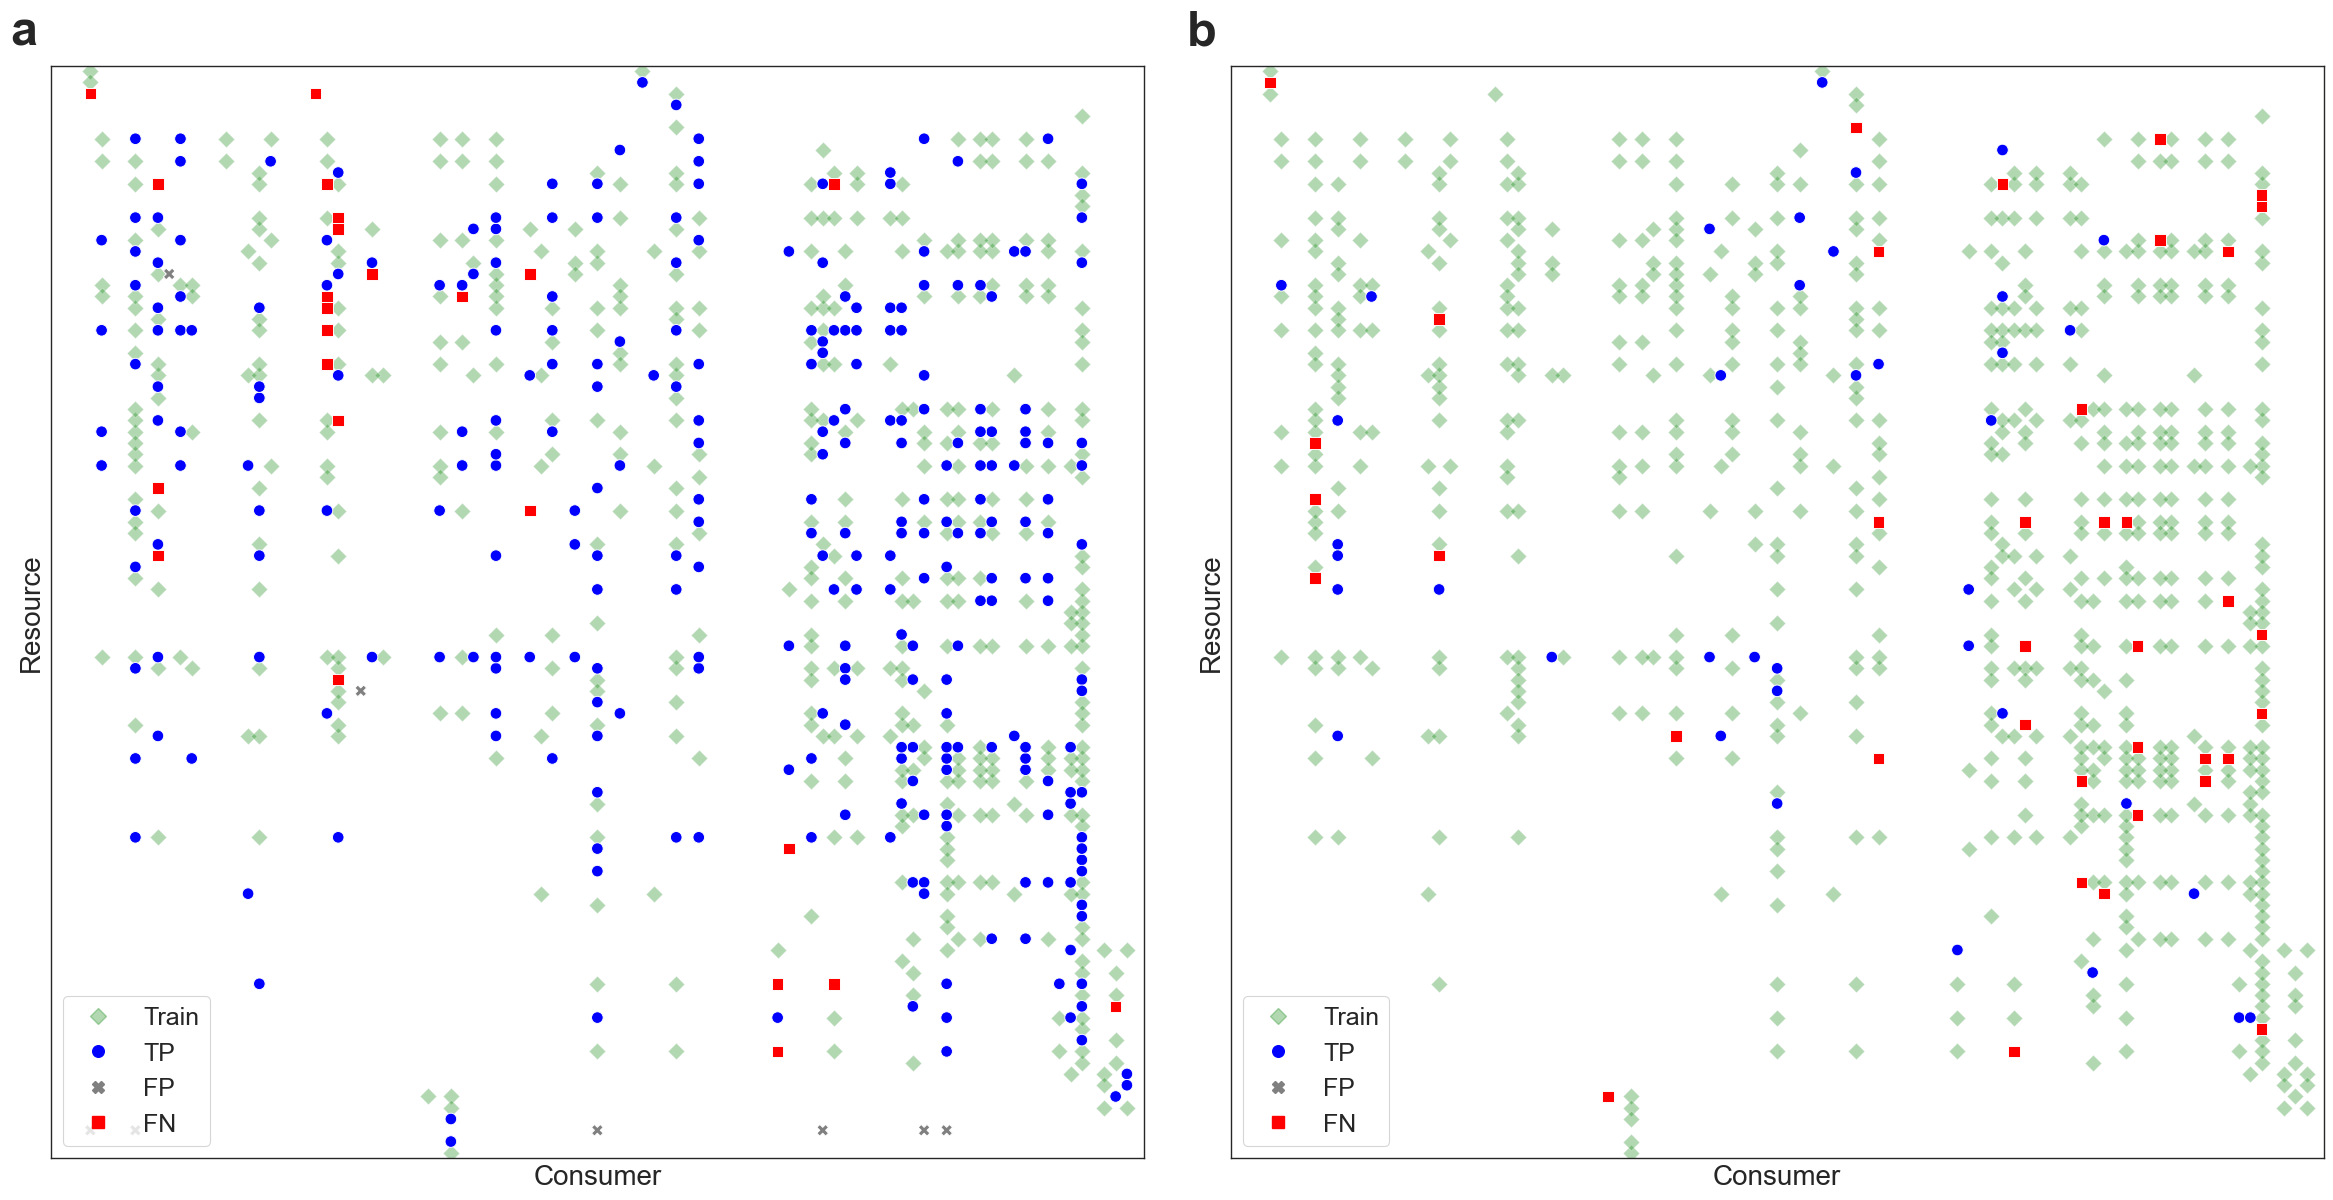

In [7]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.sparse import csr_matrix, issparse


# ============================================================
# Style + repository
# ============================================================

sns.set_theme(context="paper", style="white", font_scale=3)


def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        f"Could not locate repository root from {start}"
    )


REPO_ROOT = find_repo_root()


# ============================================================
# SIMPLE PANEL CONFIGURATION
# Edit foodweb, train_ratio and experiment_id per panel.
# train_ratio accepts 60 / 90 or 0.60 / 0.90.
# ============================================================

DEFAULT_FOODWEB = (
    "Grand Caricaie  marsh dominated by "
    "Cladietum marisci, not mown  ClControl2"
)

PANELS = [
    {
        "letter": "a",
        "foodweb": DEFAULT_FOODWEB,
        "train_ratio": 60,
        "experiment_id": 21,
    },
    {
        "letter": "b",
        "foodweb": DEFAULT_FOODWEB,
        "train_ratio": 90,
        "experiment_id": 21,
    },
]

K_TARGET = 10
CLASSIFICATION_THRESHOLD = 0.50


# ============================================================
# Existing figure controls
# ============================================================

MIN_NODES = 40

SHOW_TITLES = False
SHOW_TICKS = False
USE_NUMERIC_AXIS_LABELS = False

XLAB = "Consumer"
YLAB = "Resource"

PANEL_XTICK_FONTSIZES = [12, 12]
PANEL_YTICK_FONTSIZES = [12, 12]

PRINT_SPECIES_KEY = False
EXPORT_SPECIES_KEY_FILE = True
SPECIES_KEY_FORMAT = "csv"

SPECIES_KEY_DIR = (
    REPO_ROOT
    / "docs/progress_notebooks_logs/2026/species_keys"
)


# ============================================================
# Input paths
# ============================================================

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_trophicv2_"
        "100x290_train10-90_Apocrita_20260910_011848"
    )
)

PREDICTION_LOG_DIR = (
    RESULT_ROOT
    / "prediction_scores_logs"
)

ECOLOGICAL_SNAPSHOTS_DIR = (
    RESULT_ROOT
    / "ecological_snapshots"
)

BASE_MAT_PATH = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
)


# ============================================================
# Initial references
# Used only for the untouched initial configuration.
# Seeds are always read from the selected CSV row.
# ============================================================

def canonical_foodweb(name):
    name = str(name).strip()

    return (
        name[:-len("_tax_mass")]
        if name.endswith("_tax_mass")
        else name
    )


REFERENCE_FOODWEB = (
    "Grand Caricaie  marsh dominated by "
    "Cladietum marisci, not mown  ClControl2"
)


INITIAL_REFERENCE = {
    (
        canonical_foodweb(REFERENCE_FOODWEB),
        60.0,
        21,
    ): {
        "seed": 1314098572,
        "TrainLinks": 460,
        "TestTP": 284,
        "TestFP": 8,
        "TestFN": 24,
    },
    (
        canonical_foodweb(REFERENCE_FOODWEB),
        90.0,
        21,
    ): {
        "seed": 1316850472,
        "TrainLinks": 691,
        "TestTP": 39,
        "TestFP": 0,
        "TestFN": 38,
    },
}


# ============================================================
# Helpers
# ============================================================

def norm_name(value):
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(value).lower(),
    )


def find_col(
    df,
    *aliases,
    required=True,
):
    lookup = {
        norm_name(column): column
        for column in df.columns
    }

    for alias in aliases:
        key = norm_name(alias)

        if key in lookup:
            return lookup[key]

    if required:
        raise KeyError(
            f"Missing required column. Tried {aliases}. "
            f"Available columns: {list(df.columns)}"
        )

    return None


def ratio_percent(value):
    value = float(value)

    if 0 < value <= 1:
        value *= 100

    if not 0 < value <= 100:
        raise ValueError(
            f"Invalid train_ratio={value!r}"
        )

    return float(value)


def tax_mass_stem(foodweb):
    foodweb = str(foodweb).strip()

    return (
        foodweb
        if foodweb.endswith("_tax_mass")
        else f"{foodweb}_tax_mass"
    )


def as_int(
    value,
    label,
):
    numeric = pd.to_numeric(
        pd.Series([value]),
        errors="coerce",
    ).iloc[0]

    if pd.isna(numeric):
        raise ValueError(
            f"{label} is not numeric: {value!r}"
        )

    integer = int(
        round(
            float(numeric)
        )
    )

    if not np.isclose(
        float(numeric),
        integer,
        atol=1e-9,
        rtol=0,
    ):
        raise ValueError(
            f"{label} is not an integer: {value!r}"
        )

    return integer


def binary_csr(matrix):
    if issparse(matrix):
        out = matrix.tocsr(
            copy=True
        )
    else:
        out = csr_matrix(
            np.asarray(matrix)
        )

    out.sum_duplicates()
    out.eliminate_zeros()

    if out.nnz:
        out.data = np.ones(
            out.nnz,
            dtype=np.int8,
        )

    return out.astype(
        np.int8
    )


def mask_and(
    a,
    b,
):
    out = a.multiply(
        b
    ).tocsr()

    out.eliminate_zeros()

    if out.nnz:
        out.data[:] = 1

    return out


def mask_and_not(
    a,
    b,
):
    out = (
        a.astype(np.int8)
        - a.multiply(b).astype(np.int8)
    ).tocsr()

    out.eliminate_zeros()

    if out.nnz:
        if np.any(
            out.data < 0
        ):
            raise ValueError(
                "Unexpected negative entries while "
                "reconstructing sparse masks."
            )

        out.data[:] = 1

    return out


def sparse_equal(
    a,
    b,
):
    if a.shape != b.shape:
        return False

    diff = (
        a.astype(np.int8)
        - b.astype(np.int8)
    ).tocsr()

    diff.eliminate_zeros()

    return (
        diff.nnz == 0
    )


def unwrap(value):
    while (
        isinstance(
            value,
            np.ndarray,
        )
        and value.size == 1
    ):
        value = value.reshape(
            -1
        )[0]

    return value


def matlab_str(value):
    value = unwrap(
        value
    )

    if isinstance(
        value,
        (bytes, np.bytes_),
    ):
        return bytes(
            value
        ).decode(
            "utf-8",
            errors="replace",
        ).strip()

    if isinstance(
        value,
        str,
    ):
        return value.strip()

    if isinstance(
        value,
        np.str_,
    ):
        return str(
            value
        ).strip()

    if (
        isinstance(
            value,
            np.ndarray,
        )
        and value.dtype.kind
        in {
            "U",
            "S",
        }
    ):
        parts = []

        for item in value.reshape(
            -1
        ):
            if isinstance(
                item,
                (bytes, np.bytes_),
            ):
                parts.append(
                    bytes(
                        item
                    ).decode(
                        "utf-8",
                        errors="replace",
                    )
                )

            else:
                parts.append(
                    str(
                        item
                    )
                )

        return "".join(
            parts
        ).strip()

    return str(
        value
    ).strip()


def matlab_str_list(value):
    return [
        matlab_str(
            item
        )
        for item
        in np.asarray(
            value,
            dtype=object,
        ).reshape(-1)
    ]


def struct_fields(obj):
    obj = unwrap(
        obj
    )

    if isinstance(
        obj,
        dict,
    ):
        return list(
            obj.items()
        )

    names = getattr(
        obj,
        "_fieldnames",
        None,
    )

    if names:
        return [
            (
                name,
                getattr(
                    obj,
                    name,
                ),
            )
            for name in names
        ]

    if (
        isinstance(
            obj,
            np.void,
        )
        and obj.dtype.names
    ):
        return [
            (
                name,
                obj[name],
            )
            for name
            in obj.dtype.names
        ]

    return []


def struct_get(
    obj,
    field,
):
    target = norm_name(
        field
    )

    for name, value in struct_fields(
        obj
    ):
        if norm_name(
            name
        ) == target:
            return value

    raise KeyError(
        f"MATLAB struct is missing field "
        f"{field!r}. "
        f"Available fields: "
        f"{[name for name, _ in struct_fields(obj)]}"
    )


def struct_get_optional(
    obj,
    *aliases,
):
    targets = {
        norm_name(alias)
        for alias in aliases
    }

    for name, value in struct_fields(
        obj
    ):
        if norm_name(
            name
        ) in targets:
            return value

    return None


# ============================================================
# Exact CSV row selection
# ============================================================

def select_run(panel):
    foodweb = panel[
        "foodweb"
    ]

    ratio = ratio_percent(
        panel[
            "train_ratio"
        ]
    )

    experiment_id = int(
        panel[
            "experiment_id"
        ]
    )

    csv_path = (
        PREDICTION_LOG_DIR
        / (
            f"{tax_mass_stem(foodweb)}"
            "_results_random_wlnm_dir_neg.csv"
        )
    )

    if not csv_path.is_file():
        raise FileNotFoundError(
            "Results CSV not found:\n"
            f"  {csv_path}"
        )

    df = pd.read_csv(
        csv_path
    )

    k_col = find_col(
        df,
        "K",
        "SubgraphK",
    )

    ratio_col = find_col(
        df,
        "TrainRatio",
        "TrainingRatio",
    )

    exp_col = find_col(
        df,
        "ExperimentID",
        "Experiment",
    )

    threshold_col = find_col(
        df,
        "Threshold",
        "ClassificationThreshold",
    )

    foodweb_col = find_col(
        df,
        "Foodweb",
        "FoodWebName",
        required=False,
    )

    k = pd.to_numeric(
        df[k_col],
        errors="coerce",
    )

    train_ratio = pd.to_numeric(
        df[ratio_col],
        errors="coerce",
    )

    train_ratio = np.where(
        train_ratio
        <= 1.0 + 1e-12,
        train_ratio * 100.0,
        train_ratio,
    )

    experiment = pd.to_numeric(
        df[exp_col],
        errors="coerce",
    )

    threshold = pd.to_numeric(
        df[threshold_col],
        errors="coerce",
    )

    mask = (
        np.isclose(
            k,
            K_TARGET,
            atol=1e-12,
            rtol=0,
        )
        & np.isclose(
            train_ratio,
            ratio,
            atol=1e-9,
            rtol=0,
        )
        & np.isclose(
            experiment,
            experiment_id,
            atol=1e-12,
            rtol=0,
        )
        & np.isclose(
            threshold,
            CLASSIFICATION_THRESHOLD,
            atol=1e-12,
            rtol=0,
        )
    )

    if (
        foodweb_col
        is not None
    ):
        mask &= (
            df[foodweb_col]
            .astype(str)
            .map(
                canonical_foodweb
            )
            .eq(
                canonical_foodweb(
                    foodweb
                )
            )
        )

    matches = df.loc[
        mask
    ]

    if len(
        matches
    ) != 1:
        raise ValueError(
            "Expected exactly one matching run, "
            f"but found {len(matches)}.\n"
            f"  foodweb={foodweb!r}\n"
            f"  K={K_TARGET}\n"
            f"  TrainRatio={ratio:g}%\n"
            f"  ExperimentID={experiment_id}\n"
            f"  threshold={CLASSIFICATION_THRESHOLD}\n"
            f"  CSV={csv_path}"
        )

    return (
        matches.iloc[0],
        csv_path,
        ratio,
    )


# ============================================================
# Resolve LOCAL snapshot by basename only
# ============================================================

def local_snapshot_from_row(row):
    row_df = pd.DataFrame(
        [row]
    )

    snapshot_col = find_col(
        row_df,
        "TrophicSnapshotFile",
        "SnapshotFile",
    )

    raw = row[
        snapshot_col
    ]

    if pd.isna(
        raw
    ):
        raise ValueError(
            "TrophicSnapshotFile is empty "
            "for the selected run."
        )

    snapshot_name = (
        str(raw)
        .strip()
        .replace(
            "\\",
            "/",
        )
        .split("/")[-1]
    )

    matches = [
        path
        for path
        in ECOLOGICAL_SNAPSHOTS_DIR.rglob(
            "*.mat"
        )
        if path.name
        == snapshot_name
    ]

    if len(
        matches
    ) != 1:
        raise FileNotFoundError(
            "Expected exactly one LOCAL "
            "ecological snapshot, "
            f"found {len(matches)}.\n"
            f"  basename={snapshot_name!r}\n"
            f"  searched under="
            f"{ECOLOGICAL_SNAPSHOTS_DIR}\n"
            f"  matches={matches}"
        )

    return matches[0]


# ============================================================
# Load tax/mass file
# ============================================================

def load_tax_mass(foodweb):
    mat_path = (
        BASE_MAT_PATH
        / (
            f"{tax_mass_stem(foodweb)}"
            ".mat"
        )
    )

    if not mat_path.is_file():
        raise FileNotFoundError(
            "Food-web tax/mass MAT "
            "not found:\n"
            f"  {mat_path}"
        )

    data = scipy.io.loadmat(
        mat_path,
        struct_as_record=False,
        squeeze_me=True,
    )

    for key in (
        "net",
        "taxonomy",
        "mass",
    ):
        if key not in data:
            raise KeyError(
                f"{mat_path} "
                f"is missing {key!r}"
            )

    net = binary_csr(
        data[
            "net"
        ]
    )
    # WLNM_dir_neg removes self-loops before saving empirical.
    net.setdiag(0)
    net.eliminate_zeros()

    taxonomy = matlab_str_list(
        data[
            "taxonomy"
        ]
    )

    mass = np.asarray(
        data[
            "mass"
        ]
    ).reshape(
        -1
    ).astype(
        float
    )

    n = len(
        taxonomy
    )

    if len(
        mass
    ) != n:
        raise ValueError(
            "taxonomy and mass "
            "have different lengths in "
            f"{mat_path}"
        )

    if net.shape != (
        n,
        n,
    ):
        raise ValueError(
            f"net.shape={net.shape}, "
            f"expected {(n, n)}"
        )

    if n < MIN_NODES:
        raise ValueError(
            f"Selected food web has "
            f"{n} nodes, below "
            f"MIN_NODES={MIN_NODES}."
        )

    if not np.all(
        np.isfinite(
            mass
        )
    ):
        raise ValueError(
            "Non-finite body masses "
            f"found in {mat_path}"
        )

    normalized = [
        re.sub(
            r"\s+",
            " ",
            value.strip(),
        )
        for value
        in taxonomy
    ]

    if len(
        set(
            normalized
        )
    ) != n:
        raise ValueError(
            "Duplicate taxonomy labels "
            "found; node mapping is ambiguous."
        )

    return (
        mat_path,
        net,
        taxonomy,
        mass,
    )


# ============================================================
# Load snapshot + reconstruct Train / TP / FP / FN
# ============================================================

def load_snapshot(
    snapshot_path,
    base_net,
    taxonomy,
):
    data = scipy.io.loadmat(
        snapshot_path,
        struct_as_record=False,
        squeeze_me=True,
    )

    if (
        "snapshot"
        not in data
    ):
        raise KeyError(
            "'snapshot' struct "
            "not found in "
            f"{snapshot_path}"
        )

    snapshot = data[
        "snapshot"
    ]

    empirical = binary_csr(
        struct_get(
            snapshot,
            "empirical",
        )
    )

    train = binary_csr(
        struct_get(
            snapshot,
            "train",
        )
    )

    pseudo = binary_csr(
        struct_get(
            snapshot,
            "pseudo",
        )
    )

    metadata = struct_get(
        snapshot,
        "metadata",
    )

    n = len(
        taxonomy
    )

    for name, matrix in {
        "empirical": empirical,
        "train": train,
        "pseudo": pseudo,
    }.items():

        if matrix.shape != (
            n,
            n,
        ):
            raise ValueError(
                f"snapshot.{name}.shape="
                f"{matrix.shape}, "
                f"expected {(n, n)}"
            )

    # Validate snapshot node indexing and direction against
    # the original directed food-web matrix.
    if not sparse_equal(
        empirical,
        base_net,
    ):
        if sparse_equal(
            empirical,
            base_net.T.tocsr(),
        ):
            raise ValueError(
                "snapshot.empirical matches "
                "net.T rather than net. "
                "Direction/index convention "
                "is inconsistent."
            )

        raise ValueError(
            "snapshot.empirical does not "
            "match the tax_mass net. "
            "Node identity/order cannot "
            "be validated safely."
        )

    train_outside_empirical = (
        mask_and_not(
            train,
            empirical,
        )
    )

    if (
        train_outside_empirical.nnz
    ):
        raise ValueError(
            "snapshot.train contains "
            f"{train_outside_empirical.nnz} "
            "links absent from empirical."
        )

    # If metadata exposes node names, verify those explicitly too.
    metadata_nodes = struct_get_optional(
        metadata,
        "taxonomy",
        "taxa",
        "species",
        "species_names",
        "node_names",
        "node_labels",
    )

    if (
        metadata_nodes
        is not None
    ):
        names = matlab_str_list(
            metadata_nodes
        )

        if len(
            names
        ) == n:

            def clean(value):
                return re.sub(
                    r"\s+",
                    " ",
                    value.strip(),
                )

            if (
                list(
                    map(
                        clean,
                        names,
                    )
                )
                != list(
                    map(
                        clean,
                        taxonomy,
                    )
                )
            ):
                raise ValueError(
                    "Snapshot metadata node names "
                    "do not match tax_mass taxonomy "
                    "in the same index order."
                )

            print(
                "[INFO] Snapshot node names "
                "match tax_mass taxonomy."
            )

    # --------------------------------------------------------
    # Required reconstruction
    # --------------------------------------------------------
    #
    # Train          = train
    # true_test      = empirical & ~train
    # predicted_test = pseudo & ~train
    # TP             = true_test & predicted_test
    # FP             = predicted_test & ~true_test
    # FN             = true_test & ~predicted_test
    #

    true_test = mask_and_not(
        empirical,
        train,
    )

    predicted_test = mask_and_not(
        pseudo,
        train,
    )

    tp = mask_and(
        true_test,
        predicted_test,
    )

    fp = mask_and_not(
        predicted_test,
        true_test,
    )

    fn = mask_and_not(
        true_test,
        predicted_test,
    )

    return {
        "Train": train,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "metadata": metadata,
    }


# ============================================================
# Validate seed + reconstructed counts against selected CSV row
# ============================================================

def validate_run(
    row,
    panel,
    ratio,
    masks,
    snapshot_path,
):
    row_df = pd.DataFrame(
        [row]
    )

    seed_col = find_col(
        row_df,
        "Seed",
        "RandomSeed",
        "ExperimentSeed",
    )

    train_col = find_col(
        row_df,
        "TrainLinks",
    )

    tp_col = find_col(
        row_df,
        "TestTP",
    )

    fp_col = find_col(
        row_df,
        "TestFP",
    )

    fn_col = find_col(
        row_df,
        "TestFN",
    )

    seed = as_int(
        row[
            seed_col
        ],
        "Seed",
    )

    csv_counts = {
        "TrainLinks": as_int(
            row[
                train_col
            ],
            "TrainLinks",
        ),
        "TestTP": as_int(
            row[
                tp_col
            ],
            "TestTP",
        ),
        "TestFP": as_int(
            row[
                fp_col
            ],
            "TestFP",
        ),
        "TestFN": as_int(
            row[
                fn_col
            ],
            "TestFN",
        ),
    }

    reconstructed = {
        "TrainLinks": (
            masks[
                "Train"
            ].nnz
        ),
        "TestTP": (
            masks[
                "TP"
            ].nnz
        ),
        "TestFP": (
            masks[
                "FP"
            ].nnz
        ),
        "TestFN": (
            masks[
                "FN"
            ].nnz
        ),
    }

    if (
        csv_counts
        != reconstructed
    ):
        raise ValueError(
            "Reconstructed counts do not "
            "match the selected CSV row.\n"
            f"  CSV={csv_counts}\n"
            f"  reconstructed={reconstructed}\n"
            f"  snapshot={snapshot_path}"
        )

    # If metadata contains its own seed, verify that too.
    metadata_seed = struct_get_optional(
        masks[
            "metadata"
        ],
        "seed",
        "random_seed",
        "experiment_seed",
    )

    if (
        metadata_seed
        is not None
    ):
        snapshot_seed = as_int(
            unwrap(
                metadata_seed
            ),
            "snapshot metadata seed",
        )

        if (
            snapshot_seed
            != seed
        ):
            raise ValueError(
                "Seed mismatch between CSV "
                "and snapshot metadata:\n"
                f"  CSV={seed}\n"
                f"  snapshot={snapshot_seed}"
            )

    # Only the untouched initial configuration is checked
    # against the supplied reference seed/counts.
    ref_key = (
        canonical_foodweb(
            panel[
                "foodweb"
            ]
        ),
        float(
            ratio
        ),
        int(
            panel[
                "experiment_id"
            ]
        ),
    )

    reference = INITIAL_REFERENCE.get(
        ref_key
    )

    if (
        reference
        is not None
    ):
        if (
            seed
            != reference[
                "seed"
            ]
        ):
            raise ValueError(
                "Initial seed does not match "
                "the supplied reference:\n"
                f"  expected="
                f"{reference['seed']}\n"
                f"  CSV={seed}"
            )

        for key in (
            "TrainLinks",
            "TestTP",
            "TestFP",
            "TestFN",
        ):
            if (
                reconstructed[
                    key
                ]
                != reference[
                    key
                ]
            ):
                raise ValueError(
                    "Initial reference mismatch "
                    f"for {key}: "
                    f"expected={reference[key]}, "
                    f"observed={reconstructed[key]}"
                )

    return (
        seed,
        reconstructed,
    )


# ============================================================
# Sparse directed links -> mass-sorted plotting coordinates
#
# Matrix convention:
#   row    = Resource / Prey
#   column = Consumer / Predator
# ============================================================

def mask_to_df(
    mask,
    original_to_sorted,
    label,
):
    (
        resource_idx,
        consumer_idx,
    ) = mask.nonzero()

    return pd.DataFrame({
        "PreyIdx": (
            original_to_sorted[
                resource_idx
            ]
        ),
        "PredIdx": (
            original_to_sorted[
                consumer_idx
            ]
        ),
        "Label": label,
    })


# ============================================================
# Validate ALL panels before drawing
# ============================================================

for label, path in {
    "prediction_scores_logs":
        PREDICTION_LOG_DIR,
    "ecological_snapshots":
        ECOLOGICAL_SNAPSHOTS_DIR,
    "foodwebs_mat":
        BASE_MAT_PATH,
}.items():

    if not path.is_dir():
        raise FileNotFoundError(
            f"Missing {label} directory:\n"
            f"  {path}"
        )


prepared = []
tax_mass_cache = {}
species_key_done = set()


for panel_idx, panel in enumerate(
    PANELS
):
    letter = panel.get(
        "letter",
        chr(
            ord("a")
            + panel_idx
        ),
    )

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"[INFO] Panel {letter}: "
        f"{canonical_foodweb(panel['foodweb'])}"
    )

    # --------------------------------------------------------
    # 1. Locate exactly one run in prediction_scores_logs
    # --------------------------------------------------------

    (
        row,
        results_csv,
        ratio,
    ) = select_run(
        panel
    )

    # --------------------------------------------------------
    # 2. Resolve LOCAL snapshot from TrophicSnapshotFile basename
    # --------------------------------------------------------

    snapshot_path = (
        local_snapshot_from_row(
            row
        )
    )

    # --------------------------------------------------------
    # 3. Load taxonomy / mass / empirical net
    # --------------------------------------------------------

    stem = tax_mass_stem(
        panel[
            "foodweb"
        ]
    )

    if (
        stem
        not in tax_mass_cache
    ):
        tax_mass_cache[
            stem
        ] = load_tax_mass(
            panel[
                "foodweb"
            ]
        )

    (
        tax_mass_path,
        base_net,
        taxonomy,
        mass,
    ) = tax_mass_cache[
        stem
    ]

    # --------------------------------------------------------
    # 4. Load snapshot and reconstruct Train / TP / FP / FN
    # --------------------------------------------------------

    masks = load_snapshot(
        snapshot_path,
        base_net,
        taxonomy,
    )

    # --------------------------------------------------------
    # 5. Validate seed and reconstructed counts
    # --------------------------------------------------------

    (
        seed,
        counts,
    ) = validate_run(
        row=row,
        panel=panel,
        ratio=ratio,
        masks=masks,
        snapshot_path=snapshot_path,
    )

    print(
        "[INFO] Exact run validated:\n"
        f"  K={K_TARGET}, "
        f"TrainRatio={ratio:g}%, "
        f"ExperimentID="
        f"{panel['experiment_id']}, "
        f"threshold="
        f"{CLASSIFICATION_THRESHOLD:.2f}\n"
        f"  Seed={seed}\n"
        f"  Train="
        f"{counts['TrainLinks']:,}, "
        f"TP={counts['TestTP']:,}, "
        f"FP={counts['TestFP']:,}, "
        f"FN={counts['TestFN']:,}\n"
        f"  CSV={results_csv}\n"
        f"  Snapshot={snapshot_path}"
    )

    # --------------------------------------------------------
    # 6. Sort species by body mass
    # --------------------------------------------------------

    # Same conversion used by the original cell.
    mass_mg = np.round(
        mass * 1000.0,
        4,
    )

    sorted_original_idx = np.argsort(
        mass_mg,
        kind="stable",
    )

    sorted_species = [
        taxonomy[
            index
        ]
        for index
        in sorted_original_idx
    ]

    sorted_mass_mg = (
        mass_mg[
            sorted_original_idx
        ]
    )

    n = len(
        sorted_species
    )

    original_to_sorted = np.empty(
        n,
        dtype=int,
    )

    original_to_sorted[
        sorted_original_idx
    ] = np.arange(
        n
    )

    # Stable numbering for the same food web in both panels.
    species_to_num = {
        species: index + 1
        for index, species
        in enumerate(
            sorted_species
        )
    }

    # --------------------------------------------------------
    # Optional species key
    # --------------------------------------------------------

    if (
        PRINT_SPECIES_KEY
        and stem
        not in species_key_done
    ):
        key_df = pd.DataFrame({
            "Number": np.arange(
                1,
                n + 1,
            ),
            "Species":
                sorted_species,
            "Mass_mg":
                sorted_mass_mg,
        })

        key_df[
            "Mass_mg"
        ] = (
            key_df[
                "Mass_mg"
            ]
            .map(
                lambda value:
                f"{value:.4f}"
            )
        )

        print(
            "\n"
            + key_df.to_string(
                index=False
            )
        )

        if (
            EXPORT_SPECIES_KEY_FILE
        ):
            SPECIES_KEY_DIR.mkdir(
                parents=True,
                exist_ok=True,
            )

            safe_foodweb = re.sub(
                r"[^A-Za-z0-9._-]+",
                "_",
                stem,
            ).strip(
                "_"
            )

            extension = (
                "tsv"
                if (
                    SPECIES_KEY_FORMAT.lower()
                    == "tsv"
                )
                else "csv"
            )

            output_path = (
                SPECIES_KEY_DIR
                / (
                    f"{safe_foodweb}_"
                    f"species_key."
                    f"{extension}"
                )
            )

            key_df.to_csv(
                output_path,
                sep=(
                    "\t"
                    if extension
                    == "tsv"
                    else ","
                ),
                index=False,
                encoding="utf-8",
            )

            print(
                "[INFO] Saved species key: "
                f"{output_path.resolve()}"
            )

        species_key_done.add(
            stem
        )

    # --------------------------------------------------------
    # 7. Convert reconstructed matrices to plot coordinates
    # --------------------------------------------------------

    df_train = mask_to_df(
        masks[
            "Train"
        ],
        original_to_sorted,
        "Train",
    )

    df_pm = pd.concat(
        [
            mask_to_df(
                masks[
                    "TP"
                ],
                original_to_sorted,
                "TP",
            ),
            mask_to_df(
                masks[
                    "FP"
                ],
                original_to_sorted,
                "FP",
            ),
            mask_to_df(
                masks[
                    "FN"
                ],
                original_to_sorted,
                "FN",
            ),
        ],
        ignore_index=True,
    )

    prepared.append({
        "letter":
            letter,
        "foodweb":
            canonical_foodweb(
                panel[
                    "foodweb"
                ]
            ),
        "train_ratio":
            ratio,
        "experiment_id":
            int(
                panel[
                    "experiment_id"
                ]
            ),
        "seed":
            seed,
        "n":
            n,
        "sorted_species":
            sorted_species,
        "species_to_num":
            species_to_num,
        "df_train":
            df_train,
        "df_pm":
            df_pm,
    })


# ============================================================
# Plot only AFTER every panel has passed all checks
# ============================================================

fig, axs = plt.subplots(
    1,
    len(
        prepared
    ),
    figsize=(
        12 * len(
            prepared
        ),
        12,
    ),
    squeeze=False,
)

axs = axs.ravel()


# Keep Train / TP / FP / FN in every legend,
# including FP when FP=0 in panel b.
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="None",
        markerfacecolor="green",
        markeredgecolor="green",
        alpha=0.3,
        markersize=np.sqrt(
            70
        ),
        label="Train",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor="blue",
        markeredgecolor="blue",
        markersize=np.sqrt(
            70
        ),
        label="TP",
    ),
    Line2D(
        [0],
        [0],
        marker="X",
        linestyle="None",
        markerfacecolor="gray",
        markeredgecolor="gray",
        markersize=np.sqrt(
            70
        ),
        label="FP",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="None",
        markerfacecolor="red",
        markeredgecolor="red",
        markersize=np.sqrt(
            70
        ),
        label="FN",
    ),
]


for panel_idx, panel in enumerate(
    prepared
):
    ax = axs[
        panel_idx
    ]

    n = panel[
        "n"
    ]

    # --------------------------------------------------------
    # Training links first
    # green diamond, alpha=0.3, s=70
    # --------------------------------------------------------

    if not panel[
        "df_train"
    ].empty:
        sns.scatterplot(
            data=panel[
                "df_train"
            ],
            x="PredIdx",
            y="PreyIdx",
            color="green",
            marker="D",
            alpha=0.3,
            s=70,
            legend=False,
            ax=ax,
        )

    # --------------------------------------------------------
    # TP / FP / FN
    # --------------------------------------------------------

    if not panel[
        "df_pm"
    ].empty:
        sns.scatterplot(
            data=panel[
                "df_pm"
            ],
            x="PredIdx",
            y="PreyIdx",
            hue="Label",
            style="Label",
            hue_order=[
                "TP",
                "FP",
                "FN",
            ],
            style_order=[
                "TP",
                "FP",
                "FN",
            ],
            markers={
                "TP": "o",
                "FP": "X",
                "FN": "s",
            },
            palette={
                "TP": "blue",
                "FP": "gray",
                "FN": "red",
            },
            s=70,
            legend=False,
            ax=ax,
        )

    # Consumer body mass increases left -> right.
    ax.set_xlim(
        -0.5,
        n - 0.5,
    )

    # Resource body mass increases top -> bottom.
    ax.set_ylim(
        n - 0.5,
        -0.5,
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_xlabel(
        XLAB,
        fontsize=20,
    )

    ax.set_ylabel(
        YLAB,
        fontsize=20,
    )

    # --------------------------------------------------------
    # Existing tick controls
    # --------------------------------------------------------

    if SHOW_TICKS:
        ax.set_xticks(
            range(
                n
            )
        )

        ax.set_yticks(
            range(
                n
            )
        )

        x_fontsize = (
            PANEL_XTICK_FONTSIZES[
                panel_idx
            ]
        )

        y_fontsize = (
            PANEL_YTICK_FONTSIZES[
                panel_idx
            ]
        )

        if (
            USE_NUMERIC_AXIS_LABELS
        ):
            labels = [
                str(
                    panel[
                        "species_to_num"
                    ][
                        species
                    ]
                )
                for species
                in panel[
                    "sorted_species"
                ]
            ]

            ax.set_xticklabels(
                labels,
                rotation=90,
                fontsize=x_fontsize,
            )

            ax.set_yticklabels(
                labels,
                fontsize=y_fontsize,
            )

        else:
            ax.set_xticklabels(
                panel[
                    "sorted_species"
                ],
                rotation=90,
                fontsize=x_fontsize,
            )

            ax.set_yticklabels(
                panel[
                    "sorted_species"
                ],
                fontsize=y_fontsize,
            )

        ax.tick_params(
            axis="both",
            which="both",
            length=3,
        )

    else:
        ax.set_xticks(
            []
        )

        ax.set_yticks(
            []
        )

        ax.set_xticklabels(
            []
        )

        ax.set_yticklabels(
            []
        )

        ax.tick_params(
            axis="both",
            which="both",
            length=0,
        )

    # --------------------------------------------------------
    # Existing title control
    # --------------------------------------------------------

    if SHOW_TITLES:
        ax.set_title(
            panel[
                "foodweb"
            ],
            fontsize=12,
        )

    # --------------------------------------------------------
    # Panel letter outside matrix
    # --------------------------------------------------------

    ax.annotate(
        panel["letter"],
        xy=(0, 1),
        xycoords="axes fraction",
        xytext=(-10, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=35,
        fontweight="bold",
        annotation_clip=False,
    )

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    ax.legend(
        handles=legend_handles,
        loc="lower left",
        prop={
            "size": 18,
        },
        title="",
    )


plt.tight_layout()
plt.show()


[INFO] Panel a: Hoel lake


/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_62260/3140162145.py:794: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
        That means the default return type will be a sparse array.
        Unless you use * instead of @, ** for matrix power, or you depend
        on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
        See the spmatrix to sparray migration guide for details.
        https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
        
  data = scipy.io.loadmat(


[INFO] Snapshot node names match tax_mass taxonomy.
[INFO] Exact run validated:
  K=10, TrainRatio=60%, ExperimentID=21, threshold=0.50
  Seed=1801531645
  Train=338, TP=221, FP=2, FN=5
  CSV=/Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/prediction_scores_logs/Hoel lake_tax_mass_results_random_wlnm_dir_neg.csv
  Snapshot=/Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/ecological_snapshots/Hoel_lake_tax_mass_K10_ratio0.6_exp21_seed1801531645_threshold0.5_validated_v2.mat

[INFO] Panel b: Hoel lake
[INFO] Snapshot node names match tax_mass taxonomy.
[INFO] Exact run validated:
  K=10, TrainRatio=90%, ExperimentID=21, threshold=0.50
  Seed=1804283545
  Train=507, TP=57, FP=0, FN=0
  CSV=/Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_

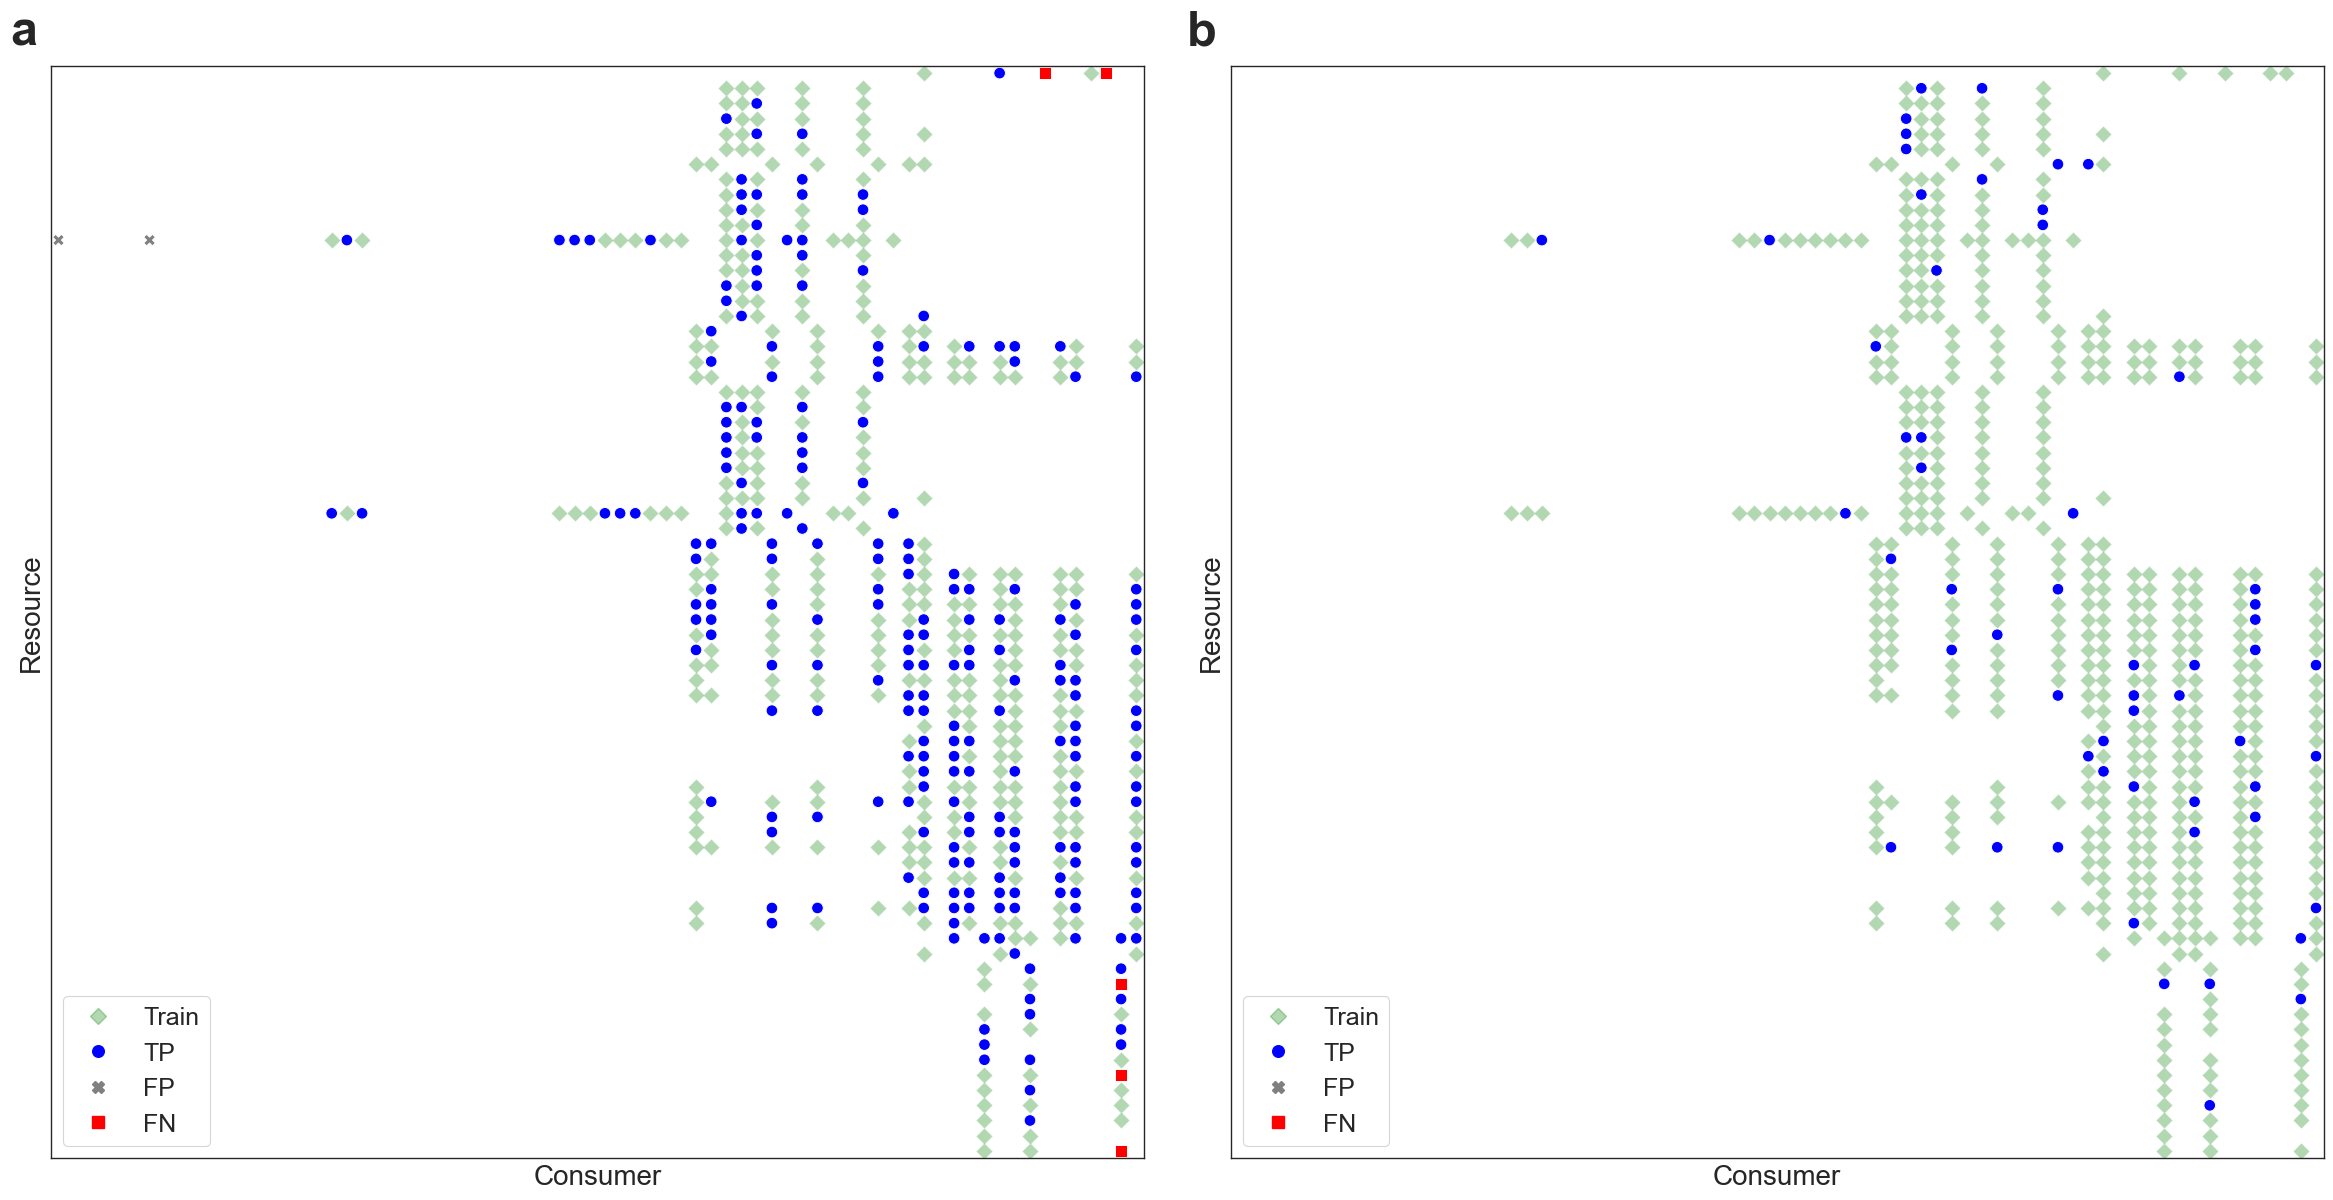

In [6]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.sparse import csr_matrix, issparse


# ============================================================
# Style + repository
# ============================================================

sns.set_theme(context="paper", style="white", font_scale=3)


def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        f"Could not locate repository root from {start}"
    )


REPO_ROOT = find_repo_root()


# ============================================================
# SIMPLE PANEL CONFIGURATION
# Edit foodweb, train_ratio and experiment_id per panel.
# train_ratio accepts 60 / 90 or 0.60 / 0.90.
# ============================================================

DEFAULT_FOODWEB = (
    "Hoel lake"
)

PANELS = [
    {
        "letter": "a",
        "foodweb": DEFAULT_FOODWEB,
        "train_ratio": 60,
        "experiment_id": 21,
    },
    {
        "letter": "b",
        "foodweb": DEFAULT_FOODWEB,
        "train_ratio": 90,
        "experiment_id": 21,
    },
]

K_TARGET = 10
CLASSIFICATION_THRESHOLD = 0.50


# ============================================================
# Existing figure controls
# ============================================================

MIN_NODES = 40

SHOW_TITLES = False
SHOW_TICKS = False
USE_NUMERIC_AXIS_LABELS = False

XLAB = "Consumer"
YLAB = "Resource"

PANEL_XTICK_FONTSIZES = [12, 12]
PANEL_YTICK_FONTSIZES = [12, 12]

PRINT_SPECIES_KEY = False
EXPORT_SPECIES_KEY_FILE = True
SPECIES_KEY_FORMAT = "csv"

SPECIES_KEY_DIR = (
    REPO_ROOT
    / "docs/progress_notebooks_logs/2026/species_keys"
)


# ============================================================
# Input paths
# ============================================================

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_trophicv2_"
        "100x290_train10-90_Apocrita_20260910_011848"
    )
)

PREDICTION_LOG_DIR = (
    RESULT_ROOT
    / "prediction_scores_logs"
)

ECOLOGICAL_SNAPSHOTS_DIR = (
    RESULT_ROOT
    / "ecological_snapshots"
)

BASE_MAT_PATH = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
)


# ============================================================
# Initial references
# Used only for the untouched initial configuration.
# Seeds are always read from the selected CSV row.
# ============================================================

def canonical_foodweb(name):
    name = str(name).strip()

    return (
        name[:-len("_tax_mass")]
        if name.endswith("_tax_mass")
        else name
    )


REFERENCE_FOODWEB = (
    "Grand Caricaie  marsh dominated by "
    "Cladietum marisci, not mown  ClControl2"
)


INITIAL_REFERENCE = {
    (
        canonical_foodweb(REFERENCE_FOODWEB),
        60.0,
        21,
    ): {
        "seed": 1314098572,
        "TrainLinks": 460,
        "TestTP": 284,
        "TestFP": 8,
        "TestFN": 24,
    },
    (
        canonical_foodweb(REFERENCE_FOODWEB),
        90.0,
        21,
    ): {
        "seed": 1316850472,
        "TrainLinks": 691,
        "TestTP": 39,
        "TestFP": 0,
        "TestFN": 38,
    },
}


# ============================================================
# Helpers
# ============================================================

def norm_name(value):
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(value).lower(),
    )


def find_col(
    df,
    *aliases,
    required=True,
):
    lookup = {
        norm_name(column): column
        for column in df.columns
    }

    for alias in aliases:
        key = norm_name(alias)

        if key in lookup:
            return lookup[key]

    if required:
        raise KeyError(
            f"Missing required column. Tried {aliases}. "
            f"Available columns: {list(df.columns)}"
        )

    return None


def ratio_percent(value):
    value = float(value)

    if 0 < value <= 1:
        value *= 100

    if not 0 < value <= 100:
        raise ValueError(
            f"Invalid train_ratio={value!r}"
        )

    return float(value)


def tax_mass_stem(foodweb):
    foodweb = str(foodweb).strip()

    return (
        foodweb
        if foodweb.endswith("_tax_mass")
        else f"{foodweb}_tax_mass"
    )


def as_int(
    value,
    label,
):
    numeric = pd.to_numeric(
        pd.Series([value]),
        errors="coerce",
    ).iloc[0]

    if pd.isna(numeric):
        raise ValueError(
            f"{label} is not numeric: {value!r}"
        )

    integer = int(
        round(
            float(numeric)
        )
    )

    if not np.isclose(
        float(numeric),
        integer,
        atol=1e-9,
        rtol=0,
    ):
        raise ValueError(
            f"{label} is not an integer: {value!r}"
        )

    return integer


def binary_csr(matrix):
    if issparse(matrix):
        out = matrix.tocsr(
            copy=True
        )
    else:
        out = csr_matrix(
            np.asarray(matrix)
        )

    out.sum_duplicates()
    out.eliminate_zeros()

    if out.nnz:
        out.data = np.ones(
            out.nnz,
            dtype=np.int8,
        )

    return out.astype(
        np.int8
    )


def mask_and(
    a,
    b,
):
    out = a.multiply(
        b
    ).tocsr()

    out.eliminate_zeros()

    if out.nnz:
        out.data[:] = 1

    return out


def mask_and_not(
    a,
    b,
):
    out = (
        a.astype(np.int8)
        - a.multiply(b).astype(np.int8)
    ).tocsr()

    out.eliminate_zeros()

    if out.nnz:
        if np.any(
            out.data < 0
        ):
            raise ValueError(
                "Unexpected negative entries while "
                "reconstructing sparse masks."
            )

        out.data[:] = 1

    return out


def sparse_equal(
    a,
    b,
):
    if a.shape != b.shape:
        return False

    diff = (
        a.astype(np.int8)
        - b.astype(np.int8)
    ).tocsr()

    diff.eliminate_zeros()

    return (
        diff.nnz == 0
    )


def unwrap(value):
    while (
        isinstance(
            value,
            np.ndarray,
        )
        and value.size == 1
    ):
        value = value.reshape(
            -1
        )[0]

    return value


def matlab_str(value):
    value = unwrap(
        value
    )

    if isinstance(
        value,
        (bytes, np.bytes_),
    ):
        return bytes(
            value
        ).decode(
            "utf-8",
            errors="replace",
        ).strip()

    if isinstance(
        value,
        str,
    ):
        return value.strip()

    if isinstance(
        value,
        np.str_,
    ):
        return str(
            value
        ).strip()

    if (
        isinstance(
            value,
            np.ndarray,
        )
        and value.dtype.kind
        in {
            "U",
            "S",
        }
    ):
        parts = []

        for item in value.reshape(
            -1
        ):
            if isinstance(
                item,
                (bytes, np.bytes_),
            ):
                parts.append(
                    bytes(
                        item
                    ).decode(
                        "utf-8",
                        errors="replace",
                    )
                )

            else:
                parts.append(
                    str(
                        item
                    )
                )

        return "".join(
            parts
        ).strip()

    return str(
        value
    ).strip()


def matlab_str_list(value):
    return [
        matlab_str(
            item
        )
        for item
        in np.asarray(
            value,
            dtype=object,
        ).reshape(-1)
    ]


def struct_fields(obj):
    obj = unwrap(
        obj
    )

    if isinstance(
        obj,
        dict,
    ):
        return list(
            obj.items()
        )

    names = getattr(
        obj,
        "_fieldnames",
        None,
    )

    if names:
        return [
            (
                name,
                getattr(
                    obj,
                    name,
                ),
            )
            for name in names
        ]

    if (
        isinstance(
            obj,
            np.void,
        )
        and obj.dtype.names
    ):
        return [
            (
                name,
                obj[name],
            )
            for name
            in obj.dtype.names
        ]

    return []


def struct_get(
    obj,
    field,
):
    target = norm_name(
        field
    )

    for name, value in struct_fields(
        obj
    ):
        if norm_name(
            name
        ) == target:
            return value

    raise KeyError(
        f"MATLAB struct is missing field "
        f"{field!r}. "
        f"Available fields: "
        f"{[name for name, _ in struct_fields(obj)]}"
    )


def struct_get_optional(
    obj,
    *aliases,
):
    targets = {
        norm_name(alias)
        for alias in aliases
    }

    for name, value in struct_fields(
        obj
    ):
        if norm_name(
            name
        ) in targets:
            return value

    return None


# ============================================================
# Exact CSV row selection
# ============================================================

def select_run(panel):
    foodweb = panel[
        "foodweb"
    ]

    ratio = ratio_percent(
        panel[
            "train_ratio"
        ]
    )

    experiment_id = int(
        panel[
            "experiment_id"
        ]
    )

    csv_path = (
        PREDICTION_LOG_DIR
        / (
            f"{tax_mass_stem(foodweb)}"
            "_results_random_wlnm_dir_neg.csv"
        )
    )

    if not csv_path.is_file():
        raise FileNotFoundError(
            "Results CSV not found:\n"
            f"  {csv_path}"
        )

    df = pd.read_csv(
        csv_path
    )

    k_col = find_col(
        df,
        "K",
        "SubgraphK",
    )

    ratio_col = find_col(
        df,
        "TrainRatio",
        "TrainingRatio",
    )

    exp_col = find_col(
        df,
        "ExperimentID",
        "Experiment",
    )

    threshold_col = find_col(
        df,
        "Threshold",
        "ClassificationThreshold",
    )

    foodweb_col = find_col(
        df,
        "Foodweb",
        "FoodWebName",
        required=False,
    )

    k = pd.to_numeric(
        df[k_col],
        errors="coerce",
    )

    train_ratio = pd.to_numeric(
        df[ratio_col],
        errors="coerce",
    )

    train_ratio = np.where(
        train_ratio
        <= 1.0 + 1e-12,
        train_ratio * 100.0,
        train_ratio,
    )

    experiment = pd.to_numeric(
        df[exp_col],
        errors="coerce",
    )

    threshold = pd.to_numeric(
        df[threshold_col],
        errors="coerce",
    )

    mask = (
        np.isclose(
            k,
            K_TARGET,
            atol=1e-12,
            rtol=0,
        )
        & np.isclose(
            train_ratio,
            ratio,
            atol=1e-9,
            rtol=0,
        )
        & np.isclose(
            experiment,
            experiment_id,
            atol=1e-12,
            rtol=0,
        )
        & np.isclose(
            threshold,
            CLASSIFICATION_THRESHOLD,
            atol=1e-12,
            rtol=0,
        )
    )

    if (
        foodweb_col
        is not None
    ):
        mask &= (
            df[foodweb_col]
            .astype(str)
            .map(
                canonical_foodweb
            )
            .eq(
                canonical_foodweb(
                    foodweb
                )
            )
        )

    matches = df.loc[
        mask
    ]

    if len(
        matches
    ) != 1:
        raise ValueError(
            "Expected exactly one matching run, "
            f"but found {len(matches)}.\n"
            f"  foodweb={foodweb!r}\n"
            f"  K={K_TARGET}\n"
            f"  TrainRatio={ratio:g}%\n"
            f"  ExperimentID={experiment_id}\n"
            f"  threshold={CLASSIFICATION_THRESHOLD}\n"
            f"  CSV={csv_path}"
        )

    return (
        matches.iloc[0],
        csv_path,
        ratio,
    )


# ============================================================
# Resolve LOCAL snapshot by basename only
# ============================================================

def local_snapshot_from_row(row):
    row_df = pd.DataFrame(
        [row]
    )

    snapshot_col = find_col(
        row_df,
        "TrophicSnapshotFile",
        "SnapshotFile",
    )

    raw = row[
        snapshot_col
    ]

    if pd.isna(
        raw
    ):
        raise ValueError(
            "TrophicSnapshotFile is empty "
            "for the selected run."
        )

    snapshot_name = (
        str(raw)
        .strip()
        .replace(
            "\\",
            "/",
        )
        .split("/")[-1]
    )

    matches = [
        path
        for path
        in ECOLOGICAL_SNAPSHOTS_DIR.rglob(
            "*.mat"
        )
        if path.name
        == snapshot_name
    ]

    if len(
        matches
    ) != 1:
        raise FileNotFoundError(
            "Expected exactly one LOCAL "
            "ecological snapshot, "
            f"found {len(matches)}.\n"
            f"  basename={snapshot_name!r}\n"
            f"  searched under="
            f"{ECOLOGICAL_SNAPSHOTS_DIR}\n"
            f"  matches={matches}"
        )

    return matches[0]


# ============================================================
# Load tax/mass file
# ============================================================

def load_tax_mass(foodweb):
    mat_path = (
        BASE_MAT_PATH
        / (
            f"{tax_mass_stem(foodweb)}"
            ".mat"
        )
    )

    if not mat_path.is_file():
        raise FileNotFoundError(
            "Food-web tax/mass MAT "
            "not found:\n"
            f"  {mat_path}"
        )

    data = scipy.io.loadmat(
        mat_path,
        struct_as_record=False,
        squeeze_me=True,
    )

    for key in (
        "net",
        "taxonomy",
        "mass",
    ):
        if key not in data:
            raise KeyError(
                f"{mat_path} "
                f"is missing {key!r}"
            )

    net = binary_csr(
        data[
            "net"
        ]
    )
    # WLNM_dir_neg removes self-loops before saving empirical.
    net.setdiag(0)
    net.eliminate_zeros()

    taxonomy = matlab_str_list(
        data[
            "taxonomy"
        ]
    )

    mass = np.asarray(
        data[
            "mass"
        ]
    ).reshape(
        -1
    ).astype(
        float
    )

    n = len(
        taxonomy
    )

    if len(
        mass
    ) != n:
        raise ValueError(
            "taxonomy and mass "
            "have different lengths in "
            f"{mat_path}"
        )

    if net.shape != (
        n,
        n,
    ):
        raise ValueError(
            f"net.shape={net.shape}, "
            f"expected {(n, n)}"
        )

    if n < MIN_NODES:
        raise ValueError(
            f"Selected food web has "
            f"{n} nodes, below "
            f"MIN_NODES={MIN_NODES}."
        )

    if not np.all(
        np.isfinite(
            mass
        )
    ):
        raise ValueError(
            "Non-finite body masses "
            f"found in {mat_path}"
        )

    normalized = [
        re.sub(
            r"\s+",
            " ",
            value.strip(),
        )
        for value
        in taxonomy
    ]

    if len(
        set(
            normalized
        )
    ) != n:
        raise ValueError(
            "Duplicate taxonomy labels "
            "found; node mapping is ambiguous."
        )

    return (
        mat_path,
        net,
        taxonomy,
        mass,
    )


# ============================================================
# Load snapshot + reconstruct Train / TP / FP / FN
# ============================================================

def load_snapshot(
    snapshot_path,
    base_net,
    taxonomy,
):
    data = scipy.io.loadmat(
        snapshot_path,
        struct_as_record=False,
        squeeze_me=True,
    )

    if (
        "snapshot"
        not in data
    ):
        raise KeyError(
            "'snapshot' struct "
            "not found in "
            f"{snapshot_path}"
        )

    snapshot = data[
        "snapshot"
    ]

    empirical = binary_csr(
        struct_get(
            snapshot,
            "empirical",
        )
    )

    train = binary_csr(
        struct_get(
            snapshot,
            "train",
        )
    )

    pseudo = binary_csr(
        struct_get(
            snapshot,
            "pseudo",
        )
    )

    metadata = struct_get(
        snapshot,
        "metadata",
    )

    n = len(
        taxonomy
    )

    for name, matrix in {
        "empirical": empirical,
        "train": train,
        "pseudo": pseudo,
    }.items():

        if matrix.shape != (
            n,
            n,
        ):
            raise ValueError(
                f"snapshot.{name}.shape="
                f"{matrix.shape}, "
                f"expected {(n, n)}"
            )

    # Validate snapshot node indexing and direction against
    # the original directed food-web matrix.
    if not sparse_equal(
        empirical,
        base_net,
    ):
        if sparse_equal(
            empirical,
            base_net.T.tocsr(),
        ):
            raise ValueError(
                "snapshot.empirical matches "
                "net.T rather than net. "
                "Direction/index convention "
                "is inconsistent."
            )

        raise ValueError(
            "snapshot.empirical does not "
            "match the tax_mass net. "
            "Node identity/order cannot "
            "be validated safely."
        )

    train_outside_empirical = (
        mask_and_not(
            train,
            empirical,
        )
    )

    if (
        train_outside_empirical.nnz
    ):
        raise ValueError(
            "snapshot.train contains "
            f"{train_outside_empirical.nnz} "
            "links absent from empirical."
        )

    # If metadata exposes node names, verify those explicitly too.
    metadata_nodes = struct_get_optional(
        metadata,
        "taxonomy",
        "taxa",
        "species",
        "species_names",
        "node_names",
        "node_labels",
    )

    if (
        metadata_nodes
        is not None
    ):
        names = matlab_str_list(
            metadata_nodes
        )

        if len(
            names
        ) == n:

            def clean(value):
                return re.sub(
                    r"\s+",
                    " ",
                    value.strip(),
                )

            if (
                list(
                    map(
                        clean,
                        names,
                    )
                )
                != list(
                    map(
                        clean,
                        taxonomy,
                    )
                )
            ):
                raise ValueError(
                    "Snapshot metadata node names "
                    "do not match tax_mass taxonomy "
                    "in the same index order."
                )

            print(
                "[INFO] Snapshot node names "
                "match tax_mass taxonomy."
            )

    # --------------------------------------------------------
    # Required reconstruction
    # --------------------------------------------------------
    #
    # Train          = train
    # true_test      = empirical & ~train
    # predicted_test = pseudo & ~train
    # TP             = true_test & predicted_test
    # FP             = predicted_test & ~true_test
    # FN             = true_test & ~predicted_test
    #

    true_test = mask_and_not(
        empirical,
        train,
    )

    predicted_test = mask_and_not(
        pseudo,
        train,
    )

    tp = mask_and(
        true_test,
        predicted_test,
    )

    fp = mask_and_not(
        predicted_test,
        true_test,
    )

    fn = mask_and_not(
        true_test,
        predicted_test,
    )

    return {
        "Train": train,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "metadata": metadata,
    }


# ============================================================
# Validate seed + reconstructed counts against selected CSV row
# ============================================================

def validate_run(
    row,
    panel,
    ratio,
    masks,
    snapshot_path,
):
    row_df = pd.DataFrame(
        [row]
    )

    seed_col = find_col(
        row_df,
        "Seed",
        "RandomSeed",
        "ExperimentSeed",
    )

    train_col = find_col(
        row_df,
        "TrainLinks",
    )

    tp_col = find_col(
        row_df,
        "TestTP",
    )

    fp_col = find_col(
        row_df,
        "TestFP",
    )

    fn_col = find_col(
        row_df,
        "TestFN",
    )

    seed = as_int(
        row[
            seed_col
        ],
        "Seed",
    )

    csv_counts = {
        "TrainLinks": as_int(
            row[
                train_col
            ],
            "TrainLinks",
        ),
        "TestTP": as_int(
            row[
                tp_col
            ],
            "TestTP",
        ),
        "TestFP": as_int(
            row[
                fp_col
            ],
            "TestFP",
        ),
        "TestFN": as_int(
            row[
                fn_col
            ],
            "TestFN",
        ),
    }

    reconstructed = {
        "TrainLinks": (
            masks[
                "Train"
            ].nnz
        ),
        "TestTP": (
            masks[
                "TP"
            ].nnz
        ),
        "TestFP": (
            masks[
                "FP"
            ].nnz
        ),
        "TestFN": (
            masks[
                "FN"
            ].nnz
        ),
    }

    if (
        csv_counts
        != reconstructed
    ):
        raise ValueError(
            "Reconstructed counts do not "
            "match the selected CSV row.\n"
            f"  CSV={csv_counts}\n"
            f"  reconstructed={reconstructed}\n"
            f"  snapshot={snapshot_path}"
        )

    # If metadata contains its own seed, verify that too.
    metadata_seed = struct_get_optional(
        masks[
            "metadata"
        ],
        "seed",
        "random_seed",
        "experiment_seed",
    )

    if (
        metadata_seed
        is not None
    ):
        snapshot_seed = as_int(
            unwrap(
                metadata_seed
            ),
            "snapshot metadata seed",
        )

        if (
            snapshot_seed
            != seed
        ):
            raise ValueError(
                "Seed mismatch between CSV "
                "and snapshot metadata:\n"
                f"  CSV={seed}\n"
                f"  snapshot={snapshot_seed}"
            )

    # Only the untouched initial configuration is checked
    # against the supplied reference seed/counts.
    ref_key = (
        canonical_foodweb(
            panel[
                "foodweb"
            ]
        ),
        float(
            ratio
        ),
        int(
            panel[
                "experiment_id"
            ]
        ),
    )

    reference = INITIAL_REFERENCE.get(
        ref_key
    )

    if (
        reference
        is not None
    ):
        if (
            seed
            != reference[
                "seed"
            ]
        ):
            raise ValueError(
                "Initial seed does not match "
                "the supplied reference:\n"
                f"  expected="
                f"{reference['seed']}\n"
                f"  CSV={seed}"
            )

        for key in (
            "TrainLinks",
            "TestTP",
            "TestFP",
            "TestFN",
        ):
            if (
                reconstructed[
                    key
                ]
                != reference[
                    key
                ]
            ):
                raise ValueError(
                    "Initial reference mismatch "
                    f"for {key}: "
                    f"expected={reference[key]}, "
                    f"observed={reconstructed[key]}"
                )

    return (
        seed,
        reconstructed,
    )


# ============================================================
# Sparse directed links -> mass-sorted plotting coordinates
#
# Matrix convention:
#   row    = Resource / Prey
#   column = Consumer / Predator
# ============================================================

def mask_to_df(
    mask,
    original_to_sorted,
    label,
):
    (
        resource_idx,
        consumer_idx,
    ) = mask.nonzero()

    return pd.DataFrame({
        "PreyIdx": (
            original_to_sorted[
                resource_idx
            ]
        ),
        "PredIdx": (
            original_to_sorted[
                consumer_idx
            ]
        ),
        "Label": label,
    })


# ============================================================
# Validate ALL panels before drawing
# ============================================================

for label, path in {
    "prediction_scores_logs":
        PREDICTION_LOG_DIR,
    "ecological_snapshots":
        ECOLOGICAL_SNAPSHOTS_DIR,
    "foodwebs_mat":
        BASE_MAT_PATH,
}.items():

    if not path.is_dir():
        raise FileNotFoundError(
            f"Missing {label} directory:\n"
            f"  {path}"
        )


prepared = []
tax_mass_cache = {}
species_key_done = set()


for panel_idx, panel in enumerate(
    PANELS
):
    letter = panel.get(
        "letter",
        chr(
            ord("a")
            + panel_idx
        ),
    )

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"[INFO] Panel {letter}: "
        f"{canonical_foodweb(panel['foodweb'])}"
    )

    # --------------------------------------------------------
    # 1. Locate exactly one run in prediction_scores_logs
    # --------------------------------------------------------

    (
        row,
        results_csv,
        ratio,
    ) = select_run(
        panel
    )

    # --------------------------------------------------------
    # 2. Resolve LOCAL snapshot from TrophicSnapshotFile basename
    # --------------------------------------------------------

    snapshot_path = (
        local_snapshot_from_row(
            row
        )
    )

    # --------------------------------------------------------
    # 3. Load taxonomy / mass / empirical net
    # --------------------------------------------------------

    stem = tax_mass_stem(
        panel[
            "foodweb"
        ]
    )

    if (
        stem
        not in tax_mass_cache
    ):
        tax_mass_cache[
            stem
        ] = load_tax_mass(
            panel[
                "foodweb"
            ]
        )

    (
        tax_mass_path,
        base_net,
        taxonomy,
        mass,
    ) = tax_mass_cache[
        stem
    ]

    # --------------------------------------------------------
    # 4. Load snapshot and reconstruct Train / TP / FP / FN
    # --------------------------------------------------------

    masks = load_snapshot(
        snapshot_path,
        base_net,
        taxonomy,
    )

    # --------------------------------------------------------
    # 5. Validate seed and reconstructed counts
    # --------------------------------------------------------

    (
        seed,
        counts,
    ) = validate_run(
        row=row,
        panel=panel,
        ratio=ratio,
        masks=masks,
        snapshot_path=snapshot_path,
    )

    print(
        "[INFO] Exact run validated:\n"
        f"  K={K_TARGET}, "
        f"TrainRatio={ratio:g}%, "
        f"ExperimentID="
        f"{panel['experiment_id']}, "
        f"threshold="
        f"{CLASSIFICATION_THRESHOLD:.2f}\n"
        f"  Seed={seed}\n"
        f"  Train="
        f"{counts['TrainLinks']:,}, "
        f"TP={counts['TestTP']:,}, "
        f"FP={counts['TestFP']:,}, "
        f"FN={counts['TestFN']:,}\n"
        f"  CSV={results_csv}\n"
        f"  Snapshot={snapshot_path}"
    )

    # --------------------------------------------------------
    # 6. Sort species by body mass
    # --------------------------------------------------------

    # Same conversion used by the original cell.
    mass_mg = np.round(
        mass * 1000.0,
        4,
    )

    sorted_original_idx = np.argsort(
        mass_mg,
        kind="stable",
    )

    sorted_species = [
        taxonomy[
            index
        ]
        for index
        in sorted_original_idx
    ]

    sorted_mass_mg = (
        mass_mg[
            sorted_original_idx
        ]
    )

    n = len(
        sorted_species
    )

    original_to_sorted = np.empty(
        n,
        dtype=int,
    )

    original_to_sorted[
        sorted_original_idx
    ] = np.arange(
        n
    )

    # Stable numbering for the same food web in both panels.
    species_to_num = {
        species: index + 1
        for index, species
        in enumerate(
            sorted_species
        )
    }

    # --------------------------------------------------------
    # Optional species key
    # --------------------------------------------------------

    if (
        PRINT_SPECIES_KEY
        and stem
        not in species_key_done
    ):
        key_df = pd.DataFrame({
            "Number": np.arange(
                1,
                n + 1,
            ),
            "Species":
                sorted_species,
            "Mass_mg":
                sorted_mass_mg,
        })

        key_df[
            "Mass_mg"
        ] = (
            key_df[
                "Mass_mg"
            ]
            .map(
                lambda value:
                f"{value:.4f}"
            )
        )

        print(
            "\n"
            + key_df.to_string(
                index=False
            )
        )

        if (
            EXPORT_SPECIES_KEY_FILE
        ):
            SPECIES_KEY_DIR.mkdir(
                parents=True,
                exist_ok=True,
            )

            safe_foodweb = re.sub(
                r"[^A-Za-z0-9._-]+",
                "_",
                stem,
            ).strip(
                "_"
            )

            extension = (
                "tsv"
                if (
                    SPECIES_KEY_FORMAT.lower()
                    == "tsv"
                )
                else "csv"
            )

            output_path = (
                SPECIES_KEY_DIR
                / (
                    f"{safe_foodweb}_"
                    f"species_key."
                    f"{extension}"
                )
            )

            key_df.to_csv(
                output_path,
                sep=(
                    "\t"
                    if extension
                    == "tsv"
                    else ","
                ),
                index=False,
                encoding="utf-8",
            )

            print(
                "[INFO] Saved species key: "
                f"{output_path.resolve()}"
            )

        species_key_done.add(
            stem
        )

    # --------------------------------------------------------
    # 7. Convert reconstructed matrices to plot coordinates
    # --------------------------------------------------------

    df_train = mask_to_df(
        masks[
            "Train"
        ],
        original_to_sorted,
        "Train",
    )

    df_pm = pd.concat(
        [
            mask_to_df(
                masks[
                    "TP"
                ],
                original_to_sorted,
                "TP",
            ),
            mask_to_df(
                masks[
                    "FP"
                ],
                original_to_sorted,
                "FP",
            ),
            mask_to_df(
                masks[
                    "FN"
                ],
                original_to_sorted,
                "FN",
            ),
        ],
        ignore_index=True,
    )

    prepared.append({
        "letter":
            letter,
        "foodweb":
            canonical_foodweb(
                panel[
                    "foodweb"
                ]
            ),
        "train_ratio":
            ratio,
        "experiment_id":
            int(
                panel[
                    "experiment_id"
                ]
            ),
        "seed":
            seed,
        "n":
            n,
        "sorted_species":
            sorted_species,
        "species_to_num":
            species_to_num,
        "df_train":
            df_train,
        "df_pm":
            df_pm,
    })


# ============================================================
# Plot only AFTER every panel has passed all checks
# ============================================================

fig, axs = plt.subplots(
    1,
    len(
        prepared
    ),
    figsize=(
        12 * len(
            prepared
        ),
        12,
    ),
    squeeze=False,
)

axs = axs.ravel()


# Keep Train / TP / FP / FN in every legend,
# including FP when FP=0 in panel b.
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="None",
        markerfacecolor="green",
        markeredgecolor="green",
        alpha=0.3,
        markersize=np.sqrt(
            70
        ),
        label="Train",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor="blue",
        markeredgecolor="blue",
        markersize=np.sqrt(
            70
        ),
        label="TP",
    ),
    Line2D(
        [0],
        [0],
        marker="X",
        linestyle="None",
        markerfacecolor="gray",
        markeredgecolor="gray",
        markersize=np.sqrt(
            70
        ),
        label="FP",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="None",
        markerfacecolor="red",
        markeredgecolor="red",
        markersize=np.sqrt(
            70
        ),
        label="FN",
    ),
]


for panel_idx, panel in enumerate(
    prepared
):
    ax = axs[
        panel_idx
    ]

    n = panel[
        "n"
    ]

    # --------------------------------------------------------
    # Training links first
    # green diamond, alpha=0.3, s=70
    # --------------------------------------------------------

    if not panel[
        "df_train"
    ].empty:
        sns.scatterplot(
            data=panel[
                "df_train"
            ],
            x="PredIdx",
            y="PreyIdx",
            color="green",
            marker="D",
            alpha=0.3,
            s=70,
            legend=False,
            ax=ax,
        )

    # --------------------------------------------------------
    # TP / FP / FN
    # --------------------------------------------------------

    if not panel[
        "df_pm"
    ].empty:
        sns.scatterplot(
            data=panel[
                "df_pm"
            ],
            x="PredIdx",
            y="PreyIdx",
            hue="Label",
            style="Label",
            hue_order=[
                "TP",
                "FP",
                "FN",
            ],
            style_order=[
                "TP",
                "FP",
                "FN",
            ],
            markers={
                "TP": "o",
                "FP": "X",
                "FN": "s",
            },
            palette={
                "TP": "blue",
                "FP": "gray",
                "FN": "red",
            },
            s=70,
            legend=False,
            ax=ax,
        )

    # Consumer body mass increases left -> right.
    ax.set_xlim(
        -0.5,
        n - 0.5,
    )

    # Resource body mass increases top -> bottom.
    ax.set_ylim(
        n - 0.5,
        -0.5,
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_xlabel(
        XLAB,
        fontsize=20,
    )

    ax.set_ylabel(
        YLAB,
        fontsize=20,
    )

    # --------------------------------------------------------
    # Existing tick controls
    # --------------------------------------------------------

    if SHOW_TICKS:
        ax.set_xticks(
            range(
                n
            )
        )

        ax.set_yticks(
            range(
                n
            )
        )

        x_fontsize = (
            PANEL_XTICK_FONTSIZES[
                panel_idx
            ]
        )

        y_fontsize = (
            PANEL_YTICK_FONTSIZES[
                panel_idx
            ]
        )

        if (
            USE_NUMERIC_AXIS_LABELS
        ):
            labels = [
                str(
                    panel[
                        "species_to_num"
                    ][
                        species
                    ]
                )
                for species
                in panel[
                    "sorted_species"
                ]
            ]

            ax.set_xticklabels(
                labels,
                rotation=90,
                fontsize=x_fontsize,
            )

            ax.set_yticklabels(
                labels,
                fontsize=y_fontsize,
            )

        else:
            ax.set_xticklabels(
                panel[
                    "sorted_species"
                ],
                rotation=90,
                fontsize=x_fontsize,
            )

            ax.set_yticklabels(
                panel[
                    "sorted_species"
                ],
                fontsize=y_fontsize,
            )

        ax.tick_params(
            axis="both",
            which="both",
            length=3,
        )

    else:
        ax.set_xticks(
            []
        )

        ax.set_yticks(
            []
        )

        ax.set_xticklabels(
            []
        )

        ax.set_yticklabels(
            []
        )

        ax.tick_params(
            axis="both",
            which="both",
            length=0,
        )

    # --------------------------------------------------------
    # Existing title control
    # --------------------------------------------------------

    if SHOW_TITLES:
        ax.set_title(
            panel[
                "foodweb"
            ],
            fontsize=12,
        )

    # --------------------------------------------------------
    # Panel letter outside matrix
    # --------------------------------------------------------

    ax.annotate(
        panel["letter"],
        xy=(0, 1),
        xycoords="axes fraction",
        xytext=(-10, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=35,
        fontweight="bold",
        annotation_clip=False,
    )

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    ax.legend(
        handles=legend_handles,
        loc="lower left",
        prop={
            "size": 18,
        },
        title="",
    )


plt.tight_layout()
plt.show()

[INFO] Repository: /Users/acw792/Developer/qmul-phd-framework
[INFO] Using Tukey-filtered inputs:
  Original: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_original_50x290_train90_thresh0p50_legacy_uppertriangular_checkconnfalse_adaptivefalse_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
  Directed-negative: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
[INFO] original: Tukey requirement validated (at least 25/50 runs).
       Actual retained-run range: 31–50
       Retained food webs: 290
[INFO] dir_neg: Tukey requirement validated (at least 25/50 runs).
       Actual retained-run range: 31–50
       Retained food webs: 290
[INFO] Food webs satisfying Nodes >= 0: 290

=== Retained and paired

,Metric,Original retained food webs,Directed-negative retained food webs,Paired food webs,Original-only food webs,Directed-negative-only food webs
0,ROC-AUC,290,290,290,0,0
1,F1,290,290,290,0,0
2,MCC,290,290,290,0,0
3,Precision,290,290,290,0,0



=== Tukey retention details for paired food webs ===


,Version,Metric,FoodWebs,MinimumRetainedRuns,MedianRetainedRuns,MaximumRetainedRuns
0,Modified WLNM,F1,290,31,49.0,50
1,Modified WLNM,Precision,290,38,48.5,50
2,Modified WLNM,ROC-AUC,290,38,49.0,50
3,Modified WLNM,MCC,290,31,49.0,50
4,Original WLNM,F1,290,38,49.0,50
5,Original WLNM,Precision,290,38,50.0,50
6,Original WLNM,ROC-AUC,290,39,50.0,50
7,Original WLNM,MCC,290,31,50.0,50



=== Tukey-filtered web-level predictive metric summary ===


,Version,Metric,FoodWebs,Mean,Median,SD,Variance
0,Modified WLNM,F1,290,0.6652,0.7110,0.2276,0.0518
1,Modified WLNM,Precision,290,0.9040,0.9706,0.1497,0.0224
2,Modified WLNM,ROC-AUC,290,0.8788,0.9093,0.1113,0.0124
3,Modified WLNM,MCC,290,0.6206,0.6325,0.2194,0.0482
4,Original WLNM,F1,290,0.6236,0.6710,0.1941,0.0377
5,Original WLNM,Precision,290,0.6706,0.7207,0.2022,0.0409
6,Original WLNM,ROC-AUC,290,0.8090,0.8391,0.1127,0.0127
7,Original WLNM,MCC,290,0.4992,0.5437,0.2082,0.0434



[INFO] Saved publication-ready outputs:
  PNG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_3_original_vs_extended_wlnm_four_metrics_train90_thresh0p50_tukey_iqr1p5_min50pct.png
  SVG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_3_original_vs_extended_wlnm_four_metrics_train90_thresh0p50_tukey_iqr1p5_min50pct.svg
  PDF: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_3_original_vs_extended_wlnm_four_metrics_train90_thresh0p50_tukey_iqr1p5_min50pct.pdf
  Summary: /Users/acw792/Developer/

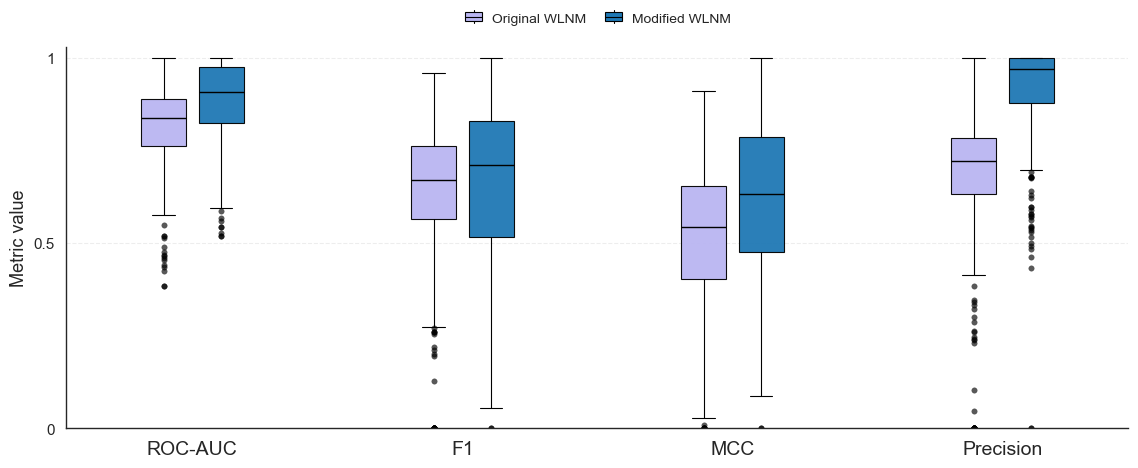

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.1,
)


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    candidates = [start, *start.parents]

    # Fallback for notebooks launched outside the repository.
    fallback = Path(
        "/Users/acw792/Developer/qmul-phd-framework"
    )

    if fallback not in candidates:
        candidates.append(fallback)

    for candidate in candidates:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the qmul-phd-framework repository."
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final configuration
# ============================================================

TRAIN_RATIO_TARGET = 90
CLASSIFICATION_THRESHOLD = 0.50
NODES_THRESHOLD = 0

# Tukey is applied across 50 runs.
# At least 50% must remain: ceil(50 × 0.5) = 25 runs.
EXPECTED_RUNS = 50
MINIMUM_RETAINED_FRACTION = 0.50
MINIMUM_RETAINED_RUNS = 25

ELIGIBILITY_MODE = "role_only"
MASS_ELIGIBILITY_ENABLED = False
CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)

assert minimum_retained_runs == int(
    np.ceil(
        EXPECTED_RUNS
        * MINIMUM_RETAINED_FRACTION
    )
)


# ============================================================
# Result roots
# ============================================================

ORIGINAL_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_original_50x290_train90_thresh0p50_"
        "legacy_uppertriangular_checkconnfalse_adaptivefalse_Apocrita"
    )
)

DIR_NEG_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_sweep_train_ratios_"
        "10-90_pseudo_properties_Apocrita_neg_const"
    )
)


# ============================================================
# Tukey-filtered figure inputs
# ============================================================

ORIGINAL_INPUT = (
    ORIGINAL_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train90_after_tukey.csv"
)

DIR_NEG_INPUT = (
    DIR_NEG_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train90_after_tukey.csv"
)

FOODWEB_CSV = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)


# ============================================================
# Publication output
# ============================================================

OUT_DIR = (
    DIR_NEG_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_STEM = (
    "figure_3_original_vs_extended_wlnm_"
    "four_metrics_train90_thresh0p50_"
    "tukey_iqr1p5_min50pct"
)

PNG_PATH = OUT_DIR / f"{OUTPUT_STEM}.png"
SVG_PATH = OUT_DIR / f"{OUTPUT_STEM}.svg"
PDF_PATH = OUT_DIR / f"{OUTPUT_STEM}.pdf"

SUMMARY_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_summary.csv"
)

RETENTION_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_retention_counts.csv"
)


# ============================================================
# Metrics
# ============================================================

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
]

METRIC_ORDER = [
    metric
    for metric, _ in METRIC_SPECS
]

METRIC_LABELS = dict(METRIC_SPECS)

VERSION_ORDER = [
    "original",
    "dir_neg",
]

VERSION_LABELS = {
    "original": "Original WLNM",
    "dir_neg": "Modified WLNM",
}

VERSION_PALETTE = {
    "original": "#BAB6F2",
    "dir_neg": "#1F78B4",
}

SHOW_WEB_LEVEL_FLIERS = True


# ============================================================
# Validate required inputs
# ============================================================

required_inputs = {
    "Corrected WLNM_original Tukey input": ORIGINAL_INPUT,
    "Final WLNM_dir_neg Tukey input": DIR_NEG_INPUT,
    "Food-web metadata": FOODWEB_CSV,
}

missing_inputs = [
    f"{label}:\n  {path}"
    for label, path in required_inputs.items()
    if not path.is_file()
]

if missing_inputs:
    raise FileNotFoundError(
        "The following required inputs are missing:\n\n"
        + "\n\n".join(missing_inputs)
        + (
            "\n\nThe results must first be processed with "
            "apply_wlnm_tukey_retention.py."
        )
    )

print(f"[INFO] Repository: {REPO_ROOT}")
print("[INFO] Using Tukey-filtered inputs:")
print(f"  Original: {ORIGINAL_INPUT}")
print(f"  Directed-negative: {DIR_NEG_INPUT}")


# ============================================================
# Helpers
# ============================================================

def normalize_fw_label(name):
    name = str(name).strip()

    for suffix in [
        ".mat",
        ".csv",
    ]:
        if name.endswith(suffix):
            name = name[: -len(suffix)]

    name = name.replace(" ", "_")

    for token in [
        "_results_",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(token, "_")

    return "_".join(
        part
        for part in name.split("_")
        if part
    ).lower()


def load_tukey_figure_input(
    path,
    version,
):
    df = pd.read_csv(path)

    required_columns = {
        "Foodweb",
        "Metric",
        "MetricFamily",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
        "TrainRatio",
        "Threshold",
    }

    missing_columns = required_columns.difference(
        df.columns
    )

    if missing_columns:
        raise ValueError(
            f"{path.name} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    numeric_columns = [
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
        "TrainRatio",
        "Threshold",
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

    # --------------------------------------------------------
    # Validate the Tukey preprocessing configuration
    # --------------------------------------------------------

    target_rows = df[
        df["Metric"].isin(METRIC_ORDER)
        & df["MetricFamily"].eq("predictive")
        & np.isclose(
            df["TrainRatio"],
            TRAIN_RATIO_TARGET,
            atol=1e-8,
            equal_nan=False,
        )
        & np.isclose(
            df["Threshold"],
            CLASSIFICATION_THRESHOLD,
            atol=1e-9,
            equal_nan=False,
        )
    ].copy()

    if target_rows.empty:
        raise ValueError(
            f"No predictive rows for train ratio "
            f"{TRAIN_RATIO_TARGET} and threshold "
            f"{CLASSIFICATION_THRESHOLD} were found in:\n{path}"
        )

    observed_minimums = set(
        target_rows["MinimumRetainedRuns"]
        .dropna()
        .astype(int)
        .unique()
    )

    if observed_minimums != {
        MINIMUM_RETAINED_RUNS
    }:
        raise ValueError(
            f"{path.name} was not processed with the "
            f"expected minimum of "
            f"{MINIMUM_RETAINED_RUNS} retained runs. "
            f"Found: {sorted(observed_minimums)}"
        )

    invalid_minimum_rows = target_rows[
        target_rows["MeetsMinimumRetainedRuns"].eq(1)
        & target_rows["RetainedRunsAfterTukey"].lt(
            MINIMUM_RETAINED_RUNS
        )
    ]

    if not invalid_minimum_rows.empty:
        display(
            invalid_minimum_rows[
                [
                    "Foodweb",
                    "Metric",
                    "RetainedRunsAfterTukey",
                    "MinimumRetainedRuns",
                    "MeetsMinimumRetainedRuns",
                ]
            ]
        )

        raise ValueError(
            f"{path.name} marks groups with fewer than "
            f"{MINIMUM_RETAINED_RUNS} runs as retained."
        )

    # --------------------------------------------------------
    # Keep valid Tukey-filtered food-web metric summaries
    # --------------------------------------------------------

    df = target_rows[
        target_rows["MinimumRetainedRuns"].eq(
            MINIMUM_RETAINED_RUNS
        )
        & target_rows["RetainedRunsAfterTukey"].ge(
            MINIMUM_RETAINED_RUNS
        )
        & target_rows["MeetsMinimumRetainedRuns"].eq(1)
        & target_rows["MeanAfterTukey"].notna()
    ].copy()

    if df.empty:
        raise ValueError(
            f"No valid Tukey-filtered rows remain in:\n{path}"
        )

    df["Version"] = version
    df["Value"] = df["MeanAfterTukey"]

    df["FW_KEY"] = (
        df["Foodweb"]
        .apply(normalize_fw_label)
    )

    duplicate_mask = df.duplicated(
        subset=[
            "FW_KEY",
            "Version",
            "Metric",
        ],
        keep=False,
    )

    if duplicate_mask.any():
        duplicated = (
            df.loc[
                duplicate_mask,
                [
                    "Foodweb",
                    "Version",
                    "Metric",
                ],
            ]
            .sort_values(
                [
                    "Metric",
                    "Foodweb",
                ]
            )
        )

        display(duplicated)

        raise ValueError(
            f"Duplicated foodweb–metric rows found in:\n{path}"
        )

    minimum_observed = int(
        df["RetainedRunsAfterTukey"].min()
    )

    maximum_observed = int(
        df["RetainedRunsAfterTukey"].max()
    )

    print(
        f"[INFO] {version}: Tukey requirement validated "
        f"(at least {MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS} runs)."
    )

    print(
        f"       Actual retained-run range: "
        f"{minimum_observed}–{maximum_observed}"
    )

    print(
        f"       Retained food webs: "
        f"{df['FW_KEY'].nunique()}"
    )

    return df


# ============================================================
# Load final Tukey-filtered values
# ============================================================

original_df = load_tukey_figure_input(
    ORIGINAL_INPUT,
    version="original",
)

dir_neg_df = load_tukey_figure_input(
    DIR_NEG_INPUT,
    version="dir_neg",
)

combined_df = pd.concat(
    [
        original_df,
        dir_neg_df,
    ],
    ignore_index=True,
)


# ============================================================
# Apply node-count filter
# ============================================================

metadata_df = pd.read_csv(
    FOODWEB_CSV
)

metadata_df.columns = [
    column.strip()
    for column in metadata_df.columns
]

foodweb_column = next(
    (
        column
        for column in metadata_df.columns
        if column.lower() == "foodweb"
    ),
    None,
)

nodes_column = next(
    (
        column
        for column in metadata_df.columns
        if column.lower() in {
            "nodes",
            "n_nodes",
            "num_nodes",
            "nodecount",
            "s",
        }
    ),
    None,
)

if (
    foodweb_column is None
    or nodes_column is None
):
    raise ValueError(
        "Could not identify Foodweb and Nodes "
        "columns in the metadata file."
    )

metadata_df[nodes_column] = pd.to_numeric(
    metadata_df[nodes_column],
    errors="coerce",
)

metadata_df["FW_KEY"] = (
    metadata_df[foodweb_column]
    .apply(normalize_fw_label)
)

metadata_df = (
    metadata_df[
        [
            "FW_KEY",
            foodweb_column,
            nodes_column,
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"]
    )
)

allowed_fw_keys = set(
    metadata_df.loc[
        metadata_df[nodes_column]
        >= NODES_THRESHOLD,
        "FW_KEY",
    ]
)

print(
    f"[INFO] Food webs satisfying "
    f"Nodes >= {NODES_THRESHOLD}: "
    f"{len(allowed_fw_keys)}"
)

combined_df = combined_df[
    combined_df["FW_KEY"]
    .isin(allowed_fw_keys)
].copy()

if combined_df.empty:
    raise RuntimeError(
        "No retained food-web metrics remain "
        "after the node-count filter."
    )


# ============================================================
# Enforce paired food webs separately per metric
# ============================================================

paired_frames = []
pairing_rows = []

for metric in METRIC_ORDER:
    metric_df = combined_df[
        combined_df["Metric"].eq(metric)
    ].copy()

    original_keys = set(
        metric_df.loc[
            metric_df["Version"].eq("original"),
            "FW_KEY",
        ]
    )

    dir_neg_keys = set(
        metric_df.loc[
            metric_df["Version"].eq("dir_neg"),
            "FW_KEY",
        ]
    )

    common_keys = (
        original_keys
        .intersection(dir_neg_keys)
    )

    pairing_rows.append(
        {
            "Metric": METRIC_LABELS[metric],
            "Original retained food webs": len(
                original_keys
            ),
            "Directed-negative retained food webs": len(
                dir_neg_keys
            ),
            "Paired food webs": len(
                common_keys
            ),
            "Original-only food webs": len(
                original_keys
                - dir_neg_keys
            ),
            "Directed-negative-only food webs": len(
                dir_neg_keys
                - original_keys
            ),
        }
    )

    paired_metric_df = metric_df[
        metric_df["FW_KEY"].isin(
            common_keys
        )
    ].copy()

    paired_frames.append(
        paired_metric_df
    )

plot_df = pd.concat(
    paired_frames,
    ignore_index=True,
)

if plot_df.empty:
    raise RuntimeError(
        "No paired food webs remain for plotting."
    )

pairing_table = pd.DataFrame(
    pairing_rows
)

print(
    "\n=== Retained and paired food webs "
    "by metric ==="
)

display(pairing_table)


# ============================================================
# Retention details
# ============================================================

retention_table = (
    plot_df
    .groupby(
        [
            "Version",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        MinimumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetainedRuns=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "max",
        ),
    )
)

retention_table["Version"] = (
    retention_table["Version"]
    .map(VERSION_LABELS)
)

retention_table["Metric"] = (
    retention_table["Metric"]
    .map(METRIC_LABELS)
)

retention_table = retention_table[
    [
        "Version",
        "Metric",
        "FoodWebs",
        "MinimumRetainedRuns",
        "MedianRetainedRuns",
        "MaximumRetainedRuns",
    ]
]

print(
    "\n=== Tukey retention details "
    "for paired food webs ==="
)

display(retention_table)


# ============================================================
# Web-level summary
# ============================================================

summary_table = (
    plot_df
    .groupby(
        [
            "Version",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        Mean=(
            "Value",
            "mean",
        ),
        Median=(
            "Value",
            "median",
        ),
        SD=(
            "Value",
            "std",
        ),
        Variance=(
            "Value",
            "var",
        ),
    )
)

summary_table["Version"] = (
    summary_table["Version"]
    .map(VERSION_LABELS)
)

summary_table["Metric"] = (
    summary_table["Metric"]
    .map(METRIC_LABELS)
)

for column in [
    "Mean",
    "Median",
    "SD",
    "Variance",
]:
    summary_table[column] = (
        summary_table[column]
        .round(4)
    )

print(
    "\n=== Tukey-filtered web-level "
    "predictive metric summary ==="
)

display(summary_table)


# ============================================================
# Custom miniature boxplot legend
# ============================================================

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle["facecolor"]

        edgecolor = orig_handle.get(
            "edgecolor",
            "black",
        )

        linewidth = orig_handle.get(
            "linewidth",
            0.6,
        )

        center_x = (
            xdescent
            + 0.5 * width
        )

        center_y = (
            ydescent
            + 0.44 * height
        )

        box_width = (
            0.8 * width
        )

        box_height = (
            0.8 * height
        )

        box_x = (
            center_x
            - box_width / 2
        )

        box_y = (
            center_y
            - box_height / 2
        )

        whisker_top_y = (
            box_y
            + box_height
            + 0.18 * height
        )

        whisker_bottom_y = (
            box_y
            - 0.18 * height
        )

        box = Rectangle(
            (
                box_x,
                box_y,
            ),
            box_width,
            box_height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [
                box_x,
                box_x + box_width,
            ],
            [
                center_y,
                center_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        upper_whisker = Line2D(
            [
                center_x,
                center_x,
            ],
            [
                box_y + box_height,
                whisker_top_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        lower_whisker = Line2D(
            [
                center_x,
                center_x,
            ],
            [
                whisker_bottom_y,
                box_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [
            box,
            median,
            upper_whisker,
            lower_whisker,
        ]


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(11.5, 4.8)
)

group_gap = 1.5

group_centers = (
    1.0
    + np.arange(
        len(METRIC_SPECS)
    )
    * group_gap
)

offsets = {
    "original": -0.16,
    "dir_neg": 0.16,
}

box_width = 0.25

for version in VERSION_ORDER:
    version_data = []
    version_positions = []

    for metric_index, (
        metric,
        metric_label,
    ) in enumerate(METRIC_SPECS):
        values = (
            plot_df.loc[
                (
                    plot_df["Version"].eq(
                        version
                    )
                )
                & (
                    plot_df["Metric"].eq(
                        metric
                    )
                ),
                "Value",
            ]
            .dropna()
            .to_numpy()
        )

        if len(values) == 0:
            continue

        version_data.append(
            values
        )

        version_positions.append(
            group_centers[metric_index]
            + offsets[version]
        )

    if not version_data:
        raise RuntimeError(
            f"No plotting values found for version: {version}"
        )

    ax.boxplot(
        version_data,
        positions=version_positions,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        boxprops={
            "facecolor": VERSION_PALETTE[version],
            "edgecolor": "black",
            "linewidth": 0.8,
            "alpha": 0.95,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.0,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.2,
            "alpha": 0.65,
        },
    )


# ============================================================
# Axes and legend
# ============================================================

legend_handles = [
    {
        "facecolor": VERSION_PALETTE[version],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for version in VERSION_ORDER
]

ax.set_xlim(
    group_centers[0] - 0.7,
    group_centers[-1] + 0.7,
)

ax.set_ylim(
    0,
    1.03,
)

ax.set_xticks(
    group_centers,
    labels=[
        metric_label
        for _, metric_label in METRIC_SPECS
    ],
)

plt.setp(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=14,
)

ax.set_ylabel(
    "Metric value",
    fontsize=13,
)

ax.set_xlabel("")

ax.set_yticks(
    [
        0,
        0.5,
        1.0,
    ]
)

ax.set_yticklabels(
    [
        "0",
        "0.5",
        "1",
    ]
)

ax.tick_params(
    axis="y",
    labelsize=11,
)

ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.35,
)

ax.legend(
    handles=legend_handles,
    labels=[
        VERSION_LABELS[version]
        for version in VERSION_ORDER
    ],
    handler_map={
        dict: HandlerMiniBoxplot()
    },
    loc="lower center",
    bbox_to_anchor=(
        0.5,
        1.03,
    ),
    ncol=len(VERSION_ORDER),
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
    columnspacing=1.2,
)

sns.despine(
    ax=ax
)

plt.tight_layout()


# ============================================================
# Export
# ============================================================

fig.savefig(
    PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    SVG_PATH,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)

summary_table.to_csv(
    SUMMARY_PATH,
    index=False,
)

retention_table.to_csv(
    RETENTION_PATH,
    index=False,
)

print(
    "\n[INFO] Saved publication-ready outputs:"
)

print(f"  PNG: {PNG_PATH}")
print(f"  SVG: {SVG_PATH}")
print(f"  PDF: {PDF_PATH}")
print(f"  Summary: {SUMMARY_PATH}")
print(f"  Retention counts: {RETENTION_PATH}")

print(
    "\n[INFO] Final directed configuration:"
)

print(
    f"  check_connectivity={CHECK_CONNECTIVITY}"
)

print(
    f"  adaptive_connectivity={ADAPTIVE_CONNECTIVITY}"
)

print(
    f"  classification_threshold="
    f"{CLASSIFICATION_THRESHOLD}"
)

print(
    f"  retention_protocol={PROTOCOL_NAME}"
)

print(
    f"  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)

plt.show()

[INFO] Repository: /Users/acw792/Developer/qmul-phd-framework
[INFO] Using Tukey-filtered inputs:
  Original: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_original_100x290_train10-90_thresh0p50_Apocrita_20260916_221905/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
  Directed-negative: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
  Ecosystem metadata: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv
[INFO] original: Tukey requirement validated (at least 25/100 runs).
       Actual retained-run range: 63–100
       Retained food webs: 290
[INFO] dir_neg: Tukey requirement validated (at least 25/100 runs).
       Actual retained-run range: 75–100


,Metric,Original retained food webs,Directed-negative retained food webs,Paired food webs,Original-only food webs,Directed-negative-only food webs
0,ROC-AUC,290,290,290,0,0
1,F1,290,290,290,0,0
2,MCC,290,290,290,0,0
3,Precision,290,290,290,0,0


[INFO] Validated unique FW_KEY × Version × Metric observations.

=== Tukey retention details for paired food webs ===


,Version,Metric,FoodWebs,MinimumRetainedRuns,MedianRetainedRuns,MaximumRetainedRuns
0,Modified WLNM,F1,290,76,99.0,100
1,Modified WLNM,Precision,290,75,98.0,100
2,Modified WLNM,ROC-AUC,290,75,98.0,100
3,Modified WLNM,MCC,290,76,99.0,100
4,Original WLNM,F1,290,76,99.0,100
5,Original WLNM,Precision,290,76,100.0,100
6,Original WLNM,ROC-AUC,290,89,99.0,100
7,Original WLNM,MCC,290,63,99.0,100



=== Tukey-filtered web-level predictive metric summary ===


,Version,Metric,FoodWebs,Mean,Median,SD,Variance
0,Modified WLNM,F1,290,0.6755,0.7301,0.2271,0.0516
1,Modified WLNM,Precision,290,0.9376,0.9723,0.1173,0.0138
2,Modified WLNM,ROC-AUC,290,0.8953,0.9130,0.0988,0.0098
3,Modified WLNM,MCC,290,0.6441,0.6647,0.2089,0.0436
4,Original WLNM,F1,290,0.6255,0.6686,0.1880,0.0353
5,Original WLNM,Precision,290,0.6714,0.7187,0.1980,0.0392
6,Original WLNM,ROC-AUC,290,0.8074,0.8355,0.1099,0.0121
7,Original WLNM,MCC,290,0.5000,0.5437,0.2025,0.0410


[INFO] Ecosystem metadata validated: 290 unique FW_KEY values.

[INFO] Precision observations before ecosystem merge:
  Original WLNM: 290 paired food webs
  Modified WLNM: 290 paired food webs
[INFO] Precision pairing validated within every ecosystem.

=== Precision by ecosystem and version ===


,Ecosystem,Version,FoodWebs,Median,Q1,Q3,Minimum,Maximum
0,Lakes,Original WLNM,55,0.7277,0.6812,0.7623,0.0467,0.9184
1,Lakes,Modified WLNM,55,1.0000,1.0000,1.0000,0.5450,1.0000
2,Streams,Original WLNM,28,0.6691,0.6289,0.7035,0.4941,0.8036
3,Streams,Modified WLNM,28,1.0000,0.9874,1.0000,0.0000,1.0000
4,Marine,Original WLNM,134,0.7005,0.6253,0.7764,0.0000,1.0000
5,Marine,Modified WLNM,134,0.9734,0.9296,1.0000,0.4850,1.0000
6,Terrestrial aboveground,Original WLNM,21,0.5691,0.2653,0.5936,0.0000,0.6123
7,Terrestrial aboveground,Modified WLNM,21,0.9193,0.8550,0.9924,0.7743,1.0000
8,Terrestrial belowground,Original WLNM,52,0.7823,0.7646,0.7966,0.6695,0.8424
9,Terrestrial belowground,Modified WLNM,52,0.9238,0.9161,0.9330,0.8966,0.9868



[INFO] Saved publication-ready outputs:
  PNG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/figure_3_original_vs_modified_wlnm_four_metrics_and_precision_by_ecosystem_two_panel_horizontal_train90_thresh0p50_tukey_iqr1p5_min25runs.png
  SVG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/figure_3_original_vs_modified_wlnm_four_metrics_and_precision_by_ecosystem_two_panel_horizontal_train90_thresh0p50_tukey_iqr1p5_min25runs.svg
  PDF: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/figure_3_original_vs_mod

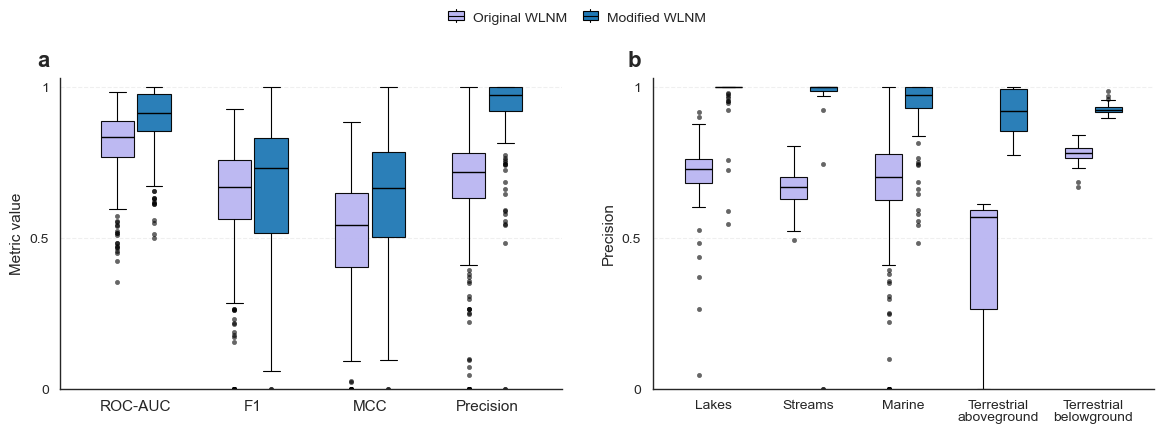

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.1,
)


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    candidates = [
        start,
        *start.parents,
    ]

    # Fallback for notebooks launched outside the repository.
    fallback = Path(
        "/Users/acw792/Developer/qmul-phd-framework"
    )

    if fallback not in candidates:
        candidates.append(fallback)

    for candidate in candidates:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the qmul-phd-framework repository."
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final configuration
# ============================================================

TRAIN_RATIO_TARGET = 90
CLASSIFICATION_THRESHOLD = 0.50
NODES_THRESHOLD = 0

# Tukey is applied across 100 runs.
# At least 25% must remain: ceil(100 × 0.25) = 25 runs.
EXPECTED_RUNS = 100
MINIMUM_RETAINED_FRACTION = 0.25
MINIMUM_RETAINED_RUNS = 25

ELIGIBILITY_MODE = "role_only"
MASS_ELIGIBILITY_ENABLED = False
CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min25runs_threshold0p50_v1"
)

assert MINIMUM_RETAINED_RUNS == int(
    np.ceil(
        EXPECTED_RUNS
        * MINIMUM_RETAINED_FRACTION
    )
)


# ============================================================
# Result roots
# ============================================================

ORIGINAL_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_original_100x290_train10-90_thresh0p50_"
        "Apocrita_20260916_221905"
    )
)

DIR_NEG_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_trophicv2_"
        "100x290_train10-90_Apocrita_20260910_011848"
    )
)


# ============================================================
# Tukey-filtered figure inputs
# ============================================================

ORIGINAL_INPUT = (
    ORIGINAL_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train90_after_tukey.csv"
)

DIR_NEG_INPUT = (
    DIR_NEG_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train90_after_tukey.csv"
)

FOODWEB_CSV = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)


# ============================================================
# Publication output
# ============================================================

OUT_DIR = (
    DIR_NEG_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_STEM = (
    "figure_3_original_vs_modified_wlnm_"
    "four_metrics_and_precision_by_ecosystem_"
    "two_panel_horizontal_train90_thresh0p50_"
    "tukey_iqr1p5_min25runs"
)

PNG_PATH = OUT_DIR / f"{OUTPUT_STEM}.png"
SVG_PATH = OUT_DIR / f"{OUTPUT_STEM}.svg"
PDF_PATH = OUT_DIR / f"{OUTPUT_STEM}.pdf"

SUMMARY_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_summary.csv"
)

RETENTION_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_retention_counts.csv"
)


# ============================================================
# Metrics
# ============================================================

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
]

METRIC_ORDER = [
    metric
    for metric, _ in METRIC_SPECS
]

METRIC_LABELS = dict(
    METRIC_SPECS
)

VERSION_ORDER = [
    "original",
    "dir_neg",
]

VERSION_LABELS = {
    "original": "Original WLNM",
    "dir_neg": "Modified WLNM",
}

VERSION_PALETTE = {
    "original": "#BAB6F2",
    "dir_neg": "#1F78B4",
}

SHOW_WEB_LEVEL_FLIERS = True


# ============================================================
# Ecosystem configuration for panel (b)
# ============================================================

ECOSYSTEM_ORDER = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ECOSYSTEM_LABELS = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}


# ============================================================
# Validate required inputs
# ============================================================

required_inputs = {
    "Corrected WLNM_original Tukey input": ORIGINAL_INPUT,
    "Final WLNM_dir_neg Tukey input": DIR_NEG_INPUT,
    "Food-web metadata": FOODWEB_CSV,
}

missing_inputs = [
    f"{label}:\n  {path}"
    for label, path in required_inputs.items()
    if not path.is_file()
]

if missing_inputs:
    raise FileNotFoundError(
        "The following required inputs are missing:\n\n"
        + "\n\n".join(missing_inputs)
        + (
            "\n\nThe results must first be processed with "
            "apply_wlnm_tukey_retention.py."
        )
    )

print(f"[INFO] Repository: {REPO_ROOT}")
print("[INFO] Using Tukey-filtered inputs:")
print(f"  Original: {ORIGINAL_INPUT}")
print(f"  Directed-negative: {DIR_NEG_INPUT}")
print(f"  Ecosystem metadata: {FOODWEB_CSV}")


# ============================================================
# Helpers used by original comparison
# ============================================================

def normalize_fw_label(name):
    name = str(name).strip()

    for suffix in [
        ".mat",
        ".csv",
    ]:
        if name.endswith(suffix):
            name = name[:-len(suffix)]

    name = name.replace(
        " ",
        "_",
    )

    for token in [
        "_results_",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(
            token,
            "_",
        )

    return "_".join(
        part
        for part in name.split("_")
        if part
    ).lower()


# ============================================================
# Ecosystem metadata helpers
# ============================================================

def normalize_colname(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb(value):
    value = Path(
        str(value).strip()
    ).name

    for extension in (
        ".mat",
        ".csv",
    ):
        if value.lower().endswith(
            extension
        ):
            value = value[
                :-len(extension)
            ].rstrip()

    for suffix in (
        "_tax_mass",
        "_taxmass",
    ):
        if value.lower().endswith(
            suffix
        ):
            value = value[
                :-len(suffix)
            ].rstrip()

    return " ".join(
        value.casefold().split()
    )


def normalize_ecosystem(value):
    return " ".join(
        str(value)
        .strip()
        .casefold()
        .split()
    )


def load_tukey_figure_input(
    path,
    version,
):
    df = pd.read_csv(
        path
    )

    required_columns = {
        "Foodweb",
        "Metric",
        "MetricFamily",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
        "TrainRatio",
        "Threshold",
    }

    missing_columns = (
        required_columns.difference(
            df.columns
        )
    )

    if missing_columns:
        raise ValueError(
            f"{path.name} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    numeric_columns = [
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
        "TrainRatio",
        "Threshold",
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

    # --------------------------------------------------------
    # Validate the Tukey preprocessing configuration
    # --------------------------------------------------------

    target_rows = df[
        df["Metric"].isin(
            METRIC_ORDER
        )
        & df["MetricFamily"].eq(
            "predictive"
        )
        & np.isclose(
            df["TrainRatio"],
            TRAIN_RATIO_TARGET,
            atol=1e-8,
            equal_nan=False,
        )
        & np.isclose(
            df["Threshold"],
            CLASSIFICATION_THRESHOLD,
            atol=1e-9,
            equal_nan=False,
        )
    ].copy()

    if target_rows.empty:
        raise ValueError(
            f"No predictive rows for train ratio "
            f"{TRAIN_RATIO_TARGET} and threshold "
            f"{CLASSIFICATION_THRESHOLD} were found in:\n"
            f"{path}"
        )

    observed_minimums = set(
        target_rows[
            "MinimumRetainedRuns"
        ]
        .dropna()
        .astype(int)
        .unique()
    )

    if observed_minimums != {
        MINIMUM_RETAINED_RUNS
    }:
        raise ValueError(
            f"{path.name} was not processed with the "
            f"expected minimum of "
            f"{MINIMUM_RETAINED_RUNS} retained runs. "
            f"Found: {sorted(observed_minimums)}"
        )

    invalid_minimum_rows = target_rows[
        target_rows[
            "MeetsMinimumRetainedRuns"
        ].eq(1)
        & target_rows[
            "RetainedRunsAfterTukey"
        ].lt(
            MINIMUM_RETAINED_RUNS
        )
    ]

    if not invalid_minimum_rows.empty:
        display(
            invalid_minimum_rows[
                [
                    "Foodweb",
                    "Metric",
                    "RetainedRunsAfterTukey",
                    "MinimumRetainedRuns",
                    "MeetsMinimumRetainedRuns",
                ]
            ]
        )

        raise ValueError(
            f"{path.name} marks groups with fewer than "
            f"{MINIMUM_RETAINED_RUNS} runs as retained."
        )

    # --------------------------------------------------------
    # Keep valid Tukey-filtered food-web metric summaries
    # --------------------------------------------------------

    df = target_rows[
        target_rows[
            "MinimumRetainedRuns"
        ].eq(
            MINIMUM_RETAINED_RUNS
        )
        & target_rows[
            "RetainedRunsAfterTukey"
        ].ge(
            MINIMUM_RETAINED_RUNS
        )
        & target_rows[
            "MeetsMinimumRetainedRuns"
        ].eq(1)
        & target_rows[
            "MeanAfterTukey"
        ].notna()
    ].copy()

    if df.empty:
        raise ValueError(
            f"No valid Tukey-filtered rows remain in:\n"
            f"{path}"
        )

    df["Version"] = version

    df["Value"] = (
        df[
            "MeanAfterTukey"
        ]
    )

    df["FW_KEY"] = (
        df["Foodweb"]
        .apply(
            normalize_fw_label
        )
    )

    duplicate_mask = df.duplicated(
        subset=[
            "FW_KEY",
            "Version",
            "Metric",
        ],
        keep=False,
    )

    if duplicate_mask.any():
        duplicated = (
            df.loc[
                duplicate_mask,
                [
                    "Foodweb",
                    "Version",
                    "Metric",
                ],
            ]
            .sort_values(
                [
                    "Metric",
                    "Foodweb",
                ]
            )
        )

        display(
            duplicated
        )

        raise ValueError(
            f"Duplicated foodweb–metric rows found in:\n"
            f"{path}"
        )

    minimum_observed = int(
        df[
            "RetainedRunsAfterTukey"
        ].min()
    )

    maximum_observed = int(
        df[
            "RetainedRunsAfterTukey"
        ].max()
    )

    print(
        f"[INFO] {version}: Tukey requirement validated "
        f"(at least "
        f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS} runs)."
    )

    print(
        f"       Actual retained-run range: "
        f"{minimum_observed}–{maximum_observed}"
    )

    print(
        f"       Retained food webs: "
        f"{df['FW_KEY'].nunique()}"
    )

    return df


# ============================================================
# Load final Tukey-filtered values
# ============================================================

original_df = load_tukey_figure_input(
    ORIGINAL_INPUT,
    version="original",
)

dir_neg_df = load_tukey_figure_input(
    DIR_NEG_INPUT,
    version="dir_neg",
)

combined_df = pd.concat(
    [
        original_df,
        dir_neg_df,
    ],
    ignore_index=True,
)


# ============================================================
# Apply node-count filter
# ============================================================

metadata_df = pd.read_csv(
    FOODWEB_CSV
)

metadata_df.columns = [
    column.strip()
    for column in metadata_df.columns
]

foodweb_column = next(
    (
        column
        for column in metadata_df.columns
        if column.lower() == "foodweb"
    ),
    None,
)

nodes_column = next(
    (
        column
        for column in metadata_df.columns
        if column.lower() in {
            "nodes",
            "n_nodes",
            "num_nodes",
            "nodecount",
            "s",
        }
    ),
    None,
)

if (
    foodweb_column is None
    or nodes_column is None
):
    raise ValueError(
        "Could not identify Foodweb and Nodes "
        "columns in the metadata file."
    )

metadata_df[
    nodes_column
] = pd.to_numeric(
    metadata_df[
        nodes_column
    ],
    errors="coerce",
)

metadata_df["FW_KEY"] = (
    metadata_df[
        foodweb_column
    ]
    .apply(
        normalize_fw_label
    )
)

metadata_df = (
    metadata_df[
        [
            "FW_KEY",
            foodweb_column,
            nodes_column,
        ]
    ]
    .drop_duplicates(
        subset=[
            "FW_KEY"
        ]
    )
)

allowed_fw_keys = set(
    metadata_df.loc[
        metadata_df[
            nodes_column
        ] >= NODES_THRESHOLD,
        "FW_KEY",
    ]
)

print(
    f"[INFO] Food webs satisfying "
    f"Nodes >= {NODES_THRESHOLD}: "
    f"{len(allowed_fw_keys)}"
)

combined_df = combined_df[
    combined_df[
        "FW_KEY"
    ].isin(
        allowed_fw_keys
    )
].copy()

if combined_df.empty:
    raise RuntimeError(
        "No retained food-web metrics remain "
        "after the node-count filter."
    )


# ============================================================
# Enforce paired food webs separately per metric
# ============================================================

paired_frames = []
pairing_rows = []

for metric in METRIC_ORDER:
    metric_df = combined_df[
        combined_df[
            "Metric"
        ].eq(
            metric
        )
    ].copy()

    original_keys = set(
        metric_df.loc[
            metric_df[
                "Version"
            ].eq(
                "original"
            ),
            "FW_KEY",
        ]
    )

    dir_neg_keys = set(
        metric_df.loc[
            metric_df[
                "Version"
            ].eq(
                "dir_neg"
            ),
            "FW_KEY",
        ]
    )

    common_keys = (
        original_keys
        .intersection(
            dir_neg_keys
        )
    )

    pairing_rows.append(
        {
            "Metric":
                METRIC_LABELS[
                    metric
                ],
            "Original retained food webs":
                len(
                    original_keys
                ),
            "Directed-negative retained food webs":
                len(
                    dir_neg_keys
                ),
            "Paired food webs":
                len(
                    common_keys
                ),
            "Original-only food webs":
                len(
                    original_keys
                    - dir_neg_keys
                ),
            "Directed-negative-only food webs":
                len(
                    dir_neg_keys
                    - original_keys
                ),
        }
    )

    paired_metric_df = metric_df[
        metric_df[
            "FW_KEY"
        ].isin(
            common_keys
        )
    ].copy()

    paired_frames.append(
        paired_metric_df
    )

plot_df = pd.concat(
    paired_frames,
    ignore_index=True,
)

if plot_df.empty:
    raise RuntimeError(
        "No paired food webs remain for plotting."
    )

pairing_table = pd.DataFrame(
    pairing_rows
)

print(
    "\n=== Retained and paired food webs "
    "by metric ==="
)

display(
    pairing_table
)


# ============================================================
# Explicit duplicate validation for final plot_df
# ============================================================

plot_duplicate_mask = plot_df.duplicated(
    subset=[
        "FW_KEY",
        "Version",
        "Metric",
    ],
    keep=False,
)

if plot_duplicate_mask.any():
    duplicated_plot_rows = (
        plot_df.loc[
            plot_duplicate_mask,
            [
                "Foodweb",
                "FW_KEY",
                "Version",
                "Metric",
                "Value",
            ],
        ]
        .sort_values(
            [
                "Metric",
                "Version",
                "Foodweb",
            ]
        )
    )

    display(
        duplicated_plot_rows
    )

    raise ValueError(
        "Duplicated FW_KEY × Version × Metric "
        "combinations were found in plot_df."
    )

print(
    "[INFO] Validated unique "
    "FW_KEY × Version × Metric observations."
)


# ============================================================
# Retention details
# ============================================================

retention_table = (
    plot_df
    .groupby(
        [
            "Version",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        MinimumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetainedRuns=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "max",
        ),
    )
)

retention_table[
    "Version"
] = (
    retention_table[
        "Version"
    ]
    .map(
        VERSION_LABELS
    )
)

retention_table[
    "Metric"
] = (
    retention_table[
        "Metric"
    ]
    .map(
        METRIC_LABELS
    )
)

retention_table = retention_table[
    [
        "Version",
        "Metric",
        "FoodWebs",
        "MinimumRetainedRuns",
        "MedianRetainedRuns",
        "MaximumRetainedRuns",
    ]
]

print(
    "\n=== Tukey retention details "
    "for paired food webs ==="
)

display(
    retention_table
)


# ============================================================
# Web-level summary
# ============================================================

summary_table = (
    plot_df
    .groupby(
        [
            "Version",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        Mean=(
            "Value",
            "mean",
        ),
        Median=(
            "Value",
            "median",
        ),
        SD=(
            "Value",
            "std",
        ),
        Variance=(
            "Value",
            "var",
        ),
    )
)

summary_table[
    "Version"
] = (
    summary_table[
        "Version"
    ]
    .map(
        VERSION_LABELS
    )
)

summary_table[
    "Metric"
] = (
    summary_table[
        "Metric"
    ]
    .map(
        METRIC_LABELS
    )
)

for column in [
    "Mean",
    "Median",
    "SD",
    "Variance",
]:
    summary_table[
        column
    ] = (
        summary_table[
            column
        ]
        .round(4)
    )

print(
    "\n=== Tukey-filtered web-level "
    "predictive metric summary ==="
)

display(
    summary_table
)


# ============================================================
# Load and validate ecosystem metadata for panel (b)
# ============================================================

ecosystem_metadata_raw = pd.read_csv(
    FOODWEB_CSV
)

ecosystem_metadata_raw.columns = [
    str(column).strip()
    for column
    in ecosystem_metadata_raw.columns
]

ecosystem_norm_map = {
    normalize_colname(
        column
    ): column
    for column
    in ecosystem_metadata_raw.columns
}

foodweb_meta_col = ecosystem_norm_map.get(
    "foodweb"
)

ecosystem_meta_col = ecosystem_norm_map.get(
    "ecosystemtype"
)

node_candidates = {
    "nnodes",
    "numnodes",
    "nodes",
    "nodecount",
    "n",
    "s",
    "species",
    "numspecies",
    "numberofspecies",
    "speciescount",
}

node_meta_col = next(
    (
        ecosystem_norm_map[
            candidate
        ]
        for candidate
        in node_candidates
        if candidate
        in ecosystem_norm_map
    ),
    None,
)

if (
    foodweb_meta_col is None
    or ecosystem_meta_col is None
    or node_meta_col is None
):
    raise RuntimeError(
        "Could not identify all required metadata columns.\n"
        f"  Foodweb column: {foodweb_meta_col}\n"
        f"  EcosystemType column: {ecosystem_meta_col}\n"
        f"  Node-count column: {node_meta_col}\n"
        f"  Available columns: "
        f"{list(ecosystem_metadata_raw.columns)}"
    )

ecosystem_metadata_raw[
    node_meta_col
] = pd.to_numeric(
    ecosystem_metadata_raw[
        node_meta_col
    ],
    errors="coerce",
)

ecosystem_metadata_raw[
    "FW_KEY"
] = (
    ecosystem_metadata_raw[
        foodweb_meta_col
    ]
    .apply(
        normalize_foodweb
    )
)

if (
    ecosystem_metadata_raw[
        "FW_KEY"
    ]
    .eq("")
    .any()
):
    raise ValueError(
        "At least one ecosystem metadata row "
        "produced an empty FW_KEY."
    )


# ============================================================
# Validate duplicate / contradictory ecosystem metadata
# ============================================================

duplicated_metadata = (
    ecosystem_metadata_raw.duplicated(
        subset=[
            "FW_KEY"
        ],
        keep=False,
    )
)

if duplicated_metadata.any():
    inconsistent_metadata = (
        ecosystem_metadata_raw.loc[
            duplicated_metadata,
            [
                "FW_KEY",
                ecosystem_meta_col,
                node_meta_col,
            ],
        ]
        .groupby(
            "FW_KEY"
        )
        .nunique(
            dropna=False
        )
    )

    inconsistent_metadata = (
        inconsistent_metadata[
            (
                inconsistent_metadata[
                    ecosystem_meta_col
                ] > 1
            )
            | (
                inconsistent_metadata[
                    node_meta_col
                ] > 1
            )
        ]
    )

    if not inconsistent_metadata.empty:
        print(
            "\n[ERROR] Conflicting metadata:"
        )

        display(
            inconsistent_metadata
        )

        raise ValueError(
            "Conflicting EcosystemType or node-count "
            "metadata were found for one or more "
            "normalised food-web names."
        )

ecosystem_metadata = (
    ecosystem_metadata_raw[
        [
            "FW_KEY",
            foodweb_meta_col,
            ecosystem_meta_col,
            node_meta_col,
        ]
    ]
    .drop_duplicates(
        subset=[
            "FW_KEY"
        ],
        keep="first",
    )
    .rename(
        columns={
            foodweb_meta_col:
                "MetadataFoodweb",
            ecosystem_meta_col:
                "EcosystemType",
            node_meta_col:
                "MetadataNodes",
        }
    )
)

print(
    "[INFO] Ecosystem metadata validated: "
    f"{len(ecosystem_metadata)} unique FW_KEY values."
)


# ============================================================
# Prepare panel (b) exclusively from plot_df Precision rows
# ============================================================

precision_df = plot_df.loc[
    plot_df[
        "Metric"
    ].eq(
        "Precision"
    )
].copy()

if precision_df.empty:
    raise RuntimeError(
        "plot_df contains no Precision observations."
    )


# ============================================================
# Validate Precision exists for both versions
# ============================================================

precision_version_counts = (
    precision_df
    .groupby(
        "Version"
    )[
        "FW_KEY"
    ]
    .nunique()
)

missing_precision_versions = [
    version
    for version
    in VERSION_ORDER
    if precision_version_counts.get(
        version,
        0,
    ) == 0
]

if missing_precision_versions:
    raise ValueError(
        "Precision observations are missing for: "
        + ", ".join(
            VERSION_LABELS[
                version
            ]
            for version
            in missing_precision_versions
        )
    )

print(
    "\n[INFO] Precision observations before "
    "ecosystem merge:"
)

for version in VERSION_ORDER:
    print(
        f"  {VERSION_LABELS[version]}: "
        f"{precision_version_counts.get(version, 0)} "
        "paired food webs"
    )


# ============================================================
# Create ecosystem-compatible FW_KEY without modifying plot_df
# ============================================================

precision_df[
    "PAIRING_FW_KEY"
] = precision_df[
    "FW_KEY"
]

precision_df[
    "FW_KEY"
] = (
    precision_df[
        "Foodweb"
    ]
    .apply(
        normalize_foodweb
    )
)

if (
    precision_df[
        "FW_KEY"
    ]
    .eq("")
    .any()
):
    raise ValueError(
        "At least one Precision observation "
        "produced an empty FW_KEY."
    )


# ============================================================
# Re-check uniqueness after ecosystem-name normalisation
# ============================================================

precision_duplicate_mask = (
    precision_df.duplicated(
        subset=[
            "FW_KEY",
            "Version",
            "Metric",
        ],
        keep=False,
    )
)

if precision_duplicate_mask.any():
    duplicated_precision = (
        precision_df.loc[
            precision_duplicate_mask,
            [
                "Foodweb",
                "FW_KEY",
                "Version",
                "Metric",
                "Value",
            ],
        ]
        .sort_values(
            [
                "Version",
                "Foodweb",
            ]
        )
    )

    display(
        duplicated_precision
    )

    raise ValueError(
        "Duplicated FW_KEY × Version × Metric "
        "combinations appeared after ecosystem "
        "food-web normalisation."
    )


# ============================================================
# Merge Precision observations with ecosystem metadata
# ============================================================

precision_df = precision_df.merge(
    ecosystem_metadata[
        [
            "FW_KEY",
            "EcosystemType",
            "MetadataNodes",
        ]
    ],
    on="FW_KEY",
    how="left",
    validate="many_to_one",
)


# ============================================================
# Validate every paired Precision food web has an ecosystem
# ============================================================

missing_ecosystem_mask = (
    precision_df[
        "EcosystemType"
    ].isna()
)

if missing_ecosystem_mask.any():
    missing_foodwebs = (
        precision_df.loc[
            missing_ecosystem_mask,
            [
                "Foodweb",
                "FW_KEY",
            ],
        ]
        .drop_duplicates()
        .sort_values(
            "Foodweb"
        )
    )

    print(
        "\n[ERROR] Precision food webs without "
        "EcosystemType:"
    )

    display(
        missing_foodwebs
    )

    raise ValueError(
        "EcosystemType is missing for one or more "
        "paired Precision food webs."
    )

precision_df[
    "EcosystemKey"
] = (
    precision_df[
        "EcosystemType"
    ]
    .apply(
        normalize_ecosystem
    )
)


# ============================================================
# Validate ecosystem labels
# ============================================================

unexpected_ecosystems = sorted(
    set(
        precision_df[
            "EcosystemKey"
        ].dropna()
    )
    - set(
        ECOSYSTEM_ORDER
    )
)

if unexpected_ecosystems:
    raise ValueError(
        "Unexpected ecosystem classifications were found "
        "among paired Precision food webs:\n  "
        + "\n  ".join(
            unexpected_ecosystems
        )
    )


# ============================================================
# Validate paired Precision food webs within every ecosystem
# ============================================================

ecosystem_pairing_errors = []

for ecosystem in ECOSYSTEM_ORDER:
    eco_df = precision_df.loc[
        precision_df[
            "EcosystemKey"
        ].eq(
            ecosystem
        )
    ]

    original_keys = set(
        eco_df.loc[
            eco_df[
                "Version"
            ].eq(
                "original"
            ),
            "FW_KEY",
        ]
    )

    modified_keys = set(
        eco_df.loc[
            eco_df[
                "Version"
            ].eq(
                "dir_neg"
            ),
            "FW_KEY",
        ]
    )

    original_only = (
        original_keys
        - modified_keys
    )

    modified_only = (
        modified_keys
        - original_keys
    )

    if (
        original_only
        or modified_only
    ):
        original_names = (
            eco_df.loc[
                eco_df[
                    "FW_KEY"
                ].isin(
                    original_only
                ),
                [
                    "FW_KEY",
                    "Foodweb",
                ],
            ]
            .drop_duplicates()
        )

        modified_names = (
            eco_df.loc[
                eco_df[
                    "FW_KEY"
                ].isin(
                    modified_only
                ),
                [
                    "FW_KEY",
                    "Foodweb",
                ],
            ]
            .drop_duplicates()
        )

        for _, row in original_names.iterrows():
            ecosystem_pairing_errors.append(
                {
                    "Ecosystem":
                        ECOSYSTEM_LABELS[
                            ecosystem
                        ].replace(
                            "\n",
                            " ",
                        ),
                    "Only in version":
                        "Original WLNM",
                    "FW_KEY":
                        row[
                            "FW_KEY"
                        ],
                    "Foodweb":
                        row[
                            "Foodweb"
                        ],
                }
            )

        for _, row in modified_names.iterrows():
            ecosystem_pairing_errors.append(
                {
                    "Ecosystem":
                        ECOSYSTEM_LABELS[
                            ecosystem
                        ].replace(
                            "\n",
                            " ",
                        ),
                    "Only in version":
                        "Modified WLNM",
                    "FW_KEY":
                        row[
                            "FW_KEY"
                        ],
                    "Foodweb":
                        row[
                            "Foodweb"
                        ],
                }
            )

if ecosystem_pairing_errors:
    ecosystem_pairing_error_df = pd.DataFrame(
        ecosystem_pairing_errors
    )

    print(
        "\n[ERROR] Precision pairing differs "
        "within one or more ecosystems:"
    )

    display(
        ecosystem_pairing_error_df
    )

    raise ValueError(
        "Original WLNM and Modified WLNM do not "
        "contain exactly the same Precision food webs "
        "within every ecosystem."
    )

print(
    "[INFO] Precision pairing validated within "
    "every ecosystem."
)


# ============================================================
# Compact Precision summary by ecosystem and version
# ============================================================

precision_ecosystem_summary = (
    precision_df
    .groupby(
        [
            "EcosystemKey",
            "Version",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        Median=(
            "Value",
            "median",
        ),
        Q1=(
            "Value",
            lambda values:
                values.quantile(
                    0.25
                ),
        ),
        Q3=(
            "Value",
            lambda values:
                values.quantile(
                    0.75
                ),
        ),
        Minimum=(
            "Value",
            "min",
        ),
        Maximum=(
            "Value",
            "max",
        ),
    )
)

precision_ecosystem_summary[
    "EcosystemOrder"
] = (
    precision_ecosystem_summary[
        "EcosystemKey"
    ]
    .map(
        {
            ecosystem: index
            for index, ecosystem
            in enumerate(
                ECOSYSTEM_ORDER
            )
        }
    )
)

precision_ecosystem_summary[
    "VersionOrder"
] = (
    precision_ecosystem_summary[
        "Version"
    ]
    .map(
        {
            version: index
            for index, version
            in enumerate(
                VERSION_ORDER
            )
        }
    )
)

precision_ecosystem_summary[
    "Ecosystem"
] = (
    precision_ecosystem_summary[
        "EcosystemKey"
    ]
    .map(
        {
            key:
                label.replace(
                    "\n",
                    " ",
                )
            for key, label
            in ECOSYSTEM_LABELS.items()
        }
    )
)

precision_ecosystem_summary[
    "VersionLabel"
] = (
    precision_ecosystem_summary[
        "Version"
    ]
    .map(
        VERSION_LABELS
    )
)

precision_ecosystem_summary = (
    precision_ecosystem_summary
    .sort_values(
        [
            "EcosystemOrder",
            "VersionOrder",
        ]
    )
    .reset_index(
        drop=True
    )
)

for column in [
    "Median",
    "Q1",
    "Q3",
    "Minimum",
    "Maximum",
]:
    precision_ecosystem_summary[
        column
    ] = (
        precision_ecosystem_summary[
            column
        ]
        .round(4)
    )

print(
    "\n=== Precision by ecosystem and version ==="
)

display(
    precision_ecosystem_summary[
        [
            "Ecosystem",
            "VersionLabel",
            "FoodWebs",
            "Median",
            "Q1",
            "Q3",
            "Minimum",
            "Maximum",
        ]
    ]
    .rename(
        columns={
            "VersionLabel":
                "Version",
        }
    )
)


# ============================================================
# Custom miniature boxplot legend
# ============================================================

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle[
            "facecolor"
        ]

        edgecolor = orig_handle.get(
            "edgecolor",
            "black",
        )

        linewidth = orig_handle.get(
            "linewidth",
            0.6,
        )

        center_x = (
            xdescent
            + 0.5 * width
        )

        center_y = (
            ydescent
            + 0.44 * height
        )

        box_width = (
            0.8 * width
        )

        box_height = (
            0.8 * height
        )

        box_x = (
            center_x
            - box_width / 2
        )

        box_y = (
            center_y
            - box_height / 2
        )

        whisker_top_y = (
            box_y
            + box_height
            + 0.18 * height
        )

        whisker_bottom_y = (
            box_y
            - 0.18 * height
        )

        box = Rectangle(
            (
                box_x,
                box_y,
            ),
            box_width,
            box_height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [
                box_x,
                box_x + box_width,
            ],
            [
                center_y,
                center_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        upper_whisker = Line2D(
            [
                center_x,
                center_x,
            ],
            [
                box_y + box_height,
                whisker_top_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        lower_whisker = Line2D(
            [
                center_x,
                center_x,
            ],
            [
                whisker_bottom_y,
                box_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [
            box,
            median,
            upper_whisker,
            lower_whisker,
        ]


# ============================================================
# Publication figure: 1 row × 2 columns
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        12.0,
        4.6,
    ),
    gridspec_kw={
        "width_ratios": [
            1,
            1,
        ],
    },
)

ax_a = axes[0]
ax_b = axes[1]


# ============================================================
# Shared boxplot geometry / style
# Compact geometry requested for side-by-side layout
# ============================================================

group_gap = 0.7

offsets = {
    "original": -0.11,
    "dir_neg": 0.11,
}

box_width = 0.20

boxprops_by_version = {
    version: {
        "facecolor":
            VERSION_PALETTE[
                version
            ],
        "edgecolor":
            "black",
        "linewidth":
            0.8,
        "alpha":
            0.95,
    }
    for version in VERSION_ORDER
}

medianprops = {
    "color": "black",
    "linewidth": 1.0,
}

whiskerprops = {
    "color": "black",
    "linewidth": 0.8,
}

capprops = {
    "color": "black",
    "linewidth": 0.8,
}

flierprops = {
    "marker": "o",
    "markersize": 3.3,
    "markerfacecolor": "black",
    "markeredgecolor": "black",
    "markeredgewidth": 0.2,
    "alpha": 0.60,
}


# ============================================================
# Panel (a)
# Original vs Modified WLNM across four predictive metrics
# ============================================================

metric_group_centers = (
    1.0
    + np.arange(
        len(
            METRIC_SPECS
        )
    )
    * group_gap
)

for version in VERSION_ORDER:
    version_data = []
    version_positions = []

    for metric_index, (
        metric,
        metric_label,
    ) in enumerate(
        METRIC_SPECS
    ):
        values = (
            plot_df.loc[
                (
                    plot_df[
                        "Version"
                    ].eq(
                        version
                    )
                )
                & (
                    plot_df[
                        "Metric"
                    ].eq(
                        metric
                    )
                ),
                "Value",
            ]
            .dropna()
            .to_numpy()
        )

        if len(
            values
        ) == 0:
            continue

        version_data.append(
            values
        )

        version_positions.append(
            metric_group_centers[
                metric_index
            ]
            + offsets[
                version
            ]
        )

    if not version_data:
        raise RuntimeError(
            f"No plotting values found "
            f"for version: {version}"
        )

    ax_a.boxplot(
        version_data,
        positions=version_positions,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        boxprops=(
            boxprops_by_version[
                version
            ]
        ),
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        flierprops=flierprops,
    )


# ============================================================
# Shared legend
# ============================================================

legend_handles = [
    {
        "facecolor":
            VERSION_PALETTE[
                version
            ],
        "edgecolor":
            "black",
        "linewidth":
            0.8,
    }
    for version in VERSION_ORDER
]


# ============================================================
# Panel (a) axes
# ============================================================

ax_a.set_xlim(
    metric_group_centers[0] - 0.45,
    metric_group_centers[-1] + 0.45,
)

ax_a.set_ylim(
    0,
    1.03,
)

ax_a.set_xticks(
    metric_group_centers,
    labels=[
        metric_label
        for _, metric_label
        in METRIC_SPECS
    ],
)

plt.setp(
    ax_a.get_xticklabels(),
    rotation=0,
    fontsize=11,
)

ax_a.set_ylabel(
    "Metric value",
    fontsize=11,
)

ax_a.set_xlabel(
    ""
)

ax_a.set_yticks(
    [
        0,
        0.5,
        1.0,
    ]
)

ax_a.set_yticklabels(
    [
        "0",
        "0.5",
        "1",
    ]
)

ax_a.tick_params(
    axis="y",
    labelsize=10,
)

ax_a.tick_params(
    axis="x",
    pad=3,
)

ax_a.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.30,
)

ax_a.grid(
    False,
    axis="x",
)

sns.despine(
    ax=ax_a
)

ax_a.annotate(
    "a",
    xy=(
        0,
        1,
    ),
    xycoords="axes fraction",
    xytext=(
        -8,
        5,
    ),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=16,
    fontweight="bold",
    annotation_clip=False,
)


# ============================================================
# Panel (b)
# Precision by ecosystem
# ============================================================

ecosystem_group_centers = (
    1.0
    + np.arange(
        len(
            ECOSYSTEM_ORDER
        )
    )
    * group_gap
)

for version in VERSION_ORDER:
    version_data = []
    version_positions = []

    for ecosystem_index, ecosystem in enumerate(
        ECOSYSTEM_ORDER
    ):
        values = (
            precision_df.loc[
                (
                    precision_df[
                        "Version"
                    ].eq(
                        version
                    )
                )
                & (
                    precision_df[
                        "EcosystemKey"
                    ].eq(
                        ecosystem
                    )
                ),
                "Value",
            ]
            .dropna()
            .to_numpy()
        )

        if len(
            values
        ) == 0:
            continue

        version_data.append(
            values
        )

        version_positions.append(
            ecosystem_group_centers[
                ecosystem_index
            ]
            + offsets[
                version
            ]
        )

    if not version_data:
        raise RuntimeError(
            "No Precision plotting values found "
            f"for version: {version}"
        )

    ax_b.boxplot(
        version_data,
        positions=version_positions,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        boxprops=(
            boxprops_by_version[
                version
            ]
        ),
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        flierprops=flierprops,
    )


# ============================================================
# Panel (b) axes
# ============================================================

ax_b.set_xlim(
    ecosystem_group_centers[0] - 0.45,
    ecosystem_group_centers[-1] + 0.45,
)

ax_b.set_ylim(
    0,
    1.03,
)

ax_b.set_xticks(
    ecosystem_group_centers,
    labels=[
        ECOSYSTEM_LABELS[
            ecosystem
        ]
        for ecosystem
        in ECOSYSTEM_ORDER
    ],
)

plt.setp(
    ax_b.get_xticklabels(),
    rotation=0,
    fontsize=10,
    ha="center",
    linespacing=1.0,
)

ax_b.set_ylabel(
    "Precision",
    fontsize=11,
)

ax_b.set_xlabel(
    ""
)

ax_b.set_yticks(
    [
        0,
        0.5,
        1.0,
    ]
)

ax_b.set_yticklabels(
    [
        "0",
        "0.5",
        "1",
    ]
)

ax_b.tick_params(
    axis="y",
    labelsize=10,
)

ax_b.tick_params(
    axis="x",
    pad=3,
)

ax_b.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.30,
)

ax_b.grid(
    False,
    axis="x",
)

sns.despine(
    ax=ax_b
)

ax_b.annotate(
    "b",
    xy=(
        0,
        1,
    ),
    xycoords="axes fraction",
    xytext=(
        -8,
        5,
    ),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=16,
    fontweight="bold",
    annotation_clip=False,
)


# ============================================================
# Single common legend above both panels
# ============================================================

fig.legend(
    handles=legend_handles,
    labels=[
        VERSION_LABELS[
            version
        ]
        for version
        in VERSION_ORDER
    ],
    handler_map={
        dict:
            HandlerMiniBoxplot()
    },
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        0.97,
    ),
    ncol=len(
        VERSION_ORDER
    ),
    frameon=False,
    fontsize=10,
    handlelength=1.4,
    handleheight=0.9,
    handletextpad=0.5,
    borderpad=0.1,
    labelspacing=0.3,
    columnspacing=1.0,
)


# ============================================================
# Final compact layout
# ============================================================

fig.tight_layout(
    rect=[
        0.015,
        0.02,
        0.995,
        0.90,
    ],
)

fig.subplots_adjust(
    wspace=0.18,
)


# ============================================================
# Export publication figure
# ============================================================

fig.savefig(
    PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
)

fig.savefig(
    SVG_PATH,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
)


# ============================================================
# Preserve original summary / retention exports
# ============================================================

summary_table.to_csv(
    SUMMARY_PATH,
    index=False,
)

retention_table.to_csv(
    RETENTION_PATH,
    index=False,
)


# ============================================================
# Final reporting
# ============================================================

print(
    "\n[INFO] Saved publication-ready outputs:"
)

print(
    f"  PNG: {PNG_PATH}"
)

print(
    f"  SVG: {SVG_PATH}"
)

print(
    f"  PDF: {PDF_PATH}"
)

print(
    f"  Summary: {SUMMARY_PATH}"
)

print(
    f"  Retention counts: {RETENTION_PATH}"
)

print(
    "\n[INFO] Final directed configuration:"
)

print(
    f"  check_connectivity="
    f"{CHECK_CONNECTIVITY}"
)

print(
    f"  adaptive_connectivity="
    f"{ADAPTIVE_CONNECTIVITY}"
)

print(
    f"  classification_threshold="
    f"{CLASSIFICATION_THRESHOLD}"
)

print(
    f"  retention_protocol="
    f"{PROTOCOL_NAME}"
)

print(
    f"  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)

plt.show()

[INFO] Repository: /Users/acw792/Developer/qmul-phd-framework
[INFO] Result root: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848
[INFO] Tukey input: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/predictive_train10-90_after_tukey.csv
[INFO] Validated final role-only configuration:
  scenario=result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848
  eligibility=role_only
  mass_eligibility_enabled=false
  negative_sampling=uniform_without_replacement
  negative_positive_ratio=2
  negative_topup_policy=uniform_remaining_nonlinks
  classification_threshold=0.50
  number_of_experiments=100
  train_ratio_range=10,20,30,40,50,60,70,80,90
  retention_protocol=tukey_iqr_1p5_min25runs_threshold0p50_v1
  minim

,TRAINRATIO,Metric,MetricLabel,FoodWebs,MinimumRetainedRuns,MedianRetainedRuns,MaximumRetainedRuns
0,10,F1Score,F1,290,78,99.0,100
1,10,Precision,Precision,290,63,99.0,100
2,10,ROC_AUC,ROC-AUC,290,92,99.0,100
3,10,TestMCC,MCC,290,64,99.0,100
4,20,F1Score,F1,290,89,99.0,100
5,20,Precision,Precision,290,86,99.0,100
6,20,ROC_AUC,ROC-AUC,290,89,99.0,100
7,20,TestMCC,MCC,290,90,99.0,100
8,30,F1Score,F1,290,87,99.0,100
9,30,Precision,Precision,290,88,99.0,100


[INFO] Food webs represented: 290

[INFO] Saved publication-ready outputs:
  PNG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/figure_4_predictive_four_metrics_by_train_ratio_roleonly_trophicv2_100runs_thresh0p50_tukey_iqr1p5_min25runs.png
  SVG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/figure_4_predictive_four_metrics_by_train_ratio_roleonly_trophicv2_100runs_thresh0p50_tukey_iqr1p5_min25runs.svg
  PDF: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/figure_4_predictive_four_metrics_by_train_ratio_

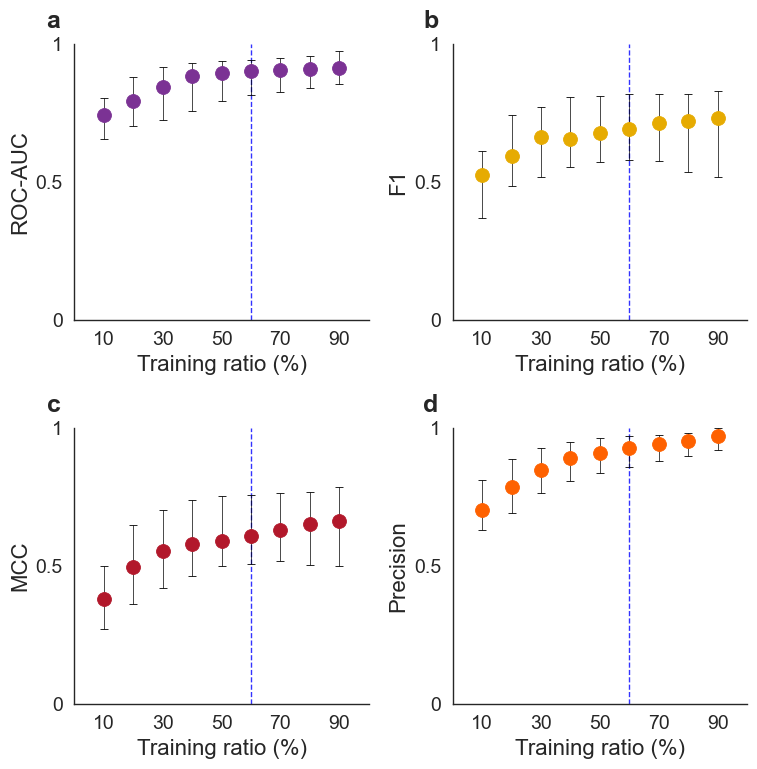

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display


sns.set_context(
    "paper",
    font_scale=1.35,
)

sns.set_style("white")


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    candidates = [start, *start.parents]

    fallback = Path(
        "/Users/acw792/Developer/qmul-phd-framework"
    )

    if fallback not in candidates:
        candidates.append(fallback)

    for candidate in candidates:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the qmul-phd-framework repository."
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final role-only experimental configuration: 100 runs
# ============================================================

CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False
CLASSIFICATION_THRESHOLD = 0.50

NODES_THRESHOLD = 0

# Tukey is applied independently across 100 runs for each
# Foodweb × TrainRatio × Metric group.
#
# Keep the previously agreed absolute minimum of 25 runs.
EXPECTED_RUNS = 100
MINIMUM_RETAINED_FRACTION = 0.25
MINIMUM_RETAINED_RUNS = 25

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min25runs_threshold0p50_v1"
)

EXPECTED_SCENARIO = (
    "result_wlnm_dir_neg_roleonly_trophicv2_"
    "100x290_train10-90_Apocrita_20260910_011848"
)

calculated_minimum_runs = int(
    np.ceil(
        EXPECTED_RUNS
        * MINIMUM_RETAINED_FRACTION
    )
)

assert calculated_minimum_runs == MINIMUM_RETAINED_RUNS, (
    "The configured minimum retained runs is inconsistent "
    "with the expected number of runs and retained fraction."
)


# ============================================================
# Final role-only result root
# ============================================================

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_trophicv2_"
        "100x290_train10-90_Apocrita_20260910_011848"
    )
)

RETENTION_ROOT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
)

RETENTION_MANIFEST_PATH = (
    RETENTION_ROOT
    / "retention_manifest.json"
)

RESULTS_FILE = (
    RETENTION_ROOT
    / "figure_inputs"
    / "predictive_train10-90_after_tukey.csv"
)

FOODWEB_CSV = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)

# ============================================================
# Output paths
# ============================================================

OUT_DIR = (
    RETENTION_ROOT
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_STEM = (
    "figure_4_predictive_four_metrics_by_train_ratio_"
    "roleonly_trophicv2_100runs_thresh0p50_"
    "tukey_iqr1p5_min25runs"
)

PNG_PATH = OUT_DIR / f"{OUTPUT_STEM}.png"
SVG_PATH = OUT_DIR / f"{OUTPUT_STEM}.svg"
PDF_PATH = OUT_DIR / f"{OUTPUT_STEM}.pdf"

SUMMARY_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_summary.csv"
)

RETENTION_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_retention.csv"
)


# ============================================================
# Metrics
# ============================================================

METRICS = [
    "ROC_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
]

METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

METRIC_PALETTE = {
    "ROC-AUC": "#7B3294",
    "PR-AUC": "#C51B7D",
    "F1": "#E6AB02",
    "MCC": "#B2182B",
    "Precision": "#FE6100",
    "Recall": "#CAB2D6",
    "TSS": "#666666",
}

SHOW_GRID = False

Y_MIN = 0.0
Y_MAX = 1.0

INDEPENDENT_Y = False
Y_PADDING = 0.02

REFERENCE_TRAIN_RATIO = 60


# ============================================================
# Validate required files
# ============================================================

required_files = {
    "Tukey retention manifest": RETENTION_MANIFEST_PATH,
    "Tukey-filtered predictive input": RESULTS_FILE,
    "Food-web metadata": FOODWEB_CSV,
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n\n"
        + "\n\n".join(missing_files)
    )

print(f"[INFO] Repository: {REPO_ROOT}")
print(f"[INFO] Result root: {RESULT_ROOT}")
print(f"[INFO] Tukey input: {RESULTS_FILE}")


# ============================================================
# Validate final role-only configuration
# ============================================================

with RETENTION_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    retention_manifest = json.load(file)

manifest = retention_manifest.get(
    "source_manifest",
    {},
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "Eligibility": "role_only",
    "MassEligibilityEnabled": "false",
    "NegativeSampling": "uniform_without_replacement",
    "NegativeTopupPolicy": "uniform_remaining_nonlinks",
    "NegativePositiveRatio": "2",
    "NumExperiments": str(EXPECTED_RUNS),
    "SweepTrainRatios": "true",
    "TrainRatioRange": "10,20,30,40,50,60,70,80,90",
    "ClassificationThreshold": "0.50",
    "SubgraphK": "10",
    "TrophicLevelProtocol": "validated_v2",
    "TrophicHighPrecision": "auto",
    "ComputeEcologicalMetrics": "true",
    "MinimumRetainedAfterTukey": str(MINIMUM_RETAINED_RUNS),
    "FoodWebs": "290",
}

configuration_errors = []

for key, expected_value in expected_manifest.items():
    observed_value = manifest.get(key)

    if observed_value != expected_value:
        configuration_errors.append(
            f"{key}: expected {expected_value!r}, "
            f"observed {observed_value!r}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result root does not match the "
        "final role-only configuration:\n\n"
        + "\n".join(configuration_errors)
    )

observed_scenario = retention_manifest.get(
    "scenario"
)

if observed_scenario != EXPECTED_SCENARIO:
    raise ValueError(
        "Unexpected scenario in retention_manifest.json:\n"
        f"  expected: {EXPECTED_SCENARIO}\n"
        f"  observed: {observed_scenario}"
    )

observed_threshold = retention_manifest.get(
    "classification_threshold"
)

if observed_threshold is None or not np.isclose(
    float(observed_threshold),
    CLASSIFICATION_THRESHOLD,
    atol=1e-9,
):
    raise ValueError(
        "The Tukey retention threshold does not match "
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )

observed_minimum_fraction = retention_manifest.get(
    "minimum_retained_fraction"
)

if observed_minimum_fraction is None or not np.isclose(
    float(observed_minimum_fraction),
    MINIMUM_RETAINED_FRACTION,
    atol=1e-12,
):
    raise ValueError(
        "The Tukey minimum retained fraction does not match:\n"
        f"  expected: {MINIMUM_RETAINED_FRACTION}\n"
        f"  observed: {observed_minimum_fraction}"
    )

observed_standard_example = retention_manifest.get(
    "standard_minimum_example"
)

expected_standard_example = (
    f"{MINIMUM_RETAINED_RUNS} of {EXPECTED_RUNS}"
)

if (
    observed_standard_example is not None
    and observed_standard_example
    != expected_standard_example
):
    raise ValueError(
        "Unexpected standard Tukey minimum in manifest:\n"
        f"  expected: {expected_standard_example}\n"
        f"  observed: {observed_standard_example}"
    )

print(
    "[INFO] Validated final role-only configuration:"
)

print(f"  scenario={observed_scenario}")
print(f"  eligibility={manifest['Eligibility']}")

print(
    "  mass_eligibility_enabled="
    f"{manifest['MassEligibilityEnabled']}"
)

print(
    "  negative_sampling="
    f"{manifest['NegativeSampling']}"
)

print(
    "  negative_positive_ratio="
    f"{manifest['NegativePositiveRatio']}"
)

print(
    "  negative_topup_policy="
    f"{manifest['NegativeTopupPolicy']}"
)

print(
    "  classification_threshold="
    f"{manifest['ClassificationThreshold']}"
)

print(
    "  number_of_experiments="
    f"{manifest['NumExperiments']}"
)

print(
    "  train_ratio_range="
    f"{manifest['TrainRatioRange']}"
)

print(f"  retention_protocol={PROTOCOL_NAME}")

print(
    "  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    "  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)


# ============================================================
# Food-web name normalisation
# ============================================================

def normalize_fw_label(name):
    name = str(name).strip()

    for suffix in [
        ".mat",
        ".csv",
    ]:
        if name.endswith(suffix):
            name = name[: -len(suffix)]

    name = name.replace(
        " ",
        "_",
    )

    for token in [
        "_results_",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(
            token,
            "_",
        )

    return "_".join(
        part
        for part in name.split("_")
        if part
    ).lower()


# ============================================================
# Load Tukey-filtered web-level results
# ============================================================

df = pd.read_csv(
    RESULTS_FILE
)

required_columns = {
    "Scenario",
    "Foodweb",
    "Version",
    "Metric",
    "MetricLabel",
    "MetricFamily",
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "MinimumRetainedRuns",
    "MeetsMinimumRetainedRuns",
}

missing_columns = required_columns.difference(
    df.columns
)

if missing_columns:
    raise ValueError(
        f"{RESULTS_FILE.name} is missing required columns: "
        f"{sorted(missing_columns)}"
    )

numeric_columns = [
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "MinimumRetainedRuns",
    "MeetsMinimumRetainedRuns",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )


# ============================================================
# Select the final role-only configuration
# ============================================================

target_df = df[
    df["Scenario"].eq(
        EXPECTED_SCENARIO
    )
    & df["Version"].eq(
        "WLNM_dir_neg"
    )
    & df["MetricFamily"].eq(
        "predictive"
    )
    & df["Metric"].isin(
        METRICS
    )
    & np.isclose(
        df["Threshold"],
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
        equal_nan=False,
    )
].copy()

if target_df.empty:
    raise RuntimeError(
        "No predictive results match the final "
        "role-only configuration."
    )


# ============================================================
# Validate minimum 25 retained runs
# ============================================================

observed_minimums = set(
    target_df["MinimumRetainedRuns"]
    .dropna()
    .astype(int)
    .unique()
)

if observed_minimums != {
    MINIMUM_RETAINED_RUNS
}:
    raise ValueError(
        "The Tukey figure input was not processed with "
        f"the expected minimum of "
        f"{MINIMUM_RETAINED_RUNS} retained runs.\n"
        f"Observed values: {sorted(observed_minimums)}"
    )

incorrect_retention = target_df[
    target_df["MeetsMinimumRetainedRuns"].eq(1)
    & target_df["RetainedRunsAfterTukey"].lt(
        MINIMUM_RETAINED_RUNS
    )
]

if not incorrect_retention.empty:
    display(
        incorrect_retention[
            [
                "Foodweb",
                "TrainRatio",
                "Metric",
                "RetainedRunsAfterTukey",
                "MinimumRetainedRuns",
                "MeetsMinimumRetainedRuns",
            ]
        ]
    )

    raise ValueError(
        "At least one group is marked as retained despite "
        f"having fewer than {MINIMUM_RETAINED_RUNS} runs."
    )

below_minimum = target_df[
    target_df["RetainedRunsAfterTukey"].lt(
        MINIMUM_RETAINED_RUNS
    )
]

if not below_minimum.empty:
    print(
        "[INFO] Groups excluded because fewer than "
        f"{MINIMUM_RETAINED_RUNS} runs remained: "
        f"{len(below_minimum):,}"
    )


# ============================================================
# Keep valid Tukey-filtered groups
# ============================================================

df = target_df[
    target_df["MinimumRetainedRuns"].eq(
        MINIMUM_RETAINED_RUNS
    )
    & target_df["RetainedRunsAfterTukey"].ge(
        MINIMUM_RETAINED_RUNS
    )
    & target_df["MeetsMinimumRetainedRuns"].eq(1)
    & target_df["MeanAfterTukey"].notna()
].copy()

if df.empty:
    raise RuntimeError(
        "No retained predictive results remain after "
        "validating the Tukey minimum."
    )

print(
    "[INFO] Tukey minimum validated: "
    f"at least {MINIMUM_RETAINED_RUNS} of "
    f"{EXPECTED_RUNS} runs per food web and metric."
)

print(
    "[INFO] Actual retained-run range: "
    f"{int(df['RetainedRunsAfterTukey'].min())}–"
    f"{int(df['RetainedRunsAfterTukey'].max())}"
)


# ============================================================
# Prepare plotting variables
# ============================================================

df["TRAINRATIO"] = (
    df["TrainRatio"]
    .round()
    .astype(int)
)

df["Value"] = (
    df["MeanAfterTukey"]
)

df["FW_KEY"] = (
    df["Foodweb"]
    .apply(normalize_fw_label)
)


# ============================================================
# Validate expected training ratios
# ============================================================

expected_train_ratios = list(
    range(
        10,
        100,
        10,
    )
)

observed_train_ratios = sorted(
    df["TRAINRATIO"]
    .dropna()
    .unique()
    .tolist()
)

if observed_train_ratios != expected_train_ratios:
    raise ValueError(
        "Unexpected training-ratio coverage:\n"
        f"  expected: {expected_train_ratios}\n"
        f"  observed: {observed_train_ratios}"
    )


# ============================================================
# Validate unique web-level observations
# ============================================================

duplicate_mask = df.duplicated(
    subset=[
        "FW_KEY",
        "TRAINRATIO",
        "Metric",
    ],
    keep=False,
)

if duplicate_mask.any():
    duplicated = (
        df.loc[
            duplicate_mask,
            [
                "Foodweb",
                "TRAINRATIO",
                "Metric",
            ],
        ]
        .sort_values(
            [
                "Metric",
                "TRAINRATIO",
                "Foodweb",
            ]
        )
    )

    display(duplicated)

    raise ValueError(
        "Duplicated Foodweb × TrainRatio × Metric "
        "rows were found."
    )


# ============================================================
# Load food-web metadata
# ============================================================

metadata = pd.read_csv(
    FOODWEB_CSV
)

metadata.columns = [
    column.strip()
    for column in metadata.columns
]

foodweb_column = next(
    (
        column
        for column in metadata.columns
        if column.lower() == "foodweb"
    ),
    None,
)

nodes_column = next(
    (
        column
        for column in metadata.columns
        if column.lower() in {
            "nodes",
            "n_nodes",
            "num_nodes",
            "nodecount",
            "s",
        }
    ),
    None,
)

ecosystem_column = next(
    (
        column
        for column in metadata.columns
        if column.lower() in {
            "ecosystem",
            "ecosystemtype",
            "ecosystem_type",
        }
    ),
    None,
)

if (
    foodweb_column is None
    or nodes_column is None
    or ecosystem_column is None
):
    raise ValueError(
        "Could not identify Foodweb, Nodes, and "
        "Ecosystem columns in the metadata."
    )

metadata[nodes_column] = pd.to_numeric(
    metadata[nodes_column],
    errors="coerce",
)

metadata["FW_KEY"] = (
    metadata[foodweb_column]
    .apply(normalize_fw_label)
)

duplicate_metadata = metadata.duplicated(
    subset=["FW_KEY"],
    keep=False,
)

if duplicate_metadata.any():
    inconsistent_metadata = (
        metadata.loc[
            duplicate_metadata,
            [
                "FW_KEY",
                nodes_column,
                ecosystem_column,
            ],
        ]
        .groupby("FW_KEY")
        .nunique(
            dropna=False
        )
    )

    inconsistent_metadata = inconsistent_metadata[
        (
            inconsistent_metadata[nodes_column] > 1
        )
        | (
            inconsistent_metadata[
                ecosystem_column
            ] > 1
        )
    ]

    if not inconsistent_metadata.empty:
        display(
            inconsistent_metadata
        )

        raise ValueError(
            "Conflicting metadata were found for one or "
            "more normalised food-web names."
        )

metadata = (
    metadata[
        [
            "FW_KEY",
            nodes_column,
            ecosystem_column,
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"]
    )
    .rename(
        columns={
            nodes_column: "Nodes",
            ecosystem_column: "Ecosystem",
        }
    )
)


# ============================================================
# Merge metadata and apply node filter
# ============================================================

df = df.merge(
    metadata,
    on="FW_KEY",
    how="left",
    validate="many_to_one",
)

missing_metadata = (
    df.loc[
        (
            df["Nodes"].isna()
            | df["Ecosystem"].isna()
        ),
        "Foodweb",
    ]
    .drop_duplicates()
    .sort_values()
)

if not missing_metadata.empty:
    display(
        missing_metadata.to_frame(
            name="Foodweb"
        )
    )

    raise ValueError(
        "Food-web metadata could not be matched for "
        f"{len(missing_metadata)} food webs."
    )

df = df[
    df["Nodes"] >= NODES_THRESHOLD
].copy()

if df.empty:
    raise RuntimeError(
        f"No food webs remain after applying "
        f"Nodes >= {NODES_THRESHOLD}."
    )

print(
    f"[INFO] Food webs after node filter: "
    f"{df['FW_KEY'].nunique()}"
)

print(
    "[INFO] Training ratios: "
    f"{sorted(df['TRAINRATIO'].unique().tolist())}"
)

print(
    "[INFO] Ecosystems: "
    f"{sorted(df['Ecosystem'].dropna().unique().tolist())}"
)


# ============================================================
# Retention report
# ============================================================

retention_table = (
    df
    .groupby(
        [
            "TRAINRATIO",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        MinimumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetainedRuns=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "max",
        ),
    )
)

retention_table["MetricLabel"] = (
    retention_table["Metric"]
    .map(METRIC_LABELS)
)

retention_table = retention_table[
    [
        "TRAINRATIO",
        "Metric",
        "MetricLabel",
        "FoodWebs",
        "MinimumRetainedRuns",
        "MedianRetainedRuns",
        "MaximumRetainedRuns",
    ]
]

print(
    "\n=== Tukey retention by training ratio "
    "and metric ==="
)

display(
    retention_table
)


# ============================================================
# Across-food-web summary
# ============================================================

summary = (
    df
    .groupby(
        [
            "TRAINRATIO",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        median=(
            "Value",
            "median",
        ),
        q25=(
            "Value",
            lambda values: values.quantile(
                0.25
            ),
        ),
        q75=(
            "Value",
            lambda values: values.quantile(
                0.75
            ),
        ),
        mean=(
            "Value",
            "mean",
        ),
        sd=(
            "Value",
            "std",
        ),
        n_webs=(
            "FW_KEY",
            "nunique",
        ),
    )
)

summary["MetricLabel"] = (
    summary["Metric"]
    .map(METRIC_LABELS)
)

train_ratios = sorted(
    summary["TRAINRATIO"]
    .unique()
    .tolist()
)

print(
    f"[INFO] Food webs represented: "
    f"{df['FW_KEY'].nunique()}"
)


# ============================================================
# Consistent metric colours
# ============================================================

metric_colors = {
    metric: METRIC_PALETTE[
        METRIC_LABELS[metric]
    ]
    for metric in METRICS
}


# ============================================================
# Final plot
# ============================================================

number_of_metrics = len(
    METRICS
)

number_of_rows = 2

number_of_columns = int(
    np.ceil(
        number_of_metrics
        / number_of_rows
    )
)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(
        4 * number_of_columns,
        8.0,
    ),
    sharex=False,
    sharey=False,
)

axes = np.asarray(
    axes
).reshape(
    number_of_rows,
    number_of_columns,
)

axes_flat = axes.flatten()

panel_letters = list(
    "abcdefghijklmnopqrstuvwxyz"
)

for index, metric in enumerate(
    METRICS
):
    ax = axes_flat[index]

    panel_df = (
        summary[
            summary["Metric"].eq(
                metric
            )
        ]
        .sort_values(
            "TRAINRATIO"
        )
    )

    if panel_df.empty:
        ax.set_axis_off()
        continue

    x_values = (
        panel_df["TRAINRATIO"]
        .to_numpy()
    )

    median_values = (
        panel_df["median"]
        .to_numpy()
    )

    error_values = np.vstack(
        [
            (
                panel_df["median"]
                - panel_df["q25"]
            ).to_numpy(),
            (
                panel_df["q75"]
                - panel_df["median"]
            ).to_numpy(),
        ]
    )

    color = metric_colors[
        metric
    ]

    ax.errorbar(
        x_values,
        median_values,
        yerr=error_values,
        fmt="o",
        linestyle="none",
        color=color,
        ecolor="black",
        markersize=10,
        linewidth=1.2,
        elinewidth=0.5,
        capsize=3,
        capthick=0.8,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.6,
    )

    ax.axvline(
        x=REFERENCE_TRAIN_RATIO,
        color="blue",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=0,
    )

    if INDEPENDENT_Y:
        local_minimum = max(
            Y_MIN,
            panel_df["q25"].min()
            - Y_PADDING,
        )

        local_maximum = min(
            Y_MAX,
            panel_df["q75"].max()
            + Y_PADDING,
        )

        if np.isclose(
            local_minimum,
            local_maximum,
        ):
            local_minimum = max(
                Y_MIN,
                local_minimum
                - 0.02,
            )

            local_maximum = min(
                Y_MAX,
                local_maximum
                + 0.02,
            )

        ax.set_ylim(
            local_minimum,
            local_maximum,
        )

    else:
        ax.set_ylim(
            Y_MIN,
            Y_MAX,
        )

        ax.set_yticks(
            [
                0,
                0.5,
                1.0,
            ]
        )

        ax.set_yticklabels(
            [
                "0",
                "0.5",
                "1",
            ]
        )

    if SHOW_GRID:
        ax.grid(
            True,
            axis="y",
            linestyle="--",
            alpha=0.30,
        )
    else:
        ax.grid(
            False
        )

    visible_ticks = [
        ratio
        for ratio in [
            10,
            30,
            50,
            70,
            90,
        ]
        if ratio in train_ratios
    ]

    ax.set_xticks(
        visible_ticks
    )

    ax.set_xticklabels(
        [
            str(ratio)
            for ratio in visible_ticks
        ]
    )

    ax.set_xlim(
        min(train_ratios) - 10,
        max(train_ratios) + 10,
    )

    ax.set_xlabel(
        "Training ratio (%)",
        fontsize=16,
    )

    ax.set_ylabel(
        METRIC_LABELS[metric],
        fontsize=16,
    )

    ax.set_title("")

    if index < len(
        panel_letters
    ):
        ax.annotate(
            panel_letters[index],
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(-10, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=18,
            fontweight="bold",
            annotation_clip=False,
        )

    ax.tick_params(
        axis="both",
        labelsize=14,
    )

    sns.despine(
        ax=ax
    )


# ============================================================
# Hide unused panels
# ============================================================

for index in range(
    number_of_metrics,
    len(axes_flat),
):
    axes_flat[index].set_axis_off()


# ============================================================
# Layout and export
# ============================================================

fig.tight_layout(
    rect=[
        0.03,
        0,
        1,
        0.985,
    ]
)

fig.savefig(
    PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    SVG_PATH,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)

summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

retention_table.to_csv(
    RETENTION_PATH,
    index=False,
)

print(
    "\n[INFO] Saved publication-ready outputs:"
)

print(f"  PNG: {PNG_PATH}")
print(f"  SVG: {SVG_PATH}")
print(f"  PDF: {PDF_PATH}")
print(f"  Summary: {SUMMARY_PATH}")
print(f"  Retention: {RETENTION_PATH}")

print(
    "\n[INFO] Final Tukey configuration:"
)

print(
    f"  expected_runs="
    f"{EXPECTED_RUNS}"
)

print(
    f"  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    f"  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)

plt.show()

[INFO] Repository: /Users/acw792/Developer/qmul-phd-framework
[INFO] Result root: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848
[INFO] Ecological Tukey input: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/ecological_train60_after_tukey.csv
[INFO] Validated final role-only configuration:
  scenario=result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848
  eligibility=role_only
  mass_eligibility_enabled=false
  negative_sampling=uniform_without_replacement
  negative_positive_ratio=2
  negative_topup_policy=uniform_remaining_nonlinks
  classification_threshold=0.50
  number_of_experiments=100
  train_ratio_range=10,20,30,40,50,60,70,80,90
  retention_protocol=tukey_iqr_1p5_min25runs_threshold0p50_v1

,MetricLabel,NPairs,NNonzeroDifferences,MedianDifference,WilcoxonStatistic,RankBiserialCorrelation,PValueRaw,PValueHolm,RejectH0Holm
0,Connectance,290,290,-0.016074,0.0,-1.000000,2.630560e-49,1.052224e-48,True
1,Mean trophic height,290,290,0.028930,11920.0,0.435004,1.354638e-10,1.354638e-10,True
2,Mean generality,290,290,-0.798973,1498.0,-0.928996,8.544627e-43,2.563388e-42,True
3,Mean vulnerability,290,290,-0.495504,1643.0,-0.922123,3.441874e-42,6.883747e-42,True


[INFO] Wilcoxon results saved to: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/statistical_tests/figure_5_wilcoxon_train60_roleonly_trophicv2_100runs_threshold0p50_after_tukey_min25runs_results.csv
[INFO] Wilcoxon pairs saved to: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/statistical_tests/figure_5_wilcoxon_train60_roleonly_trophicv2_100runs_threshold0p50_after_tukey_min25runs_pairs.csv
[NOTE] A non-significant Wilcoxon result does not demonstrate equivalence or similarity.
[INFO] Source file: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/ratio_metrics_tukey_iqr_

,Metric,FoodWebs,RequiredMinimumRuns,TotalPseudoRunOutliersRemoved,MinRetainedRuns,MedianRetainedRuns,MaxRetainedRuns
0,Connectance,290,25,471,83,99.0,100
1,ConsumerToResourceRatio,290,25,620,80,99.0,100
2,MeanTrophicHeight,290,25,2275,42,88.0,100
3,ResourceToConsumerRatio,290,25,551,79,99.0,100


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/fig5_wlnm_dir_neg_train60_roleonly_trophicv2_100runs_threshold0p50_tukey_min25runs.png
[INFO] Final Tukey configuration:
  expected_runs=100
  minimum_retained_fraction=0.25
  minimum_retained_runs=25/100


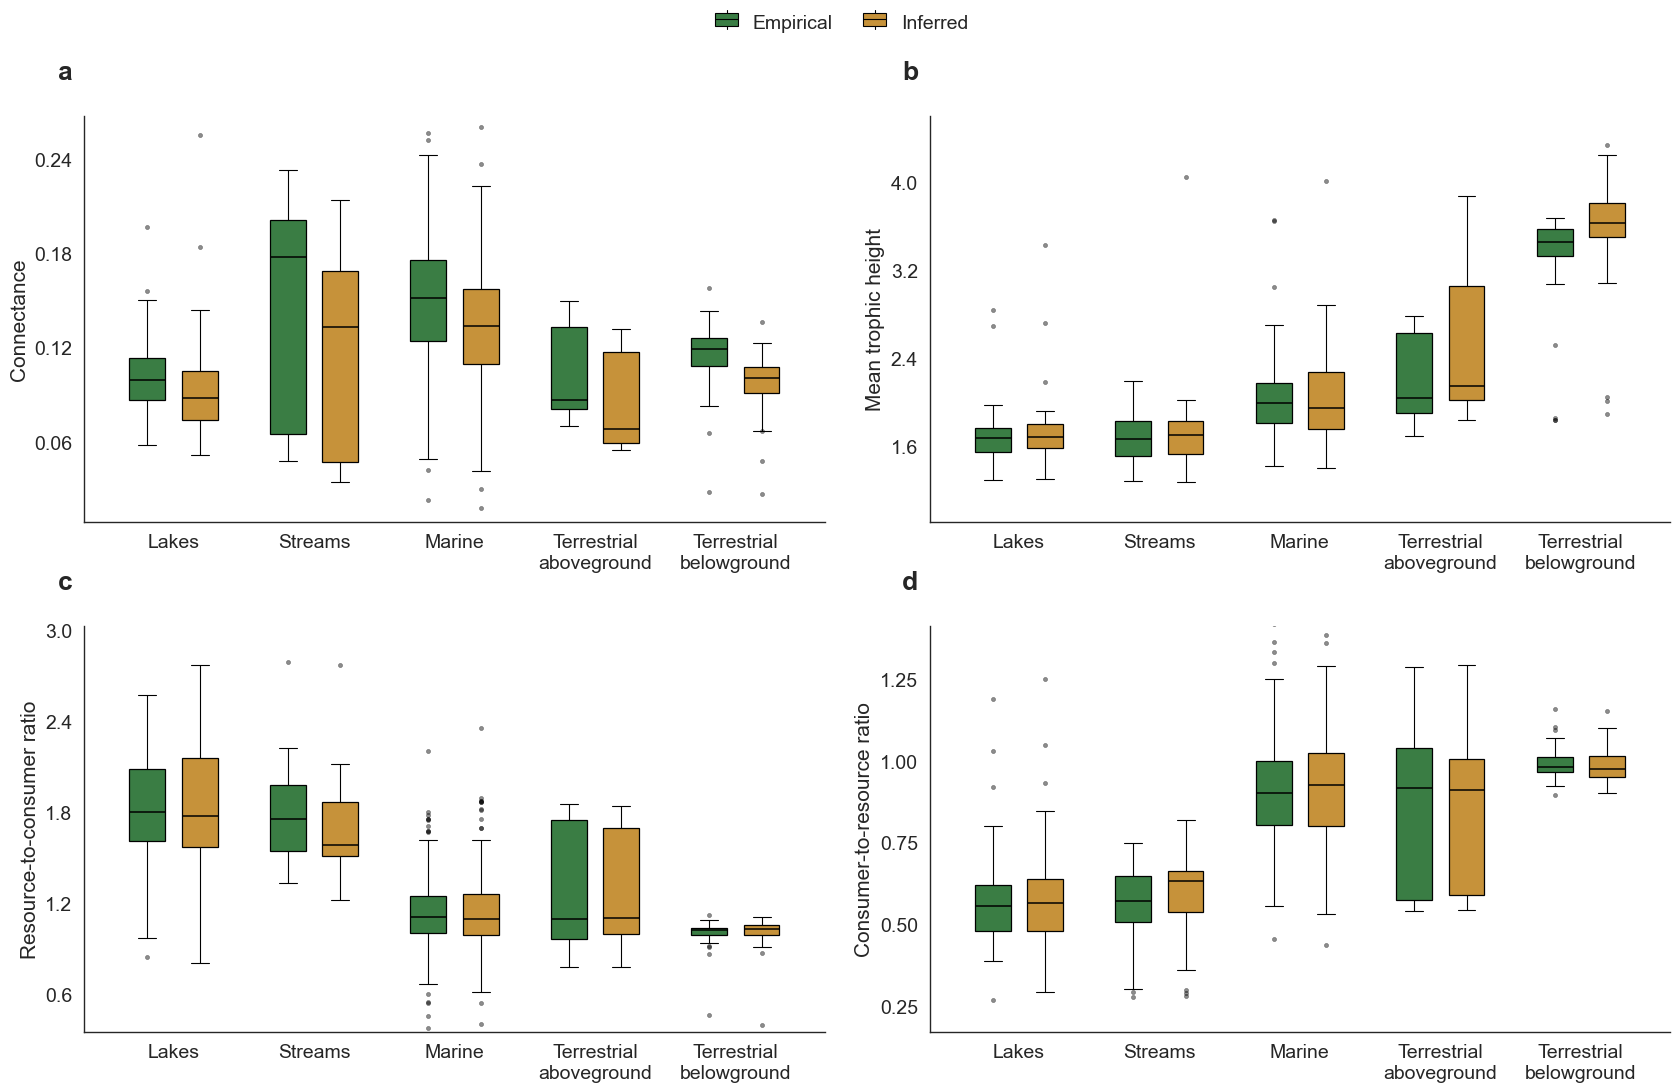

In [16]:
import json
import math

import numpy as np
import pandas as pd
import scipy
import seaborn as sns

from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MaxNLocator
from scipy.stats import rankdata, wilcoxon


sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.15,
)


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    candidates = [start, *start.parents]

    fallback = Path(
        "/Users/acw792/Developer/qmul-phd-framework"
    )

    if fallback not in candidates:
        candidates.append(fallback)

    for path in candidates:
        if (
            (path / "src/matlab").is_dir()
            and (path / "docs").is_dir()
        ):
            return path

    raise RuntimeError(
        "Could not locate the qmul-phd-framework repository."
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final role-only data configuration: 100 runs
# ============================================================

TRAIN_RATIO = 60
CLASSIFICATION_THRESHOLD = 0.50

CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False

# Tukey is applied independently across 100 runs for each
# food-web × metric group.
#
# Keep the agreed absolute minimum of 25 retained runs.
EXPECTED_RUNS = 100
MINIMUM_RETAINED_FRACTION = 0.25
MINIMUM_RETAINED_RUNS = 25

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min25runs_threshold0p50_v1"
)

EXPECTED_SCENARIO = (
    "result_wlnm_dir_neg_roleonly_trophicv2_"
    "100x290_train10-90_Apocrita_20260910_011848"
)

calculated_minimum_runs = math.ceil(
    EXPECTED_RUNS
    * MINIMUM_RETAINED_FRACTION
)

assert calculated_minimum_runs == MINIMUM_RETAINED_RUNS, (
    "The minimum retained-run configuration is inconsistent."
)


# ============================================================
# Final role-only result input
# ============================================================

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_trophicv2_"
        "100x290_train10-90_Apocrita_20260910_011848"
    )
)

RETENTION_ROOT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
)

ECOLOGICAL_INPUT = (
    RETENTION_ROOT
    / "figure_inputs"
    / f"ecological_train{TRAIN_RATIO}_after_tukey.csv"
)

RATIO_FIGURE_INPUT = (
    RESULT_ROOT
    / "retention_protocol"
    / "ratio_metrics_tukey_iqr_1p5_min25runs_threshold0p50_v1"
    / "figure_inputs"
    / f"athen_empirical_vs_inferred_train{TRAIN_RATIO}_after_tukey.csv"
)

RETENTION_MANIFEST = (
    RETENTION_ROOT
    / "retention_manifest.json"
)

FOODWEB_METADATA = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)

OUT_DIR = (
    RETENTION_ROOT
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUT_PATH = (
    OUT_DIR
    / (
        f"fig5_wlnm_dir_neg_train{TRAIN_RATIO}_"
        "roleonly_trophicv2_100runs_"
        "threshold0p50_tukey_min25runs.png"
    )
)

STATISTICAL_TESTS_DIR = (
    RETENTION_ROOT
    / "statistical_tests"
)

STATISTICAL_TESTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

WILCOXON_OUTPUT_STEM = (
    f"figure_5_wilcoxon_train{TRAIN_RATIO}_"
    "roleonly_trophicv2_100runs_"
    "threshold0p50_after_tukey_min25runs"
)

WILCOXON_RESULTS_PATH = (
    STATISTICAL_TESTS_DIR
    / f"{WILCOXON_OUTPUT_STEM}_results.csv"
)

WILCOXON_PAIRS_PATH = (
    STATISTICAL_TESTS_DIR
    / f"{WILCOXON_OUTPUT_STEM}_pairs.csv"
)


# ============================================================
# Validate required files
# ============================================================

required_files = {
    "Tukey-filtered ecological input": ECOLOGICAL_INPUT,
    "Combined ecological and ratio figure input": RATIO_FIGURE_INPUT,
    "Food-web metadata": FOODWEB_METADATA,
    "Tukey retention manifest": RETENTION_MANIFEST,
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required files:\n\n"
        + "\n\n".join(missing_files)
    )

print(f"[INFO] Repository: {REPO_ROOT}")
print(f"[INFO] Result root: {RESULT_ROOT}")
print(f"[INFO] Ecological Tukey input: {ECOLOGICAL_INPUT}")


# ============================================================
# Validate final role-only configuration
# ============================================================

with RETENTION_MANIFEST.open(
    "r",
    encoding="utf-8",
) as handle:
    retention_manifest = json.load(handle)

manifest = retention_manifest.get(
    "source_manifest",
    {},
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "Eligibility": "role_only",
    "MassEligibilityEnabled": "false",
    "NegativeSampling": "uniform_without_replacement",
    "NegativeTopupPolicy": "uniform_remaining_nonlinks",
    "NegativePositiveRatio": "2",
    "NumExperiments": str(EXPECTED_RUNS),
    "SweepTrainRatios": "true",
    "TrainRatioRange": "10,20,30,40,50,60,70,80,90",
    "ClassificationThreshold": "0.50",
    "SubgraphK": "10",
    "TrophicLevelProtocol": "validated_v2",
    "TrophicHighPrecision": "auto",
    "ComputeEcologicalMetrics": "true",
    "MinimumRetainedAfterTukey": str(MINIMUM_RETAINED_RUNS),
    "FoodWebs": "290",
}

configuration_errors = []

for key, expected in expected_manifest.items():
    observed = manifest.get(key)

    if observed is None:
        configuration_errors.append(
            f"{key}: missing"
        )

    elif (
        str(observed).casefold()
        != str(expected).casefold()
    ):
        configuration_errors.append(
            f"{key}: expected {expected}, found {observed}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result root does not match the final "
        "role-only configuration:\n\n"
        + "\n".join(configuration_errors)
    )

observed_scenario = retention_manifest.get(
    "scenario"
)

if observed_scenario != EXPECTED_SCENARIO:
    raise ValueError(
        "Unexpected scenario in retention_manifest.json:\n"
        f"  expected: {EXPECTED_SCENARIO}\n"
        f"  observed: {observed_scenario}"
    )

observed_threshold = retention_manifest.get(
    "classification_threshold"
)

if (
    observed_threshold is None
    or not np.isclose(
        float(observed_threshold),
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
    )
):
    raise ValueError(
        "The Tukey retention threshold does not match "
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )

observed_minimum_fraction = retention_manifest.get(
    "minimum_retained_fraction"
)

if (
    observed_minimum_fraction is None
    or not np.isclose(
        float(observed_minimum_fraction),
        MINIMUM_RETAINED_FRACTION,
        atol=1e-12,
    )
):
    raise ValueError(
        "The Tukey minimum retained fraction does not match:\n"
        f"  expected: {MINIMUM_RETAINED_FRACTION}\n"
        f"  observed: {observed_minimum_fraction}"
    )

expected_standard_example = (
    f"{MINIMUM_RETAINED_RUNS} of {EXPECTED_RUNS}"
)

observed_standard_example = retention_manifest.get(
    "standard_minimum_example"
)

if (
    observed_standard_example is not None
    and observed_standard_example
    != expected_standard_example
):
    raise ValueError(
        "Unexpected standard Tukey minimum in manifest:\n"
        f"  expected: {expected_standard_example}\n"
        f"  observed: {observed_standard_example}"
    )

print("[INFO] Validated final role-only configuration:")
print(f"  scenario={observed_scenario}")
print(f"  eligibility={manifest['Eligibility']}")

print(
    "  mass_eligibility_enabled="
    f"{manifest['MassEligibilityEnabled']}"
)

print(
    "  negative_sampling="
    f"{manifest['NegativeSampling']}"
)

print(
    "  negative_positive_ratio="
    f"{manifest['NegativePositiveRatio']}"
)

print(
    "  negative_topup_policy="
    f"{manifest['NegativeTopupPolicy']}"
)

print(
    "  classification_threshold="
    f"{manifest['ClassificationThreshold']}"
)

print(
    "  number_of_experiments="
    f"{manifest['NumExperiments']}"
)

print(
    "  train_ratio_range="
    f"{manifest['TrainRatioRange']}"
)

print(f"  retention_protocol={PROTOCOL_NAME}")

print(
    "  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    "  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)


# ============================================================
# Figure configuration
# ============================================================

BOX_WIDTH = 0.30
TYPE_OFFSET = 0.22
GROUP_SPACING = 1.18

# These are web-level boxplot fliers, not pseudo-run outliers.
# Pseudo-run outliers were removed before MeanAfterTukey.
SHOW_WEB_LEVEL_FLIERS = True

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": (
        "Terrestrial\naboveground"
    ),
    "terrestrial belowground": (
        "Terrestrial\nbelowground"
    ),
}

wilcoxon_metric_order = [
    "Connectance",
    "MeanTrophicHeight",
    "MeanGenerality",
    "MeanVulnerability",
]

metric_order = [
    "Connectance",
    "MeanTrophicHeight",
    "ResourceToConsumerRatio",
    "ConsumerToResourceRatio",
]

metric_labels = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
    "ResourceToConsumerRatio": "Resource-to-consumer ratio",
    "ConsumerToResourceRatio": "Consumer-to-resource ratio",
}

panel_letters = list(
    "abcdefghijklmnopqrstuvwxyz"
)

type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

# Paired Wilcoxon configuration. The food web is the unit
# of analysis; the 50 repeated runs are not treated as
# independent observations.
WILCOXON_ALPHA = 0.05
WILCOXON_ALTERNATIVE = "two-sided"
WILCOXON_ZERO_METHOD = "wilcox"
WILCOXON_METHOD = "auto"
WILCOXON_CORRECTION = False
DIFFERENCE_DECIMALS = 12


# ============================================================
# Figure helpers
# ============================================================

def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(
        eco
    ).strip().lower()

    return ecosystem_labels.get(
        eco_clean,
        str(eco).strip().capitalize(),
    )


def draw_box(
    ax,
    values,
    position,
    facecolor,
    showfliers=False,
):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=showfliers,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "black",
            "linewidth": 0.9,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 3.0,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
            "alpha": 0.45,
        },
    )


def get_boxplot_visible_ylim(
    grouped_values,
    lower_bound=0.0,
    pad_fraction=0.12,
):
    visible_lows = []
    visible_highs = []

    for values in grouped_values:
        values = np.asarray(
            values,
            dtype=float,
        )

        values = values[
            np.isfinite(values)
        ]

        if values.size == 0:
            continue

        q1, q3 = np.nanpercentile(
            values,
            [25, 75],
        )

        iqr = q3 - q1

        if np.isclose(
            iqr,
            0,
        ):
            lower_whisker = np.nanmin(
                values
            )

            upper_whisker = np.nanmax(
                values
            )

        else:
            lower_fence = (
                q1 - 1.5 * iqr
            )

            upper_fence = (
                q3 + 1.5 * iqr
            )

            non_fliers = values[
                (values >= lower_fence)
                & (values <= upper_fence)
            ]

            if non_fliers.size == 0:
                non_fliers = values

            lower_whisker = np.nanmin(
                non_fliers
            )

            upper_whisker = np.nanmax(
                non_fliers
            )

        visible_lows.extend(
            [
                lower_whisker,
                q1,
            ]
        )

        visible_highs.extend(
            [
                upper_whisker,
                q3,
            ]
        )

    if (
        not visible_lows
        or not visible_highs
    ):
        return None

    local_min = np.nanmin(
        visible_lows
    )

    local_max = np.nanmax(
        visible_highs
    )

    data_range = (
        local_max - local_min
        if local_max > local_min
        else 0.05
    )

    local_min = max(
        lower_bound,
        local_min
        - pad_fraction * data_range,
    )

    local_max = (
        local_max
        + pad_fraction * data_range
    )

    if np.isclose(
        local_min,
        local_max,
    ):
        local_min = max(
            lower_bound,
            local_min - 0.02,
        )

        local_max = (
            local_max + 0.02
        )

    return local_min, local_max


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle[
            "facecolor"
        ]

        edgecolor = orig_handle.get(
            "edgecolor",
            "black",
        )

        linewidth = orig_handle.get(
            "linewidth",
            0.8,
        )

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = (
            box_y
            + box_h
            + 0.18 * height
        )

        whisk_bot_y = (
            box_y
            - 0.18 * height
        )

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [
                box_x,
                box_x + box_w,
            ],
            [
                cy,
                cy,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [
                cx,
                cx,
            ],
            [
                box_y + box_h,
                whisk_top_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [
                cx,
                cx,
            ],
            [
                whisk_bot_y,
                box_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [
            box,
            median,
            whisker_top,
            whisker_bottom,
        ]


# ============================================================
# Paired Wilcoxon helpers
# ============================================================

def adjust_pvalues_holm(p_values):
    """Return Holm-adjusted p-values in original order."""
    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    adjusted = np.full(
        p_values.shape,
        np.nan,
        dtype=float,
    )

    valid_indices = np.flatnonzero(
        np.isfinite(p_values)
    )

    if valid_indices.size == 0:
        return adjusted

    valid_p_values = p_values[
        valid_indices
    ]

    order = np.argsort(
        valid_p_values
    )

    ordered_p_values = valid_p_values[
        order
    ]

    number_of_tests = len(
        ordered_p_values
    )

    multipliers = (
        number_of_tests
        - np.arange(number_of_tests)
    )

    ordered_adjusted = np.maximum.accumulate(
        multipliers
        * ordered_p_values
    )

    ordered_adjusted = np.minimum(
        ordered_adjusted,
        1.0,
    )

    valid_adjusted = np.empty_like(
        ordered_adjusted
    )

    valid_adjusted[order] = (
        ordered_adjusted
    )

    adjusted[valid_indices] = (
        valid_adjusted
    )

    return adjusted


def calculate_signed_rank_effect(differences):
    """Return positive/negative rank sums and rank-biserial r."""
    differences = np.asarray(
        differences,
        dtype=float,
    )

    nonzero = differences[
        differences != 0.0
    ]

    if nonzero.size == 0:
        return 0.0, 0.0, 0.0

    ranks = rankdata(
        np.abs(nonzero),
        method="average",
    )

    positive_rank_sum = float(
        ranks[nonzero > 0.0].sum()
    )

    negative_rank_sum = float(
        ranks[nonzero < 0.0].sum()
    )

    total_rank_sum = (
        positive_rank_sum
        + negative_rank_sum
    )

    rank_biserial = (
        (
            positive_rank_sum
            - negative_rank_sum
        )
        / total_rank_sum
    )

    return (
        positive_rank_sum,
        negative_rank_sum,
        float(rank_biserial),
    )


def run_paired_wilcoxon_by_metric(
    pairs,
    metrics,
):
    """Run one paired two-sided test per ecological metric."""
    result_rows = []

    for metric in metrics:
        metric_pairs = (
            pairs.loc[
                pairs["Metric"].eq(metric)
            ]
            .sort_values("FW_KEY")
            .copy()
        )

        if metric_pairs.empty:
            raise ValueError(
                f"No paired values found for metric: {metric}"
            )

        differences = metric_pairs[
            "Difference"
        ].to_numpy(dtype=float)

        positive_rank_sum, negative_rank_sum, rank_biserial = (
            calculate_signed_rank_effect(
                differences
            )
        )

        number_of_nonzero_differences = int(
            np.count_nonzero(
                differences != 0.0
            )
        )

        if number_of_nonzero_differences == 0:
            statistic = 0.0
            p_value = 1.0
            status = "all_differences_zero"
        else:
            test = wilcoxon(
                differences,
                zero_method=WILCOXON_ZERO_METHOD,
                correction=WILCOXON_CORRECTION,
                alternative=WILCOXON_ALTERNATIVE,
                method=WILCOXON_METHOD,
            )

            statistic = float(
                test.statistic
            )

            p_value = float(
                test.pvalue
            )

            status = "ok"

        result_rows.append(
            {
                "Metric": metric,
                "MetricLabel": metric_labels[metric],
                "NPairs": len(metric_pairs),
                "NNonzeroDifferences": (
                    number_of_nonzero_differences
                ),
                "NPositiveDifferences": int(
                    np.count_nonzero(
                        differences > 0.0
                    )
                ),
                "NNegativeDifferences": int(
                    np.count_nonzero(
                        differences < 0.0
                    )
                ),
                "NZeroDifferences": int(
                    np.count_nonzero(
                        differences == 0.0
                    )
                ),
                "MedianEmpirical": float(
                    metric_pairs["EmpiricalValue"].median()
                ),
                "MedianPseudoAfterTukey": float(
                    metric_pairs[
                        "MeanPseudoAfterFiltering"
                    ].median()
                ),
                "MeanDifference": float(
                    np.mean(differences)
                ),
                "MedianDifference": float(
                    np.median(differences)
                ),
                "WilcoxonStatistic": statistic,
                "PositiveRankSum": positive_rank_sum,
                "NegativeRankSum": negative_rank_sum,
                "RankBiserialCorrelation": rank_biserial,
                "PValueRaw": p_value,
                "Status": status,
            }
        )

    results = pd.DataFrame(
        result_rows
    )

    results["PValueHolm"] = (
        adjust_pvalues_holm(
            results["PValueRaw"].to_numpy()
        )
    )

    results["RejectH0Raw"] = (
        results["PValueRaw"]
        < WILCOXON_ALPHA
    )

    results["RejectH0Holm"] = (
        results["PValueHolm"]
        < WILCOXON_ALPHA
    )

    return results


# ============================================================
# Load final role-only Tukey-filtered input
# ============================================================

def normalise_foodweb(value):
    value = Path(
        str(value).strip()
    ).name

    for extension in (
        ".mat",
        ".csv",
    ):
        if value.lower().endswith(
            extension
        ):
            value = value[
                :-len(extension)
            ].rstrip()

    for suffix in (
        "_tax_mass",
        "_taxmass",
    ):
        if value.lower().endswith(
            suffix
        ):
            value = value[
                :-len(suffix)
            ].rstrip()

    return " ".join(
        value.casefold().split()
    )


raw_results = pd.read_csv(
    ECOLOGICAL_INPUT
)

required_result_columns = {
    "Scenario",
    "Foodweb",
    "Version",
    "TrainRatio",
    "Threshold",
    "Metric",
    "MetricFamily",
    "MeanAfterTukey",
    "ReferenceValue",
    "RetainedRunsAfterTukey",
    "MinimumRetainedRuns",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
}

missing_result_columns = sorted(
    required_result_columns.difference(
        raw_results.columns
    )
)

if missing_result_columns:
    raise ValueError(
        "The Tukey-filtered input is missing columns:\n  "
        + "\n  ".join(
            missing_result_columns
        )
    )

numeric_result_columns = [
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "ReferenceValue",
    "RetainedRunsAfterTukey",
    "MinimumRetainedRuns",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
]

for column in numeric_result_columns:
    raw_results[column] = pd.to_numeric(
        raw_results[column],
        errors="coerce",
    )


new_to_original_metrics = {
    "PseudoConnectance": "Connectance",
    "PseudoMeanTrophicHeight": (
        "MeanTrophicHeight"
    ),
    "PseudoMeanGenerality": (
        "MeanGenerality"
    ),
    "PseudoMeanVulnerability": (
        "MeanVulnerability"
    ),
}


# ============================================================
# Select final ecological results
# ============================================================

athen = raw_results.loc[
    raw_results["Scenario"].eq(
        EXPECTED_SCENARIO
    )
    & raw_results["Version"].eq(
        "WLNM_dir_neg"
    )
    & (
        raw_results["MetricFamily"]
        .astype(str)
        .str.casefold()
        .eq("pseudo_ecological")
    )
    & raw_results["Metric"].isin(
        new_to_original_metrics
    )
    & np.isclose(
        raw_results["TrainRatio"],
        TRAIN_RATIO,
        atol=1e-9,
        equal_nan=False,
    )
    & np.isclose(
        raw_results["Threshold"],
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
        equal_nan=False,
    )
].copy()

if athen.empty:
    raise ValueError(
        "No final role-only ecological results were found for "
        f"train_ratio={TRAIN_RATIO} and "
        f"classification_threshold="
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )


# ============================================================
# Validate minimum 25 retained runs
# ============================================================

observed_minimums = set(
    athen["MinimumRetainedRuns"]
    .dropna()
    .astype(int)
    .unique()
)

if observed_minimums != {
    MINIMUM_RETAINED_RUNS
}:
    raise ValueError(
        "The ecological Tukey input was not processed with "
        f"the expected minimum of "
        f"{MINIMUM_RETAINED_RUNS} retained runs.\n"
        f"Observed values: {sorted(observed_minimums)}"
    )

incorrect_retention = athen[
    athen["MeetsMinimumRetainedRuns"].eq(1)
    & athen["RetainedRunsAfterTukey"].lt(
        MINIMUM_RETAINED_RUNS
    )
]

if not incorrect_retention.empty:
    display(
        incorrect_retention[
            [
                "Foodweb",
                "Metric",
                "RetainedRunsAfterTukey",
                "MinimumRetainedRuns",
                "MeetsMinimumRetainedRuns",
            ]
        ]
    )

    raise ValueError(
        "At least one ecological food-web metric is marked "
        "as retained despite having fewer than "
        f"{MINIMUM_RETAINED_RUNS} runs."
    )

athen = athen[
    athen["MinimumRetainedRuns"].eq(
        MINIMUM_RETAINED_RUNS
    )
    & athen["RetainedRunsAfterTukey"].ge(
        MINIMUM_RETAINED_RUNS
    )
    & athen["MeetsMinimumRetainedRuns"].eq(1)
    & athen["MeanAfterTukey"].notna()
    & athen["ReferenceValue"].notna()
].copy()

if athen.empty:
    raise ValueError(
        "No ecological results remain after validating "
        f"the minimum of {MINIMUM_RETAINED_RUNS} runs."
    )

print(
    "[INFO] Tukey minimum validated: "
    f"at least {MINIMUM_RETAINED_RUNS} of "
    f"{EXPECTED_RUNS} runs per food web and metric."
)

print(
    "[INFO] Actual retained-run range: "
    f"{int(athen['RetainedRunsAfterTukey'].min())}–"
    f"{int(athen['RetainedRunsAfterTukey'].max())}"
)


# ============================================================
# Prepare food-web and metric identifiers
# ============================================================

athen["FW_KEY"] = (
    athen["Foodweb"]
    .apply(normalise_foodweb)
)

athen["Metric"] = (
    athen["Metric"]
    .map(new_to_original_metrics)
)


# ============================================================
# Validate unique food-web × metric observations
# ============================================================

duplicate_mask = athen.duplicated(
    subset=[
        "FW_KEY",
        "Metric",
    ],
    keep=False,
)

if duplicate_mask.any():
    duplicated = (
        athen.loc[
            duplicate_mask,
            [
                "Foodweb",
                "Metric",
                "TrainRatio",
                "Threshold",
            ],
        ]
        .sort_values(
            [
                "Metric",
                "Foodweb",
            ]
        )
    )

    display(duplicated)

    raise ValueError(
        "Duplicated Foodweb × Metric rows were found "
        "in the selected role-only input."
    )


# ============================================================
# Add ecosystem metadata
# ============================================================

metadata = pd.read_csv(
    FOODWEB_METADATA
)

if (
    "Foodweb" not in metadata.columns
    or "EcosystemType" not in metadata.columns
):
    raise ValueError(
        "foodweb_metrics_ecosystem.csv must contain "
        "Foodweb and EcosystemType."
    )

metadata["FW_KEY"] = (
    metadata["Foodweb"]
    .apply(normalise_foodweb)
)

duplicate_metadata = metadata.duplicated(
    subset=["FW_KEY"],
    keep=False,
)

if duplicate_metadata.any():
    inconsistent_metadata = (
        metadata.loc[
            duplicate_metadata,
            [
                "FW_KEY",
                "EcosystemType",
            ],
        ]
        .groupby("FW_KEY")
        .nunique(
            dropna=False
        )
    )

    inconsistent_metadata = (
        inconsistent_metadata[
            inconsistent_metadata[
                "EcosystemType"
            ] > 1
        ]
    )

    if not inconsistent_metadata.empty:
        display(
            inconsistent_metadata
        )

        raise ValueError(
            "Conflicting ecosystem metadata were found "
            "for one or more food webs."
        )

metadata = (
    metadata[
        [
            "FW_KEY",
            "EcosystemType",
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"],
        keep="first",
    )
)

athen = athen.merge(
    metadata,
    on="FW_KEY",
    how="left",
    validate="many_to_one",
)

missing_ecosystems = (
    athen["EcosystemType"].isna()
)

if missing_ecosystems.any():
    missing_names = sorted(
        athen.loc[
            missing_ecosystems,
            "Foodweb",
        ]
        .astype(str)
        .unique()
    )

    raise ValueError(
        "Ecosystem metadata could not be matched for "
        f"{len(missing_names)} food webs:\n  "
        + "\n  ".join(
            missing_names[:30]
        )
    )


# ============================================================
# Adapt new columns to original figure schema
# ============================================================

athen = athen.rename(
    columns={
        "Foodweb": "FoodWeb",
        "ReferenceValue": "EmpiricalValue",
        "MeanAfterTukey": (
            "MeanPseudoAfterFiltering"
        ),
        "MeetsMinimumRetainedRuns": (
            "IncludedAfterFiltering"
        ),
        "OutlierRunsExcluded": (
            "OutlierRunsRemoved"
        ),
        "RetainedRunsAfterTukey": (
            "ValidRunsAfterFiltering"
        ),
        "MinimumRetainedRuns": (
            "RequiredMinimumRuns"
        ),
    }
)


# ============================================================
# Original figure preparation
# ============================================================

athen["TrainRatio"] = pd.to_numeric(
    athen["TrainRatio"],
    errors="coerce",
)

athen["EmpiricalValue"] = pd.to_numeric(
    athen["EmpiricalValue"],
    errors="coerce",
)

athen["MeanPseudoAfterFiltering"] = pd.to_numeric(
    athen["MeanPseudoAfterFiltering"],
    errors="coerce",
)

athen["IncludedAfterFiltering"] = (
    pd.to_numeric(
        athen["IncludedAfterFiltering"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

athen["OutlierRunsRemoved"] = (
    pd.to_numeric(
        athen["OutlierRunsRemoved"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

athen["ValidRunsAfterFiltering"] = (
    pd.to_numeric(
        athen["ValidRunsAfterFiltering"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

athen["RequiredMinimumRuns"] = (
    pd.to_numeric(
        athen["RequiredMinimumRuns"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

plot_source = (
    athen[
        (athen["TrainRatio"] == TRAIN_RATIO)
        & athen["Metric"].isin(
            wilcoxon_metric_order
        )
        & (
            athen["IncludedAfterFiltering"]
            == 1
        )
        & (
            athen["RequiredMinimumRuns"]
            == MINIMUM_RETAINED_RUNS
        )
        & (
            athen["ValidRunsAfterFiltering"]
            >= MINIMUM_RETAINED_RUNS
        )
    ]
    .copy()
)

if plot_source.empty:
    raise ValueError(
        "No food webs remain after applying the final "
        "Tukey-retention criterion."
    )

empirical_values_missing = (
    plot_source["EmpiricalValue"].isna()
)

if empirical_values_missing.any():
    missing_rows = (
        plot_source.loc[
            empirical_values_missing,
            [
                "FoodWeb",
                "Metric",
            ],
        ]
        .drop_duplicates()
    )

    display(missing_rows)

    raise ValueError(
        "Empirical reference values are missing for "
        "one or more food-web metrics."
    )

plot_source["ecosystem"] = (
    plot_source["EcosystemType"]
    .astype(str)
    .str.strip()
    .str.lower()
)


# ============================================================
# Paired Wilcoxon signed-rank tests
# ============================================================

# One row is retained per food web and metric. The paired
# difference is the post-Tukey pseudo mean minus the
# corresponding empirical reference value.
wilcoxon_pairs = (
    plot_source[
        [
            "Scenario",
            "Version",
            "FoodWeb",
            "FW_KEY",
            "ecosystem",
            "Metric",
            "EmpiricalValue",
            "MeanPseudoAfterFiltering",
            "ValidRunsAfterFiltering",
            "OutlierRunsRemoved",
        ]
    ]
    .copy()
)

wilcoxon_pairs = wilcoxon_pairs.rename(
    columns={
        "ecosystem": "Ecosystem",
    }
)

wilcoxon_pairs["Difference"] = np.round(
    (
        wilcoxon_pairs["MeanPseudoAfterFiltering"]
        - wilcoxon_pairs["EmpiricalValue"]
    ),
    decimals=DIFFERENCE_DECIMALS,
)

if wilcoxon_pairs["Difference"].isna().any():
    raise ValueError(
        "Missing paired differences were found before "
        "the Wilcoxon analysis."
    )

if wilcoxon_pairs.duplicated(
    subset=[
        "FW_KEY",
        "Metric",
    ],
    keep=False,
).any():
    raise ValueError(
        "The Wilcoxon input contains duplicated "
        "food-web and metric pairs."
    )

wilcoxon_pairs["DifferenceDirection"] = np.select(
    [
        wilcoxon_pairs["Difference"] > 0.0,
        wilcoxon_pairs["Difference"] < 0.0,
    ],
    [
        "Pseudo > empirical",
        "Pseudo < empirical",
    ],
    default="Equal",
)

wilcoxon_results = run_paired_wilcoxon_by_metric(
    wilcoxon_pairs,
    wilcoxon_metric_order,
)

wilcoxon_results.insert(
    0,
    "Analysis",
    "paired_wilcoxon_signed_rank_by_foodweb",
)

wilcoxon_results["TrainRatio"] = TRAIN_RATIO
wilcoxon_results["Threshold"] = (
    CLASSIFICATION_THRESHOLD
)

wilcoxon_results["DifferenceDefinition"] = (
    "MeanPseudoAfterFiltering - EmpiricalValue"
)

wilcoxon_results["Alternative"] = (
    WILCOXON_ALTERNATIVE
)

wilcoxon_results["ZeroMethod"] = (
    WILCOXON_ZERO_METHOD
)

wilcoxon_results["MethodRequested"] = (
    WILCOXON_METHOD
)

wilcoxon_results["ContinuityCorrection"] = (
    WILCOXON_CORRECTION
)

wilcoxon_results["PValueAdjustment"] = (
    "Holm across the four ecological metrics"
)

wilcoxon_results["Alpha"] = WILCOXON_ALPHA
wilcoxon_results["DifferenceDecimals"] = (
    DIFFERENCE_DECIMALS
)

wilcoxon_results["RetentionProtocol"] = (
    PROTOCOL_NAME
)

wilcoxon_results["Scenario"] = EXPECTED_SCENARIO
wilcoxon_results["SciPyVersion"] = scipy.__version__
wilcoxon_results["SourceFile"] = str(
    ECOLOGICAL_INPUT
)

wilcoxon_pairs = wilcoxon_pairs.sort_values(
    [
        "Metric",
        "Ecosystem",
        "FoodWeb",
    ]
)

wilcoxon_results.to_csv(
    WILCOXON_RESULTS_PATH,
    index=False,
)

wilcoxon_pairs.to_csv(
    WILCOXON_PAIRS_PATH,
    index=False,
)

print(
    "\n=== Paired Wilcoxon signed-rank tests "
    "by ecological metric ==="
)

display(
    wilcoxon_results[
        [
            "MetricLabel",
            "NPairs",
            "NNonzeroDifferences",
            "MedianDifference",
            "WilcoxonStatistic",
            "RankBiserialCorrelation",
            "PValueRaw",
            "PValueHolm",
            "RejectH0Holm",
        ]
    ]
)

print(
    "[INFO] Wilcoxon results saved to: "
    f"{WILCOXON_RESULTS_PATH}"
)

print(
    "[INFO] Wilcoxon pairs saved to: "
    f"{WILCOXON_PAIRS_PATH}"
)

print(
    "[NOTE] A non-significant Wilcoxon result does not "
    "demonstrate equivalence or similarity."
)

# Load the combined four-metric source used only for the figure.
# Wilcoxon/Holm above remains restricted to the original ecological metrics.
figure_plot_source = pd.read_csv(RATIO_FIGURE_INPUT)

required_figure_columns = {
    "Scenario", "Version", "FoodWeb", "Ecosystem", "Metric",
    "EmpiricalValue", "MeanPseudoAfterFiltering",
    "ValidRunsAfterFiltering", "OutlierRunsRemoved",
}
missing_figure_columns = sorted(
    required_figure_columns - set(figure_plot_source.columns)
)
if missing_figure_columns:
    raise ValueError(
        f"Ratio figure input is missing columns: {missing_figure_columns}"
    )

figure_plot_source = figure_plot_source.loc[
    figure_plot_source["Scenario"].eq(EXPECTED_SCENARIO)
    & figure_plot_source["Version"].eq("WLNM_dir_neg")
    & figure_plot_source["Metric"].isin(metric_order)
].copy()
figure_plot_source = figure_plot_source.rename(
    columns={"Ecosystem": "ecosystem"}
)
figure_plot_source["ecosystem"] = (
    figure_plot_source["ecosystem"].astype(str).str.strip().str.casefold()
)
for column in [
    "EmpiricalValue", "MeanPseudoAfterFiltering",
    "ValidRunsAfterFiltering", "OutlierRunsRemoved",
]:
    figure_plot_source[column] = pd.to_numeric(
        figure_plot_source[column], errors="coerce"
    )
figure_plot_source["RequiredMinimumRuns"] = MINIMUM_RETAINED_RUNS

if figure_plot_source.duplicated(["FoodWeb", "Metric"]).any():
    raise ValueError("Duplicated food-web and metric rows in figure input.")
if figure_plot_source[[
    "EmpiricalValue", "MeanPseudoAfterFiltering",
]].isna().any().any():
    raise ValueError("Missing empirical or inferred values in figure input.")
figure_metric_counts = (
    figure_plot_source.groupby("Metric")["FoodWeb"].nunique()
    .reindex(metric_order)
)
if len(figure_plot_source) != 1160 or not figure_metric_counts.eq(290).all():
    raise ValueError(
        "Expected 1,160 rows and 290 food webs for each of four metrics."
    )

empirical_df = (
    figure_plot_source[
        [
            "FoodWeb",
            "ecosystem",
            "Metric",
            "EmpiricalValue",
        ]
    ]
    .rename(
        columns={
            "EmpiricalValue": "value"
        }
    )
)

empirical_df["Web type"] = (
    "Empirical"
)

pseudo_df = (
    figure_plot_source[
        [
            "FoodWeb",
            "ecosystem",
            "Metric",
            "MeanPseudoAfterFiltering",
        ]
    ]
    .rename(
        columns={
            "MeanPseudoAfterFiltering": "value"
        }
    )
)

pseudo_df["Web type"] = (
    "Pseudo"
)

plot_df = pd.concat(
    [
        empirical_df,
        pseudo_df,
    ],
    ignore_index=True,
)

plot_df["value"] = pd.to_numeric(
    plot_df["value"],
    errors="coerce",
)

plot_df = plot_df.dropna(
    subset=[
        "value",
        "ecosystem",
        "Metric",
        "Web type",
    ]
)


# ============================================================
# Report loaded data
# ============================================================

print(
    f"[INFO] Source file: "
    f"{RATIO_FIGURE_INPUT}"
)

print(
    f"[INFO] Loaded outlier-filtered "
    f"web-level rows: {len(figure_plot_source):,}"
)

print(
    f"[INFO] Food webs represented: "
    f"{figure_plot_source['FoodWeb'].nunique():,}"
)

print(
    f"[INFO] Plotting rows after "
    f"empirical/mean-pseudo expansion: "
    f"{len(plot_df):,}"
)

print(
    "[INFO] Each food web contributes one empirical "
    "value and one filtered Pseudo value."
)

print(
    "[INFO] Pseudo values were calculated after "
    "metric-specific Tukey filtering."
)

print(
    "[INFO] Tukey inclusion requires at least "
    f"{MINIMUM_RETAINED_RUNS} of "
    f"{EXPECTED_RUNS} runs per food web and metric."
)

print(
    "[INFO] Configuration: "
    "eligibility=role_only, "
    "mass_constraint=False, "
    "random_topup=True, "
    "negative_positive_ratio=2:1, "
    "check_connectivity=False, "
    "adaptive_connectivity=False, "
    "classification_threshold=0.50."
)

removed_summary = (
    figure_plot_source
    .groupby(
        "Metric",
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FoodWeb",
            "nunique",
        ),
        RequiredMinimumRuns=(
            "RequiredMinimumRuns",
            "min",
        ),
        TotalPseudoRunOutliersRemoved=(
            "OutlierRunsRemoved",
            "sum",
        ),
        MinRetainedRuns=(
            "ValidRunsAfterFiltering",
            "min",
        ),
        MedianRetainedRuns=(
            "ValidRunsAfterFiltering",
            "median",
        ),
        MaxRetainedRuns=(
            "ValidRunsAfterFiltering",
            "max",
        ),
    )
)

display(
    removed_summary
)


# ============================================================
# Plot
# ============================================================

n_panels = len(
    metric_order
)

n_cols = 2

n_rows = math.ceil(
    n_panels / n_cols
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(17, 10.6),
    sharey=False,
)

axes = np.array(
    axes
).reshape(-1)

legend_handles = [
    {
        "facecolor": type_palette["Empirical"],
        "edgecolor": "black",
        "linewidth": 0.8,
    },
    {
        "facecolor": type_palette["Pseudo"],
        "edgecolor": "black",
        "linewidth": 0.8,
    },
]

legend_labels = [
    "Empirical",
    "Inferred",
]

for idx, (
    ax,
    metric,
) in enumerate(
    zip(
        axes,
        metric_order,
    )
):
    panel_df = plot_df[
        plot_df["Metric"] == metric
    ].copy()

    if panel_df.empty:
        ax.set_visible(
            False
        )
        continue

    present_ecosystems = [
        ecosystem
        for ecosystem in base_ecosystem_order
        if ecosystem
        in panel_df["ecosystem"].unique()
    ]

    extra_ecosystems = [
        ecosystem
        for ecosystem
        in panel_df["ecosystem"].unique()
        if ecosystem
        not in base_ecosystem_order
    ]

    eco_order = (
        present_ecosystems
        + extra_ecosystems
    )

    base_positions = (
        np.arange(
            len(eco_order)
        )
        * GROUP_SPACING
    )

    boxplot_groups = []

    for ecosystem, base_x in zip(
        eco_order,
        base_positions,
    ):
        ecosystem_df = panel_df[
            panel_df["ecosystem"]
            == ecosystem
        ]

        empirical_values = (
            ecosystem_df[
                ecosystem_df["Web type"]
                == "Empirical"
            ]["value"]
            .dropna()
            .values
        )

        pseudo_values = (
            ecosystem_df[
                ecosystem_df["Web type"]
                == "Pseudo"
            ]["value"]
            .dropna()
            .values
        )

        if len(empirical_values):
            draw_box(
                ax=ax,
                values=empirical_values,
                position=(
                    base_x
                    - TYPE_OFFSET
                ),
                facecolor=type_palette[
                    "Empirical"
                ],
                showfliers=(
                    SHOW_WEB_LEVEL_FLIERS
                ),
            )

            boxplot_groups.append(
                empirical_values
            )

        if len(pseudo_values):
            draw_box(
                ax=ax,
                values=pseudo_values,
                position=(
                    base_x
                    + TYPE_OFFSET
                ),
                facecolor=type_palette[
                    "Pseudo"
                ],
                showfliers=(
                    SHOW_WEB_LEVEL_FLIERS
                ),
            )

            boxplot_groups.append(
                pseudo_values
            )

    ax.set_title("")

    ax.set_ylabel(
        metric_labels[metric],
        fontsize=15,
    )

    ax.set_xlabel("")

    ax.tick_params(
        axis="both",
        labelsize=14,
    )

    ylim = get_boxplot_visible_ylim(
        boxplot_groups,
        lower_bound=0.0,
        pad_fraction=0.12,
    )

    if ylim is not None:
        ax.set_ylim(
            *ylim
        )

        ax.yaxis.set_major_locator(
            MaxNLocator(5)
        )

    ax.set_xlim(
        base_positions[0] - 0.75,
        base_positions[-1] + 0.75,
    )

    ax.set_xticks(
        base_positions,
        labels=[
            format_ecosystem_label(
                ecosystem
            )
            for ecosystem in eco_order
        ],
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=0,
        fontsize=14,
    )

    ax.grid(
        False,
        axis="x",
    )

    ax.grid(
        False,
        axis="y",
    )

    sns.despine(
        ax=ax
    )

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=19,
        fontweight="bold",
        annotation_clip=False,
    )

for panel_index in range(
    len(metric_order),
    len(axes),
):
    axes[
        panel_index
    ].set_visible(
        False
    )


# ============================================================
# Global legend
# ============================================================

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={
        dict: HandlerMiniBoxplot()
    },
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        1.04,
    ),
    ncol=2,
    frameon=False,
    fontsize=14,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    columnspacing=1.4,
    borderpad=0.2,
    labelspacing=0.45,
)

fig.tight_layout(
    pad=1.3,
    w_pad=2.0,
    h_pad=0,
)

fig.savefig(
    OUT_PATH,
    dpi=300,
    bbox_inches="tight",
)

print(
    f"[INFO] Saved figure: "
    f"{OUT_PATH}"
)

print(
    "[INFO] Final Tukey configuration:"
)

print(
    f"  expected_runs="
    f"{EXPECTED_RUNS}"
)

print(
    f"  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    f"  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)

plt.show()

[INFO] Retention manifest validated.
[INFO] Configuration: role-only eligibility.
[INFO] Classification threshold: 0.50.
[INFO] Repeated-CV experiments per K: 20.
[INFO] Minimum retained repeated-CV experiments: 10/20.
[INFO] Tukey filtering: 1.5×IQR per food web, CvK and metric.
[INFO] Using Tukey-filtered input:
  /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_20x290_cvK3-5-10_roleonly_thresh0p50_trophicv2_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/predictive_train10-90_after_tukey.csv
[INFO] Repeated-CV Tukey minimum validated: at least 10 of 20 experiments.
[INFO] Actual retained-experiment range: 11–20

[INFO] Retained food webs per CvK and metric:


Metric,ROC_AUC,PR_AUC,F1Score,TestMCC,Precision,Recall,TestTSS
CvK,,,,,,,
3,290,290,290,290,290,290,290
5,290,290,290,290,290,290,290
10,290,290,290,290,290,290,290



[INFO] Tukey-filtered metric-level shape:
(6090, 32)

[INFO] Web-level shape:
(870, 18)

[INFO] Food-web count per CvK:
CvK
3     290
5     290
10    290
Name: Foodweb, dtype: int64

[INFO] Tukey retention summary:


,CvK,FoodWebs,Metrics,TrainRatio,Threshold,ExpectedExperiments,RequiredMinimumExperiments,MinimumRetainedExperiments,MedianRetainedExperiments,MaximumRetainedExperiments
0,3,290,7,66.666667,0.5,20,10,11,20.0,20
1,5,290,7,80.000000,0.5,20,10,11,20.0,20
2,10,290,7,90.000000,0.5,20,10,11,20.0,20



=== Web-level k-fold predictive metric summary after Tukey filtering at threshold 0.5 ===


,CvK,Label,Metric,N food webs,Mean,Median,SD,Variance
0,3,3-fold (66.7% train),ROC-AUC,290,0.8757,0.8945,0.0954,0.0091
1,3,3-fold (66.7% train),PR-AUC,290,0.5283,0.5697,0.1709,0.0292
2,3,3-fold (66.7% train),F1,290,0.6669,0.6940,0.2039,0.0416
3,3,3-fold (66.7% train),MCC,290,0.6195,0.6228,0.1933,0.0374
4,3,3-fold (66.7% train),Precision,290,0.9042,0.9320,0.1037,0.0108
5,3,3-fold (66.7% train),Recall,290,0.5689,0.5905,0.2257,0.0509
6,3,3-fold (66.7% train),TSS,290,0.5404,0.5383,0.2252,0.0507
7,5,5-fold (80% train),ROC-AUC,290,0.8809,0.9011,0.0963,0.0093
8,5,5-fold (80% train),PR-AUC,290,0.5345,0.5732,0.1744,0.0304
9,5,5-fold (80% train),F1,290,0.6682,0.7148,0.2142,0.0459



[INFO] Final k-fold Tukey configuration:
  expected_repeated_cv_experiments=20
  minimum_retained_fraction=0.50
  minimum_retained_experiments=10/20
[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_20x290_cvK3-5-10_roleonly_thresh0p50_trophicv2_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/predictive_metrics_wlnm_dir_neg_kfold_20runs_cvK3-5-10_roleonly_trophicv2_threshold0p5_tukey_web_level.png


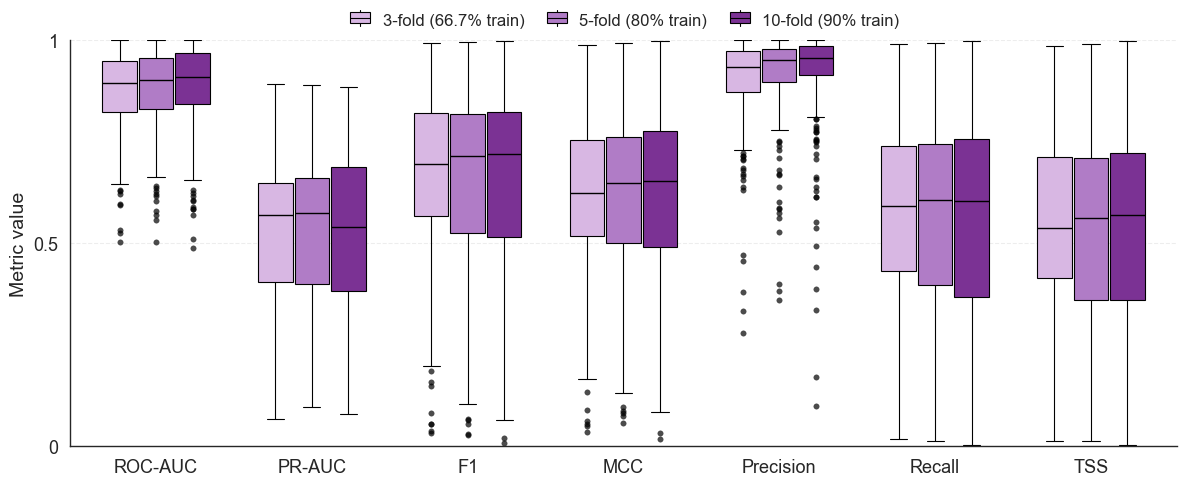

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


sns.set_context(
    "paper",
    font_scale=1.15,
)

sns.set_style("white")


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    candidates = [
        start,
        *start.parents,
    ]

    fallback = Path(
        "/Users/acw792/Developer/qmul-phd-framework"
    )

    if fallback not in candidates:
        candidates.append(fallback)

    for path in candidates:
        if (
            (path / "src/matlab").is_dir()
            and (path / "docs").is_dir()
        ):
            return path

    raise RuntimeError(
        "Could not locate the qmul-phd-framework repository."
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Input configuration
# ============================================================

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)

RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_kfold_20x290_"
        "cvK3-5-10_roleonly_thresh0p50_"
        "trophicv2_Apocrita"
    )
)

RETENTION_DIR = (
    RESULT_DIR
    / "retention_protocol"
    / PROTOCOL_NAME
)

INPUT_PATH = (
    RETENTION_DIR
    / "figure_inputs"
    / "predictive_train10-90_after_tukey.csv"
)

MANIFEST_PATH = (
    RETENTION_DIR
    / "retention_manifest.json"
)

OUT_DIR = (
    RETENTION_DIR
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUT_PATH = (
    OUT_DIR
    / (
        "predictive_metrics_wlnm_dir_neg_kfold_"
        "20runs_cvK3-5-10_roleonly_trophicv2_"
        "threshold0p5_tukey_web_level.png"
    )
)


# ============================================================
# Experimental configuration
# ============================================================

THRESHOLD_TARGET = 0.50
K_TARGET = 10

EXPECTED_FOOD_WEBS = 290

# This is repeated k-fold CV, not the standard 50-run setup.
# Each K has 20 repeated-CV experiments and at least 50%
# must remain after Tukey filtering.
EXPECTED_REPEATED_CV_EXPERIMENTS = 20
MINIMUM_RETAINED_FRACTION = 0.50
MINIMUM_RETAINED_EXPERIMENTS = 10

CVK_ORDER = [
    3,
    5,
    10,
]

EXPECTED_SCENARIO = (
    "kfold_cvK3-5-10_roleonly_"
    "thresh0p50_trophicv2"
)

calculated_minimum = int(
    np.ceil(
        EXPECTED_REPEATED_CV_EXPERIMENTS
        * MINIMUM_RETAINED_FRACTION
    )
)

assert calculated_minimum == MINIMUM_RETAINED_EXPERIMENTS, (
    "The repeated-CV Tukey minimum is inconsistent."
)

SHOW_WEB_LEVEL_FLIERS = True

METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

PLOT_METRICS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]


# ============================================================
# Helpers
# ============================================================

def cvk_label(k: int) -> str:
    train_ratio_map = {
        3: "66.7%",
        5: "80%",
        10: "90%",
    }

    if k in train_ratio_map:
        return (
            f"{k}-fold "
            f"({train_ratio_map[k]} train)"
        )

    return f"{k}-fold"


def validate_retention_manifest(
    manifest_path: Path,
) -> dict:
    if not manifest_path.is_file():
        raise FileNotFoundError(
            "Retention manifest not found:\n"
            f"  {manifest_path}"
        )

    with manifest_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        manifest = json.load(handle)

    source_metadata = manifest.get(
        "source_manifest",
        {},
    )

    expected_metadata = {
        "Version": "WLNM_dir_neg_kfold",
        "Condition": EXPECTED_SCENARIO,
        "Eligibility": "role_only",
        "MassEligibilityEnabled": "false",
        "NegativeSampling": "uniform_without_replacement",
        "NegativeTopupPolicy": "uniform_remaining_nonlinks",
        "TargetNegativePositiveRatio": "2",
        "ClassificationThreshold": "0.50",
        "NumExperimentsPerFold": str(
            EXPECTED_REPEATED_CV_EXPERIMENTS
        ),
        "FoodWebs": str(
            EXPECTED_FOOD_WEBS
        ),
        "CvKList": "3,5,10",
        "SubgraphK": "10",
        "TrophicLevelProtocol": "validated_v2",
        "TrophicHighPrecision": "auto",
        "ComputeEcologicalMetrics": "false",
    }

    mismatches = []

    for key, expected_value in expected_metadata.items():
        actual_value = source_metadata.get(
            key
        )

        if (
            str(actual_value).strip().lower()
            != str(expected_value).strip().lower()
        ):
            mismatches.append(
                f"{key}: expected {expected_value!r}, "
                f"found {actual_value!r}"
            )

    if mismatches:
        raise ValueError(
            "The retention manifest does not match the "
            "expected role-only k-fold configuration:\n  "
            + "\n  ".join(mismatches)
        )

    observed_scenario = manifest.get(
        "scenario"
    )

    if observed_scenario != EXPECTED_SCENARIO:
        raise ValueError(
            "Unexpected scenario in retention manifest:\n"
            f"  expected: {EXPECTED_SCENARIO}\n"
            f"  observed: {observed_scenario}"
        )

    observed_threshold = manifest.get(
        "classification_threshold"
    )

    if (
        observed_threshold is None
        or not np.isclose(
            float(observed_threshold),
            THRESHOLD_TARGET,
            atol=1e-9,
        )
    ):
        raise ValueError(
            "Unexpected classification threshold:\n"
            f"  expected: {THRESHOLD_TARGET}\n"
            f"  observed: {observed_threshold}"
        )

    observed_fraction = manifest.get(
        "minimum_retained_fraction"
    )

    if (
        observed_fraction is None
        or not np.isclose(
            float(observed_fraction),
            MINIMUM_RETAINED_FRACTION,
            atol=1e-12,
        )
    ):
        raise ValueError(
            "Unexpected minimum retained fraction:\n"
            f"  expected: {MINIMUM_RETAINED_FRACTION}\n"
            f"  observed: {observed_fraction}"
        )

    expected_kfold_example = (
        f"{MINIMUM_RETAINED_EXPERIMENTS} of "
        f"{EXPECTED_REPEATED_CV_EXPERIMENTS} "
        "repeated-CV experiments"
    )

    observed_kfold_example = manifest.get(
        "kfold_minimum_example"
    )

    if (
        observed_kfold_example is not None
        and observed_kfold_example
        != expected_kfold_example
    ):
        raise ValueError(
            "Unexpected k-fold retention minimum:\n"
            f"  expected: {expected_kfold_example}\n"
            f"  observed: {observed_kfold_example}"
        )

    print(
        "[INFO] Retention manifest validated."
    )

    print(
        "[INFO] Configuration: role-only eligibility."
    )

    print(
        f"[INFO] Classification threshold: "
        f"{THRESHOLD_TARGET:.2f}."
    )

    print(
        "[INFO] Repeated-CV experiments per K: "
        f"{EXPECTED_REPEATED_CV_EXPERIMENTS}."
    )

    print(
        "[INFO] Minimum retained repeated-CV experiments: "
        f"{MINIMUM_RETAINED_EXPERIMENTS}/"
        f"{EXPECTED_REPEATED_CV_EXPERIMENTS}."
    )

    print(
        "[INFO] Tukey filtering: 1.5×IQR per "
        "food web, CvK and metric."
    )

    return manifest


def load_tukey_web_level_metrics(
    input_path: Path,
):
    required_columns = {
        "Scenario",
        "Foodweb",
        "Version",
        "TrainRatio",
        "Threshold",
        "K",
        "CvK",
        "Metric",
        "MetricLabel",
        "MetricFamily",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "ExpectedRuns",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
    }

    if not input_path.is_file():
        raise FileNotFoundError(
            "Tukey-filtered figure input not found:\n"
            f"  {input_path}"
        )

    print(
        f"[INFO] Using Tukey-filtered input:\n"
        f"  {input_path}"
    )

    df = pd.read_csv(
        input_path
    )

    missing_columns = sorted(
        required_columns.difference(
            df.columns
        )
    )

    if missing_columns:
        raise ValueError(
            "The Tukey input is missing required columns:\n  "
            + "\n  ".join(
                missing_columns
            )
        )

    numeric_columns = [
        "TrainRatio",
        "Threshold",
        "K",
        "CvK",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "ExpectedRuns",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

    # --------------------------------------------------------
    # Select the intended predictive configuration
    # --------------------------------------------------------

    target_df = df.loc[
        df["Scenario"].eq(
            EXPECTED_SCENARIO
        )
        & df["Version"].eq(
            "WLNM_dir_neg_kfold"
        )
        & (
            df["MetricFamily"]
            .astype(str)
            .eq("predictive")
        )
        & df["Metric"].isin(
            METRICS
        )
        & np.isclose(
            df["Threshold"],
            THRESHOLD_TARGET,
            atol=1e-9,
            equal_nan=False,
        )
    ].copy()

    if K_TARGET is not None:
        target_df = target_df.loc[
            target_df["K"].eq(
                K_TARGET
            )
        ].copy()

    target_df = target_df.loc[
        target_df["CvK"].isin(
            CVK_ORDER
        )
    ].copy()

    if target_df.empty:
        raise ValueError(
            "No observations match the required "
            "k-fold predictive configuration."
        )

    # --------------------------------------------------------
    # Validate 20 expected and at least 10 retained experiments
    # --------------------------------------------------------

    observed_expected_runs = set(
        target_df["ExpectedRuns"]
        .dropna()
        .astype(int)
        .unique()
    )

    if observed_expected_runs != {
        EXPECTED_REPEATED_CV_EXPERIMENTS
    }:
        raise ValueError(
            "Unexpected number of repeated-CV experiments:\n"
            f"  expected: "
            f"{EXPECTED_REPEATED_CV_EXPERIMENTS}\n"
            f"  observed: "
            f"{sorted(observed_expected_runs)}"
        )

    observed_minimums = set(
        target_df["MinimumRetainedRuns"]
        .dropna()
        .astype(int)
        .unique()
    )

    if observed_minimums != {
        MINIMUM_RETAINED_EXPERIMENTS
    }:
        raise ValueError(
            "Unexpected Tukey minimum for repeated CV:\n"
            f"  expected: "
            f"{MINIMUM_RETAINED_EXPERIMENTS}\n"
            f"  observed: "
            f"{sorted(observed_minimums)}"
        )

    incorrectly_retained = target_df[
        target_df[
            "MeetsMinimumRetainedRuns"
        ].eq(1)
        & target_df[
            "RetainedRunsAfterTukey"
        ].lt(
            MINIMUM_RETAINED_EXPERIMENTS
        )
    ]

    if not incorrectly_retained.empty:
        display(
            incorrectly_retained[
                [
                    "Foodweb",
                    "CvK",
                    "Metric",
                    "ExpectedRuns",
                    "RetainedRunsAfterTukey",
                    "MinimumRetainedRuns",
                    "MeetsMinimumRetainedRuns",
                ]
            ]
        )

        raise ValueError(
            "At least one group is marked as retained "
            "despite having fewer than "
            f"{MINIMUM_RETAINED_EXPERIMENTS} "
            "repeated-CV experiments."
        )

    # --------------------------------------------------------
    # Keep only groups satisfying the validated minimum
    # --------------------------------------------------------

    df = target_df.loc[
        target_df["ExpectedRuns"].eq(
            EXPECTED_REPEATED_CV_EXPERIMENTS
        )
        & target_df["MinimumRetainedRuns"].eq(
            MINIMUM_RETAINED_EXPERIMENTS
        )
        & target_df["RetainedRunsAfterTukey"].ge(
            MINIMUM_RETAINED_EXPERIMENTS
        )
        & target_df["MeetsMinimumRetainedRuns"].eq(1)
        & target_df["MeanAfterTukey"].notna()
    ].copy()

    if df.empty:
        raise ValueError(
            "No Tukey-filtered observations remained "
            "after validating the repeated-CV minimum."
        )

    print(
        "[INFO] Repeated-CV Tukey minimum validated: "
        f"at least {MINIMUM_RETAINED_EXPERIMENTS} "
        f"of {EXPECTED_REPEATED_CV_EXPERIMENTS} "
        "experiments."
    )

    print(
        "[INFO] Actual retained-experiment range: "
        f"{int(df['RetainedRunsAfterTukey'].min())}–"
        f"{int(df['RetainedRunsAfterTukey'].max())}"
    )

    df["CvK"] = (
        df["CvK"]
        .astype(int)
    )

    # --------------------------------------------------------
    # Validate unique food-web × CvK × metric rows
    # --------------------------------------------------------

    duplicate_mask = df.duplicated(
        subset=[
            "Foodweb",
            "CvK",
            "Metric",
        ],
        keep=False,
    )

    if duplicate_mask.any():
        duplicate_rows = (
            df.loc[
                duplicate_mask,
                [
                    "Foodweb",
                    "CvK",
                    "Metric",
                ],
            ]
            .sort_values(
                [
                    "Foodweb",
                    "CvK",
                    "Metric",
                ]
            )
        )

        raise ValueError(
            "Duplicate food-web/CvK/metric rows were found:\n"
            f"{duplicate_rows.head(20).to_string(index=False)}"
        )

    # --------------------------------------------------------
    # Validate expected food-web coverage
    # --------------------------------------------------------

    coverage = (
        df
        .groupby(
            [
                "CvK",
                "Metric",
            ]
        )["Foodweb"]
        .nunique()
        .unstack(
            "Metric"
        )
        .reindex(
            index=CVK_ORDER,
            columns=METRICS,
        )
    )

    print(
        "\n[INFO] Retained food webs per CvK and metric:"
    )

    display(
        coverage
    )

    incomplete_coverage = (
        coverage.ne(
            EXPECTED_FOOD_WEBS
        )
        | coverage.isna()
    )

    if incomplete_coverage.any().any():
        failed = []

        for cvk in CVK_ORDER:
            for metric in METRICS:
                observed = coverage.loc[
                    cvk,
                    metric,
                ]

                if (
                    pd.isna(observed)
                    or int(observed)
                    != EXPECTED_FOOD_WEBS
                ):
                    failed.append(
                        f"CvK={cvk}, metric={metric}: "
                        f"{observed} food webs"
                    )

        raise ValueError(
            f"Expected {EXPECTED_FOOD_WEBS} retained "
            "food webs for every predictive metric "
            "and CvK:\n  "
            + "\n  ".join(
                failed
            )
        )

    # --------------------------------------------------------
    # Convert metric-specific means to web-level format
    # --------------------------------------------------------

    metric_values = (
        df.pivot(
            index=[
                "Foodweb",
                "CvK",
            ],
            columns="Metric",
            values="MeanAfterTukey",
        )
        .reset_index()
    )

    metric_values.columns.name = None

    metadata = (
        df
        .groupby(
            [
                "Foodweb",
                "CvK",
            ],
            as_index=False,
        )
        .agg(
            TrainRatio=(
                "TrainRatio",
                "median",
            ),
            K=(
                "K",
                "median",
            ),
            Threshold=(
                "Threshold",
                "median",
            ),
            ExpectedExperiments=(
                "ExpectedRuns",
                "min",
            ),
            RequiredMinimumExperiments=(
                "MinimumRetainedRuns",
                "min",
            ),
            MinRetainedExperiments=(
                "RetainedRunsAfterTukey",
                "min",
            ),
            MedianRetainedExperiments=(
                "RetainedRunsAfterTukey",
                "median",
            ),
            MaxRetainedExperiments=(
                "RetainedRunsAfterTukey",
                "max",
            ),
        )
    )

    df_web = metadata.merge(
        metric_values,
        on=[
            "Foodweb",
            "CvK",
        ],
        how="inner",
        validate="one_to_one",
    )

    cvk_to_label = {
        k: cvk_label(k)
        for k in CVK_ORDER
    }

    df_web["CvK_label"] = (
        df_web["CvK"]
        .map(
            cvk_to_label
        )
    )

    missing_metric_values = (
        df_web[
            METRICS
        ]
        .isna()
        .sum()
    )

    if missing_metric_values.any():
        raise ValueError(
            "Missing metric values after converting "
            "the Tukey input to web-level format:\n"
            f"{missing_metric_values[
                missing_metric_values > 0
            ]}"
        )

    return df, df_web


# ============================================================
# Custom legend
# ============================================================

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle[
            "facecolor"
        ]

        edgecolor = orig_handle.get(
            "edgecolor",
            "black",
        )

        linewidth = orig_handle.get(
            "linewidth",
            0.6,
        )

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = (
            box_y
            + box_h
            + 0.18 * height
        )

        whisk_bot_y = (
            box_y
            - 0.18 * height
        )

        box = Rectangle(
            (
                box_x,
                box_y,
            ),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [
                box_x,
                box_x + box_w,
            ],
            [
                cy,
                cy,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [
                cx,
                cx,
            ],
            [
                box_y + box_h,
                whisk_top_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [
                cx,
                cx,
            ],
            [
                whisk_bot_y,
                box_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [
            box,
            median,
            whisker_top,
            whisker_bottom,
        ]


# ============================================================
# Plot
# ============================================================

def plot_kfold_web_level_metrics(
    df_web: pd.DataFrame,
) -> None:
    if df_web.empty:
        raise ValueError(
            "No data are available to plot."
        )

    present_cvks = [
        k
        for k in CVK_ORDER
        if (
            df_web["CvK"] == k
        ).any()
    ]

    if len(present_cvks) < 2:
        raise ValueError(
            "Not enough CV regimes are present to plot."
        )

    cvk_palette = {
        3: "#D8B7E3",
        5: "#B07CC6",
        10: "#7B3294",
    }

    label_map = {
        k: cvk_label(k)
        for k in present_cvks
    }

    fig, ax = plt.subplots(
        figsize=(
            12,
            5,
        )
    )

    group_gap = 1.45

    group_centers = (
        1.0
        + np.arange(
            len(PLOT_METRICS)
        )
        * group_gap
    )

    offsets = np.linspace(
        -0.34,
        0.34,
        len(present_cvks),
    )

    box_width = 0.32

    for j, cvk in enumerate(
        present_cvks
    ):
        data_for_cvk = []
        positions_for_cvk = []

        for i, (
            metric,
            _,
        ) in enumerate(
            PLOT_METRICS
        ):
            values = (
                df_web.loc[
                    df_web["CvK"] == cvk,
                    metric,
                ]
                .dropna()
                .values
            )

            if len(values) == 0:
                continue

            data_for_cvk.append(
                values
            )

            positions_for_cvk.append(
                group_centers[i]
                + offsets[j]
            )

        if not data_for_cvk:
            continue

        boxplot = ax.boxplot(
            data_for_cvk,
            positions=positions_for_cvk,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=SHOW_WEB_LEVEL_FLIERS,
            boxprops={
                "edgecolor": "black",
                "linewidth": 0.8,
            },
            medianprops={
                "color": "black",
                "linewidth": 1.0,
            },
            whiskerprops={
                "color": "black",
                "linewidth": 0.8,
            },
            capprops={
                "color": "black",
                "linewidth": 0.8,
            },
            flierprops={
                "marker": "o",
                "markersize": 4,
                "markerfacecolor": "black",
                "markeredgecolor": "black",
                "markeredgewidth": 0.2,
                "alpha": 0.7,
            },
        )

        for box in boxplot["boxes"]:
            box.set_facecolor(
                cvk_palette[
                    cvk
                ]
            )

    legend_handles = [
        {
            "facecolor": cvk_palette[k],
            "edgecolor": "black",
            "linewidth": 0.8,
        }
        for k in present_cvks
    ]

    ax.set_xlim(
        group_centers[0] - 0.8,
        group_centers[-1] + 0.8,
    )

    ax.set_ylim(
        0,
        1.0,
    )

    ax.set_xticks(
        group_centers
    )

    ax.set_xticklabels(
        [
            label
            for _, label in PLOT_METRICS
        ],
        ha="center",
        fontsize=13,
    )

    ax.set_ylabel(
        "Metric value",
        fontsize=14,
    )

    ax.set_xlabel("")

    ax.tick_params(
        axis="y",
        labelsize=13,
    )

    ax.set_yticks(
        [
            0,
            0.5,
            1.0,
        ]
    )

    ax.set_yticklabels(
        [
            "0",
            "0.5",
            "1",
        ]
    )

    ax.grid(
        True,
        axis="y",
        linestyle="--",
        alpha=0.35,
    )

    sns.despine(
        ax=ax
    )

    ax.legend(
        handles=legend_handles,
        labels=[
            label_map[k]
            for k in present_cvks
        ],
        handler_map={
            dict: HandlerMiniBoxplot()
        },
        loc="lower center",
        bbox_to_anchor=(
            0.5,
            1,
        ),
        ncol=len(
            present_cvks
        ),
        frameon=False,
        fontsize=12,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0.2,
        labelspacing=0.45,
        columnspacing=1.2,
    )

    plt.tight_layout()

    fig.savefig(
        OUT_PATH,
        dpi=300,
        bbox_inches="tight",
    )

    print(
        f"[INFO] Saved figure: "
        f"{OUT_PATH}"
    )

    plt.show()


# ============================================================
# Run
# ============================================================

retention_manifest = validate_retention_manifest(
    MANIFEST_PATH
)

df_retained, df_web = (
    load_tukey_web_level_metrics(
        INPUT_PATH
    )
)

print(
    "\n[INFO] Tukey-filtered metric-level shape:"
)

print(
    df_retained.shape
)

print(
    "\n[INFO] Web-level shape:"
)

print(
    df_web.shape
)

print(
    "\n[INFO] Food-web count per CvK:"
)

print(
    df_web
    .groupby(
        "CvK"
    )["Foodweb"]
    .nunique()
)

retention_summary = (
    df_retained
    .groupby(
        "CvK"
    )
    .agg(
        FoodWebs=(
            "Foodweb",
            "nunique",
        ),
        Metrics=(
            "Metric",
            "nunique",
        ),
        TrainRatio=(
            "TrainRatio",
            "median",
        ),
        Threshold=(
            "Threshold",
            "median",
        ),
        ExpectedExperiments=(
            "ExpectedRuns",
            "min",
        ),
        RequiredMinimumExperiments=(
            "MinimumRetainedRuns",
            "min",
        ),
        MinimumRetainedExperiments=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetainedExperiments=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetainedExperiments=(
            "RetainedRunsAfterTukey",
            "max",
        ),
    )
    .reset_index()
)

print(
    "\n[INFO] Tukey retention summary:"
)

display(
    retention_summary
)

summary_rows = []

for cvk in CVK_ORDER:
    for metric, metric_label in PLOT_METRICS:
        values = (
            df_web.loc[
                df_web["CvK"] == cvk,
                metric,
            ]
            .dropna()
        )

        if values.empty:
            continue

        summary_rows.append(
            {
                "CvK": cvk,
                "Label": cvk_label(
                    cvk
                ),
                "Metric": metric_label,
                "N food webs": int(
                    values.shape[0]
                ),
                "Mean": values.mean(),
                "Median": values.median(),
                "SD": values.std(
                    ddof=1
                ),
                "Variance": values.var(
                    ddof=1
                ),
            }
        )

summary_table = pd.DataFrame(
    summary_rows
)

for column in [
    "Mean",
    "Median",
    "SD",
    "Variance",
]:
    summary_table[column] = (
        summary_table[column]
        .round(4)
    )

print(
    "\n=== Web-level k-fold predictive metric summary "
    "after Tukey filtering at threshold 0.5 ==="
)

display(
    summary_table
)

print(
    "\n[INFO] Final k-fold Tukey configuration:"
)

print(
    f"  expected_repeated_cv_experiments="
    f"{EXPECTED_REPEATED_CV_EXPERIMENTS}"
)

print(
    f"  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    f"  minimum_retained_experiments="
    f"{MINIMUM_RETAINED_EXPERIMENTS}/"
    f"{EXPECTED_REPEATED_CV_EXPERIMENTS}"
)

plot_kfold_web_level_metrics(
    df_web
)

[INFO] Repository: /Users/acw792/Developer/qmul-phd-framework
[INFO] Result root: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848
[INFO] Predictive Tukey input: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
[INFO] Validated final role-only configuration:
  scenario=result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848
  eligibility=role_only
  mass_eligibility_enabled=false
  negative_sampling=uniform_without_replacement
  negative_positive_ratio=2
  negative_topup_policy=uniform_remaining_nonlinks
  classification_threshold=0.50
  number_of_experiments=100
  train_ratio_range=10,20,30,40,50,60,70,80,90
  retention_protocol=tukey_iqr_1p5_min25runs_threshold0p50_v1

,EcosystemType,FoodWebs,ExpectedRuns,RequiredMinimumRuns,MinRunsAveraged,MedianRunsAveraged,MaxRunsAveraged
0,lakes,55,100,25,75,84.0,100
1,marine,134,100,25,52,93.0,100
2,streams,28,100,25,76,86.0,100
3,terrestrial aboveground,21,100,25,76,95.0,100
4,terrestrial belowground,52,100,25,90,98.0,100



=== Web-level precision median and variance by ecosystem ===


,EcosystemType,n_foodwebs,Precision_Median,Precision_Variance
0,lakes,55,1.0000,0.008746
1,marine,134,0.9734,0.010753
2,streams,28,1.0000,0.069065
3,terrestrial aboveground,21,0.9193,0.005634
4,terrestrial belowground,52,0.9238,0.000300



=== Ecosystems with lowest/highest median precision and variance ===
Lowest median precision:  terrestrial aboveground (median = 0.9193, variance = 0.005634, n_foodwebs = 21)
Highest median precision: lakes (median = 1.0, variance = 0.008746, n_foodwebs = 55)
Lowest variance:          terrestrial belowground (variance = 0.0003, median = 0.9238, n_foodwebs = 52)
Highest variance:         streams (variance = 0.069065, median = 1.0, n_foodwebs = 28)
[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/predictive_metrics_wlnm_dir_neg_train90_by_ecosystem_roleonly_trophicv2_100runs_threshold0p50_tukey_min25runs.png
[INFO] Configuration: eligibility=role_only, mass_constraint=False, random_topup=True, negative_positive_ratio=2:1, check_connectivity=False, adaptive_connectivity=False, classification_threshold=0.50, t

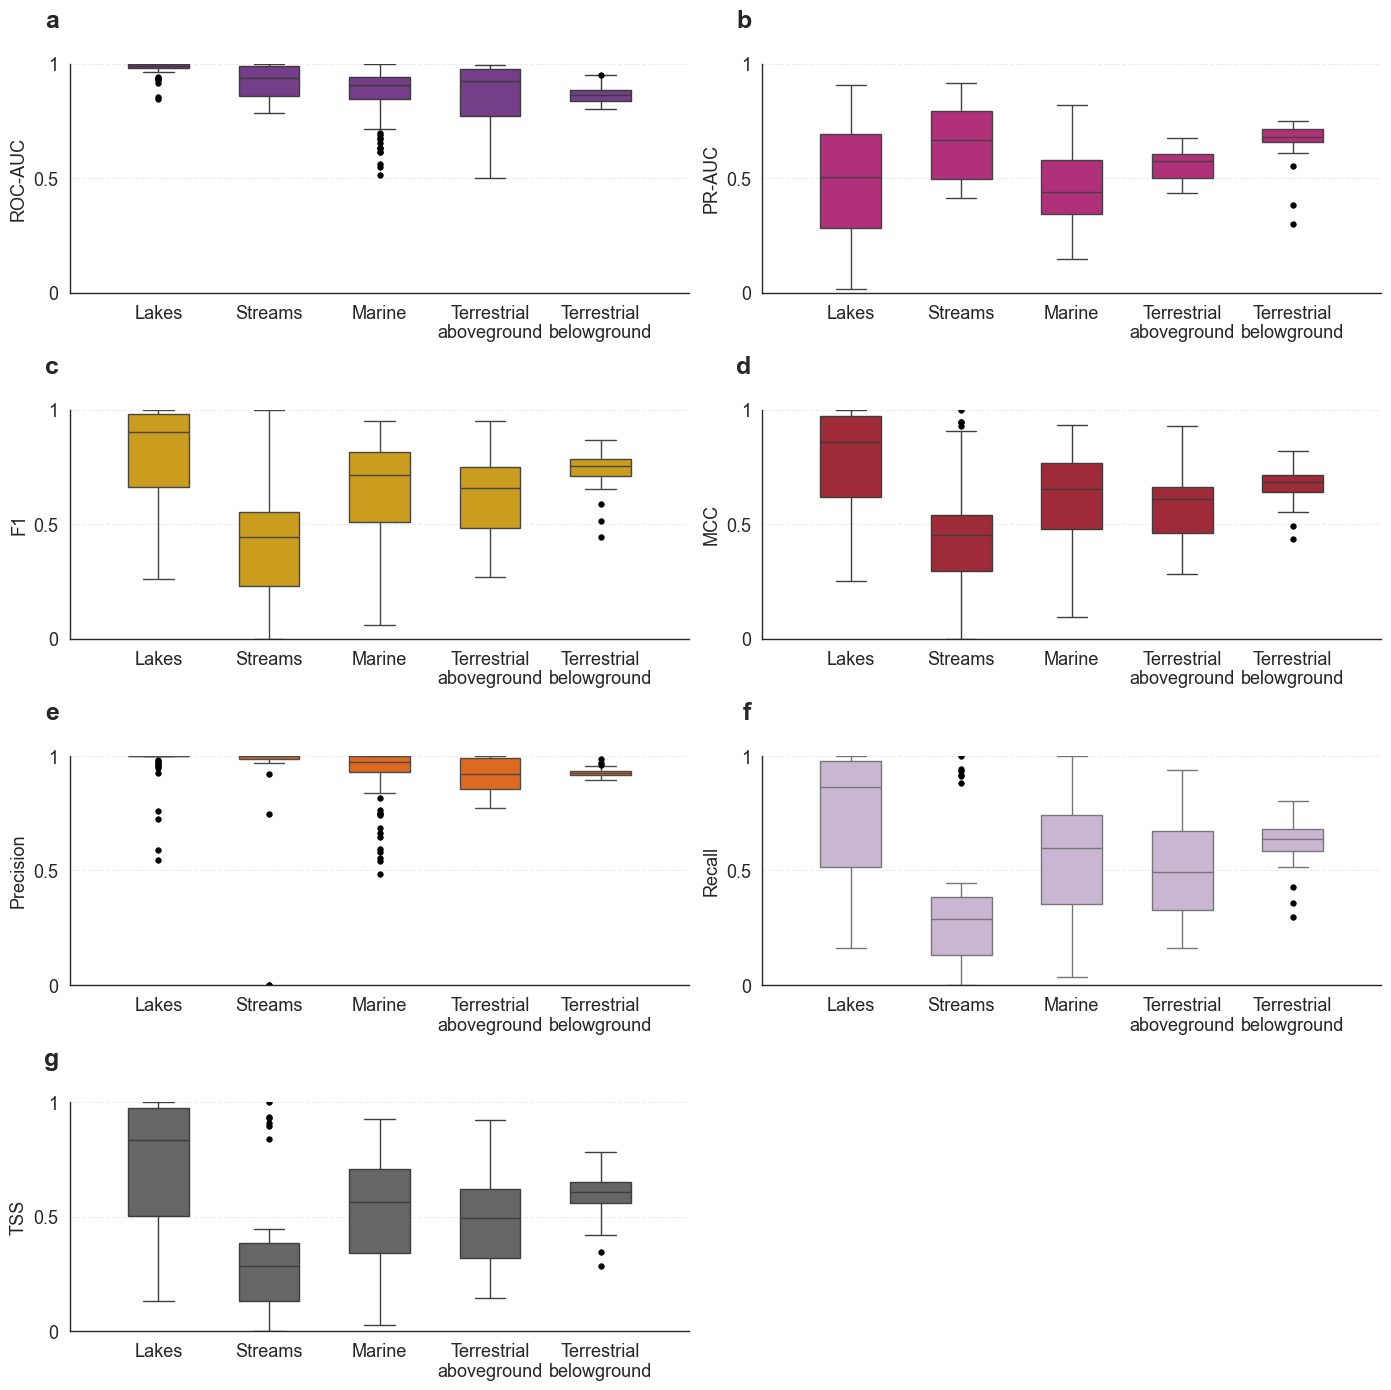

In [2]:
import json
import math

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display


sns.set_context(
    "paper"
)

sns.set_style(
    "white"
)


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    candidates = [
        start,
        *start.parents,
    ]

    fallback = Path(
        "/Users/acw792/Developer/qmul-phd-framework"
    )

    if fallback not in candidates:
        candidates.append(fallback)

    for path in candidates:
        if (
            (path / "src/matlab").is_dir()
            and (path / "docs").is_dir()
        ):
            return path

    raise RuntimeError(
        "Could not locate the qmul-phd-framework repository."
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final role-only configuration
# ============================================================

CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False
CLASSIFICATION_THRESHOLD = 0.50

MIN_NODES = 0
TRAIN_RATIO_TARGET = 90

SHOW_WEB_LEVEL_FLIERS = True

# Tukey is applied independently across 100 runs for each
# food-web × metric group.
#
# Keep the agreed absolute minimum of 25 retained runs.
EXPECTED_RUNS = 100
MINIMUM_RETAINED_FRACTION = 0.25
MINIMUM_RETAINED_RUNS = 25

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min25runs_threshold0p50_v1"
)

EXPECTED_SCENARIO = (
    "result_wlnm_dir_neg_roleonly_trophicv2_"
    "100x290_train10-90_Apocrita_20260910_011848"
)

calculated_minimum = math.ceil(
    EXPECTED_RUNS
    * MINIMUM_RETAINED_FRACTION
)

assert calculated_minimum == MINIMUM_RETAINED_RUNS, (
    "The standard Tukey minimum is inconsistent."
)


# ============================================================
# Final role-only input data
# ============================================================

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_trophicv2_"
        "100x290_train10-90_Apocrita_20260910_011848"
    )
)

RETENTION_ROOT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
)

PREDICTIVE_INPUT = (
    RETENTION_ROOT
    / "figure_inputs"
    / (
        f"predictive_train{TRAIN_RATIO_TARGET}"
        "_after_tukey.csv"
    )
)

RETENTION_MANIFEST = (
    RETENTION_ROOT
    / "retention_manifest.json"
)

ECOSYSTEM_FILE = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)

OUT_DIR = (
    RETENTION_ROOT
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUT_PATH = (
    OUT_DIR
    / (
        "predictive_metrics_wlnm_dir_neg_"
        f"train{TRAIN_RATIO_TARGET}_by_ecosystem_"
        "roleonly_trophicv2_100runs_"
        "threshold0p50_tukey_min25runs.png"
    )
)


# ============================================================
# Metrics
# ============================================================

METRIC_ORDER = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

metric_palette = {
    "ROC_AUC": "#7B3294",
    "PR_AUC": "#C51B7D",
    "Precision": "#FE6100",
    "Recall": "#CAB2D6",
    "F1Score": "#E6AB02",
    "TestMCC": "#B2182B",
    "TestTSS": "#666666",
}

metric_label_map = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}


# ============================================================
# Validate inputs
# ============================================================

required_files = {
    "Tukey-filtered predictive input": PREDICTIVE_INPUT,
    "Ecosystem metadata": ECOSYSTEM_FILE,
    "Tukey retention manifest": RETENTION_MANIFEST,
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "The following required inputs are missing:\n\n"
        + "\n\n".join(missing_files)
    )

print(f"[INFO] Repository: {REPO_ROOT}")
print(f"[INFO] Result root: {RESULT_ROOT}")
print(f"[INFO] Predictive Tukey input: {PREDICTIVE_INPUT}")


# ============================================================
# Validate final role-only configuration
# ============================================================

with RETENTION_MANIFEST.open(
    "r",
    encoding="utf-8",
) as handle:
    retention_manifest = json.load(handle)

manifest = retention_manifest.get(
    "source_manifest",
    {},
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "Eligibility": "role_only",
    "MassEligibilityEnabled": "false",
    "NegativeSampling": "uniform_without_replacement",
    "NegativeTopupPolicy": "uniform_remaining_nonlinks",
    "NegativePositiveRatio": "2",
    "NumExperiments": str(
        EXPECTED_RUNS
    ),
    "SweepTrainRatios": "true",
    "TrainRatioRange": "10,20,30,40,50,60,70,80,90",
    "ClassificationThreshold": "0.50",
    "SubgraphK": "10",
    "TrophicLevelProtocol": "validated_v2",
    "TrophicHighPrecision": "auto",
    "ComputeEcologicalMetrics": "true",
    "MinimumRetainedAfterTukey": str(
        MINIMUM_RETAINED_RUNS
    ),
    "FoodWebs": "290",
}

configuration_errors = []

for key, expected_value in expected_manifest.items():
    observed_value = manifest.get(
        key
    )

    if observed_value is None:
        configuration_errors.append(
            f"{key}: missing"
        )

    elif (
        str(observed_value).casefold()
        != str(expected_value).casefold()
    ):
        configuration_errors.append(
            f"{key}: expected {expected_value}, "
            f"found {observed_value}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result root does not match the "
        "final role-only configuration:\n\n"
        + "\n".join(configuration_errors)
    )

observed_scenario = retention_manifest.get(
    "scenario"
)

if observed_scenario != EXPECTED_SCENARIO:
    raise ValueError(
        "Unexpected scenario in retention_manifest.json:\n"
        f"  expected: {EXPECTED_SCENARIO}\n"
        f"  observed: {observed_scenario}"
    )

observed_threshold = retention_manifest.get(
    "classification_threshold"
)

if (
    observed_threshold is None
    or not np.isclose(
        float(observed_threshold),
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
    )
):
    raise ValueError(
        "The retention protocol does not use "
        f"classification threshold "
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )

observed_fraction = retention_manifest.get(
    "minimum_retained_fraction"
)

if (
    observed_fraction is None
    or not np.isclose(
        float(observed_fraction),
        MINIMUM_RETAINED_FRACTION,
        atol=1e-12,
    )
):
    raise ValueError(
        "Unexpected minimum retained fraction:\n"
        f"  expected: {MINIMUM_RETAINED_FRACTION}\n"
        f"  observed: {observed_fraction}"
    )

expected_standard_example = (
    f"{MINIMUM_RETAINED_RUNS} of {EXPECTED_RUNS}"
)

observed_standard_example = retention_manifest.get(
    "standard_minimum_example"
)

if (
    observed_standard_example is not None
    and observed_standard_example
    != expected_standard_example
):
    raise ValueError(
        "Unexpected standard Tukey minimum:\n"
        f"  expected: {expected_standard_example}\n"
        f"  observed: {observed_standard_example}"
    )

print(
    "[INFO] Validated final role-only configuration:"
)

print(f"  scenario={observed_scenario}")
print(f"  eligibility={manifest['Eligibility']}")

print(
    "  mass_eligibility_enabled="
    f"{manifest['MassEligibilityEnabled']}"
)

print(
    "  negative_sampling="
    f"{manifest['NegativeSampling']}"
)

print(
    "  negative_positive_ratio="
    f"{manifest['NegativePositiveRatio']}"
)

print(
    "  negative_topup_policy="
    f"{manifest['NegativeTopupPolicy']}"
)

print(
    "  classification_threshold="
    f"{manifest['ClassificationThreshold']}"
)

print(
    "  number_of_experiments="
    f"{manifest['NumExperiments']}"
)

print(
    "  train_ratio_range="
    f"{manifest['TrainRatioRange']}"
)

print(
    f"  retention_protocol="
    f"{PROTOCOL_NAME}"
)

print(
    "  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    "  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)


# ============================================================
# Normalisation helpers
# ============================================================

def normalize_colname(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb(value):
    value = Path(
        str(value).strip()
    ).name

    for extension in (
        ".mat",
        ".csv",
    ):
        if value.lower().endswith(
            extension
        ):
            value = value[
                :-len(extension)
            ].rstrip()

    for suffix in (
        "_tax_mass",
        "_taxmass",
    ):
        if value.lower().endswith(
            suffix
        ):
            value = value[
                :-len(suffix)
            ].rstrip()

    return " ".join(
        value.casefold().split()
    )


# ============================================================
# Load ecosystem metadata
# ============================================================

df_ecosystem = pd.read_csv(
    ECOSYSTEM_FILE
)

node_candidates = {
    "nnodes",
    "numnodes",
    "nodes",
    "nodecount",
    "n",
    "s",
}

norm_map = {
    normalize_colname(column): column
    for column in df_ecosystem.columns
}

node_col = next(
    (
        norm_map[candidate]
        for candidate in node_candidates
        if candidate in norm_map
    ),
    None,
)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in "
        "ecosystem metadata."
    )

if (
    "Foodweb" not in df_ecosystem.columns
    or "EcosystemType"
    not in df_ecosystem.columns
):
    raise RuntimeError(
        "The ecosystem metadata must contain "
        "Foodweb and EcosystemType."
    )

df_ecosystem[
    node_col
] = pd.to_numeric(
    df_ecosystem[node_col],
    errors="coerce",
)

df_ecosystem["FW_KEY"] = (
    df_ecosystem["Foodweb"]
    .apply(
        normalize_foodweb
    )
)

duplicated_metadata = (
    df_ecosystem.duplicated(
        subset=["FW_KEY"],
        keep=False,
    )
)

if duplicated_metadata.any():
    inconsistent_metadata = (
        df_ecosystem.loc[
            duplicated_metadata,
            [
                "FW_KEY",
                "EcosystemType",
                node_col,
            ],
        ]
        .groupby(
            "FW_KEY"
        )
        .nunique(
            dropna=False
        )
    )

    inconsistent_metadata = (
        inconsistent_metadata[
            (
                inconsistent_metadata[
                    "EcosystemType"
                ] > 1
            )
            | (
                inconsistent_metadata[
                    node_col
                ] > 1
            )
        ]
    )

    if not inconsistent_metadata.empty:
        display(
            inconsistent_metadata
        )

        raise ValueError(
            "Conflicting metadata were found for one "
            "or more normalised food-web names."
        )

metadata_for_merge = (
    df_ecosystem[
        [
            "FW_KEY",
            "EcosystemType",
            node_col,
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"],
        keep="first",
    )
)


# ============================================================
# Load final role-only Tukey-filtered predictive data
# ============================================================

predictive_raw = pd.read_csv(
    PREDICTIVE_INPUT
)

required_columns = {
    "Scenario",
    "Foodweb",
    "Version",
    "TrainRatio",
    "Threshold",
    "Metric",
    "MetricFamily",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "ExpectedRuns",
    "MinimumRetainedRuns",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
}

missing_columns = sorted(
    required_columns.difference(
        predictive_raw.columns
    )
)

if missing_columns:
    raise ValueError(
        "The predictive Tukey input is missing columns:\n  "
        + "\n  ".join(
            missing_columns
        )
    )

numeric_columns = [
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "ExpectedRuns",
    "MinimumRetainedRuns",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
]

for column in numeric_columns:
    predictive_raw[column] = pd.to_numeric(
        predictive_raw[column],
        errors="coerce",
    )


# ============================================================
# Select requested role-only configuration
# ============================================================

predictive_target = predictive_raw.loc[
    predictive_raw["Scenario"].eq(
        EXPECTED_SCENARIO
    )
    & predictive_raw["Version"].eq(
        "WLNM_dir_neg"
    )
    & (
        predictive_raw["MetricFamily"]
        .astype(str)
        .str.casefold()
        .eq("predictive")
    )
    & predictive_raw["Metric"].isin(
        METRIC_ORDER
    )
    & np.isclose(
        predictive_raw["TrainRatio"],
        TRAIN_RATIO_TARGET,
        atol=1e-9,
        equal_nan=False,
    )
    & np.isclose(
        predictive_raw["Threshold"],
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
        equal_nan=False,
    )
].copy()

if predictive_target.empty:
    raise RuntimeError(
        "No final role-only predictive results were found "
        f"for TrainRatio={TRAIN_RATIO_TARGET} and "
        f"Threshold={CLASSIFICATION_THRESHOLD:.2f}."
    )


# ============================================================
# Validate minimum 25 retained runs
# ============================================================

observed_expected_runs = set(
    predictive_target["ExpectedRuns"]
    .dropna()
    .astype(int)
    .unique()
)

if observed_expected_runs != {
    EXPECTED_RUNS
}:
    raise ValueError(
        "Unexpected number of runs in the Tukey input:\n"
        f"  expected: {EXPECTED_RUNS}\n"
        f"  observed: {sorted(observed_expected_runs)}"
    )

observed_minimums = set(
    predictive_target["MinimumRetainedRuns"]
    .dropna()
    .astype(int)
    .unique()
)

if observed_minimums != {
    MINIMUM_RETAINED_RUNS
}:
    raise ValueError(
        "Unexpected Tukey minimum in the predictive input:\n"
        f"  expected: {MINIMUM_RETAINED_RUNS}\n"
        f"  observed: {sorted(observed_minimums)}"
    )

incorrectly_retained = predictive_target[
    predictive_target[
        "MeetsMinimumRetainedRuns"
    ].eq(1)
    & predictive_target[
        "RetainedRunsAfterTukey"
    ].lt(
        MINIMUM_RETAINED_RUNS
    )
]

if not incorrectly_retained.empty:
    display(
        incorrectly_retained[
            [
                "Foodweb",
                "Metric",
                "ExpectedRuns",
                "RetainedRunsAfterTukey",
                "MinimumRetainedRuns",
                "MeetsMinimumRetainedRuns",
            ]
        ]
    )

    raise ValueError(
        "At least one food-web metric is marked as retained "
        f"despite having fewer than "
        f"{MINIMUM_RETAINED_RUNS} runs."
    )

predictive = predictive_target.loc[
    predictive_target["ExpectedRuns"].eq(
        EXPECTED_RUNS
    )
    & predictive_target[
        "MinimumRetainedRuns"
    ].eq(
        MINIMUM_RETAINED_RUNS
    )
    & predictive_target[
        "RetainedRunsAfterTukey"
    ].ge(
        MINIMUM_RETAINED_RUNS
    )
    & predictive_target[
        "MeetsMinimumRetainedRuns"
    ].eq(1)
    & predictive_target[
        "MeanAfterTukey"
    ].notna()
].copy()

if predictive.empty:
    raise RuntimeError(
        "No predictive results remain after validating "
        f"the minimum of {MINIMUM_RETAINED_RUNS} runs."
    )

print(
    "[INFO] Tukey minimum validated: "
    f"at least {MINIMUM_RETAINED_RUNS} of "
    f"{EXPECTED_RUNS} runs per food web and metric."
)

print(
    "[INFO] Actual retained-run range: "
    f"{int(predictive['RetainedRunsAfterTukey'].min())}–"
    f"{int(predictive['RetainedRunsAfterTukey'].max())}"
)


# ============================================================
# Validate unique food-web × metric observations
# ============================================================

predictive["FW_KEY"] = (
    predictive["Foodweb"]
    .apply(
        normalize_foodweb
    )
)

duplicated_rows = predictive.duplicated(
    subset=[
        "FW_KEY",
        "Metric",
    ],
    keep=False,
)

if duplicated_rows.any():
    duplicated = (
        predictive.loc[
            duplicated_rows,
            [
                "Foodweb",
                "Metric",
                "TrainRatio",
                "Threshold",
            ],
        ]
        .sort_values(
            [
                "Metric",
                "Foodweb",
            ]
        )
    )

    display(
        duplicated
    )

    raise ValueError(
        "More than one retained row was found per "
        "food web and metric."
    )


# ============================================================
# Merge with ecosystem metadata
# ============================================================

predictive = predictive.merge(
    metadata_for_merge,
    on="FW_KEY",
    how="left",
    validate="many_to_one",
)

missing_ecosystem = (
    predictive["EcosystemType"]
    .isna()
)

if missing_ecosystem.any():
    missing_foodwebs = sorted(
        predictive.loc[
            missing_ecosystem,
            "Foodweb",
        ]
        .astype(str)
        .unique()
    )

    raise ValueError(
        "Ecosystem metadata could not be matched for "
        f"{len(missing_foodwebs)} food webs:\n  "
        + "\n  ".join(
            missing_foodwebs[:30]
        )
    )


# ============================================================
# Apply node-count filter
# ============================================================

before_n = (
    predictive["FW_KEY"]
    .nunique()
)

predictive = predictive.loc[
    predictive[node_col].ge(
        MIN_NODES
    )
].copy()

after_n = (
    predictive["FW_KEY"]
    .nunique()
)

print(
    f"[INFO] Filtered food webs by size: "
    f"kept {after_n} / {before_n} "
    f"(>= {MIN_NODES} nodes)."
)

if predictive.empty:
    raise ValueError(
        f"No food webs remain after filtering "
        f"Nodes >= {MIN_NODES}."
    )

print(
    "\n[INFO] Retained metric-food-web observations:"
)

print(
    f"Total rows: "
    f"{len(predictive):,}"
)

print(
    "Rows per ecosystem:"
)

print(
    predictive
    .groupby(
        "EcosystemType"
    )
    .size()
)


# ============================================================
# Adapt input to web-level structure
# ============================================================

metric_values = (
    predictive
    .pivot(
        index=[
            "Foodweb",
            "FW_KEY",
            "EcosystemType",
            node_col,
        ],
        columns="Metric",
        values="MeanAfterTukey",
    )
    .reset_index()
)

metric_values.columns.name = None

missing_metrics = [
    metric
    for metric in METRIC_ORDER
    if metric not in metric_values.columns
]

if missing_metrics:
    raise ValueError(
        "The following predictive metrics are missing "
        "after pivoting:\n  "
        + "\n  ".join(
            missing_metrics
        )
    )

retention_by_web = (
    predictive
    .groupby(
        [
            "Foodweb",
            "FW_KEY",
        ],
        as_index=False,
    )
    .agg(
        ExpectedRuns=(
            "ExpectedRuns",
            "min",
        ),
        RequiredMinimumRuns=(
            "MinimumRetainedRuns",
            "min",
        ),
        RunsAveraged=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MaximumRunsAveraged=(
            "RetainedRunsAfterTukey",
            "max",
        ),
        TotalOutlierRunsExcluded=(
            "OutlierRunsExcluded",
            "sum",
        ),
    )
)

df_web = metric_values.merge(
    retention_by_web,
    on=[
        "Foodweb",
        "FW_KEY",
    ],
    how="left",
    validate="one_to_one",
)

print(
    "\n[INFO] Web-level observations after "
    "Tukey filtering:"
)

print(
    f"Total web-level rows: "
    f"{len(df_web):,}"
)

display(
    df_web
    .groupby(
        "EcosystemType"
    )
    .agg(
        FoodWebs=(
            "Foodweb",
            "nunique",
        ),
        ExpectedRuns=(
            "ExpectedRuns",
            "min",
        ),
        RequiredMinimumRuns=(
            "RequiredMinimumRuns",
            "min",
        ),
        MinRunsAveraged=(
            "RunsAveraged",
            "min",
        ),
        MedianRunsAveraged=(
            "RunsAveraged",
            "median",
        ),
        MaxRunsAveraged=(
            "MaximumRunsAveraged",
            "max",
        ),
    )
    .reset_index()
)


# ============================================================
# Precision summary by ecosystem
# ============================================================

precision_summary = (
    df_web
    .dropna(
        subset=[
            "EcosystemType",
            "Precision",
        ]
    )
    .groupby(
        "EcosystemType",
        as_index=False,
    )
    .agg(
        n_foodwebs=(
            "Foodweb",
            "nunique",
        ),
        Precision_Median=(
            "Precision",
            "median",
        ),
        Precision_Variance=(
            "Precision",
            lambda values: values.var(
                ddof=1
            ),
        ),
    )
)

precision_summary[
    "Precision_Median"
] = (
    precision_summary[
        "Precision_Median"
    ]
    .round(4)
)

precision_summary[
    "Precision_Variance"
] = (
    precision_summary[
        "Precision_Variance"
    ]
    .round(6)
)

print(
    "\n=== Web-level precision median and "
    "variance by ecosystem ==="
)

display(
    precision_summary
)

if precision_summary.empty:
    raise ValueError(
        "The precision summary is empty."
    )

lowest_precision = precision_summary.loc[
    precision_summary[
        "Precision_Median"
    ].idxmin()
]

highest_precision = precision_summary.loc[
    precision_summary[
        "Precision_Median"
    ].idxmax()
]

valid_variance = precision_summary.dropna(
    subset=[
        "Precision_Variance"
    ]
)

if valid_variance.empty:
    raise ValueError(
        "Precision variance could not be calculated "
        "for any ecosystem."
    )

lowest_variance = valid_variance.loc[
    valid_variance[
        "Precision_Variance"
    ].idxmin()
]

highest_variance = valid_variance.loc[
    valid_variance[
        "Precision_Variance"
    ].idxmax()
]

print(
    "\n=== Ecosystems with lowest/highest "
    "median precision and variance ==="
)

print(
    f"Lowest median precision:  "
    f"{lowest_precision['EcosystemType']} "
    f"(median = "
    f"{lowest_precision['Precision_Median']}, "
    f"variance = "
    f"{lowest_precision['Precision_Variance']}, "
    f"n_foodwebs = "
    f"{lowest_precision['n_foodwebs']})"
)

print(
    f"Highest median precision: "
    f"{highest_precision['EcosystemType']} "
    f"(median = "
    f"{highest_precision['Precision_Median']}, "
    f"variance = "
    f"{highest_precision['Precision_Variance']}, "
    f"n_foodwebs = "
    f"{highest_precision['n_foodwebs']})"
)

print(
    f"Lowest variance:          "
    f"{lowest_variance['EcosystemType']} "
    f"(variance = "
    f"{lowest_variance['Precision_Variance']}, "
    f"median = "
    f"{lowest_variance['Precision_Median']}, "
    f"n_foodwebs = "
    f"{lowest_variance['n_foodwebs']})"
)

print(
    f"Highest variance:         "
    f"{highest_variance['EcosystemType']} "
    f"(variance = "
    f"{highest_variance['Precision_Variance']}, "
    f"median = "
    f"{highest_variance['Precision_Median']}, "
    f"n_foodwebs = "
    f"{highest_variance['n_foodwebs']})"
)


# ============================================================
# Prepare long-format web-level data
# ============================================================

df_plot = df_web.melt(
    id_vars=[
        "Foodweb",
        "EcosystemType",
        "RunsAveraged",
    ],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value",
)


# ============================================================
# Preferred ecosystem order
# ============================================================

preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_web["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {
    ecosystem.lower(): ecosystem
    for ecosystem in ecosystems_present
}

ecosystem_order = [
    eco_lookup[ecosystem]
    for ecosystem
    in preferred_ecosystem_order
    if ecosystem in eco_lookup
]

ecosystem_order += [
    ecosystem
    for ecosystem in ecosystems_present
    if ecosystem.lower()
    not in set(
        preferred_ecosystem_order
    )
]


# ============================================================
# Ecosystem labels
# ============================================================

labels_map = (
    df_web[
        [
            "Foodweb",
            "EcosystemType",
        ]
    ]
    .drop_duplicates()
    .groupby(
        "EcosystemType"
    )["Foodweb"]
    .nunique()
    .to_dict()
)


def format_ecosystem_label(
    ecosystem,
    number_foodwebs,
):
    ecosystem_clean = str(
        ecosystem
    ).strip()

    ecosystem_lower = (
        ecosystem_clean.lower()
    )

    label_replacements = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": (
            "Terrestrial\naboveground"
        ),
        "terrestrial belowground": (
            "Terrestrial\nbelowground"
        ),
    }

    return label_replacements.get(
        ecosystem_lower,
        ecosystem_clean.capitalize(),
    )


labels_map = {
    ecosystem: format_ecosystem_label(
        ecosystem,
        number_foodwebs,
    )
    for ecosystem, number_foodwebs
    in labels_map.items()
}

subset = df_plot.copy()

subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True,
)


# ============================================================
# Plot
# ============================================================

n_panels = len(
    METRIC_ORDER
)

n_cols = 2

n_rows = math.ceil(
    n_panels / n_cols
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(
        14,
        14,
    ),
    sharey=False,
)

axes = np.array(
    axes
).reshape(-1)

panel_letters = list(
    "abcdefghijklmnopqrstuvwxyz"
)

for index, metric in enumerate(
    METRIC_ORDER
):
    ax = axes[
        index
    ]

    sub = subset[
        subset["Metric"] == metric
    ].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="EcosystemType",
        y="Value",
        order=ecosystem_order,
        color=metric_palette.get(
            metric,
            "#7B3294",
        ),
        width=0.55,
        showfliers=(
            SHOW_WEB_LEVEL_FLIERS
        ),
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    legend = ax.get_legend()

    if legend is not None:
        legend.remove()

    ax.set_xlabel("")

    ax.set_xticks(
        range(
            len(ecosystem_order)
        )
    )

    ax.set_xticklabels(
        [
            labels_map.get(
                ecosystem,
                ecosystem,
            )
            for ecosystem
            in ecosystem_order
        ],
        rotation=0,
        ha="center",
        fontsize=13,
        linespacing=1.1,
    )

    ax.set_ylabel(
        metric_label_map.get(
            metric,
            metric,
        ),
        fontsize=13,
    )

    ax.tick_params(
        axis="y",
        labelsize=13,
    )

    ax.set_yticks(
        [
            0,
            0.5,
            1.0,
        ]
    )

    ax.set_yticklabels(
        [
            "0",
            "0.5",
            "1",
        ]
    )

    ax.grid(
        True,
        axis="y",
        linestyle="--",
        alpha=0.35,
    )

    ax.set_xlim(
        -0.8,
        len(ecosystem_order)
        - 1
        + 0.8,
    )

    ax.set_ylim(
        0,
        1.0,
    )

    ax.grid(
        False,
        axis="x",
    )

    sns.despine(
        ax=ax
    )

    ax.annotate(
        panel_letters[index],
        xy=(
            0,
            1.1,
        ),
        xycoords="axes fraction",
        xytext=(
            -8,
            6,
        ),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

for panel_index in range(
    n_panels,
    len(axes),
):
    axes[
        panel_index
    ].set_axis_off()

fig.tight_layout(
    rect=[
        0,
        0,
        1,
        1,
    ],
    w_pad=1,
    h_pad=1,
)

fig.savefig(
    OUT_PATH,
    dpi=300,
    bbox_inches="tight",
)

print(
    f"[INFO] Saved figure: "
    f"{OUT_PATH}"
)

print(
    "[INFO] Configuration: "
    "eligibility=role_only, "
    "mass_constraint=False, "
    "random_topup=True, "
    "negative_positive_ratio=2:1, "
    "check_connectivity=False, "
    "adaptive_connectivity=False, "
    "classification_threshold=0.50, "
    f"train_ratio={TRAIN_RATIO_TARGET}."
)

print(
    "[INFO] Final Tukey configuration:"
)

print(
    f"  expected_runs="
    f"{EXPECTED_RUNS}"
)

print(
    f"  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    f"  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)

plt.show()

[INFO] Repository: /Users/acw792/Developer/qmul-phd-framework
[INFO] Result root: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848
[INFO] Predictive Tukey input: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
[INFO] Validated final role-only configuration:
  scenario=result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848
  eligibility=role_only
  mass_eligibility_enabled=false
  negative_sampling=uniform_without_replacement
  negative_positive_ratio=2
  negative_topup_policy=uniform_remaining_nonlinks
  classification_threshold=0.50
  number_of_experiments=100
  train_ratio_range=10,20,30,40,50,60,70,80,90
  retention_protocol=tukey_iqr_1p5_min25runs_threshold0p50_v1

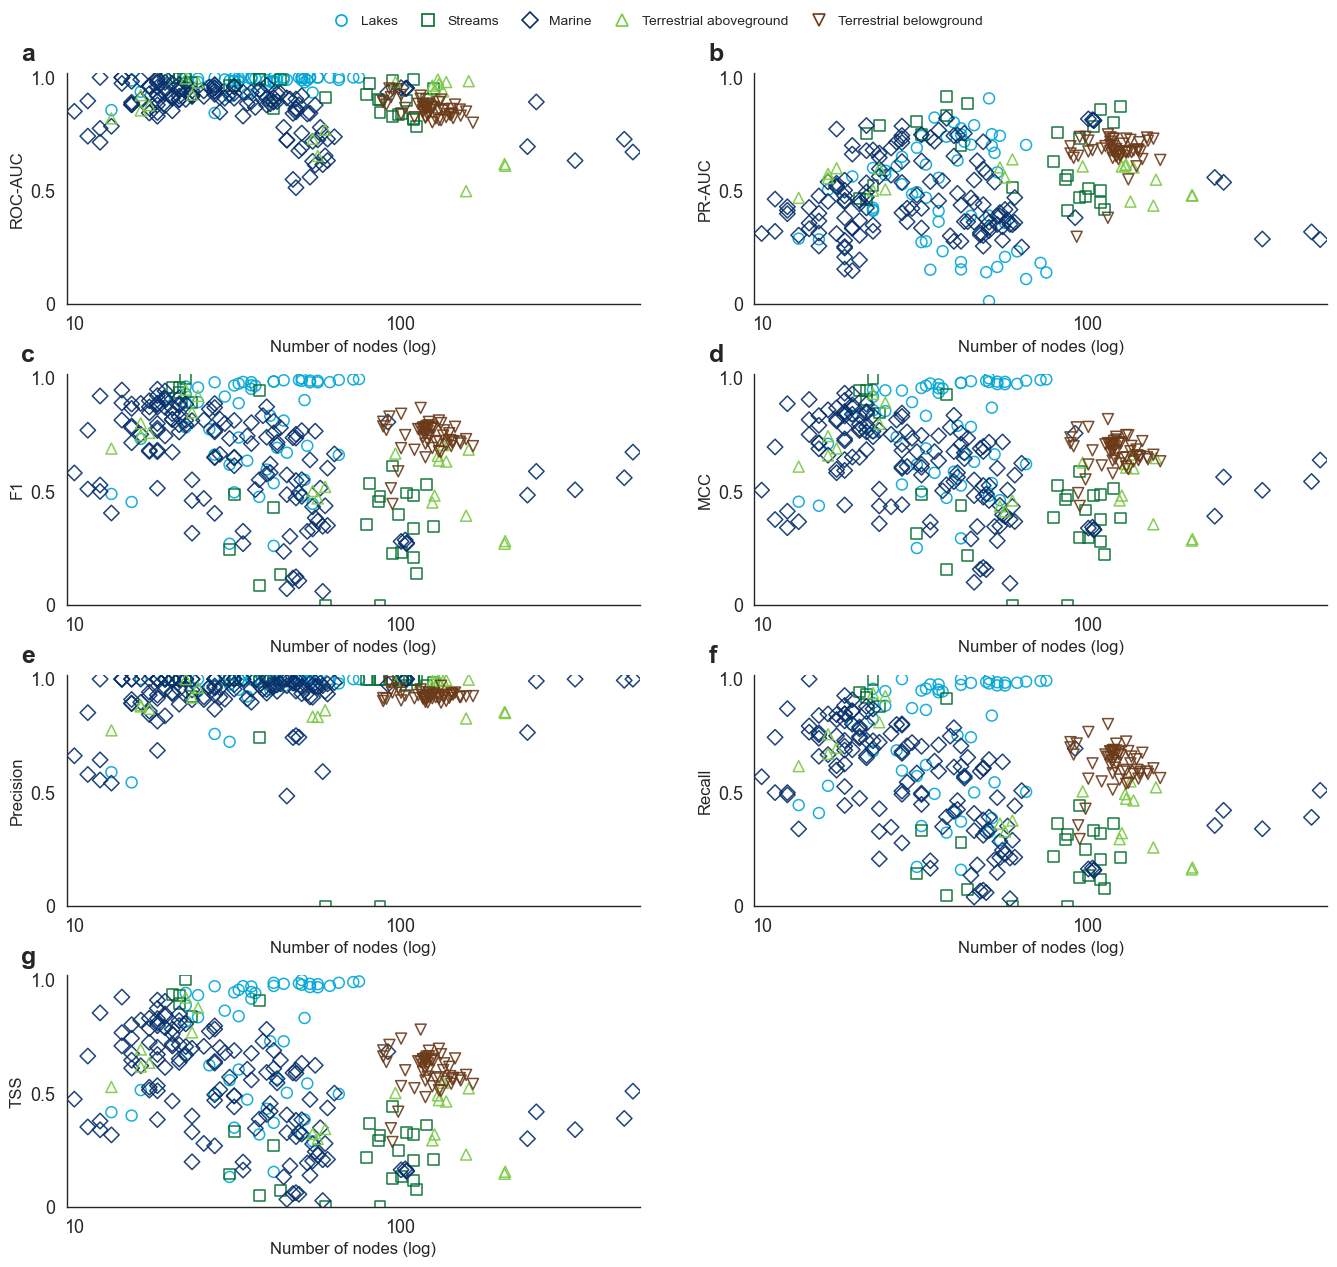

In [1]:
import os
import json
import math
import tempfile

from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(
        Path(tempfile.gettempdir())
        / "qmul_phd_framework_mplconfig"
    ),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter


sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.2,
)


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    candidates = [
        start,
        *start.parents,
    ]

    fallback = Path(
        "/Users/acw792/Developer/qmul-phd-framework"
    )

    if fallback not in candidates:
        candidates.append(fallback)

    for candidate in candidates:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the qmul-phd-framework repository."
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final role-only configuration
# ============================================================

CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False
CLASSIFICATION_THRESHOLD = 0.50

TARGET_RATIO = 90.0
MIN_NODES = 0

# Tukey is applied across 100 runs independently for each
# food-web × metric group.
#
# Keep the agreed absolute minimum of 25 retained runs.
EXPECTED_RUNS = 100
MINIMUM_RETAINED_FRACTION = 0.25
MINIMUM_RETAINED_RUNS = 25

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min25runs_threshold0p50_v1"
)

EXPECTED_SCENARIO = (
    "result_wlnm_dir_neg_roleonly_trophicv2_"
    "100x290_train10-90_Apocrita_20260910_011848"
)

calculated_minimum = math.ceil(
    EXPECTED_RUNS
    * MINIMUM_RETAINED_FRACTION
)

assert calculated_minimum == MINIMUM_RETAINED_RUNS, (
    "The Tukey minimum is inconsistent."
)

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_trophicv2_"
        "100x290_train10-90_Apocrita_20260910_011848"
    )
)

RETENTION_ROOT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
)

PREDICTIVE_INPUT = (
    RETENTION_ROOT
    / "figure_inputs"
    / (
        f"predictive_train{int(TARGET_RATIO)}"
        "_after_tukey.csv"
    )
)

RETENTION_MANIFEST = (
    RETENTION_ROOT
    / "retention_manifest.json"
)

ECOSYSTEM_FILE = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)


# ============================================================
# Figure configuration
# ============================================================

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
X_MAX = 550
N_COLS = 2


# ============================================================
# Helpers
# ============================================================

def normalize_colname(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(value):
    value = Path(
        str(value).strip()
    ).name

    for extension in (
        ".mat",
        ".csv",
    ):
        if value.lower().endswith(
            extension
        ):
            value = value[
                :-len(extension)
            ].rstrip()

    for suffix in (
        "_tax_mass",
        "_taxmass",
    ):
        if value.lower().endswith(
            suffix
        ):
            value = value[
                :-len(suffix)
            ].rstrip()

    return " ".join(
        value.casefold().split()
    )


def find_column(
    dataframe,
    candidates,
):
    norm_map = {
        normalize_colname(column): column
        for column in dataframe.columns
    }

    for candidate in candidates:
        normalized_candidate = normalize_colname(
            candidate
        )

        if normalized_candidate in norm_map:
            return norm_map[
                normalized_candidate
            ]

    raise KeyError(
        "Could not find any of these columns: "
        f"{candidates}"
    )


def normalize_train_ratio(series):
    values = pd.to_numeric(
        series,
        errors="coerce",
    )

    return np.where(
        values <= 1.0,
        values * 100.0,
        values,
    )


def format_ecosystem_label(name):
    name = str(
        name
    ).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": (
            "Terrestrial aboveground"
        ),
        "terrestrial belowground": (
            "Terrestrial belowground"
        ),
        "unknown": "Unknown",
    }

    return label_map.get(
        name,
        str(name).strip().capitalize(),
    )


def format_p_value(p_value):
    if pd.isna(
        p_value
    ):
        return "P = NA"

    if p_value < 0.0001:
        return "P < 0.0001"

    return f"P = {p_value:.4f}"


def format_equation(
    intercept,
    slope,
):
    sign = (
        "+"
        if slope >= 0
        else "-"
    )

    return (
        f"y = {intercept:.6f} "
        f"{sign} {abs(slope):.6f}x"
    )


# ============================================================
# Regression helper
# ============================================================

def fit_linear_regression(
    data,
    x_col,
    y_col,
    n_points=100,
):
    """
    Fits an OLS linear regression:

        y_col ~ x_col

    For this figure:

        metric ~ Nodes
    """

    work = (
        data[
            [
                x_col,
                y_col,
            ]
        ]
        .dropna()
        .copy()
    )

    if work.empty:
        return None

    work[x_col] = (
        work[x_col]
        .astype(float)
    )

    work[y_col] = (
        work[y_col]
        .astype(float)
    )

    if (
        len(work) < 3
        or work[x_col].nunique() < 2
    ):
        return None

    x = work[
        [x_col]
    ]

    y = work[
        y_col
    ]

    x_model = sm.add_constant(
        x,
        has_constant="add",
    )

    model = sm.OLS(
        y,
        x_model,
    ).fit()

    intercept = model.params[
        "const"
    ]

    slope = model.params[
        x_col
    ]

    x_line = np.linspace(
        work[x_col].min(),
        work[x_col].max(),
        n_points,
    )

    x_line_model = pd.DataFrame(
        {
            x_col: x_line
        }
    )

    x_line_model = sm.add_constant(
        x_line_model,
        has_constant="add",
    )

    y_line = model.predict(
        x_line_model
    )

    return {
        "x_line": x_line,
        "y_line": y_line,
        "intercept": intercept,
        "slope": slope,
        "f_value": model.fvalue,
        "df_model": int(
            model.df_model
        ),
        "df_resid": int(
            model.df_resid
        ),
        "p_value": model.pvalues[
            x_col
        ],
        "r_squared": model.rsquared,
        "n": len(work),
        "model": model,
    }


# ============================================================
# Validate selected inputs
# ============================================================

required_files = {
    "Tukey-filtered predictive input": (
        PREDICTIVE_INPUT
    ),
    "Ecosystem metadata": (
        ECOSYSTEM_FILE
    ),
    "Tukey retention manifest": (
        RETENTION_MANIFEST
    ),
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n\n"
        + "\n\n".join(
            missing_files
        )
    )

print(f"[INFO] Repository: {REPO_ROOT}")
print(f"[INFO] Result root: {RESULT_ROOT}")
print(f"[INFO] Predictive Tukey input: {PREDICTIVE_INPUT}")


# ============================================================
# Validate final role-only result configuration
# ============================================================

with RETENTION_MANIFEST.open(
    "r",
    encoding="utf-8",
) as handle:
    retention_manifest = json.load(handle)

manifest = retention_manifest.get(
    "source_manifest",
    {},
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "Eligibility": "role_only",
    "MassEligibilityEnabled": "false",
    "NegativeSampling": "uniform_without_replacement",
    "NegativeTopupPolicy": "uniform_remaining_nonlinks",
    "NegativePositiveRatio": "2",
    "NumExperiments": str(
        EXPECTED_RUNS
    ),
    "SweepTrainRatios": "true",
    "TrainRatioRange": "10,20,30,40,50,60,70,80,90",
    "ClassificationThreshold": "0.50",
    "SubgraphK": "10",
    "TrophicLevelProtocol": "validated_v2",
    "TrophicHighPrecision": "auto",
    "ComputeEcologicalMetrics": "true",
    "MinimumRetainedAfterTukey": str(
        MINIMUM_RETAINED_RUNS
    ),
    "FoodWebs": "290",
}

configuration_errors = []

for key, expected_value in expected_manifest.items():
    observed_value = manifest.get(
        key
    )

    if observed_value is None:
        configuration_errors.append(
            f"{key}: missing"
        )

    elif (
        str(observed_value).casefold()
        != str(expected_value).casefold()
    ):
        configuration_errors.append(
            f"{key}: expected {expected_value}, "
            f"found {observed_value}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result directory does not match "
        "the final role-only configuration:\n\n"
        + "\n".join(
            configuration_errors
        )
    )

observed_scenario = retention_manifest.get(
    "scenario"
)

if observed_scenario != EXPECTED_SCENARIO:
    raise ValueError(
        "Unexpected scenario in retention_manifest.json:\n"
        f"  expected: {EXPECTED_SCENARIO}\n"
        f"  observed: {observed_scenario}"
    )

observed_threshold = retention_manifest.get(
    "classification_threshold"
)

if (
    observed_threshold is None
    or not np.isclose(
        float(observed_threshold),
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
    )
):
    raise ValueError(
        "The Tukey retention protocol does not use "
        f"classification threshold "
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )

observed_fraction = retention_manifest.get(
    "minimum_retained_fraction"
)

if (
    observed_fraction is None
    or not np.isclose(
        float(observed_fraction),
        MINIMUM_RETAINED_FRACTION,
        atol=1e-12,
    )
):
    raise ValueError(
        "Unexpected minimum retained fraction:\n"
        f"  expected: {MINIMUM_RETAINED_FRACTION}\n"
        f"  observed: {observed_fraction}"
    )

expected_standard_example = (
    f"{MINIMUM_RETAINED_RUNS} of {EXPECTED_RUNS}"
)

observed_standard_example = retention_manifest.get(
    "standard_minimum_example"
)

if (
    observed_standard_example is not None
    and observed_standard_example
    != expected_standard_example
):
    raise ValueError(
        "Unexpected standard Tukey minimum:\n"
        f"  expected: {expected_standard_example}\n"
        f"  observed: {observed_standard_example}"
    )

print(
    "[INFO] Validated final role-only configuration:"
)

print(f"  scenario={observed_scenario}")
print(f"  eligibility={manifest['Eligibility']}")

print(
    "  mass_eligibility_enabled="
    f"{manifest['MassEligibilityEnabled']}"
)

print(
    "  negative_sampling="
    f"{manifest['NegativeSampling']}"
)

print(
    "  negative_positive_ratio="
    f"{manifest['NegativePositiveRatio']}"
)

print(
    "  negative_topup_policy="
    f"{manifest['NegativeTopupPolicy']}"
)

print(
    "  classification_threshold="
    f"{manifest['ClassificationThreshold']}"
)

print(
    "  number_of_experiments="
    f"{manifest['NumExperiments']}"
)

print(
    "  train_ratio_range="
    f"{manifest['TrainRatioRange']}"
)

print(
    f"  retention_protocol="
    f"{PROTOCOL_NAME}"
)

print(
    "  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    "  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)


# ============================================================
# Load ecosystem metadata
# ============================================================

df_ecosystem = pd.read_csv(
    ECOSYSTEM_FILE
).copy()

foodweb_col = find_column(
    df_ecosystem,
    [
        "foodweb",
    ],
)

ecosystem_col = find_column(
    df_ecosystem,
    [
        "ecosystemtype",
        "ecosystem",
        "ecosystem_type",
    ],
)

nodes_col = find_column(
    df_ecosystem,
    [
        "nodes",
        "n_nodes",
        "num_nodes",
        "nodecount",
        "s",
    ],
)

df_ecosystem = (
    df_ecosystem.rename(
        columns={
            foodweb_col: (
                "MetadataFoodweb"
            ),
            ecosystem_col: (
                "EcosystemType"
            ),
            nodes_col: (
                "Nodes"
            ),
        }
    )
)

df_ecosystem = (
    df_ecosystem[
        [
            "MetadataFoodweb",
            "EcosystemType",
            "Nodes",
        ]
    ]
    .copy()
)

df_ecosystem[
    "MetadataFoodweb"
] = (
    df_ecosystem[
        "MetadataFoodweb"
    ]
    .astype(str)
)

df_ecosystem[
    "FoodwebKey"
] = (
    df_ecosystem[
        "MetadataFoodweb"
    ]
    .apply(
        normalize_foodweb_name
    )
)

df_ecosystem[
    "EcosystemType"
] = (
    df_ecosystem[
        "EcosystemType"
    ]
    .astype(str)
    .str.strip()
)

df_ecosystem[
    "Nodes"
] = pd.to_numeric(
    df_ecosystem[
        "Nodes"
    ],
    errors="coerce",
)

duplicate_metadata = (
    df_ecosystem.duplicated(
        subset=[
            "FoodwebKey"
        ],
        keep=False,
    )
)

if duplicate_metadata.any():
    conflicting_metadata = (
        df_ecosystem.loc[
            duplicate_metadata,
            [
                "FoodwebKey",
                "EcosystemType",
                "Nodes",
            ],
        ]
        .groupby(
            "FoodwebKey"
        )
        .nunique(
            dropna=False
        )
    )

    conflicting_metadata = (
        conflicting_metadata[
            (
                conflicting_metadata[
                    "EcosystemType"
                ] > 1
            )
            | (
                conflicting_metadata[
                    "Nodes"
                ] > 1
            )
        ]
    )

    if not conflicting_metadata.empty:
        print(
            conflicting_metadata
        )

        raise ValueError(
            "Conflicting ecosystem or node metadata "
            "were found for one or more food webs."
        )

df_ecosystem = (
    df_ecosystem
    .drop_duplicates(
        subset=[
            "FoodwebKey",
        ],
        keep="first",
    )
    .copy()
)


# ============================================================
# Load final role-only Tukey-filtered results
# ============================================================

tukey_raw = pd.read_csv(
    PREDICTIVE_INPUT
).copy()

required_columns = {
    "Scenario",
    "Foodweb",
    "Version",
    "TrainRatio",
    "Threshold",
    "Metric",
    "MetricFamily",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "ExpectedRuns",
    "MinimumRetainedRuns",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
}

missing_columns = sorted(
    required_columns.difference(
        tukey_raw.columns
    )
)

if missing_columns:
    raise ValueError(
        "The Tukey-filtered input is missing columns:\n  "
        + "\n  ".join(
            missing_columns
        )
    )

numeric_columns = [
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "ExpectedRuns",
    "MinimumRetainedRuns",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
]

for column in numeric_columns:
    tukey_raw[column] = pd.to_numeric(
        tukey_raw[column],
        errors="coerce",
    )

tukey_raw[
    "TrainRatio"
] = normalize_train_ratio(
    tukey_raw[
        "TrainRatio"
    ]
)

metric_columns = [
    metric_column
    for metric_column, _
    in METRIC_SPECS
]


# ============================================================
# Select requested role-only configuration
# ============================================================

tukey_target = tukey_raw.loc[
    tukey_raw["Scenario"].eq(
        EXPECTED_SCENARIO
    )
    & tukey_raw["Version"].eq(
        "WLNM_dir_neg"
    )
    & (
        tukey_raw["MetricFamily"]
        .astype(str)
        .str.casefold()
        .eq("predictive")
    )
    & tukey_raw["Metric"].isin(
        metric_columns
    )
    & np.isclose(
        tukey_raw["TrainRatio"],
        TARGET_RATIO,
        atol=1e-9,
        equal_nan=False,
    )
    & np.isclose(
        tukey_raw["Threshold"],
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
        equal_nan=False,
    )
].copy()

if tukey_target.empty:
    raise RuntimeError(
        "No final role-only results were found "
        f"for TrainRatio={TARGET_RATIO}, "
        f"Threshold={CLASSIFICATION_THRESHOLD:.2f}."
    )


# ============================================================
# Validate minimum 25 retained runs
# ============================================================

observed_expected_runs = set(
    tukey_target["ExpectedRuns"]
    .dropna()
    .astype(int)
    .unique()
)

if observed_expected_runs != {
    EXPECTED_RUNS
}:
    raise ValueError(
        "Unexpected number of runs in the Tukey input:\n"
        f"  expected: {EXPECTED_RUNS}\n"
        f"  observed: {sorted(observed_expected_runs)}"
    )

observed_minimums = set(
    tukey_target["MinimumRetainedRuns"]
    .dropna()
    .astype(int)
    .unique()
)

if observed_minimums != {
    MINIMUM_RETAINED_RUNS
}:
    raise ValueError(
        "Unexpected Tukey minimum in the input:\n"
        f"  expected: {MINIMUM_RETAINED_RUNS}\n"
        f"  observed: {sorted(observed_minimums)}"
    )

incorrectly_retained = tukey_target[
    tukey_target[
        "MeetsMinimumRetainedRuns"
    ].eq(1)
    & tukey_target[
        "RetainedRunsAfterTukey"
    ].lt(
        MINIMUM_RETAINED_RUNS
    )
]

if not incorrectly_retained.empty:
    print(
        incorrectly_retained[
            [
                "Foodweb",
                "Metric",
                "ExpectedRuns",
                "RetainedRunsAfterTukey",
                "MinimumRetainedRuns",
                "MeetsMinimumRetainedRuns",
            ]
        ]
    )

    raise ValueError(
        "At least one food-web metric is marked as retained "
        f"despite having fewer than "
        f"{MINIMUM_RETAINED_RUNS} runs."
    )

tukey_results = tukey_target.loc[
    tukey_target["ExpectedRuns"].eq(
        EXPECTED_RUNS
    )
    & tukey_target[
        "MinimumRetainedRuns"
    ].eq(
        MINIMUM_RETAINED_RUNS
    )
    & tukey_target[
        "RetainedRunsAfterTukey"
    ].ge(
        MINIMUM_RETAINED_RUNS
    )
    & tukey_target[
        "MeetsMinimumRetainedRuns"
    ].eq(1)
    & tukey_target[
        "MeanAfterTukey"
    ].notna()
].copy()

if tukey_results.empty:
    raise RuntimeError(
        "No results remain after validating the "
        f"minimum of {MINIMUM_RETAINED_RUNS} runs."
    )

print(
    "[INFO] Tukey minimum validated: "
    f"at least {MINIMUM_RETAINED_RUNS} of "
    f"{EXPECTED_RUNS} runs per food web and metric."
)

print(
    "[INFO] Actual retained-run range: "
    f"{int(tukey_results['RetainedRunsAfterTukey'].min())}–"
    f"{int(tukey_results['RetainedRunsAfterTukey'].max())}"
)


# ============================================================
# Validate unique food-web × metric rows
# ============================================================

tukey_results[
    "FoodwebKey"
] = (
    tukey_results[
        "Foodweb"
    ]
    .apply(
        normalize_foodweb_name
    )
)

duplicate_groups = (
    tukey_results
    .duplicated(
        subset=[
            "FoodwebKey",
            "Metric",
        ],
        keep=False,
    )
)

if duplicate_groups.any():
    duplicated = (
        tukey_results.loc[
            duplicate_groups,
            [
                "Foodweb",
                "Metric",
                "TrainRatio",
                "Threshold",
            ],
        ]
        .sort_values(
            [
                "Metric",
                "Foodweb",
            ]
        )
    )

    print(
        duplicated
    )

    raise ValueError(
        "More than one retained row was found per "
        "food web and metric."
    )


# ============================================================
# Retention summary
# ============================================================

retention_summary = (
    tukey_results
    .groupby(
        "Metric",
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FoodwebKey",
            "nunique",
        ),
        ExpectedRuns=(
            "ExpectedRuns",
            "min",
        ),
        RequiredMinimumRuns=(
            "MinimumRetainedRuns",
            "min",
        ),
        MinimumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetainedRuns=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "max",
        ),
        TotalOutliersExcluded=(
            "OutlierRunsExcluded",
            "sum",
        ),
    )
)

print(
    "\n=== Tukey retention by predictive metric ==="
)

print(
    retention_summary.to_string(
        index=False
    )
)


# ============================================================
# Convert metric rows to wide food-web format
# ============================================================

df_all = (
    tukey_results
    .pivot(
        index=[
            "Foodweb",
            "FoodwebKey",
        ],
        columns="Metric",
        values="MeanAfterTukey",
    )
    .reset_index()
    .copy()
)

df_all.columns.name = None


# ============================================================
# Merge metadata and apply node filter
# ============================================================

df_merged = (
    df_all.merge(
        df_ecosystem[
            [
                "FoodwebKey",
                "EcosystemType",
                "Nodes",
            ]
        ],
        on="FoodwebKey",
        how="left",
        validate="one_to_one",
    )
    .copy()
)

missing_metadata = (
    df_merged[
        "EcosystemType"
    ].isna()
    | df_merged[
        "Nodes"
    ].isna()
)

if missing_metadata.any():
    missing_foodwebs = sorted(
        df_merged.loc[
            missing_metadata,
            "Foodweb",
        ]
        .astype(str)
        .unique()
    )

    raise ValueError(
        "Ecosystem or node metadata could not be matched "
        f"for {len(missing_foodwebs)} food webs:\n  "
        + "\n  ".join(
            missing_foodwebs[:30]
        )
    )

df_merged[
    "Nodes"
] = pd.to_numeric(
    df_merged[
        "Nodes"
    ],
    errors="coerce",
)

df_merged[
    "EcosystemType"
] = (
    df_merged[
        "EcosystemType"
    ]
    .fillna(
        "Unknown"
    )
)

for metric_column in metric_columns:
    if metric_column not in df_merged.columns:
        raise RuntimeError(
            f"Required metric column "
            f"'{metric_column}' is missing."
        )

    df_merged[
        metric_column
    ] = pd.to_numeric(
        df_merged[
            metric_column
        ],
        errors="coerce",
    )

before_rows = len(
    df_merged
)

before_foodwebs = (
    df_merged[
        "Foodweb"
    ]
    .nunique()
)

df_tr = df_merged.loc[
    df_merged[
        "Nodes"
    ].ge(
        MIN_NODES
    )
].copy()

after_rows = len(
    df_tr
)

after_foodwebs = (
    df_tr[
        "Foodweb"
    ]
    .nunique()
)

print(
    f"Filtered data: TrainRatio = {TARGET_RATIO}, "
    f"Threshold = {CLASSIFICATION_THRESHOLD:.2f}, "
    f"Nodes >= {MIN_NODES}. "
    f"Rows kept: {after_rows} / {before_rows}. "
    f"Food webs kept: "
    f"{after_foodwebs} / {before_foodwebs}."
)

if df_tr.empty:
    raise RuntimeError(
        "No rows remain after applying the "
        "node-count filter."
    )


# ============================================================
# One observation per food web
# ============================================================

agg_dict = {
    metric_column: "mean"
    for metric_column, _
    in METRIC_SPECS
}

df_scatter = (
    df_tr
    .groupby(
        [
            "Foodweb",
            "EcosystemType",
            "Nodes",
        ],
        as_index=False,
    )
    .agg(
        agg_dict
    )
    .copy()
)

df_scatter = (
    df_scatter
    .dropna(
        subset=[
            "Nodes",
        ]
    )
    .copy()
)

if df_scatter.empty:
    raise RuntimeError(
        "No data remain after grouping by food web."
    )

x_min = max(
    1,
    df_scatter[
        "Nodes"
    ].min()
    * 0.95,
)

x_max = min(
    X_MAX,
    df_scatter[
        "Nodes"
    ].max()
    * 1.05,
)

print(
    "[INFO] Using final role-only Tukey-filtered "
    "food-web means."
)

print(
    "[INFO] Configuration: "
    "eligibility=role_only, "
    "mass_constraint=False, "
    "negative_sampling=uniform_without_replacement, "
    "negative_topup_policy=uniform_remaining_nonlinks, "
    "negative_positive_ratio=2:1, "
    "classification_threshold=0.50, "
    f"train_ratio={TARGET_RATIO:.0f}."
)

print(
    "[INFO] Tukey requirement: "
    f"at least {MINIMUM_RETAINED_RUNS} of "
    f"{EXPECTED_RUNS} runs per food web and metric."
)


# ============================================================
# Ecosystem order and palette
# ============================================================

available_ecosystems = (
    df_scatter[
        "EcosystemType"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

available_by_label = {
    format_ecosystem_label(
        ecosystem
    ): ecosystem
    for ecosystem in available_ecosystems
}

eco_order = [
    available_by_label[label]
    for label in ECOSYSTEM_ORDER
    if label in available_by_label
]

eco_order += [
    ecosystem
    for ecosystem in available_ecosystems
    if ecosystem not in eco_order
]

df_scatter[
    "EcosystemType"
] = pd.Categorical(
    df_scatter[
        "EcosystemType"
    ],
    categories=eco_order,
    ordered=True,
)

eco_palette = {
    ecosystem: ecosystem_palette.get(
        format_ecosystem_label(
            ecosystem
        ),
        "#999999",
    )
    for ecosystem in eco_order
}

eco_markers = {
    ecosystem: ecosystem_markers.get(
        format_ecosystem_label(
            ecosystem
        ),
        "o",
    )
    for ecosystem in eco_order
}


# ============================================================
# Plot
# ============================================================

n_panels = len(
    METRIC_SPECS
)

n_rows = math.ceil(
    n_panels / N_COLS
)

fig, axes = plt.subplots(
    n_rows,
    N_COLS,
    figsize=(
        14,
        14,
    ),
    sharex=False,
    sharey=False,
)

axes = np.array(
    axes
).reshape(-1)

panel_letters = list(
    "abcdefghijklmnopqrstuvwxyz"
)

total_foodwebs = (
    df_scatter[
        "Foodweb"
    ]
    .nunique()
)

print(
    "\n=== OLS linear regression: "
    "metric ~ number of nodes ==="
)

for index, (
    (
        metric_column,
        metric_label,
    ),
    ax,
) in enumerate(
    zip(
        METRIC_SPECS,
        axes,
    )
):
    data = (
        df_scatter
        .dropna(
            subset=[
                "Nodes",
                metric_column,
            ]
        )
        .copy()
    )

    n_metric_foodwebs = (
        data[
            "Foodweb"
        ]
        .nunique()
    )

    for ecosystem in eco_order:
        ecosystem_data = data.loc[
            data[
                "EcosystemType"
            ]
            == ecosystem
        ]

        if ecosystem_data.empty:
            continue

        ax.scatter(
            ecosystem_data[
                "Nodes"
            ],
            ecosystem_data[
                metric_column
            ],
            marker=eco_markers[
                ecosystem
            ],
            facecolors="none",
            edgecolors=eco_palette[
                ecosystem
            ],
            linewidths=1.1,
            s=62,
            alpha=0.9,
            label=format_ecosystem_label(
                ecosystem
            ),
        )

    fit = fit_linear_regression(
        data,
        "Nodes",
        metric_column,
    )

    if fit is not None:
        # Regression line remains intentionally hidden.
        #
        # ax.plot(
        #     fit["x_line"],
        #     fit["y_line"],
        #     color="black",
        #     linewidth=2.0,
        #     linestyle="-",
        #     zorder=5,
        # )

        equation = format_equation(
            fit["intercept"],
            fit["slope"],
        )

        p_text = format_p_value(
            fit["p_value"]
        )

        print(
            f"{panel_letters[index]}) "
            f"{metric_label}: "
            f"{equation}; "
            f"F{fit['df_model']},"
            f"{fit['df_resid']} = "
            f"{fit['f_value']:.4f}; "
            f"R² = "
            f"{fit['r_squared']:.4f}; "
            f"{p_text}; "
            f"n = {fit['n']}"
        )

    else:
        print(
            f"{panel_letters[index]}) "
            f"{metric_label}: "
            "regression not fitted; "
            "insufficient data."
        )

    ax.set_ylabel(
        metric_label,
        fontsize=12,
    )

    ax.set_xlabel(
        "Number of nodes (log)",
        fontsize=12,
    )

    ax.tick_params(
        axis="x",
        labelbottom=True,
        labelsize=13,
    )

    ax.tick_params(
        axis="y",
        labelleft=True,
        labelsize=13,
    )

    ax.set_xscale(
        "log"
    )

    ax.set_xlim(
        x_min,
        x_max,
    )

    ax.xaxis.set_major_formatter(
        ScalarFormatter()
    )

    ax.ticklabel_format(
        axis="x",
        style="plain",
    )

    ax.set_ylim(
        Y_MIN,
        Y_MAX + Y_PAD_TOP,
    )

    ax.set_yticks(
        [
            0,
            0.5,
            1.0,
        ]
    )

    ax.set_yticklabels(
        [
            "0",
            "0.5",
            "1.0",
        ],
        fontsize=13,
    )

    sns.despine(
        ax=ax
    )

    ax.text(
        -0.08,
        1.03,
        panel_letters[index],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )

for panel_index in range(
    n_panels,
    len(axes),
):
    axes[
        panel_index
    ].set_axis_off()


# ============================================================
# Figure-level legend
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=eco_markers[
            ecosystem
        ],
        linestyle="",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor=eco_palette[
            ecosystem
        ],
        markeredgewidth=1.2,
        label=format_ecosystem_label(
            ecosystem
        ),
    )
    for ecosystem in eco_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        0.95,
    ),
    ncol=min(
        len(eco_order),
        5,
    ),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.4,
    fontsize=10,
)

fig.subplots_adjust(
    top=0.90,
    hspace=0.3,
    wspace=0.2,
    left=0.08,
    right=0.98,
    bottom=0.09,
)

print(
    "\n[INFO] Final Tukey configuration:"
)

print(
    f"  expected_runs="
    f"{EXPECTED_RUNS}"
)

print(
    f"  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    f"  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)

print(
    f"  food_webs_used="
    f"{total_foodwebs}"
)

plt.show()

[INFO] Project root: /Users/acw792/Developer/qmul-phd-framework
[INFO] Result root: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848
[INFO] Predictive Tukey input: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
[INFO] Validated final role-only configuration:
  scenario=result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848
  eligibility=role_only
  mass_eligibility_enabled=false
  negative_sampling=uniform_without_replacement
  negative_positive_ratio=2
  negative_topup_policy=uniform_remaining_nonlinks
  classification_threshold=0.50
  number_of_experiments=100
  train_ratio_range=10,20,30,40,50,60,70,80,90
  retention_protocol=tukey_iqr_1p5_min25runs_threshold0p50_

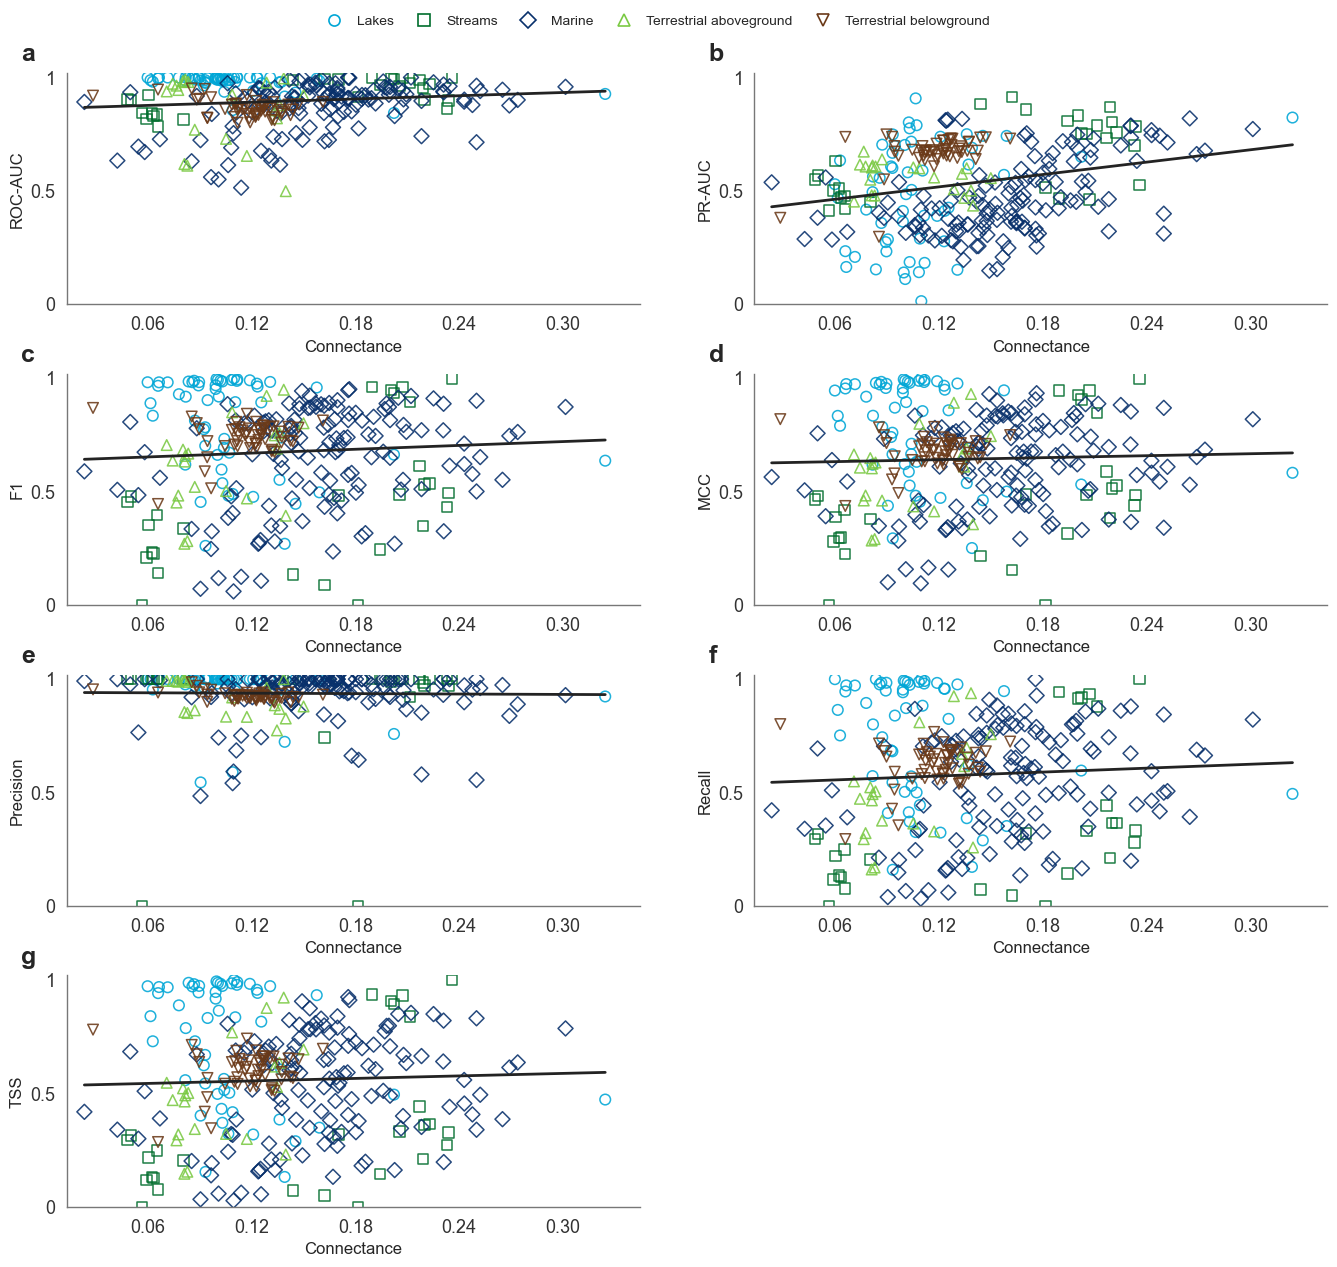

In [ ]:
import os
import json
import math
import tempfile

from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(
        Path(tempfile.gettempdir())
        / "qmul_phd_framework_mplconfig"
    ),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from matplotlib.lines import Line2D


sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.2,
)


# ============================================================
# Locate project root
# ============================================================

def find_project_root(start=None):
    start = (
        Path.cwd().resolve()
        if start is None
        else Path(start).resolve()
    )

    candidates = [
        start,
        *start.parents,
    ]

    fallback = Path(
        "/Users/acw792/Developer/qmul-phd-framework"
    )

    if fallback not in candidates:
        candidates.append(fallback)

    for path in candidates:
        if (
            (path / "src/matlab").is_dir()
            and (path / "docs").is_dir()
        ):
            return path

    raise FileNotFoundError(
        "Could not locate the qmul-phd-framework repository."
    )


PROJECT_ROOT = find_project_root()


# ============================================================
# Final role-only input configuration
# ============================================================

CLASSIFICATION_THRESHOLD = 0.50

K_TARGET = 10
TARGET_RATIO = 90.0
MIN_NODES = 0
AGGREGATE_REPEATS = True

# Tukey is applied independently across 100 runs for each
# food-web × metric group.
#
# Keep the agreed absolute minimum of 25 retained runs.
EXPECTED_RUNS = 100
MINIMUM_RETAINED_FRACTION = 0.25
MINIMUM_RETAINED_RUNS = 25

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min25runs_threshold0p50_v1"
)

EXPECTED_SCENARIO = (
    "result_wlnm_dir_neg_roleonly_trophicv2_"
    "100x290_train10-90_Apocrita_20260910_011848"
)

calculated_minimum = math.ceil(
    EXPECTED_RUNS
    * MINIMUM_RETAINED_FRACTION
)

assert calculated_minimum == MINIMUM_RETAINED_RUNS, (
    "The Tukey minimum is inconsistent."
)

RESULT_ROOT = (
    PROJECT_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_trophicv2_"
        "100x290_train10-90_Apocrita_20260910_011848"
    )
)

RETENTION_ROOT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
)

PREDICTIVE_INPUT = (
    RETENTION_ROOT
    / "figure_inputs"
    / (
        f"predictive_train{int(TARGET_RATIO)}"
        "_after_tukey.csv"
    )
)

RETENTION_MANIFEST = (
    RETENTION_ROOT
    / "retention_manifest.json"
)

ECOSYSTEM_FILE = (
    PROJECT_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)


# ============================================================
# Figure configuration
# ============================================================

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
N_COLS = 2


# ============================================================
# Helpers
# ============================================================

def normalize_colname(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(value):
    value = Path(
        str(value).strip()
    ).name

    for extension in (
        ".mat",
        ".csv",
    ):
        if value.lower().endswith(
            extension
        ):
            value = value[
                :-len(extension)
            ].rstrip()

    for suffix in (
        "_tax_mass",
        "_taxmass",
    ):
        if value.lower().endswith(
            suffix
        ):
            value = value[
                :-len(suffix)
            ].rstrip()

    return " ".join(
        value.casefold().split()
    )


def find_column(
    dataframe,
    candidates,
):
    norm_map = {
        normalize_colname(column): column
        for column in dataframe.columns
    }

    for candidate in candidates:
        normalized_candidate = normalize_colname(
            candidate
        )

        if normalized_candidate in norm_map:
            return norm_map[
                normalized_candidate
            ]

    raise KeyError(
        "Could not find any of these columns: "
        f"{candidates}"
    )


def normalize_train_ratio(series):
    values = pd.to_numeric(
        series,
        errors="coerce",
    )

    return np.where(
        values <= 1.0,
        values * 100.0,
        values,
    )


def format_ecosystem_label(name):
    name = str(
        name
    ).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": (
            "Terrestrial aboveground"
        ),
        "terrestrial belowground": (
            "Terrestrial belowground"
        ),
        "unknown": "Unknown",
    }

    return label_map.get(
        name,
        str(name).strip().capitalize(),
    )


def report_foodweb_count(
    stage_name,
    before,
    after,
):
    print(
        f"[CHECK] {stage_name}: "
        f"{len(before)} -> {len(after)} food webs"
    )


# ============================================================
# Validate selected inputs
# ============================================================

required_files = {
    "Tukey-filtered predictive input": (
        PREDICTIVE_INPUT
    ),
    "Food-web metadata": (
        ECOSYSTEM_FILE
    ),
    "Tukey retention manifest": (
        RETENTION_MANIFEST
    ),
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "The following required inputs are missing:\n\n"
        + "\n\n".join(
            missing_files
        )
    )

print(f"[INFO] Project root: {PROJECT_ROOT}")
print(f"[INFO] Result root: {RESULT_ROOT}")
print(f"[INFO] Predictive Tukey input: {PREDICTIVE_INPUT}")


# ============================================================
# Validate final role-only configuration
# ============================================================

with RETENTION_MANIFEST.open(
    "r",
    encoding="utf-8",
) as handle:
    retention_manifest = json.load(handle)

manifest = retention_manifest.get(
    "source_manifest",
    {},
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "Eligibility": "role_only",
    "MassEligibilityEnabled": "false",
    "NegativeSampling": "uniform_without_replacement",
    "NegativeTopupPolicy": "uniform_remaining_nonlinks",
    "NegativePositiveRatio": "2",
    "NumExperiments": str(
        EXPECTED_RUNS
    ),
    "SweepTrainRatios": "true",
    "TrainRatioRange": "10,20,30,40,50,60,70,80,90",
    "ClassificationThreshold": "0.50",
    "SubgraphK": "10",
    "TrophicLevelProtocol": "validated_v2",
    "TrophicHighPrecision": "auto",
    "ComputeEcologicalMetrics": "true",
    "MinimumRetainedAfterTukey": str(
        MINIMUM_RETAINED_RUNS
    ),
    "FoodWebs": "290",
}

configuration_errors = []

for key, expected_value in expected_manifest.items():
    observed_value = manifest.get(
        key
    )

    if observed_value is None:
        configuration_errors.append(
            f"{key}: missing"
        )

    elif (
        str(observed_value).casefold()
        != str(expected_value).casefold()
    ):
        configuration_errors.append(
            f"{key}: expected {expected_value}, "
            f"found {observed_value}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result directory does not match "
        "the final role-only configuration:\n\n"
        + "\n".join(
            configuration_errors
        )
    )

observed_scenario = retention_manifest.get(
    "scenario"
)

if observed_scenario != EXPECTED_SCENARIO:
    raise ValueError(
        "Unexpected scenario in retention_manifest.json:\n"
        f"  expected: {EXPECTED_SCENARIO}\n"
        f"  observed: {observed_scenario}"
    )

observed_threshold = retention_manifest.get(
    "classification_threshold"
)

if (
    observed_threshold is None
    or not np.isclose(
        float(observed_threshold),
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
    )
):
    raise ValueError(
        "The Tukey retention protocol does not use "
        f"classification threshold "
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )

observed_fraction = retention_manifest.get(
    "minimum_retained_fraction"
)

if (
    observed_fraction is None
    or not np.isclose(
        float(observed_fraction),
        MINIMUM_RETAINED_FRACTION,
        atol=1e-12,
    )
):
    raise ValueError(
        "Unexpected minimum retained fraction:\n"
        f"  expected: {MINIMUM_RETAINED_FRACTION}\n"
        f"  observed: {observed_fraction}"
    )

expected_standard_example = (
    f"{MINIMUM_RETAINED_RUNS} of {EXPECTED_RUNS}"
)

observed_standard_example = retention_manifest.get(
    "standard_minimum_example"
)

if (
    observed_standard_example is not None
    and observed_standard_example
    != expected_standard_example
):
    raise ValueError(
        "Unexpected standard Tukey minimum:\n"
        f"  expected: {expected_standard_example}\n"
        f"  observed: {observed_standard_example}"
    )

print(
    "[INFO] Validated final role-only configuration:"
)

print(f"  scenario={observed_scenario}")
print(f"  eligibility={manifest['Eligibility']}")

print(
    "  mass_eligibility_enabled="
    f"{manifest['MassEligibilityEnabled']}"
)

print(
    "  negative_sampling="
    f"{manifest['NegativeSampling']}"
)

print(
    "  negative_positive_ratio="
    f"{manifest['NegativePositiveRatio']}"
)

print(
    "  negative_topup_policy="
    f"{manifest['NegativeTopupPolicy']}"
)

print(
    "  classification_threshold="
    f"{manifest['ClassificationThreshold']}"
)

print(
    "  number_of_experiments="
    f"{manifest['NumExperiments']}"
)

print(
    "  train_ratio_range="
    f"{manifest['TrainRatioRange']}"
)

print(
    f"  retention_protocol="
    f"{PROTOCOL_NAME}"
)

print(
    "  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    "  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)


# ============================================================
# Load Tukey-filtered results
# ============================================================

def load_results(path):
    results = pd.read_csv(
        path
    ).copy()

    required_columns = {
        "Scenario",
        "Foodweb",
        "Version",
        "K",
        "TrainRatio",
        "Threshold",
        "Metric",
        "MetricFamily",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "ExpectedRuns",
        "MinimumRetainedRuns",
        "OutlierRunsExcluded",
        "MeetsMinimumRetainedRuns",
    }

    missing_columns = sorted(
        required_columns.difference(
            results.columns
        )
    )

    if missing_columns:
        raise ValueError(
            "The Tukey-filtered input is missing columns:\n  "
            + "\n  ".join(
                missing_columns
            )
        )

    numeric_columns = [
        "K",
        "TrainRatio",
        "Threshold",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "ExpectedRuns",
        "MinimumRetainedRuns",
        "OutlierRunsExcluded",
        "MeetsMinimumRetainedRuns",
    ]

    for column in numeric_columns:
        results[column] = pd.to_numeric(
            results[column],
            errors="coerce",
        )

    results[
        "TrainRatio"
    ] = normalize_train_ratio(
        results[
            "TrainRatio"
        ]
    )

    metric_columns = [
        metric
        for metric, _
        in METRIC_SPECS
    ]

    # --------------------------------------------------------
    # Select requested role-only configuration
    # --------------------------------------------------------

    target = results.loc[
        results["Scenario"].eq(
            EXPECTED_SCENARIO
        )
        & results["Version"].eq(
            "WLNM_dir_neg"
        )
        & (
            results["MetricFamily"]
            .astype(str)
            .str.casefold()
            .eq("predictive")
        )
        & results["Metric"].isin(
            metric_columns
        )
        & np.isclose(
            results["K"],
            K_TARGET,
            atol=1e-9,
            equal_nan=False,
        )
        & np.isclose(
            results["TrainRatio"],
            TARGET_RATIO,
            atol=1e-9,
            equal_nan=False,
        )
        & np.isclose(
            results["Threshold"],
            CLASSIFICATION_THRESHOLD,
            atol=1e-9,
            equal_nan=False,
        )
    ].copy()

    if target.empty:
        raise RuntimeError(
            "No final role-only predictive results were "
            "found for "
            f"K={K_TARGET}, "
            f"TrainRatio={TARGET_RATIO}, "
            f"Threshold={CLASSIFICATION_THRESHOLD:.2f}."
        )

    # --------------------------------------------------------
    # Validate minimum 25 of 100 retained runs
    # --------------------------------------------------------

    observed_expected_runs = set(
        target_rows["ExpectedRuns"]
        .dropna()
        .astype(int)
        .unique()
    )

    if observed_expected_runs != {
        expected_runs
    }:
        raise ValueError(
            f"{path.name} has an unexpected number of runs:\n"
            f"  expected: {expected_runs}\n"
            f"  observed: {sorted(observed_expected_runs)}"
        )

    observed_minimums = set(
        target["MinimumRetainedRuns"]
        .dropna()
        .astype(int)
        .unique()
    )

    if observed_minimums != {
        MINIMUM_RETAINED_RUNS
    }:
        raise ValueError(
            "Unexpected Tukey minimum in the input:\n"
            f"  expected: {MINIMUM_RETAINED_RUNS}\n"
            f"  observed: {sorted(observed_minimums)}"
        )

    incorrectly_retained = target[
        target[
            "MeetsMinimumRetainedRuns"
        ].eq(1)
        & target[
            "RetainedRunsAfterTukey"
        ].lt(
            MINIMUM_RETAINED_RUNS
        )
    ]

    if not incorrectly_retained.empty:
        print(
            incorrectly_retained[
                [
                    "Foodweb",
                    "Metric",
                    "ExpectedRuns",
                    "RetainedRunsAfterTukey",
                    "MinimumRetainedRuns",
                    "MeetsMinimumRetainedRuns",
                ]
            ]
        )

        raise ValueError(
            "At least one food-web metric is marked as "
            "retained despite having fewer than "
            f"{MINIMUM_RETAINED_RUNS} runs."
        )

    results = target.loc[
        target["ExpectedRuns"].eq(
            EXPECTED_RUNS
        )
        & target[
            "MinimumRetainedRuns"
        ].eq(
            MINIMUM_RETAINED_RUNS
        )
        & target[
            "RetainedRunsAfterTukey"
        ].ge(
            MINIMUM_RETAINED_RUNS
        )
        & target[
            "MeetsMinimumRetainedRuns"
        ].eq(1)
        & target[
            "MeanAfterTukey"
        ].notna()
    ].copy()

    if results.empty:
        raise RuntimeError(
            "No results remain after validating the "
            f"minimum of {MINIMUM_RETAINED_RUNS} runs."
        )

    print(
        "[INFO] Tukey minimum validated: "
        f"at least {MINIMUM_RETAINED_RUNS} of "
        f"{EXPECTED_RUNS} runs per food web and metric."
    )

    print(
        "[INFO] Actual retained-run range: "
        f"{int(results['RetainedRunsAfterTukey'].min())}–"
        f"{int(results['RetainedRunsAfterTukey'].max())}"
    )

    # --------------------------------------------------------
    # Validate unique food-web × metric rows
    # --------------------------------------------------------

    results[
        "FoodwebKey"
    ] = (
        results[
            "Foodweb"
        ]
        .apply(
            normalize_foodweb_name
        )
    )

    duplicated = results.duplicated(
        subset=[
            "FoodwebKey",
            "Metric",
        ],
        keep=False,
    )

    if duplicated.any():
        duplicated_rows = (
            results.loc[
                duplicated,
                [
                    "Foodweb",
                    "Metric",
                    "K",
                    "TrainRatio",
                    "Threshold",
                ],
            ]
            .sort_values(
                [
                    "Metric",
                    "Foodweb",
                ]
            )
        )

        print(
            duplicated_rows
        )

        raise ValueError(
            "More than one retained result was found per "
            "food web and metric."
        )

    # --------------------------------------------------------
    # Retention summary before pivoting
    # --------------------------------------------------------

    retention_summary = (
        results
        .groupby(
            "Metric",
            as_index=False,
        )
        .agg(
            FoodWebs=(
                "FoodwebKey",
                "nunique",
            ),
            ExpectedRuns=(
                "ExpectedRuns",
                "min",
            ),
            RequiredMinimumRuns=(
                "MinimumRetainedRuns",
                "min",
            ),
            MinimumRetainedRuns=(
                "RetainedRunsAfterTukey",
                "min",
            ),
            MedianRetainedRuns=(
                "RetainedRunsAfterTukey",
                "median",
            ),
            MaximumRetainedRuns=(
                "RetainedRunsAfterTukey",
                "max",
            ),
            TotalOutliersExcluded=(
                "OutlierRunsExcluded",
                "sum",
            ),
        )
    )

    print(
        "\n=== Tukey retention by predictive metric ==="
    )

    print(
        retention_summary.to_string(
            index=False
        )
    )

    # --------------------------------------------------------
    # Convert metric rows to wide food-web format
    # --------------------------------------------------------

    wide_results = (
        results
        .pivot(
            index=[
                "Foodweb",
                "FoodwebKey",
                "K",
                "TrainRatio",
            ],
            columns="Metric",
            values="MeanAfterTukey",
        )
        .reset_index()
        .copy()
    )

    wide_results.columns.name = None

    missing_metrics = [
        metric
        for metric, _
        in METRIC_SPECS
        if metric not in wide_results.columns
    ]

    if missing_metrics:
        raise RuntimeError(
            "Missing required metric columns after "
            f"pivoting: {missing_metrics}"
        )

    print(
        "[INFO] Tukey-filtered input: "
        f"{path}"
    )

    print(
        "[INFO] Food webs in filtered result: "
        f"{wide_results['Foodweb'].nunique()}"
    )

    print(
        "[INFO] Configuration: "
        "eligibility=role_only, "
        "mass_constraint=False, "
        "negative_sampling=uniform_without_replacement, "
        "negative_topup_policy=uniform_remaining_nonlinks, "
        "negative_positive_ratio=2:1, "
        "classification_threshold=0.50."
    )

    return wide_results


# ============================================================
# Load food-web metadata
# ============================================================

def load_foodweb_metadata(path):
    metadata = pd.read_csv(
        path
    ).copy()

    foodweb_col = find_column(
        metadata,
        [
            "foodweb",
        ],
    )

    ecosystem_col = find_column(
        metadata,
        [
            "ecosystemtype",
            "ecosystem",
            "ecosystem_type",
        ],
    )

    nodes_col = find_column(
        metadata,
        [
            "nodes",
            "n_nodes",
            "num_nodes",
            "nodecount",
            "s",
        ],
    )

    edges_col = find_column(
        metadata,
        [
            "edges",
            "n_edges",
            "num_edges",
            "edgecount",
            "l",
        ],
    )

    connectance_col = find_column(
        metadata,
        [
            "connectance",
            "c",
        ],
    )

    metadata = metadata.rename(
        columns={
            foodweb_col: (
                "MetadataFoodweb"
            ),
            ecosystem_col: (
                "EcosystemType"
            ),
            nodes_col: (
                "Nodes"
            ),
            edges_col: (
                "Edges"
            ),
            connectance_col: (
                "MetadataConnectance"
            ),
        }
    )

    metadata = metadata[
        [
            "MetadataFoodweb",
            "EcosystemType",
            "Nodes",
            "Edges",
            "MetadataConnectance",
        ]
    ].copy()

    metadata[
        "MetadataFoodweb"
    ] = (
        metadata[
            "MetadataFoodweb"
        ]
        .astype(str)
    )

    metadata[
        "FoodwebKey"
    ] = (
        metadata[
            "MetadataFoodweb"
        ]
        .apply(
            normalize_foodweb_name
        )
    )

    metadata[
        "EcosystemType"
    ] = (
        metadata[
            "EcosystemType"
        ]
        .astype(str)
        .str.strip()
    )

    metadata[
        "Nodes"
    ] = pd.to_numeric(
        metadata[
            "Nodes"
        ],
        errors="coerce",
    )

    metadata[
        "Edges"
    ] = pd.to_numeric(
        metadata[
            "Edges"
        ],
        errors="coerce",
    )

    metadata[
        "MetadataConnectance"
    ] = pd.to_numeric(
        metadata[
            "MetadataConnectance"
        ],
        errors="coerce",
    )

    duplicated_metadata = (
        metadata.duplicated(
            subset=[
                "FoodwebKey"
            ],
            keep=False,
        )
    )

    if duplicated_metadata.any():
        conflicting_metadata = (
            metadata.loc[
                duplicated_metadata,
                [
                    "FoodwebKey",
                    "EcosystemType",
                    "Nodes",
                    "Edges",
                    "MetadataConnectance",
                ],
            ]
            .groupby(
                "FoodwebKey"
            )
            .nunique(
                dropna=False
            )
        )

        conflicting_metadata = (
            conflicting_metadata[
                conflicting_metadata.max(
                    axis=1
                ) > 1
            ]
        )

        if not conflicting_metadata.empty:
            print(
                conflicting_metadata
            )

            raise ValueError(
                "Conflicting metadata were found for "
                "one or more food webs."
            )

    metadata = (
        metadata
        .drop_duplicates(
            subset=[
                "FoodwebKey",
            ],
            keep="first",
        )
        .copy()
    )

    print(
        "[INFO] Food webs in metadata file: "
        f"{metadata['FoodwebKey'].nunique()}"
    )

    return metadata


# ============================================================
# Data preparation
# ============================================================

def prepare_plot_data(
    results,
    metadata,
):
    dataframe = (
        results.merge(
            metadata,
            on="FoodwebKey",
            how="left",
            validate="one_to_one",
        )
        .copy()
    )

    missing_metadata = (
        dataframe[
            "EcosystemType"
        ].isna()
        | dataframe[
            "Nodes"
        ].isna()
    )

    if missing_metadata.any():
        missing_foodwebs = sorted(
            dataframe.loc[
                missing_metadata,
                "Foodweb",
            ]
            .astype(str)
            .unique()
        )

        raise ValueError(
            "Metadata could not be matched for "
            f"{len(missing_foodwebs)} food webs:\n  "
            + "\n  ".join(
                missing_foodwebs[:30]
            )
        )

    numeric_columns = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "TestMCC",
        "TestTSS",
        "Nodes",
        "Edges",
        "MetadataConnectance",
    ]

    existing_numeric_columns = [
        column
        for column in numeric_columns
        if column in dataframe.columns
    ]

    dataframe[
        existing_numeric_columns
    ] = dataframe[
        existing_numeric_columns
    ].apply(
        pd.to_numeric,
        errors="coerce",
    )

    dataframe[
        "EmpiricalConnectanceForPlot"
    ] = dataframe[
        "MetadataConnectance"
    ]

    missing_connectance = (
        dataframe[
            "EmpiricalConnectanceForPlot"
        ].isna()
    )

    can_compute_connectance = (
        missing_connectance
        & dataframe[
            "Nodes"
        ].notna()
        & dataframe[
            "Edges"
        ].notna()
        & (
            dataframe[
                "Nodes"
            ] > 1
        )
    )

    dataframe.loc[
        can_compute_connectance,
        "EmpiricalConnectanceForPlot",
    ] = (
        dataframe.loc[
            can_compute_connectance,
            "Edges",
        ]
        / (
            dataframe.loc[
                can_compute_connectance,
                "Nodes",
            ]
            * (
                dataframe.loc[
                    can_compute_connectance,
                    "Nodes",
                ]
                - 1
            )
        )
    )

    dataframe[
        "EcosystemType"
    ] = (
        dataframe[
            "EcosystemType"
        ]
        .fillna(
            "Unknown"
        )
    )

    before = set(
        dataframe[
            "Foodweb"
        ]
        .dropna()
        .unique()
    )

    if K_TARGET is not None:
        dataframe = dataframe.loc[
            np.isclose(
                dataframe[
                    "K"
                ],
                K_TARGET,
                atol=1e-9,
                equal_nan=False,
            )
        ].copy()

        after = set(
            dataframe[
                "Foodweb"
            ]
            .dropna()
            .unique()
        )

        report_foodweb_count(
            f"K = {K_TARGET}",
            before,
            after,
        )

        before = after

    dataframe = dataframe.loc[
        np.isclose(
            dataframe[
                "TrainRatio"
            ],
            TARGET_RATIO,
            atol=1e-9,
            equal_nan=False,
        )
    ].copy()

    after = set(
        dataframe[
            "Foodweb"
        ]
        .dropna()
        .unique()
    )

    report_foodweb_count(
        f"TrainRatio = {TARGET_RATIO}",
        before,
        after,
    )

    before = after

    dataframe = dataframe.loc[
        dataframe[
            "Nodes"
        ].ge(
            MIN_NODES
        )
    ].copy()

    after = set(
        dataframe[
            "Foodweb"
        ]
        .dropna()
        .unique()
    )

    report_foodweb_count(
        f"Nodes >= {MIN_NODES}",
        before,
        after,
    )

    missing_metrics = [
        metric
        for metric, _
        in METRIC_SPECS
        if metric not in dataframe.columns
    ]

    if missing_metrics:
        raise RuntimeError(
            "Missing required metric columns: "
            f"{missing_metrics}"
        )

    if AGGREGATE_REPEATS:
        group_columns = [
            "Foodweb",
            "FoodwebKey",
            "K",
            "TrainRatio",
            "EmpiricalConnectanceForPlot",
            "Nodes",
            "Edges",
            "EcosystemType",
        ]

        mean_columns = [
            metric
            for metric, _
            in METRIC_SPECS
        ]

        dataframe = (
            dataframe
            .groupby(
                group_columns,
                dropna=False,
                as_index=False,
            )[
                mean_columns
            ]
            .mean()
            .copy()
        )

    before_connectance = set(
        dataframe[
            "Foodweb"
        ]
        .dropna()
        .unique()
    )

    dataframe = (
        dataframe
        .dropna(
            subset=[
                "EmpiricalConnectanceForPlot",
            ]
        )
        .copy()
    )

    after_connectance = set(
        dataframe[
            "Foodweb"
        ]
        .dropna()
        .unique()
    )

    report_foodweb_count(
        "available connectance for x-axis",
        before_connectance,
        after_connectance,
    )

    metric_columns = [
        metric
        for metric, _
        in METRIC_SPECS
    ]

    metric_availability = (
        dataframe[
            [
                "Foodweb",
                *metric_columns,
            ]
        ]
        .assign(
            HasAnySelectedMetric=lambda frame: (
                frame[
                    metric_columns
                ]
                .notna()
                .any(
                    axis=1
                )
            )
        )
        .copy()
    )

    foodwebs_without_metrics = (
        metric_availability.loc[
            ~metric_availability[
                "HasAnySelectedMetric"
            ],
            "Foodweb",
        ]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    print(
        "[FINAL] Food webs retained after "
        "structural filters: "
        f"{dataframe['Foodweb'].nunique()}"
    )

    if foodwebs_without_metrics:
        print(
            "[INFO] Food webs retained but not plotted "
            "because all selected metrics are missing:"
        )

        for foodweb in foodwebs_without_metrics:
            print(
                f"  - {foodweb}"
            )

    return dataframe.copy()


# ============================================================
# Regression helpers
# ============================================================

def fit_linear_regression(
    data,
    metric,
    n_points=100,
):
    work = (
        data[
            [
                "EmpiricalConnectanceForPlot",
                metric,
            ]
        ]
        .dropna()
        .copy()
    )

    if work.empty:
        return None

    work[
        "EmpiricalConnectanceForPlot"
    ] = (
        work[
            "EmpiricalConnectanceForPlot"
        ]
        .astype(float)
    )

    work[
        metric
    ] = (
        work[
            metric
        ]
        .astype(float)
    )

    if (
        len(work) < 3
        or work[
            "EmpiricalConnectanceForPlot"
        ].nunique() < 2
    ):
        return None

    x = work[
        [
            "EmpiricalConnectanceForPlot",
        ]
    ]

    y = work[
        metric
    ]

    x_model = sm.add_constant(
        x,
        has_constant="add",
    )

    model = sm.OLS(
        y,
        x_model,
    ).fit()

    intercept = model.params[
        "const"
    ]

    slope = model.params[
        "EmpiricalConnectanceForPlot"
    ]

    x_line = np.linspace(
        work[
            "EmpiricalConnectanceForPlot"
        ].min(),
        work[
            "EmpiricalConnectanceForPlot"
        ].max(),
        n_points,
    )

    x_line_model = pd.DataFrame(
        {
            "EmpiricalConnectanceForPlot": (
                x_line
            )
        }
    )

    x_line_model = sm.add_constant(
        x_line_model,
        has_constant="add",
    )

    y_line = model.predict(
        x_line_model
    )

    return {
        "x_line": x_line,
        "y_line": y_line,
        "slope": slope,
        "intercept": intercept,
        "r_squared": model.rsquared,
        "p_value": model.pvalues[
            "EmpiricalConnectanceForPlot"
        ],
        "f_value": model.fvalue,
        "df_model": int(
            model.df_model
        ),
        "df_resid": int(
            model.df_resid
        ),
        "n": len(work),
        "model": model,
    }


def format_equation(
    slope,
    intercept,
):
    sign = (
        "+"
        if intercept >= 0
        else "-"
    )

    return (
        f"y = {slope:.4f}x "
        f"{sign} {abs(intercept):.4f}"
    )


def format_p_value(p_value):
    if pd.isna(
        p_value
    ):
        return "P = NA"

    if p_value < 0.0001:
        return "P < 0.0001"

    return (
        f"P = {p_value:.4f}"
    )


# ============================================================
# Plotting
# ============================================================

def style_axes(
    ax,
    ylabel,
):
    ax.set_ylabel(
        ylabel,
        fontsize=12,
    )

    ax.set_xlabel(
        "Connectance",
        fontsize=12,
    )

    ax.grid(
        False
    )

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )

    ax.spines[
        "left"
    ].set_color(
        "#777777"
    )

    ax.spines[
        "bottom"
    ].set_color(
        "#777777"
    )

    ax.tick_params(
        axis="both",
        colors="#333333",
        labelsize=13,
    )


def plot_performance_vs_connectance(
    plot_dataframe,
):
    available_ecosystems = (
        plot_dataframe[
            "EcosystemType"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    available_by_label = {
        format_ecosystem_label(
            ecosystem
        ): ecosystem
        for ecosystem in available_ecosystems
    }

    eco_order = [
        available_by_label[label]
        for label in ECOSYSTEM_ORDER
        if label in available_by_label
    ]

    eco_order += [
        ecosystem
        for ecosystem in available_ecosystems
        if ecosystem not in eco_order
    ]

    plot_dataframe = (
        plot_dataframe.copy()
    )

    plot_dataframe[
        "EcosystemType"
    ] = pd.Categorical(
        plot_dataframe[
            "EcosystemType"
        ],
        categories=eco_order,
        ordered=True,
    )

    eco_palette = {
        ecosystem: ecosystem_palette.get(
            format_ecosystem_label(
                ecosystem
            ),
            "#999999",
        )
        for ecosystem in eco_order
    }

    eco_markers = {
        ecosystem: ecosystem_markers.get(
            format_ecosystem_label(
                ecosystem
            ),
            "o",
        )
        for ecosystem in eco_order
    }

    n_panels = len(
        METRIC_SPECS
    )

    n_rows = math.ceil(
        n_panels / N_COLS
    )

    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        figsize=(
            14,
            14,
        ),
        sharex=False,
        sharey=False,
    )

    axes = np.array(
        axes
    ).reshape(-1)

    panel_letters = list(
        "abcdefghijklmnopqrstuvwxyz"
    )

    x_min = plot_dataframe[
        "EmpiricalConnectanceForPlot"
    ].min()

    x_max = plot_dataframe[
        "EmpiricalConnectanceForPlot"
    ].max()

    print(
        "\n=== OLS linear regression: "
        "metric ~ empirical connectance ==="
    )

    for index, (
        (
            metric,
            label,
        ),
        ax,
    ) in enumerate(
        zip(
            METRIC_SPECS,
            axes,
        )
    ):
        data = (
            plot_dataframe
            .dropna(
                subset=[
                    "EmpiricalConnectanceForPlot",
                    metric,
                ]
            )
            .copy()
        )

        for ecosystem in eco_order:
            ecosystem_data = data.loc[
                data[
                    "EcosystemType"
                ]
                == ecosystem
            ]

            if ecosystem_data.empty:
                continue

            ax.scatter(
                ecosystem_data[
                    "EmpiricalConnectanceForPlot"
                ],
                ecosystem_data[
                    metric
                ],
                marker=eco_markers[
                    ecosystem
                ],
                facecolors="none",
                edgecolors=eco_palette[
                    ecosystem
                ],
                linewidths=1.1,
                s=58,
                alpha=0.88,
                label=format_ecosystem_label(
                    ecosystem
                ),
            )

        fit = fit_linear_regression(
            data,
            metric,
        )

        if fit is not None:
            ax.plot(
                fit[
                    "x_line"
                ],
                fit[
                    "y_line"
                ],
                color="#232323",
                linewidth=2.0,
                linestyle="-",
                zorder=5,
            )

            equation = format_equation(
                fit[
                    "slope"
                ],
                fit[
                    "intercept"
                ],
            )

            p_text = format_p_value(
                fit[
                    "p_value"
                ]
            )

            print(
                f"{panel_letters[index]}) "
                f"{label}: "
                f"{equation}; "
                f"F{fit['df_model']},"
                f"{fit['df_resid']} = "
                f"{fit['f_value']:.4f}; "
                f"R² = "
                f"{fit['r_squared']:.4f}; "
                f"{p_text}; "
                f"n = {fit['n']}"
            )

        else:
            print(
                f"{panel_letters[index]}) "
                f"{label}: "
                "regression not fitted; "
                "insufficient data."
            )

        style_axes(
            ax,
            label,
        )

        ax.set_ylim(
            Y_MIN,
            Y_MAX + Y_PAD_TOP,
        )

        ax.set_xlim(
            max(
                0.0,
                x_min - 0.01,
            ),
            x_max + 0.02,
        )

        ax.set_yticks(
            [
                0,
                0.5,
                1.0,
            ]
        )

        ax.set_yticklabels(
            [
                "0",
                "0.5",
                "1",
            ]
        )

        ax.xaxis.set_major_locator(
            plt.MaxNLocator(6)
        )

        ax.text(
            -0.08,
            1.03,
            panel_letters[
                index
            ],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

    for panel_index in range(
        n_panels,
        len(axes),
    ):
        axes[
            panel_index
        ].set_axis_off()

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=eco_markers[
                ecosystem
            ],
            linestyle="",
            markersize=8,
            markerfacecolor="none",
            markeredgecolor=eco_palette[
                ecosystem
            ],
            markeredgewidth=1.2,
            label=format_ecosystem_label(
                ecosystem
            ),
        )
        for ecosystem in eco_order
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            0.95,
        ),
        ncol=min(
            len(eco_order),
            5,
        ),
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,
        fontsize=10,
    )

    fig.subplots_adjust(
        top=0.90,
        hspace=0.3,
        wspace=0.2,
        left=0.08,
        right=0.98,
        bottom=0.09,
    )

    return fig


# ============================================================
# Run
# ============================================================

results = load_results(
    PREDICTIVE_INPUT
)

metadata = load_foodweb_metadata(
    ECOSYSTEM_FILE
)

plot_df = prepare_plot_data(
    results,
    metadata,
)

fig = plot_performance_vs_connectance(
    plot_df
)

print(
    "\n[INFO] Final Tukey configuration:"
)

print(
    f"  expected_runs="
    f"{EXPECTED_RUNS}"
)

print(
    f"  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    f"  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)

print(
    f"  food_webs_used="
    f"{plot_df['Foodweb'].nunique()}"
)

plt.show()

[INFO] Repository: /Users/acw792/Developer/qmul-phd-framework
[INFO] Using Tukey-filtered inputs:
  Original: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_original_50x290_train90_thresh0p50_legacy_uppertriangular_checkconnfalse_adaptivefalse_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
  Directed-negative: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
[INFO] original: Tukey requirement validated (at least 25/50 runs).
       Actual retained-run range: 26–50
       Retained food webs: 290
[INFO] dir_neg: Tukey requirement validated (at least 25/100 runs).
       Actual retained-run range: 52–100
       Retained food webs: 290
[INFO] Food webs satisfying Nodes >= 0: 290

=== Retained and pa

,Metric,Original retained food webs,Directed-negative retained food webs,Paired food webs,Original-only food webs,Directed-negative-only food webs
0,ROC-AUC,290,290,290,0,0
1,PR-AUC,290,290,290,0,0
2,F1,290,290,290,0,0
3,MCC,290,290,290,0,0
4,Precision,290,290,290,0,0
5,Recall,290,290,290,0,0
6,TSS,290,290,290,0,0



=== Tukey retention details for paired food webs ===


,Version,Metric,FoodWebs,MinimumRetainedRuns,MedianRetainedRuns,MaximumRetainedRuns
0,Modified WLNM,F1,290,76,99.0,100
1,Modified WLNM,PR-AUC,290,80,100.0,100
2,Modified WLNM,Precision,290,75,98.0,100
3,Modified WLNM,ROC-AUC,290,75,98.0,100
4,Modified WLNM,Recall,290,52,99.0,100
5,Modified WLNM,MCC,290,76,99.0,100
6,Modified WLNM,TSS,290,76,99.0,100
7,Original WLNM,F1,290,38,49.0,50
8,Original WLNM,PR-AUC,290,38,50.0,50
9,Original WLNM,Precision,290,38,50.0,50



=== Tukey-filtered web-level predictive metric summary ===


,Version,Metric,FoodWebs,Mean,Median,SD,Variance
0,Modified WLNM,F1,290,0.6755,0.7301,0.2271,0.0516
1,Modified WLNM,PR-AUC,290,0.5341,0.5475,0.1834,0.0336
2,Modified WLNM,Precision,290,0.9376,0.9723,0.1173,0.0138
3,Modified WLNM,ROC-AUC,290,0.8953,0.9130,0.0988,0.0098
4,Modified WLNM,Recall,290,0.5784,0.6085,0.2534,0.0642
5,Modified WLNM,MCC,290,0.6441,0.6647,0.2089,0.0436
6,Modified WLNM,TSS,290,0.5586,0.5754,0.2496,0.0623
7,Original WLNM,F1,290,0.6236,0.6710,0.1941,0.0377
8,Original WLNM,PR-AUC,290,0.5550,0.6030,0.1945,0.0378
9,Original WLNM,Precision,290,0.6706,0.7207,0.2022,0.0409



[INFO] Saved publication-ready outputs:
  PNG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/figure_3_original50_vs_dir_neg100_train90_thresh0p50_tukey_min25runs.png
  SVG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/figure_3_original50_vs_dir_neg100_train90_thresh0p50_tukey_min25runs.svg
  PDF: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/figure_3_original50_vs_dir_neg100_train90_thresh0p50_tukey_min25runs.pdf
  Summary: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg

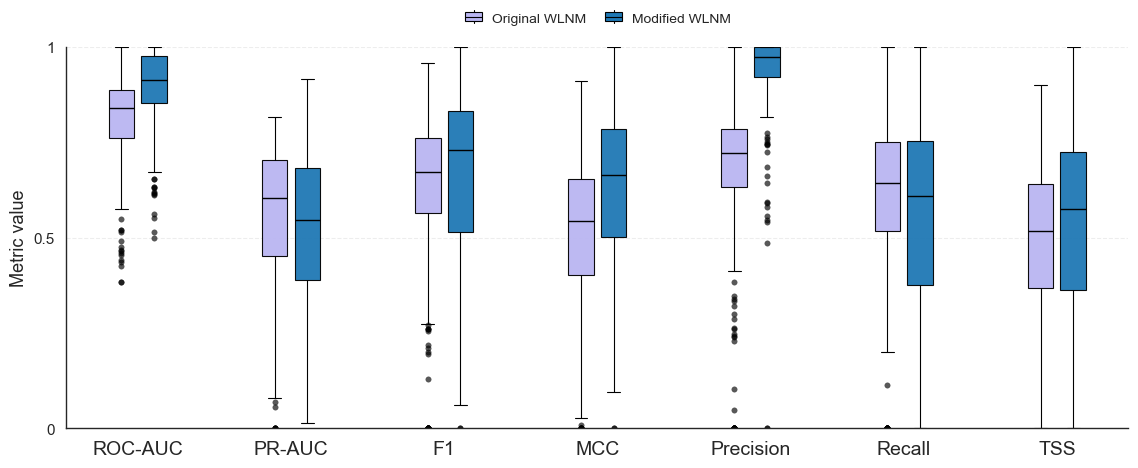

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.1,
)


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    candidates = [start, *start.parents]

    # Fallback for notebooks launched outside the repository.
    fallback = Path(
        "/Users/acw792/Developer/qmul-phd-framework"
    )

    if fallback not in candidates:
        candidates.append(fallback)

    for candidate in candidates:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the qmul-phd-framework repository."
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final configuration
# ============================================================

TRAIN_RATIO_TARGET = 90
CLASSIFICATION_THRESHOLD = 0.50
NODES_THRESHOLD = 0

MINIMUM_RETAINED_RUNS = 25

# Existing Original results
ORIGINAL_EXPECTED_RUNS = 50
ORIGINAL_MINIMUM_RETAINED_FRACTION = 0.50
ORIGINAL_PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)

# New Directed-negative results
DIR_NEG_EXPECTED_RUNS = 100
DIR_NEG_MINIMUM_RETAINED_FRACTION = 0.25
DIR_NEG_PROTOCOL_NAME = (
    "tukey_iqr_1p5_min25runs_threshold0p50_v1"
)

assert MINIMUM_RETAINED_RUNS == int(
    np.ceil(
        ORIGINAL_EXPECTED_RUNS
        * ORIGINAL_MINIMUM_RETAINED_FRACTION
    )
)

assert MINIMUM_RETAINED_RUNS == int(
    np.ceil(
        DIR_NEG_EXPECTED_RUNS
        * DIR_NEG_MINIMUM_RETAINED_FRACTION
    )
)


# ============================================================
# Result roots
# ============================================================

ORIGINAL_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_original_50x290_train90_thresh0p50_"
        "legacy_uppertriangular_checkconnfalse_"
        "adaptivefalse_Apocrita"
    )
)

DIR_NEG_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_trophicv2_"
        "100x290_train10-90_Apocrita_20260910_011848"
    )
)


# ============================================================
# Tukey-filtered figure inputs
# ============================================================

ORIGINAL_INPUT = (
    ORIGINAL_ROOT
    / "retention_protocol"
    / ORIGINAL_PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train90_after_tukey.csv"
)

DIR_NEG_INPUT = (
    DIR_NEG_ROOT
    / "retention_protocol"
    / DIR_NEG_PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train90_after_tukey.csv"
)

FOODWEB_CSV = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)


# ============================================================
# Publication output
# ============================================================

OUT_DIR = (
    DIR_NEG_ROOT
    / "retention_protocol"
    / DIR_NEG_PROTOCOL_NAME
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_STEM = (
    "figure_3_original50_vs_dir_neg100_"
    "train90_thresh0p50_tukey_min25runs"
)

PNG_PATH = OUT_DIR / f"{OUTPUT_STEM}.png"
SVG_PATH = OUT_DIR / f"{OUTPUT_STEM}.svg"
PDF_PATH = OUT_DIR / f"{OUTPUT_STEM}.pdf"

SUMMARY_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_summary.csv"
)

RETENTION_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_retention_counts.csv"
)


# ============================================================
# Metrics
# ============================================================

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

METRIC_ORDER = [
    metric
    for metric, _ in METRIC_SPECS
]

METRIC_LABELS = dict(METRIC_SPECS)

VERSION_ORDER = [
    "original",
    "dir_neg",
]

VERSION_LABELS = {
    "original": "Original WLNM",
    "dir_neg": "Modified WLNM",
}

VERSION_PALETTE = {
    "original": "#BAB6F2",
    "dir_neg": "#1F78B4",
}

SHOW_WEB_LEVEL_FLIERS = True


# ============================================================
# Validate required inputs
# ============================================================

required_inputs = {
    "Corrected WLNM_original Tukey input": ORIGINAL_INPUT,
    "Final WLNM_dir_neg Tukey input": DIR_NEG_INPUT,
    "Food-web metadata": FOODWEB_CSV,
}

missing_inputs = [
    f"{label}:\n  {path}"
    for label, path in required_inputs.items()
    if not path.is_file()
]

if missing_inputs:
    raise FileNotFoundError(
        "The following required inputs are missing:\n\n"
        + "\n\n".join(missing_inputs)
        + (
            "\n\nThe results must first be processed with "
            "apply_wlnm_tukey_retention.py."
        )
    )

print(f"[INFO] Repository: {REPO_ROOT}")
print("[INFO] Using Tukey-filtered inputs:")
print(f"  Original: {ORIGINAL_INPUT}")
print(f"  Directed-negative: {DIR_NEG_INPUT}")


# ============================================================
# Helpers
# ============================================================

def normalize_fw_label(name):
    name = str(name).strip()

    for suffix in [
        ".mat",
        ".csv",
    ]:
        if name.endswith(suffix):
            name = name[: -len(suffix)]

    name = name.replace(" ", "_")

    for token in [
        "_results_",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(token, "_")

    return "_".join(
        part
        for part in name.split("_")
        if part
    ).lower()


def load_tukey_figure_input(
    path,
    version,
    expected_runs,
    minimum_retained_runs,
):
    df = pd.read_csv(path)

    required_columns = {
        "Foodweb",
        "Metric",
        "MetricFamily",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "ExpectedRuns",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
        "TrainRatio",
        "Threshold",
    }

    missing_columns = required_columns.difference(
        df.columns
    )

    if missing_columns:
        raise ValueError(
            f"{path.name} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    numeric_columns = [
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "ExpectedRuns",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
        "TrainRatio",
        "Threshold",
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

    # --------------------------------------------------------
    # Validate the Tukey preprocessing configuration
    # --------------------------------------------------------

    target_rows = df[
        df["Metric"].isin(METRIC_ORDER)
        & df["MetricFamily"].eq("predictive")
        & np.isclose(
            df["TrainRatio"],
            TRAIN_RATIO_TARGET,
            atol=1e-8,
            equal_nan=False,
        )
        & np.isclose(
            df["Threshold"],
            CLASSIFICATION_THRESHOLD,
            atol=1e-9,
            equal_nan=False,
        )
    ].copy()

    if target_rows.empty:
        raise ValueError(
            f"No predictive rows for train ratio "
            f"{TRAIN_RATIO_TARGET} and threshold "
            f"{CLASSIFICATION_THRESHOLD} were found in:\n{path}"
        )

    observed_minimums = set(
        target_rows["MinimumRetainedRuns"]
        .dropna()
        .astype(int)
        .unique()
    )

    if observed_minimums != {
        minimum_retained_runs
    }:
        raise ValueError(
            f"{path.name} was not processed with the "
            f"expected minimum of "
            f"{minimum_retained_runs} retained runs. "
            f"Found: {sorted(observed_minimums)}"
        )

    invalid_minimum_rows = target_rows[
        target_rows["MeetsMinimumRetainedRuns"].eq(1)
        & target_rows["RetainedRunsAfterTukey"].lt(
            minimum_retained_runs
        )
    ]

    if not invalid_minimum_rows.empty:
        display(
            invalid_minimum_rows[
                [
                    "Foodweb",
                    "Metric",
                    "RetainedRunsAfterTukey",
                    "MinimumRetainedRuns",
                    "MeetsMinimumRetainedRuns",
                ]
            ]
        )

        raise ValueError(
            f"{path.name} marks groups with fewer than "
            f"{minimum_retained_runs} runs as retained."
        )

    # --------------------------------------------------------
    # Keep valid Tukey-filtered food-web metric summaries
    # --------------------------------------------------------

    df = target_rows[
        target_rows["MinimumRetainedRuns"].eq(
            minimum_retained_runs
        )
        & target_rows["RetainedRunsAfterTukey"].ge(
            minimum_retained_runs
        )
        & target_rows["MeetsMinimumRetainedRuns"].eq(1)
        & target_rows["MeanAfterTukey"].notna()
    ].copy()

    if df.empty:
        raise ValueError(
            f"No valid Tukey-filtered rows remain in:\n{path}"
        )

    df["Version"] = version
    df["Value"] = df["MeanAfterTukey"]

    df["FW_KEY"] = (
        df["Foodweb"]
        .apply(normalize_fw_label)
    )

    duplicate_mask = df.duplicated(
        subset=[
            "FW_KEY",
            "Version",
            "Metric",
        ],
        keep=False,
    )

    if duplicate_mask.any():
        duplicated = (
            df.loc[
                duplicate_mask,
                [
                    "Foodweb",
                    "Version",
                    "Metric",
                ],
            ]
            .sort_values(
                [
                    "Metric",
                    "Foodweb",
                ]
            )
        )

        display(duplicated)

        raise ValueError(
            f"Duplicated foodweb–metric rows found in:\n{path}"
        )

    minimum_observed = int(
        df["RetainedRunsAfterTukey"].min()
    )

    maximum_observed = int(
        df["RetainedRunsAfterTukey"].max()
    )

    print(
        f"[INFO] {version}: Tukey requirement validated "
        f"(at least {minimum_retained_runs}/"
        f"{expected_runs} runs)."
    )

    print(
        f"       Actual retained-run range: "
        f"{minimum_observed}–{maximum_observed}"
    )

    print(
        f"       Retained food webs: "
        f"{df['FW_KEY'].nunique()}"
    )

    return df


# ============================================================
# Load final Tukey-filtered values
# ============================================================

original_df = load_tukey_figure_input(
    ORIGINAL_INPUT,
    version="original",
    expected_runs=ORIGINAL_EXPECTED_RUNS,
    minimum_retained_runs=MINIMUM_RETAINED_RUNS,
)

dir_neg_df = load_tukey_figure_input(
    DIR_NEG_INPUT,
    version="dir_neg",
    expected_runs=DIR_NEG_EXPECTED_RUNS,
    minimum_retained_runs=MINIMUM_RETAINED_RUNS,
)

combined_df = pd.concat(
    [
        original_df,
        dir_neg_df,
    ],
    ignore_index=True,
)


# ============================================================
# Apply node-count filter
# ============================================================

metadata_df = pd.read_csv(
    FOODWEB_CSV
)

metadata_df.columns = [
    column.strip()
    for column in metadata_df.columns
]

foodweb_column = next(
    (
        column
        for column in metadata_df.columns
        if column.lower() == "foodweb"
    ),
    None,
)

nodes_column = next(
    (
        column
        for column in metadata_df.columns
        if column.lower() in {
            "nodes",
            "n_nodes",
            "num_nodes",
            "nodecount",
            "s",
        }
    ),
    None,
)

if (
    foodweb_column is None
    or nodes_column is None
):
    raise ValueError(
        "Could not identify Foodweb and Nodes "
        "columns in the metadata file."
    )

metadata_df[nodes_column] = pd.to_numeric(
    metadata_df[nodes_column],
    errors="coerce",
)

metadata_df["FW_KEY"] = (
    metadata_df[foodweb_column]
    .apply(normalize_fw_label)
)

metadata_df = (
    metadata_df[
        [
            "FW_KEY",
            foodweb_column,
            nodes_column,
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"]
    )
)

allowed_fw_keys = set(
    metadata_df.loc[
        metadata_df[nodes_column]
        >= NODES_THRESHOLD,
        "FW_KEY",
    ]
)

print(
    f"[INFO] Food webs satisfying "
    f"Nodes >= {NODES_THRESHOLD}: "
    f"{len(allowed_fw_keys)}"
)

combined_df = combined_df[
    combined_df["FW_KEY"]
    .isin(allowed_fw_keys)
].copy()

if combined_df.empty:
    raise RuntimeError(
        "No retained food-web metrics remain "
        "after the node-count filter."
    )


# ============================================================
# Enforce paired food webs separately per metric
# ============================================================

paired_frames = []
pairing_rows = []

for metric in METRIC_ORDER:
    metric_df = combined_df[
        combined_df["Metric"].eq(metric)
    ].copy()

    original_keys = set(
        metric_df.loc[
            metric_df["Version"].eq("original"),
            "FW_KEY",
        ]
    )

    dir_neg_keys = set(
        metric_df.loc[
            metric_df["Version"].eq("dir_neg"),
            "FW_KEY",
        ]
    )

    common_keys = (
        original_keys
        .intersection(dir_neg_keys)
    )

    pairing_rows.append(
        {
            "Metric": METRIC_LABELS[metric],
            "Original retained food webs": len(
                original_keys
            ),
            "Directed-negative retained food webs": len(
                dir_neg_keys
            ),
            "Paired food webs": len(
                common_keys
            ),
            "Original-only food webs": len(
                original_keys
                - dir_neg_keys
            ),
            "Directed-negative-only food webs": len(
                dir_neg_keys
                - original_keys
            ),
        }
    )

    paired_metric_df = metric_df[
        metric_df["FW_KEY"].isin(
            common_keys
        )
    ].copy()

    paired_frames.append(
        paired_metric_df
    )

plot_df = pd.concat(
    paired_frames,
    ignore_index=True,
)

if plot_df.empty:
    raise RuntimeError(
        "No paired food webs remain for plotting."
    )

pairing_table = pd.DataFrame(
    pairing_rows
)

print(
    "\n=== Retained and paired food webs "
    "by metric ==="
)

display(pairing_table)


# ============================================================
# Retention details
# ============================================================

retention_table = (
    plot_df
    .groupby(
        [
            "Version",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        MinimumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetainedRuns=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "max",
        ),
    )
)

retention_table["Version"] = (
    retention_table["Version"]
    .map(VERSION_LABELS)
)

retention_table["Metric"] = (
    retention_table["Metric"]
    .map(METRIC_LABELS)
)

retention_table = retention_table[
    [
        "Version",
        "Metric",
        "FoodWebs",
        "MinimumRetainedRuns",
        "MedianRetainedRuns",
        "MaximumRetainedRuns",
    ]
]

print(
    "\n=== Tukey retention details "
    "for paired food webs ==="
)

display(retention_table)


# ============================================================
# Web-level summary
# ============================================================

summary_table = (
    plot_df
    .groupby(
        [
            "Version",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        Mean=(
            "Value",
            "mean",
        ),
        Median=(
            "Value",
            "median",
        ),
        SD=(
            "Value",
            "std",
        ),
        Variance=(
            "Value",
            "var",
        ),
    )
)

summary_table["Version"] = (
    summary_table["Version"]
    .map(VERSION_LABELS)
)

summary_table["Metric"] = (
    summary_table["Metric"]
    .map(METRIC_LABELS)
)

for column in [
    "Mean",
    "Median",
    "SD",
    "Variance",
]:
    summary_table[column] = (
        summary_table[column]
        .round(4)
    )

print(
    "\n=== Tukey-filtered web-level "
    "predictive metric summary ==="
)

display(summary_table)


# ============================================================
# Custom miniature boxplot legend
# ============================================================

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle["facecolor"]

        edgecolor = orig_handle.get(
            "edgecolor",
            "black",
        )

        linewidth = orig_handle.get(
            "linewidth",
            0.6,
        )

        center_x = (
            xdescent
            + 0.5 * width
        )

        center_y = (
            ydescent
            + 0.44 * height
        )

        box_width = (
            0.8 * width
        )

        box_height = (
            0.8 * height
        )

        box_x = (
            center_x
            - box_width / 2
        )

        box_y = (
            center_y
            - box_height / 2
        )

        whisker_top_y = (
            box_y
            + box_height
            + 0.18 * height
        )

        whisker_bottom_y = (
            box_y
            - 0.18 * height
        )

        box = Rectangle(
            (
                box_x,
                box_y,
            ),
            box_width,
            box_height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [
                box_x,
                box_x + box_width,
            ],
            [
                center_y,
                center_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        upper_whisker = Line2D(
            [
                center_x,
                center_x,
            ],
            [
                box_y + box_height,
                whisker_top_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        lower_whisker = Line2D(
            [
                center_x,
                center_x,
            ],
            [
                whisker_bottom_y,
                box_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [
            box,
            median,
            upper_whisker,
            lower_whisker,
        ]


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(11.5, 4.8)
)

group_gap = 1.5

group_centers = (
    1.0
    + np.arange(
        len(METRIC_SPECS)
    )
    * group_gap
)

offsets = {
    "original": -0.16,
    "dir_neg": 0.16,
}

box_width = 0.25

for version in VERSION_ORDER:
    version_data = []
    version_positions = []

    for metric_index, (
        metric,
        metric_label,
    ) in enumerate(METRIC_SPECS):
        values = (
            plot_df.loc[
                (
                    plot_df["Version"].eq(
                        version
                    )
                )
                & (
                    plot_df["Metric"].eq(
                        metric
                    )
                ),
                "Value",
            ]
            .dropna()
            .to_numpy()
        )

        if len(values) == 0:
            continue

        version_data.append(
            values
        )

        version_positions.append(
            group_centers[metric_index]
            + offsets[version]
        )

    if not version_data:
        raise RuntimeError(
            f"No plotting values found for version: {version}"
        )

    ax.boxplot(
        version_data,
        positions=version_positions,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        boxprops={
            "facecolor": VERSION_PALETTE[version],
            "edgecolor": "black",
            "linewidth": 0.8,
            "alpha": 0.95,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.0,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.2,
            "alpha": 0.65,
        },
    )


# ============================================================
# Axes and legend
# ============================================================

legend_handles = [
    {
        "facecolor": VERSION_PALETTE[version],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for version in VERSION_ORDER
]

ax.set_xlim(
    group_centers[0] - 0.7,
    group_centers[-1] + 0.7,
)

ax.set_ylim(
    0,
    1.0,
)

ax.set_xticks(
    group_centers,
    labels=[
        metric_label
        for _, metric_label in METRIC_SPECS
    ],
)

plt.setp(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=14,
)

ax.set_ylabel(
    "Metric value",
    fontsize=13,
)

ax.set_xlabel("")

ax.set_yticks(
    [
        0,
        0.5,
        1.0,
    ]
)

ax.set_yticklabels(
    [
        "0",
        "0.5",
        "1",
    ]
)

ax.tick_params(
    axis="y",
    labelsize=11,
)

ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.35,
)

ax.legend(
    handles=legend_handles,
    labels=[
        VERSION_LABELS[version]
        for version in VERSION_ORDER
    ],
    handler_map={
        dict: HandlerMiniBoxplot()
    },
    loc="lower center",
    bbox_to_anchor=(
        0.5,
        1.03,
    ),
    ncol=len(VERSION_ORDER),
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
    columnspacing=1.2,
)

sns.despine(
    ax=ax
)

plt.tight_layout()


# ============================================================
# Export
# ============================================================

fig.savefig(
    PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    SVG_PATH,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)

summary_table.to_csv(
    SUMMARY_PATH,
    index=False,
)

retention_table.to_csv(
    RETENTION_PATH,
    index=False,
)

print(
    "\n[INFO] Saved publication-ready outputs:"
)

print(f"  PNG: {PNG_PATH}")
print(f"  SVG: {SVG_PATH}")
print(f"  PDF: {PDF_PATH}")
print(f"  Summary: {SUMMARY_PATH}")
print(f"  Retention counts: {RETENTION_PATH}")

print(
    "\n[INFO] Final directed configuration:"
)

print(
    f"  classification_threshold="
    f"{CLASSIFICATION_THRESHOLD}"
)

print(
    f"  retention_protocol={PROTOCOL_NAME}"
)

print(
    "\n[INFO] Final retention configurations:"
)

print(
    "  Original: "
    f"{MINIMUM_RETAINED_RUNS}/"
    f"{ORIGINAL_EXPECTED_RUNS}, "
    f"protocol={ORIGINAL_PROTOCOL_NAME}"
)

print(
    "  Directed-negative: "
    f"{MINIMUM_RETAINED_RUNS}/"
    f"{DIR_NEG_EXPECTED_RUNS}, "
    f"protocol={DIR_NEG_PROTOCOL_NAME}"
)

plt.show()

[INFO] Repository: /Users/acw792/Developer/qmul-phd-framework
[INFO] Result root: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848
[INFO] Tukey input: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/predictive_train10-90_after_tukey.csv
[INFO] Validated final role-only configuration:
  scenario=result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848
  eligibility=role_only
  mass_eligibility_enabled=false
  negative_sampling=uniform_without_replacement
  negative_positive_ratio=2
  negative_topup_policy=uniform_remaining_nonlinks
  classification_threshold=0.50
  number_of_experiments=100
  train_ratio_range=10,20,30,40,50,60,70,80,90
  retention_protocol=tukey_iqr_1p5_min25runs_threshold0p50_v1
  minim

,TRAINRATIO,Metric,MetricLabel,FoodWebs,MinimumRetainedRuns,MedianRetainedRuns,MaximumRetainedRuns
0,10,F1Score,F1,290,78,99.0,100
1,10,PR_AUC,PR-AUC,290,84,99.0,100
2,10,Precision,Precision,290,63,99.0,100
3,10,ROC_AUC,ROC-AUC,290,92,99.0,100
4,10,Recall,Recall,290,77,100.0,100
...,...,...,...,...,...,...,...
58,90,Precision,Precision,290,75,98.0,100
59,90,ROC_AUC,ROC-AUC,290,75,98.0,100
60,90,Recall,Recall,290,52,99.0,100
61,90,TestMCC,MCC,290,76,99.0,100


[INFO] Food webs represented: 290

[INFO] Saved publication-ready outputs:
  PNG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/figure_4_predictive_metrics_by_train_ratio_roleonly_trophicv2_100runs_thresh0p50_tukey_iqr1p5_min25runs.png
  SVG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/figure_4_predictive_metrics_by_train_ratio_roleonly_trophicv2_100runs_thresh0p50_tukey_iqr1p5_min25runs.svg
  PDF: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/figure_4_predictive_metrics_by_train_ratio_roleonly_trophi

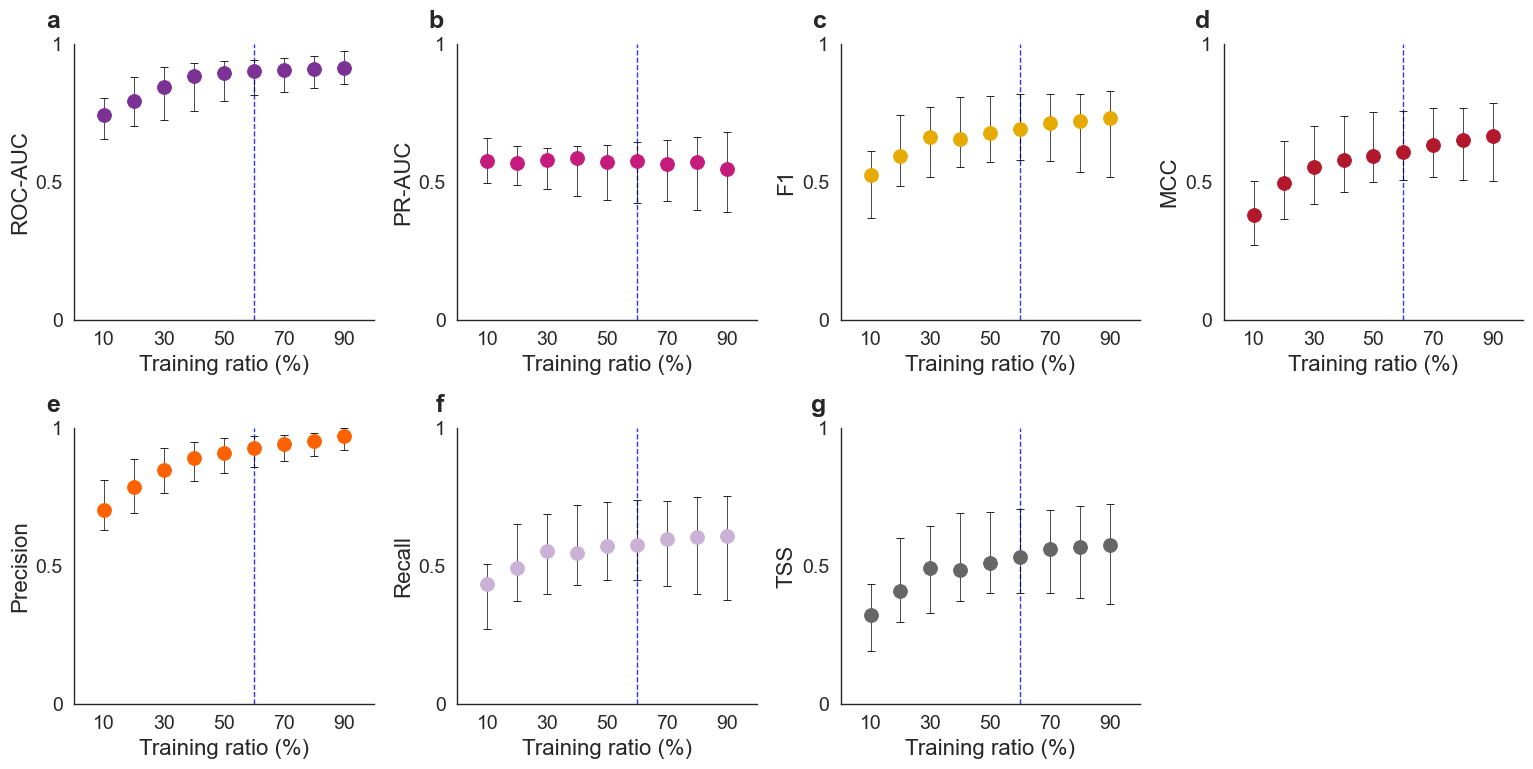

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display


sns.set_context(
    "paper",
    font_scale=1.35,
)

sns.set_style("white")


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    candidates = [start, *start.parents]

    fallback = Path(
        "/Users/acw792/Developer/qmul-phd-framework"
    )

    if fallback not in candidates:
        candidates.append(fallback)

    for candidate in candidates:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the qmul-phd-framework repository."
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final role-only experimental configuration
# ============================================================

CLASSIFICATION_THRESHOLD = 0.50
NODES_THRESHOLD = 0

# Tukey is applied independently across 100 runs for each
# Foodweb × TrainRatio × Metric group.
#
# Keep the agreed absolute minimum of 25 retained runs.
EXPECTED_RUNS = 100
MINIMUM_RETAINED_FRACTION = 0.25
MINIMUM_RETAINED_RUNS = 25

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min25runs_threshold0p50_v1"
)

EXPECTED_SCENARIO = (
    "result_wlnm_dir_neg_roleonly_trophicv2_"
    "100x290_train10-90_Apocrita_20260910_011848"
)

calculated_minimum_runs = int(
    np.ceil(
        EXPECTED_RUNS
        * MINIMUM_RETAINED_FRACTION
    )
)

assert calculated_minimum_runs == MINIMUM_RETAINED_RUNS, (
    "The configured minimum retained runs is inconsistent "
    "with the expected number of runs and retained fraction."
)


# ============================================================
# Final role-only result root
# ============================================================

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_trophicv2_"
        "100x290_train10-90_Apocrita_20260910_011848"
    )
)

RETENTION_ROOT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
)

RETENTION_MANIFEST_PATH = (
    RETENTION_ROOT
    / "retention_manifest.json"
)

RESULTS_FILE = (
    RETENTION_ROOT
    / "figure_inputs"
    / "predictive_train10-90_after_tukey.csv"
)

FOODWEB_CSV = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)


# ============================================================
# Output paths
# ============================================================

OUT_DIR = (
    RETENTION_ROOT
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_STEM = (
    "figure_4_predictive_metrics_by_train_ratio_"
    "roleonly_trophicv2_100runs_thresh0p50_"
    "tukey_iqr1p5_min25runs"
)

PNG_PATH = OUT_DIR / f"{OUTPUT_STEM}.png"
SVG_PATH = OUT_DIR / f"{OUTPUT_STEM}.svg"
PDF_PATH = OUT_DIR / f"{OUTPUT_STEM}.pdf"

SUMMARY_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_summary.csv"
)

RETENTION_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_retention.csv"
)


# ============================================================
# Metrics
# ============================================================

METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

METRIC_PALETTE = {
    "ROC-AUC": "#7B3294",
    "PR-AUC": "#C51B7D",
    "F1": "#E6AB02",
    "MCC": "#B2182B",
    "Precision": "#FE6100",
    "Recall": "#CAB2D6",
    "TSS": "#666666",
}

SHOW_GRID = False

Y_MIN = 0.0
Y_MAX = 1.0

INDEPENDENT_Y = False
Y_PADDING = 0.02

REFERENCE_TRAIN_RATIO = 60


# ============================================================
# Validate required files
# ============================================================

required_files = {
    "Tukey retention manifest": RETENTION_MANIFEST_PATH,
    "Tukey-filtered predictive input": RESULTS_FILE,
    "Food-web metadata": FOODWEB_CSV,
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n\n"
        + "\n\n".join(missing_files)
    )

print(f"[INFO] Repository: {REPO_ROOT}")
print(f"[INFO] Result root: {RESULT_ROOT}")
print(f"[INFO] Tukey input: {RESULTS_FILE}")


# ============================================================
# Validate final role-only configuration
# ============================================================

with RETENTION_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    retention_manifest = json.load(file)

manifest = retention_manifest.get(
    "source_manifest",
    {},
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "Eligibility": "role_only",
    "MassEligibilityEnabled": "false",
    "NegativeSampling": "uniform_without_replacement",
    "NegativeTopupPolicy": "uniform_remaining_nonlinks",
    "NegativePositiveRatio": "2",
    "NumExperiments": str(EXPECTED_RUNS),
    "SweepTrainRatios": "true",
    "TrainRatioRange": "10,20,30,40,50,60,70,80,90",
    "ClassificationThreshold": "0.50",
    "SubgraphK": "10",
    "TrophicLevelProtocol": "validated_v2",
    "TrophicHighPrecision": "auto",
    "ComputeEcologicalMetrics": "true",
    "MinimumRetainedAfterTukey": str(
        MINIMUM_RETAINED_RUNS
    ),
    "FoodWebs": "290",
}

configuration_errors = []

for key, expected_value in expected_manifest.items():
    observed_value = manifest.get(key)

    if observed_value != expected_value:
        configuration_errors.append(
            f"{key}: expected {expected_value!r}, "
            f"observed {observed_value!r}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result root does not match the "
        "final role-only configuration:\n\n"
        + "\n".join(configuration_errors)
    )

observed_scenario = retention_manifest.get(
    "scenario"
)

if observed_scenario != EXPECTED_SCENARIO:
    raise ValueError(
        "Unexpected scenario in retention_manifest.json:\n"
        f"  expected: {EXPECTED_SCENARIO}\n"
        f"  observed: {observed_scenario}"
    )

observed_threshold = retention_manifest.get(
    "classification_threshold"
)

if observed_threshold is None or not np.isclose(
    float(observed_threshold),
    CLASSIFICATION_THRESHOLD,
    atol=1e-9,
):
    raise ValueError(
        "The Tukey retention threshold does not match "
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )

observed_minimum_fraction = retention_manifest.get(
    "minimum_retained_fraction"
)

if observed_minimum_fraction is None or not np.isclose(
    float(observed_minimum_fraction),
    MINIMUM_RETAINED_FRACTION,
    atol=1e-12,
):
    raise ValueError(
        "The Tukey minimum retained fraction does not match:\n"
        f"  expected: {MINIMUM_RETAINED_FRACTION}\n"
        f"  observed: {observed_minimum_fraction}"
    )

observed_standard_example = retention_manifest.get(
    "standard_minimum_example"
)

expected_standard_example = (
    f"{MINIMUM_RETAINED_RUNS} of {EXPECTED_RUNS}"
)

if (
    observed_standard_example is not None
    and observed_standard_example
    != expected_standard_example
):
    raise ValueError(
        "Unexpected standard Tukey minimum in manifest:\n"
        f"  expected: {expected_standard_example}\n"
        f"  observed: {observed_standard_example}"
    )

print(
    "[INFO] Validated final role-only configuration:"
)

print(f"  scenario={observed_scenario}")
print(f"  eligibility={manifest['Eligibility']}")

print(
    "  mass_eligibility_enabled="
    f"{manifest['MassEligibilityEnabled']}"
)

print(
    "  negative_sampling="
    f"{manifest['NegativeSampling']}"
)

print(
    "  negative_positive_ratio="
    f"{manifest['NegativePositiveRatio']}"
)

print(
    "  negative_topup_policy="
    f"{manifest['NegativeTopupPolicy']}"
)

print(
    "  classification_threshold="
    f"{manifest['ClassificationThreshold']}"
)

print(
    "  number_of_experiments="
    f"{manifest['NumExperiments']}"
)

print(
    "  train_ratio_range="
    f"{manifest['TrainRatioRange']}"
)

print(f"  retention_protocol={PROTOCOL_NAME}")

print(
    "  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    "  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)


# ============================================================
# Food-web name normalisation
# ============================================================

def normalize_fw_label(name):
    name = str(name).strip()

    for suffix in [
        ".mat",
        ".csv",
    ]:
        if name.endswith(suffix):
            name = name[: -len(suffix)]

    name = name.replace(
        " ",
        "_",
    )

    for token in [
        "_results_",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(
            token,
            "_",
        )

    return "_".join(
        part
        for part in name.split("_")
        if part
    ).lower()


# ============================================================
# Load Tukey-filtered web-level results
# ============================================================

df = pd.read_csv(
    RESULTS_FILE
)

required_columns = {
    "Scenario",
    "Foodweb",
    "Version",
    "Metric",
    "MetricLabel",
    "MetricFamily",
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "MinimumRetainedRuns",
    "MeetsMinimumRetainedRuns",
}

missing_columns = required_columns.difference(
    df.columns
)

if missing_columns:
    raise ValueError(
        f"{RESULTS_FILE.name} is missing required columns: "
        f"{sorted(missing_columns)}"
    )

numeric_columns = [
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "MinimumRetainedRuns",
    "MeetsMinimumRetainedRuns",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )


# ============================================================
# Select the final role-only configuration
# ============================================================

target_df = df[
    df["Scenario"].eq(
        EXPECTED_SCENARIO
    )
    & df["Version"].eq(
        "WLNM_dir_neg"
    )
    & df["MetricFamily"].eq(
        "predictive"
    )
    & df["Metric"].isin(
        METRICS
    )
    & np.isclose(
        df["Threshold"],
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
        equal_nan=False,
    )
].copy()

if target_df.empty:
    raise RuntimeError(
        "No predictive results match the final "
        "role-only configuration."
    )


# ============================================================
# Validate minimum 25 retained runs
# ============================================================

observed_minimums = set(
    target_df["MinimumRetainedRuns"]
    .dropna()
    .astype(int)
    .unique()
)

if observed_minimums != {
    MINIMUM_RETAINED_RUNS
}:
    raise ValueError(
        "The Tukey figure input was not processed with "
        f"the expected minimum of "
        f"{MINIMUM_RETAINED_RUNS} retained runs.\n"
        f"Observed values: {sorted(observed_minimums)}"
    )

incorrect_retention = target_df[
    target_df["MeetsMinimumRetainedRuns"].eq(1)
    & target_df["RetainedRunsAfterTukey"].lt(
        MINIMUM_RETAINED_RUNS
    )
]

if not incorrect_retention.empty:
    display(
        incorrect_retention[
            [
                "Foodweb",
                "TrainRatio",
                "Metric",
                "RetainedRunsAfterTukey",
                "MinimumRetainedRuns",
                "MeetsMinimumRetainedRuns",
            ]
        ]
    )

    raise ValueError(
        "At least one group is marked as retained despite "
        f"having fewer than {MINIMUM_RETAINED_RUNS} runs."
    )

below_minimum = target_df[
    target_df["RetainedRunsAfterTukey"].lt(
        MINIMUM_RETAINED_RUNS
    )
]

if not below_minimum.empty:
    print(
        "[INFO] Groups excluded because fewer than "
        f"{MINIMUM_RETAINED_RUNS} runs remained: "
        f"{len(below_minimum):,}"
    )


# ============================================================
# Keep valid Tukey-filtered groups
# ============================================================

df = target_df[
    target_df["MinimumRetainedRuns"].eq(
        MINIMUM_RETAINED_RUNS
    )
    & target_df["RetainedRunsAfterTukey"].ge(
        MINIMUM_RETAINED_RUNS
    )
    & target_df["MeetsMinimumRetainedRuns"].eq(1)
    & target_df["MeanAfterTukey"].notna()
].copy()

if df.empty:
    raise RuntimeError(
        "No retained predictive results remain after "
        "validating the Tukey minimum."
    )

print(
    "[INFO] Tukey minimum validated: "
    f"at least {MINIMUM_RETAINED_RUNS} of "
    f"{EXPECTED_RUNS} runs per food web and metric."
)

print(
    "[INFO] Actual retained-run range: "
    f"{int(df['RetainedRunsAfterTukey'].min())}–"
    f"{int(df['RetainedRunsAfterTukey'].max())}"
)


# ============================================================
# Prepare plotting variables
# ============================================================

df["TRAINRATIO"] = (
    df["TrainRatio"]
    .round()
    .astype(int)
)

df["Value"] = (
    df["MeanAfterTukey"]
)

df["FW_KEY"] = (
    df["Foodweb"]
    .apply(normalize_fw_label)
)


# ============================================================
# Validate expected training ratios
# ============================================================

expected_train_ratios = list(
    range(
        10,
        100,
        10,
    )
)

observed_train_ratios = sorted(
    df["TRAINRATIO"]
    .dropna()
    .unique()
    .tolist()
)

if observed_train_ratios != expected_train_ratios:
    raise ValueError(
        "Unexpected training-ratio coverage:\n"
        f"  expected: {expected_train_ratios}\n"
        f"  observed: {observed_train_ratios}"
    )


# ============================================================
# Validate unique web-level observations
# ============================================================

duplicate_mask = df.duplicated(
    subset=[
        "FW_KEY",
        "TRAINRATIO",
        "Metric",
    ],
    keep=False,
)

if duplicate_mask.any():
    duplicated = (
        df.loc[
            duplicate_mask,
            [
                "Foodweb",
                "TRAINRATIO",
                "Metric",
            ],
        ]
        .sort_values(
            [
                "Metric",
                "TRAINRATIO",
                "Foodweb",
            ]
        )
    )

    display(duplicated)

    raise ValueError(
        "Duplicated Foodweb × TrainRatio × Metric "
        "rows were found."
    )


# ============================================================
# Load food-web metadata
# ============================================================

metadata = pd.read_csv(
    FOODWEB_CSV
)

metadata.columns = [
    column.strip()
    for column in metadata.columns
]

foodweb_column = next(
    (
        column
        for column in metadata.columns
        if column.lower() == "foodweb"
    ),
    None,
)

nodes_column = next(
    (
        column
        for column in metadata.columns
        if column.lower() in {
            "nodes",
            "n_nodes",
            "num_nodes",
            "nodecount",
            "s",
        }
    ),
    None,
)

ecosystem_column = next(
    (
        column
        for column in metadata.columns
        if column.lower() in {
            "ecosystem",
            "ecosystemtype",
            "ecosystem_type",
        }
    ),
    None,
)

if (
    foodweb_column is None
    or nodes_column is None
    or ecosystem_column is None
):
    raise ValueError(
        "Could not identify Foodweb, Nodes, and "
        "Ecosystem columns in the metadata."
    )

metadata[nodes_column] = pd.to_numeric(
    metadata[nodes_column],
    errors="coerce",
)

metadata["FW_KEY"] = (
    metadata[foodweb_column]
    .apply(normalize_fw_label)
)

duplicate_metadata = metadata.duplicated(
    subset=["FW_KEY"],
    keep=False,
)

if duplicate_metadata.any():
    inconsistent_metadata = (
        metadata.loc[
            duplicate_metadata,
            [
                "FW_KEY",
                nodes_column,
                ecosystem_column,
            ],
        ]
        .groupby("FW_KEY")
        .nunique(
            dropna=False
        )
    )

    inconsistent_metadata = inconsistent_metadata[
        (
            inconsistent_metadata[nodes_column] > 1
        )
        | (
            inconsistent_metadata[
                ecosystem_column
            ] > 1
        )
    ]

    if not inconsistent_metadata.empty:
        display(
            inconsistent_metadata
        )

        raise ValueError(
            "Conflicting metadata were found for one or "
            "more normalised food-web names."
        )

metadata = (
    metadata[
        [
            "FW_KEY",
            nodes_column,
            ecosystem_column,
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"]
    )
    .rename(
        columns={
            nodes_column: "Nodes",
            ecosystem_column: "Ecosystem",
        }
    )
)


# ============================================================
# Merge metadata and apply node filter
# ============================================================

df = df.merge(
    metadata,
    on="FW_KEY",
    how="left",
    validate="many_to_one",
)

missing_metadata = (
    df.loc[
        (
            df["Nodes"].isna()
            | df["Ecosystem"].isna()
        ),
        "Foodweb",
    ]
    .drop_duplicates()
    .sort_values()
)

if not missing_metadata.empty:
    display(
        missing_metadata.to_frame(
            name="Foodweb"
        )
    )

    raise ValueError(
        "Food-web metadata could not be matched for "
        f"{len(missing_metadata)} food webs."
    )

df = df[
    df["Nodes"] >= NODES_THRESHOLD
].copy()

if df.empty:
    raise RuntimeError(
        f"No food webs remain after applying "
        f"Nodes >= {NODES_THRESHOLD}."
    )

print(
    f"[INFO] Food webs after node filter: "
    f"{df['FW_KEY'].nunique()}"
)

print(
    "[INFO] Training ratios: "
    f"{sorted(df['TRAINRATIO'].unique().tolist())}"
)

print(
    "[INFO] Ecosystems: "
    f"{sorted(df['Ecosystem'].dropna().unique().tolist())}"
)


# ============================================================
# Retention report
# ============================================================

retention_table = (
    df
    .groupby(
        [
            "TRAINRATIO",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        MinimumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetainedRuns=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "max",
        ),
    )
)

retention_table["MetricLabel"] = (
    retention_table["Metric"]
    .map(METRIC_LABELS)
)

retention_table = retention_table[
    [
        "TRAINRATIO",
        "Metric",
        "MetricLabel",
        "FoodWebs",
        "MinimumRetainedRuns",
        "MedianRetainedRuns",
        "MaximumRetainedRuns",
    ]
]

print(
    "\n=== Tukey retention by training ratio "
    "and metric ==="
)

display(
    retention_table
)


# ============================================================
# Across-food-web summary
# ============================================================

summary = (
    df
    .groupby(
        [
            "TRAINRATIO",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        median=(
            "Value",
            "median",
        ),
        q25=(
            "Value",
            lambda values: values.quantile(
                0.25
            ),
        ),
        q75=(
            "Value",
            lambda values: values.quantile(
                0.75
            ),
        ),
        mean=(
            "Value",
            "mean",
        ),
        sd=(
            "Value",
            "std",
        ),
        n_webs=(
            "FW_KEY",
            "nunique",
        ),
    )
)

summary["MetricLabel"] = (
    summary["Metric"]
    .map(METRIC_LABELS)
)

train_ratios = sorted(
    summary["TRAINRATIO"]
    .unique()
    .tolist()
)

print(
    f"[INFO] Food webs represented: "
    f"{df['FW_KEY'].nunique()}"
)


# ============================================================
# Consistent metric colours
# ============================================================

metric_colors = {
    metric: METRIC_PALETTE[
        METRIC_LABELS[metric]
    ]
    for metric in METRICS
}


# ============================================================
# Final plot
# ============================================================

number_of_metrics = len(
    METRICS
)

number_of_rows = 2

number_of_columns = int(
    np.ceil(
        number_of_metrics
        / number_of_rows
    )
)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(
        4 * number_of_columns,
        8.0,
    ),
    sharex=False,
    sharey=False,
)

axes = np.asarray(
    axes
).reshape(
    number_of_rows,
    number_of_columns,
)

axes_flat = axes.flatten()

panel_letters = list(
    "abcdefghijklmnopqrstuvwxyz"
)

for index, metric in enumerate(
    METRICS
):
    ax = axes_flat[index]

    panel_df = (
        summary[
            summary["Metric"].eq(
                metric
            )
        ]
        .sort_values(
            "TRAINRATIO"
        )
    )

    if panel_df.empty:
        ax.set_axis_off()
        continue

    x_values = (
        panel_df["TRAINRATIO"]
        .to_numpy()
    )

    median_values = (
        panel_df["median"]
        .to_numpy()
    )

    error_values = np.vstack(
        [
            (
                panel_df["median"]
                - panel_df["q25"]
            ).to_numpy(),
            (
                panel_df["q75"]
                - panel_df["median"]
            ).to_numpy(),
        ]
    )

    color = metric_colors[
        metric
    ]

    ax.errorbar(
        x_values,
        median_values,
        yerr=error_values,
        fmt="o",
        linestyle="none",
        color=color,
        ecolor="black",
        markersize=10,
        linewidth=1.2,
        elinewidth=0.5,
        capsize=3,
        capthick=0.8,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.6,
    )

    ax.axvline(
        x=REFERENCE_TRAIN_RATIO,
        color="blue",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=0,
    )

    if INDEPENDENT_Y:
        local_minimum = max(
            Y_MIN,
            panel_df["q25"].min()
            - Y_PADDING,
        )

        local_maximum = min(
            Y_MAX,
            panel_df["q75"].max()
            + Y_PADDING,
        )

        if np.isclose(
            local_minimum,
            local_maximum,
        ):
            local_minimum = max(
                Y_MIN,
                local_minimum
                - 0.02,
            )

            local_maximum = min(
                Y_MAX,
                local_maximum
                + 0.02,
            )

        ax.set_ylim(
            local_minimum,
            local_maximum,
        )

    else:
        ax.set_ylim(
            Y_MIN,
            Y_MAX,
        )

        ax.set_yticks(
            [
                0,
                0.5,
                1.0,
            ]
        )

        ax.set_yticklabels(
            [
                "0",
                "0.5",
                "1",
            ]
        )

    if SHOW_GRID:
        ax.grid(
            True,
            axis="y",
            linestyle="--",
            alpha=0.30,
        )
    else:
        ax.grid(
            False
        )

    visible_ticks = [
        ratio
        for ratio in [
            10,
            30,
            50,
            70,
            90,
        ]
        if ratio in train_ratios
    ]

    ax.set_xticks(
        visible_ticks
    )

    ax.set_xticklabels(
        [
            str(ratio)
            for ratio in visible_ticks
        ]
    )

    ax.set_xlim(
        min(train_ratios) - 10,
        max(train_ratios) + 10,
    )

    ax.set_xlabel(
        "Training ratio (%)",
        fontsize=16,
    )

    ax.set_ylabel(
        METRIC_LABELS[metric],
        fontsize=16,
    )

    ax.set_title("")

    if index < len(
        panel_letters
    ):
        ax.annotate(
            panel_letters[index],
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(-10, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=18,
            fontweight="bold",
            annotation_clip=False,
        )

    ax.tick_params(
        axis="both",
        labelsize=14,
    )

    sns.despine(
        ax=ax
    )


# ============================================================
# Hide unused panels
# ============================================================

for index in range(
    number_of_metrics,
    len(axes_flat),
):
    axes_flat[index].set_axis_off()


# ============================================================
# Layout and export
# ============================================================

fig.tight_layout(
    rect=[
        0.03,
        0,
        1,
        0.985,
    ]
)

fig.savefig(
    PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    SVG_PATH,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)

summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

retention_table.to_csv(
    RETENTION_PATH,
    index=False,
)

print(
    "\n[INFO] Saved publication-ready outputs:"
)

print(f"  PNG: {PNG_PATH}")
print(f"  SVG: {SVG_PATH}")
print(f"  PDF: {PDF_PATH}")
print(f"  Summary: {SUMMARY_PATH}")
print(f"  Retention: {RETENTION_PATH}")

print(
    "\n[INFO] Final Tukey configuration:"
)

print(
    f"  expected_runs="
    f"{EXPECTED_RUNS}"
)

print(
    f"  minimum_retained_fraction="
    f"{MINIMUM_RETAINED_FRACTION:.2f}"
)

print(
    f"  minimum_retained_runs="
    f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}"
)

plt.show()

[INFO] Food-web metadata rows: 290

[INFO] TrainRatio = 40; Threshold = 0.5
[INFO] Source file: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/ecological_train40_after_tukey.csv
[INFO] Loaded Tukey-filtered ecological rows: 2,320
[INFO] Training graph web-level rows: 1,160
[INFO] Plotting rows after empirical/train/pseudo expansion: 3,480
[INFO] Pseudo and training values use Tukey 1.5 x IQR filtering with at least 25/100 runs.


,Metric,FoodWebs,TotalPseudoRunOutliersRemoved,MinRetainedRuns,MedianRetainedRuns
0,Connectance,290,433,85,99.0
1,ConsumerToResourceRatio,290,484,89,99.0
2,MeanTrophicHeight,290,2224,44,87.0
3,ResourceToConsumerRatio,290,402,88,99.0


,Metric,Web type,FoodWebs,Rows
0,Connectance,Empirical,290,290
1,Connectance,Training (40%),290,290
2,Connectance,Pseudo,290,290
3,ConsumerToResourceRatio,Empirical,290,290
4,ConsumerToResourceRatio,Training (40%),290,290
5,ConsumerToResourceRatio,Pseudo,290,290
6,MeanTrophicHeight,Empirical,290,290
7,MeanTrophicHeight,Training (40%),290,290
8,MeanTrophicHeight,Pseudo,290,290
9,ResourceToConsumerRatio,Empirical,290,290


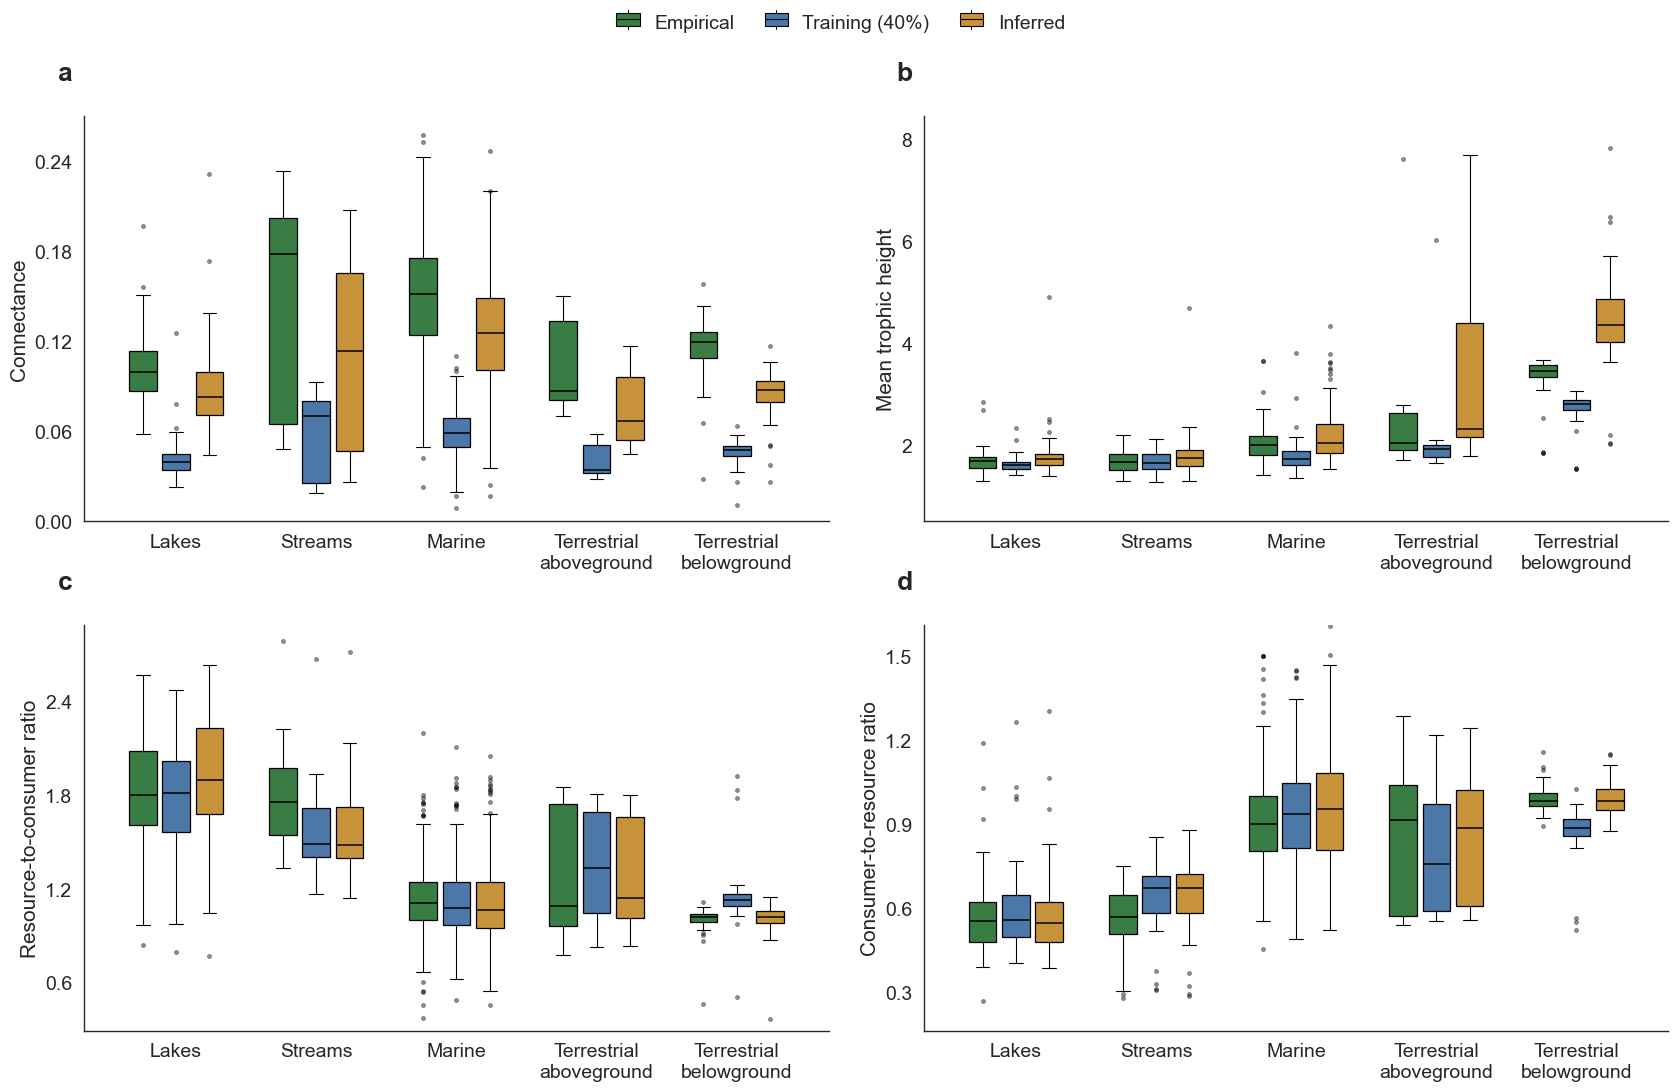


[INFO] TrainRatio = 50; Threshold = 0.5
[INFO] Source file: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/ecological_train50_after_tukey.csv
[INFO] Loaded Tukey-filtered ecological rows: 2,320
[INFO] Training graph web-level rows: 1,160
[INFO] Plotting rows after empirical/train/pseudo expansion: 3,480
[INFO] Pseudo and training values use Tukey 1.5 x IQR filtering with at least 25/100 runs.


,Metric,FoodWebs,TotalPseudoRunOutliersRemoved,MinRetainedRuns,MedianRetainedRuns
0,Connectance,290,469,84,99.0
1,ConsumerToResourceRatio,290,572,83,99.0
2,MeanTrophicHeight,290,2216,39,87.0
3,ResourceToConsumerRatio,290,482,83,99.0


,Metric,Web type,FoodWebs,Rows
0,Connectance,Empirical,290,290
1,Connectance,Training (50%),290,290
2,Connectance,Pseudo,290,290
3,ConsumerToResourceRatio,Empirical,290,290
4,ConsumerToResourceRatio,Training (50%),290,290
5,ConsumerToResourceRatio,Pseudo,290,290
6,MeanTrophicHeight,Empirical,290,290
7,MeanTrophicHeight,Training (50%),290,290
8,MeanTrophicHeight,Pseudo,290,290
9,ResourceToConsumerRatio,Empirical,290,290


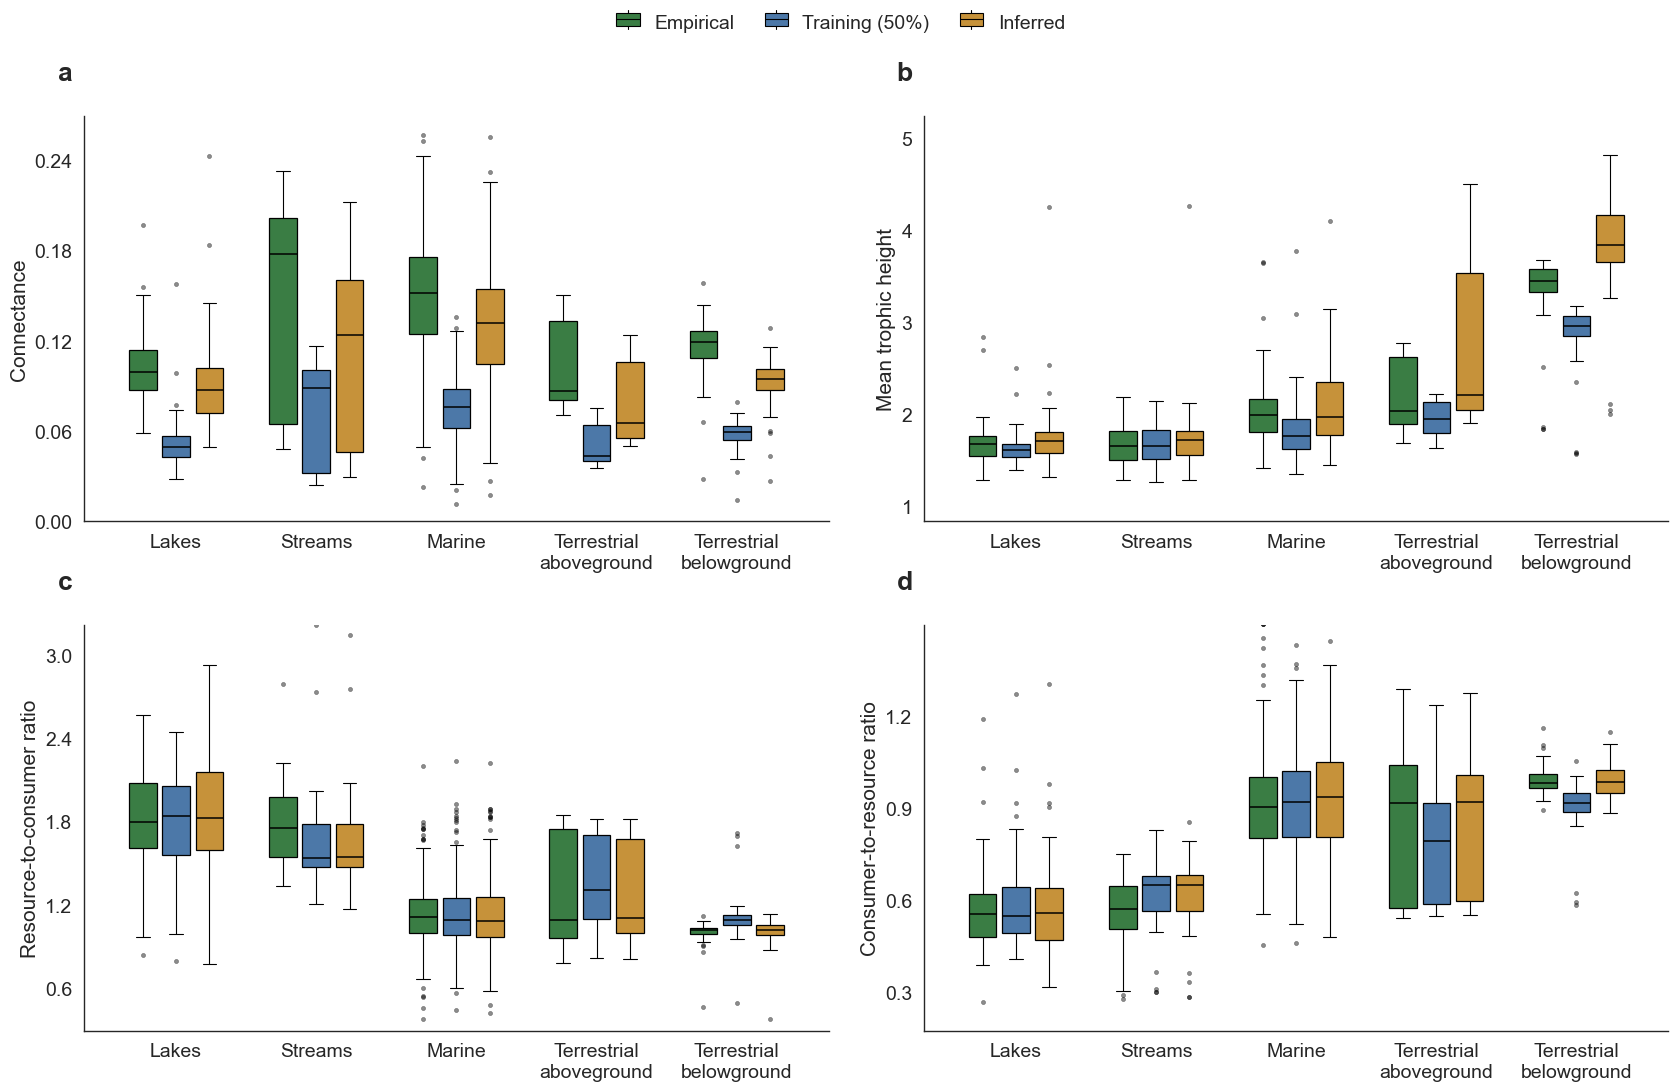


[INFO] TrainRatio = 60; Threshold = 0.5
[INFO] Source file: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/ecological_train60_after_tukey.csv
[INFO] Loaded Tukey-filtered ecological rows: 2,320
[INFO] Training graph web-level rows: 1,160
[INFO] Plotting rows after empirical/train/pseudo expansion: 3,480
[INFO] Pseudo and training values use Tukey 1.5 x IQR filtering with at least 25/100 runs.


,Metric,FoodWebs,TotalPseudoRunOutliersRemoved,MinRetainedRuns,MedianRetainedRuns
0,Connectance,290,471,83,99.0
1,ConsumerToResourceRatio,290,620,80,99.0
2,MeanTrophicHeight,290,2275,42,88.0
3,ResourceToConsumerRatio,290,551,79,99.0


,Metric,Web type,FoodWebs,Rows
0,Connectance,Empirical,290,290
1,Connectance,Training (60%),290,290
2,Connectance,Pseudo,290,290
3,ConsumerToResourceRatio,Empirical,290,290
4,ConsumerToResourceRatio,Training (60%),290,290
5,ConsumerToResourceRatio,Pseudo,290,290
6,MeanTrophicHeight,Empirical,290,290
7,MeanTrophicHeight,Training (60%),290,290
8,MeanTrophicHeight,Pseudo,290,290
9,ResourceToConsumerRatio,Empirical,290,290


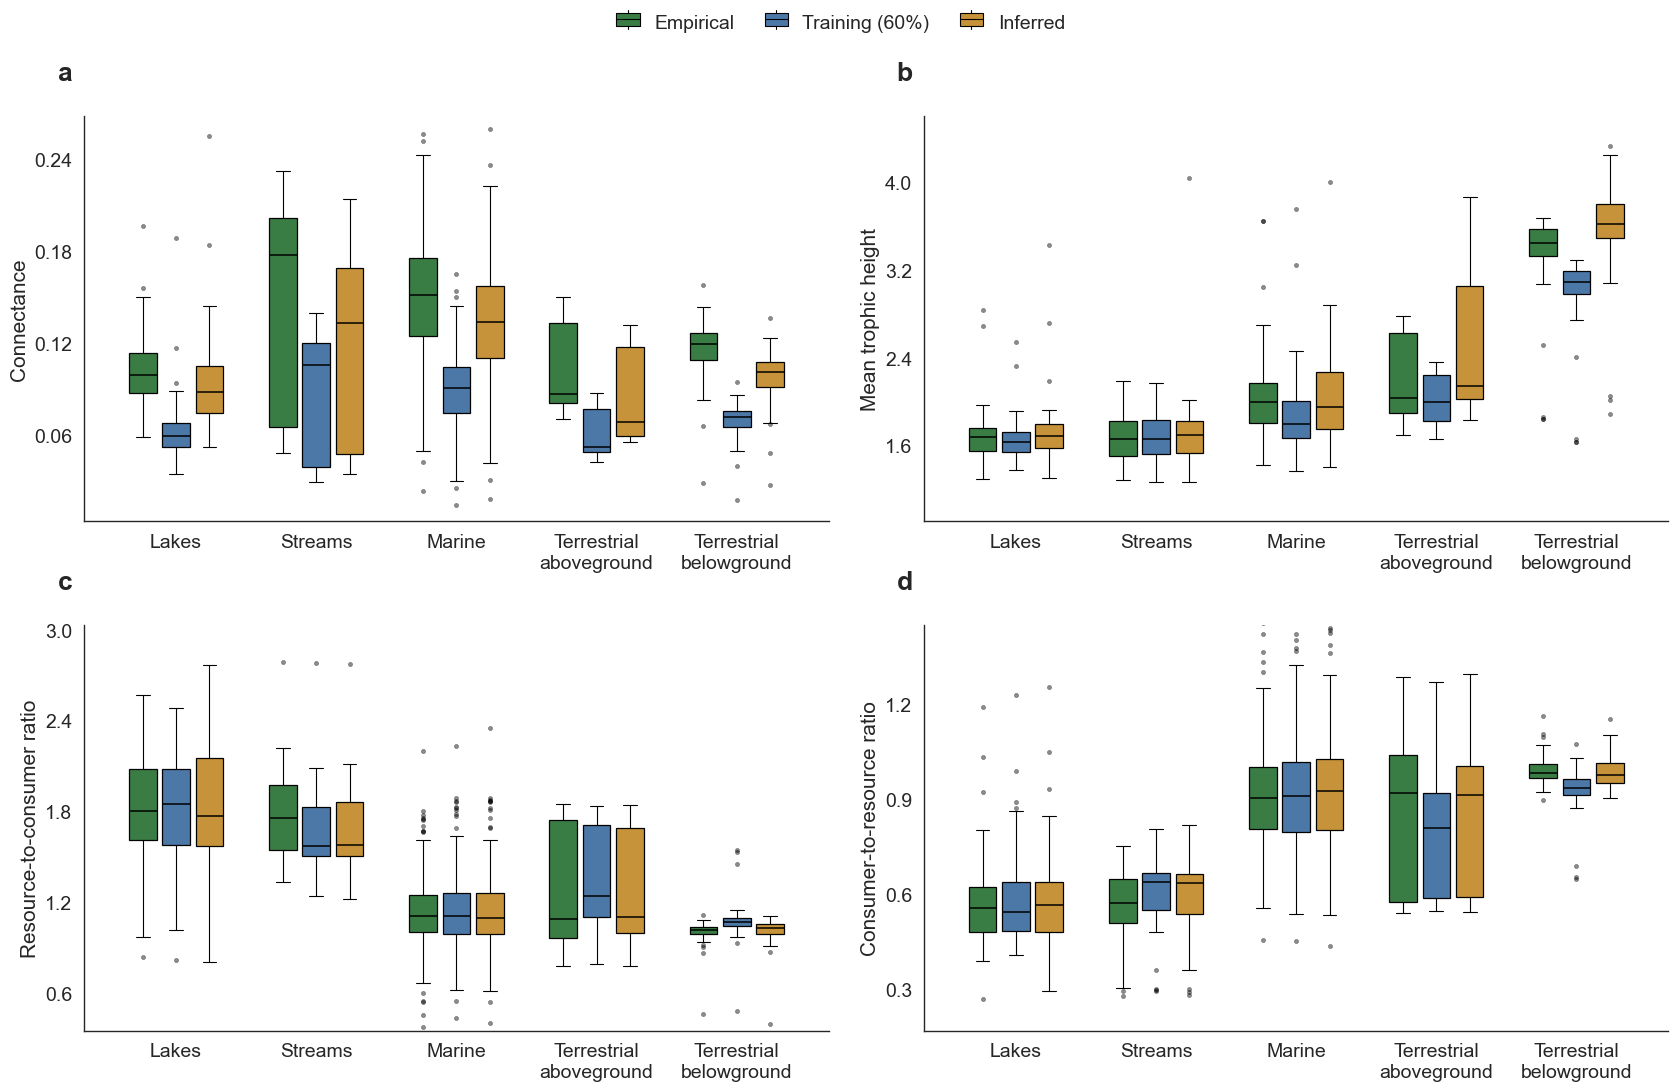

In [1]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MaxNLocator

sns.set_theme(context="paper", style="white", font_scale=1.2)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()
TRAIN_RATIOS = [40, 50, 60]
THRESHOLD = 0.5
EXPECTED_RUNS = 100
MINIMUM_RETAINED_RUNS = 25

RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_trophicv2_"
        "100x290_train10-90_Apocrita_20260910_011848"
    )
)

PROTOCOL_NAME = "tukey_iqr_1p5_min25runs_threshold0p50_v1"

FIGURE_INPUT_DIR = (
    RESULT_DIR
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
)

PSEUDO_RATIO_INPUT = (
    RESULT_DIR
    / "retention_protocol"
    / "ratio_metrics_tukey_iqr_1p5_min25runs_threshold0p50_v1"
    / "figure_inputs/ratio_metric_means_after_tukey.csv"
)

TRAINING_RATIO_INPUT = (
    RESULT_DIR
    / "retention_protocol"
    / "training_ratio_metrics_tukey_iqr_1p5_min25runs_threshold0p50_v1"
    / "figure_inputs/training_ratio_metric_means_after_tukey.csv"
)

FOODWEB_METADATA = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
)

# ============================================================
# CONFIG
# ============================================================
BOX_WIDTH = 0.24
TYPE_OFFSET = 0.29
GROUP_SPACING = 1.22
SHOW_WEB_LEVEL_FLIERS = True

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

metric_order = [
    "Connectance",
    "MeanTrophicHeight",
    "ResourceToConsumerRatio",
    "ConsumerToResourceRatio",
]

metric_labels = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "ResourceToConsumerRatio": "Resource-to-consumer ratio",
    "ConsumerToResourceRatio": "Consumer-to-resource ratio",
}

PSEUDO_METRIC_MAP = {
    "PseudoConnectance": "Connectance",
    "PseudoMeanTrophicHeight": "MeanTrophicHeight",
    "PseudoResourceToConsumerRatio": "ResourceToConsumerRatio",
    "PseudoConsumerToResourceRatio": "ConsumerToResourceRatio",
}

TRAIN_METRIC_MAP = {
    "TrainConnectance": "Connectance",
    "TrainMeanTrophicHeight": "MeanTrophicHeight",
    "TrainResourceToConsumerRatio": "ResourceToConsumerRatio",
    "TrainConsumerToResourceRatio": "ConsumerToResourceRatio",
}

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

# ============================================================
# HELPERS
# ============================================================
def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    return ecosystem_labels.get(eco_clean, str(eco).strip().capitalize())


def normalize_foodweb_key(value: str) -> str:
    value = Path(str(value).strip()).stem
    for suffix in ("_tax_mass", "_taxmass"):
        if value.lower().endswith(suffix):
            value = value[:-len(suffix)]
            break
    return " ".join(value.replace("_", " ").casefold().split())


def draw_box(ax, values, position, facecolor, showfliers=False):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=showfliers,
        boxprops={"facecolor": facecolor, "edgecolor": "black", "linewidth": 0.9},
        medianprops={"color": "black", "linewidth": 1.1},
        whiskerprops={"color": "black", "linewidth": 0.8},
        capprops={"color": "black", "linewidth": 0.8},
        flierprops={
            "marker": "o",
            "markersize": 3.0,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
            "alpha": 0.45,
        },
    )


def get_boxplot_visible_ylim(grouped_values, lower_bound=0.0, pad_fraction=0.12):
    visible_lows = []
    visible_highs = []

    for values in grouped_values:
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]

        if values.size == 0:
            continue

        q1, q3 = np.nanpercentile(values, [25, 75])
        iqr = q3 - q1

        if np.isclose(iqr, 0):
            lower_whisker = np.nanmin(values)
            upper_whisker = np.nanmax(values)
        else:
            lower_fence = q1 - 1.5 * iqr
            upper_fence = q3 + 1.5 * iqr
            non_fliers = values[(values >= lower_fence) & (values <= upper_fence)]

            if non_fliers.size == 0:
                non_fliers = values

            lower_whisker = np.nanmin(non_fliers)
            upper_whisker = np.nanmax(non_fliers)

        visible_lows.extend([lower_whisker, q1])
        visible_highs.extend([upper_whisker, q3])

    if not visible_lows or not visible_highs:
        return None

    local_min = np.nanmin(visible_lows)
    local_max = np.nanmax(visible_highs)
    data_range = local_max - local_min if local_max > local_min else 0.05

    local_min = max(lower_bound, local_min - pad_fraction * data_range)
    local_max = local_max + pad_fraction * data_range

    if np.isclose(local_min, local_max):
        local_min = max(lower_bound, local_min - 0.02)
        local_max = local_max + 0.02

    return local_min, local_max


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.8)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# ============================================================
# LOAD FOOD-WEB ECOSYSTEM METADATA ONCE
# ============================================================
if not FOODWEB_METADATA.is_file():
    raise FileNotFoundError(f"Missing food-web metadata: {FOODWEB_METADATA}")

metadata_df = pd.read_csv(FOODWEB_METADATA)
required_metadata_columns = {"Foodweb", "EcosystemType"}
missing_metadata_columns = required_metadata_columns.difference(metadata_df.columns)
if missing_metadata_columns:
    raise KeyError(
        f"Metadata is missing columns: {sorted(missing_metadata_columns)}"
    )

metadata_df["FW_KEY"] = metadata_df["Foodweb"].map(normalize_foodweb_key)
metadata_df["ecosystem"] = (
    metadata_df["EcosystemType"].astype(str).str.strip().str.lower()
)

metadata_conflicts = (
    metadata_df.groupby("FW_KEY")["ecosystem"].nunique(dropna=True).gt(1)
)
if metadata_conflicts.any():
    raise RuntimeError(
        "Conflicting ecosystem labels for: "
        + ", ".join(metadata_conflicts[metadata_conflicts].index[:10])
    )

metadata_df = metadata_df[["FW_KEY", "ecosystem"]].drop_duplicates("FW_KEY")
print(f"[INFO] Food-web metadata rows: {len(metadata_df):,}")


# ============================================================
# PLOT FUNCTION
# ============================================================
def plot_fig5_for_train_ratio(train_ratio):
    ecological_input = (
        FIGURE_INPUT_DIR
        / f"ecological_train{train_ratio}_after_tukey.csv"
    )

    if not ecological_input.is_file():
        raise FileNotFoundError(f"Missing file: {ecological_input}")

    training_label = f"Training ({train_ratio}%)"

    web_type_order = [
        "Empirical",
        training_label,
        "Pseudo",
    ]

    type_offsets = {
        "Empirical": -TYPE_OFFSET,
        training_label: 0.0,
        "Pseudo": TYPE_OFFSET,
    }

    type_palette = {
        "Empirical": "#3A7D44",
        training_label: "#4C78A8",
        "Pseudo": "#C6923A",
    }

    # ========================================================
    # LOAD THE UNIFIED TUKEY-FILTERED WEB-LEVEL INPUT
    # ========================================================
    ecological = pd.read_csv(ecological_input)
    required_columns = {
        "Foodweb", "Metric", "MeanAfterTukey", "ReferenceValue",
        "OutlierRunsExcluded", "RetainedRunsAfterTukey", "ExpectedRuns",
        "MinimumRetainedRuns", "MeetsMinimumRetainedRuns", "TrainRatio",
        "Threshold",
    }
    missing_columns = required_columns.difference(ecological.columns)
    if missing_columns:
        raise KeyError(
            f"Tukey input is missing columns: {sorted(missing_columns)}"
        )

    ratio_metric_names = {
        "ResourceToConsumerRatio",
        "ConsumerToResourceRatio",
    }
    ratio_frames = []
    for ratio_input, metric_prefix in [
        (PSEUDO_RATIO_INPUT, "Pseudo"),
        (TRAINING_RATIO_INPUT, "Train"),
    ]:
        if not ratio_input.is_file():
            raise FileNotFoundError(f"Missing ratio file: {ratio_input}")
        ratio_frame = pd.read_csv(ratio_input)
        missing_ratio_columns = required_columns.difference(ratio_frame.columns)
        if missing_ratio_columns:
            raise KeyError(
                f"Ratio input is missing columns: {sorted(missing_ratio_columns)}"
            )
        ratio_frame = ratio_frame.loc[
            ratio_frame["Metric"].isin(ratio_metric_names)
        ].copy()
        ratio_frame["Metric"] = metric_prefix + ratio_frame["Metric"]
        ratio_frames.append(ratio_frame)

    ecological = pd.concat(
        [ecological, *ratio_frames],
        ignore_index=True,
        sort=False,
    )

    numeric_columns = [
        "MeanAfterTukey", "ReferenceValue", "OutlierRunsExcluded",
        "RetainedRunsAfterTukey", "ExpectedRuns", "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns", "TrainRatio", "Threshold",
    ]
    for column in numeric_columns:
        ecological[column] = pd.to_numeric(ecological[column], errors="coerce")

    requested_metrics = set(PSEUDO_METRIC_MAP) | set(TRAIN_METRIC_MAP)
    ecological = ecological[
        ecological["Metric"].isin(requested_metrics)
        & np.isclose(ecological["TrainRatio"], train_ratio)
        & np.isclose(ecological["Threshold"], THRESHOLD)
        & ecological["ExpectedRuns"].eq(EXPECTED_RUNS)
        & ecological["MinimumRetainedRuns"].eq(MINIMUM_RETAINED_RUNS)
        & ecological["RetainedRunsAfterTukey"].ge(MINIMUM_RETAINED_RUNS)
        & ecological["MeetsMinimumRetainedRuns"].eq(1)
    ].copy()

    ecological = ecological.dropna(subset=["MeanAfterTukey", "ReferenceValue"])
    ecological["FW_KEY"] = ecological["Foodweb"].map(normalize_foodweb_key)
    ecological = ecological.merge(
        metadata_df,
        on="FW_KEY",
        how="left",
        validate="many_to_one",
    )

    missing_ecosystem = ecological.loc[
        ecological["ecosystem"].isna(), "Foodweb"
    ].drop_duplicates()
    if not missing_ecosystem.empty:
        raise RuntimeError(
            "Missing ecosystem metadata for: "
            + ", ".join(missing_ecosystem.head(10))
        )

    ecological["BaseMetric"] = ecological["Metric"].map(
        {**PSEUDO_METRIC_MAP, **TRAIN_METRIC_MAP}
    )

    # ========================================================
    # BUILD EMPIRICAL AND PSEUDO WEB-LEVEL DATA
    # ========================================================
    empirical_source = ecological[
        ["Foodweb", "FW_KEY", "ecosystem", "BaseMetric", "ReferenceValue"]
    ].copy()

    reference_conflicts = (
        empirical_source
        .groupby(["FW_KEY", "BaseMetric"])["ReferenceValue"]
        .nunique(dropna=True)
        .gt(1)
    )
    if reference_conflicts.any():
        raise RuntimeError("Conflicting empirical reference values in Tukey input.")

    empirical_df = (
        empirical_source
        .groupby(
            ["Foodweb", "FW_KEY", "ecosystem", "BaseMetric"],
            as_index=False,
            observed=True,
        )["ReferenceValue"]
        .first()
        .rename(columns={"BaseMetric": "Metric", "ReferenceValue": "value"})
    )
    empirical_df = empirical_df.rename(columns={"Foodweb": "FoodWeb"})
    empirical_df["Web type"] = "Empirical"

    pseudo_df = ecological.loc[
        ecological["Metric"].isin(PSEUDO_METRIC_MAP),
        ["Foodweb", "FW_KEY", "ecosystem", "BaseMetric", "MeanAfterTukey"],
    ].rename(
        columns={
            "Foodweb": "FoodWeb",
            "BaseMetric": "Metric",
            "MeanAfterTukey": "value",
        }
    )
    pseudo_df["Web type"] = "Pseudo"

    # ========================================================
    # BUILD TRAINING-GRAPH WEB-LEVEL DATA
    # ========================================================
    train_df = ecological.loc[
        ecological["Metric"].isin(TRAIN_METRIC_MAP),
        ["Foodweb", "FW_KEY", "ecosystem", "BaseMetric", "MeanAfterTukey"],
    ].rename(
        columns={
            "Foodweb": "FoodWeb",
            "BaseMetric": "Metric",
            "MeanAfterTukey": "value",
        }
    )
    train_df["Web type"] = training_label

    # Keep only food-web/metric pairs represented in all three series.
    key_columns = ["FW_KEY", "Metric"]
    common_keys = set(map(tuple, empirical_df[key_columns].to_numpy()))
    common_keys &= set(map(tuple, train_df[key_columns].to_numpy()))
    common_keys &= set(map(tuple, pseudo_df[key_columns].to_numpy()))
    if not common_keys:
        raise RuntimeError("No complete empirical/training/pseudo pairs remain.")

    for frame in (empirical_df, train_df, pseudo_df):
        frame["PAIR_KEY"] = list(map(tuple, frame[key_columns].to_numpy()))
        frame.drop(frame.index[~frame["PAIR_KEY"].isin(common_keys)], inplace=True)
        frame.drop(columns="PAIR_KEY", inplace=True)

    # ========================================================
    # FINAL PLOTTING DATA
    # ========================================================
    plot_df = pd.concat(
        [empirical_df, train_df, pseudo_df],
        ignore_index=True,
    )

    plot_df["value"] = pd.to_numeric(plot_df["value"], errors="coerce")
    plot_df = plot_df.dropna(subset=["value", "ecosystem", "Metric", "Web type"])

    plot_df["Web type"] = pd.Categorical(
        plot_df["Web type"],
        categories=web_type_order,
        ordered=True,
    )

    print(f"\n[INFO] TrainRatio = {train_ratio}; Threshold = {THRESHOLD}")
    print(f"[INFO] Source file: {ecological_input}")
    print(f"[INFO] Loaded Tukey-filtered ecological rows: {len(ecological):,}")
    print(f"[INFO] Training graph web-level rows: {len(train_df):,}")
    print(f"[INFO] Plotting rows after empirical/train/pseudo expansion: {len(plot_df):,}")
    print(
        "[INFO] Pseudo and training values use Tukey 1.5 x IQR filtering "
        f"with at least {MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS} runs."
    )

    removed_summary = (
        ecological[ecological["Metric"].isin(PSEUDO_METRIC_MAP)]
        .assign(BaseMetric=lambda x: x["Metric"].map(PSEUDO_METRIC_MAP))
        .groupby("BaseMetric", as_index=False)
        .agg(
            FoodWebs=("Foodweb", "nunique"),
            TotalPseudoRunOutliersRemoved=("OutlierRunsExcluded", "sum"),
            MinRetainedRuns=("RetainedRunsAfterTukey", "min"),
            MedianRetainedRuns=("RetainedRunsAfterTukey", "median"),
        )
        .rename(columns={"BaseMetric": "Metric"})
    )

    display(removed_summary)

    web_type_counts = (
        plot_df
        .groupby(["Metric", "Web type"], observed=True)
        .agg(FoodWebs=("FoodWeb", "nunique"), Rows=("value", "size"))
        .reset_index()
    )

    display(web_type_counts)

    # ========================================================
    # PLOT
    # ========================================================
    n_panels = len(metric_order)
    n_cols = 2
    n_rows = math.ceil(n_panels / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 10.6), sharey=False)
    axes = np.array(axes).reshape(-1)

    legend_handles = [
        {"facecolor": type_palette[web_type], "edgecolor": "black", "linewidth": 0.8}
        for web_type in web_type_order
    ]

    legend_labels = [
        "Empirical",
        training_label,
        "Inferred",
    ]

    for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
        panel_df = plot_df[plot_df["Metric"] == metric].copy()

        if panel_df.empty:
            ax.set_visible(False)
            continue

        present_ecosystems = [
            eco for eco in base_ecosystem_order
            if eco in panel_df["ecosystem"].unique()
        ]
        extra_ecosystems = [
            eco for eco in panel_df["ecosystem"].unique()
            if eco not in base_ecosystem_order
        ]
        eco_order = present_ecosystems + extra_ecosystems

        base_positions = np.arange(len(eco_order)) * GROUP_SPACING
        boxplot_groups = []

        for eco, base_x in zip(eco_order, base_positions):
            eco_df = panel_df[panel_df["ecosystem"] == eco]

            for web_type in web_type_order:
                values = (
                    eco_df[eco_df["Web type"] == web_type]["value"]
                    .dropna()
                    .values
                )

                if len(values):
                    draw_box(
                        ax=ax,
                        values=values,
                        position=base_x + type_offsets[web_type],
                        facecolor=type_palette[web_type],
                        showfliers=SHOW_WEB_LEVEL_FLIERS,
                    )
                    boxplot_groups.append(values)

        ax.set_title("")
        ax.set_ylabel(metric_labels[metric], fontsize=15)
        ax.set_xlabel("")
        ax.tick_params(axis="both", labelsize=14)

        ylim = get_boxplot_visible_ylim(
            boxplot_groups,
            lower_bound=0.0,
            pad_fraction=0.12,
        )

        if ylim is not None:
            ax.set_ylim(*ylim)
            ax.yaxis.set_major_locator(MaxNLocator(5))

        ax.set_xlim(base_positions[0] - 0.80, base_positions[-1] + 0.80)

        ax.set_xticks(base_positions)
        ax.set_xticklabels(
            [format_ecosystem_label(eco) for eco in eco_order],
            rotation=0,
            fontsize=14,
        )

        ax.grid(False, axis="x")
        ax.grid(False, axis="y")
        sns.despine(ax=ax)

        ax.annotate(
            panel_letters[idx],
            xy=(0, 1.05),
            xycoords="axes fraction",
            xytext=(-8, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=19,
            fontweight="bold",
            annotation_clip=False,
        )

    for j in range(len(metric_order), len(axes)):
        axes[j].set_visible(False)

    # ========================================================
    # GLOBAL LEGEND
    # ========================================================
    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        handler_map={dict: HandlerMiniBoxplot()},
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        ncol=3,
        frameon=False,
        fontsize=14,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        columnspacing=1.4,
        borderpad=0.2,
        labelspacing=0.45,
    )

    fig.tight_layout(pad=1.3, w_pad=2.0, h_pad=0)

    plt.show()


# ============================================================
# PRINT FIGURES FOR THE AVAILABLE ECOLOGICAL INPUTS: 40%, 50%, AND 60%
# ============================================================
for train_ratio in TRAIN_RATIOS:
    plot_fig5_for_train_ratio(train_ratio)

[INFO] Repository: /Users/acw792/Developer/qmul-phd-framework
[INFO] Using Tukey-filtered inputs:
  Original: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_original_100x290_train10-90_thresh0p50_Apocrita_20260916_221905/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
  Directed-negative: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
  Body-mass: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleormass_trophicv2_100x290_train10-90_tau1p00_Apocrita_20260918_010757/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
[INFO] original: Tukey requirement validated (at least 25/100 runs).
       Actual retained-run rang

,Metric,Original WLNM retained food webs,Modified WLNM retained food webs,BodyMass WLNM retained food webs,Three-way paired food webs,Original WLNM not shared by all versions,Modified WLNM not shared by all versions,BodyMass WLNM not shared by all versions
0,ROC-AUC,290,290,290,290,0,0,0
1,PR-AUC,290,290,290,290,0,0,0
2,F1,290,290,290,290,0,0,0
3,MCC,290,290,290,290,0,0,0
4,Precision,290,290,290,290,0,0,0
5,Recall,290,290,290,290,0,0,0
6,TSS,290,290,290,290,0,0,0



=== Tukey retention details for paired food webs ===


,Version,Metric,FoodWebs,MinimumRetainedRuns,MedianRetainedRuns,MaximumRetainedRuns
0,BodyMass WLNM,F1,290,82,99.0,100
1,BodyMass WLNM,PR-AUC,290,78,100.0,100
2,BodyMass WLNM,Precision,290,75,97.0,100
3,BodyMass WLNM,ROC-AUC,290,75,98.0,100
4,BodyMass WLNM,Recall,290,76,99.0,100
5,BodyMass WLNM,MCC,290,80,99.0,100
6,BodyMass WLNM,TSS,290,81,99.0,100
7,Modified WLNM,F1,290,76,99.0,100
8,Modified WLNM,PR-AUC,290,80,100.0,100
9,Modified WLNM,Precision,290,75,98.0,100



=== Tukey-filtered web-level predictive metric summary ===


,Version,Metric,FoodWebs,Mean,Median,SD,Variance
0,BodyMass WLNM,F1,290,0.6146,0.6633,0.2111,0.0445
1,BodyMass WLNM,PR-AUC,290,0.5397,0.5469,0.1583,0.0251
2,BodyMass WLNM,Precision,290,0.9261,0.9588,0.1222,0.0149
3,BodyMass WLNM,ROC-AUC,290,0.8621,0.8940,0.1116,0.0125
4,BodyMass WLNM,Recall,290,0.5040,0.5414,0.2238,0.0501
5,BodyMass WLNM,MCC,290,0.5836,0.6117,0.1867,0.0348
6,BodyMass WLNM,TSS,290,0.4826,0.4967,0.2157,0.0465
7,Modified WLNM,F1,290,0.6755,0.7301,0.2271,0.0516
8,Modified WLNM,PR-AUC,290,0.5341,0.5475,0.1834,0.0336
9,Modified WLNM,Precision,290,0.9376,0.9723,0.1173,0.0138



[INFO] Saved publication-ready outputs:
  PNG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleormass_trophicv2_100x290_train10-90_tau1p00_Apocrita_20260918_010757/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/figure_3_original100_vs_roleonly100_vs_roleormass100_train90_thresh0p50_tukey_min25runs.png
  SVG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleormass_trophicv2_100x290_train10-90_tau1p00_Apocrita_20260918_010757/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/figure_3_original100_vs_roleonly100_vs_roleormass100_train90_thresh0p50_tukey_min25runs.svg
  PDF: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleormass_trophicv2_100x290_train10-90_tau1p00_Apocrita_20260918_010757/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/figures/figure_3_original100_vs_roleonly100_vs_roleormass100_train90_thresh0p50_tukey_min25runs.pdf
  

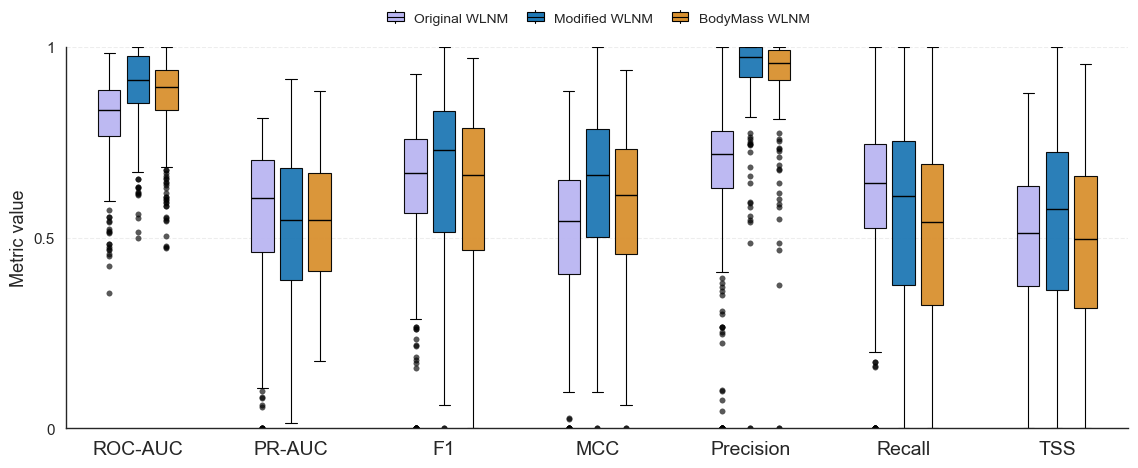

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.1,
)


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    candidates = [start, *start.parents]

    # Fallback for notebooks launched outside the repository.
    fallback = Path(
        "/Users/acw792/Developer/qmul-phd-framework"
    )

    if fallback not in candidates:
        candidates.append(fallback)

    for candidate in candidates:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the qmul-phd-framework repository."
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final configuration
# ============================================================

TRAIN_RATIO_TARGET = 90
CLASSIFICATION_THRESHOLD = 0.50
NODES_THRESHOLD = 0

EXPECTED_RUNS = 100
MINIMUM_RETAINED_FRACTION = 0.25
MINIMUM_RETAINED_RUNS = 25
PROTOCOL_NAME = (
    "tukey_iqr_1p5_min25runs_threshold0p50_v1"
)

assert MINIMUM_RETAINED_RUNS == int(
    np.ceil(
        EXPECTED_RUNS
        * MINIMUM_RETAINED_FRACTION
    )
)


# ============================================================
# Result roots
# ============================================================

ORIGINAL_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_original_100x290_train10-90_"
        "thresh0p50_Apocrita_20260916_221905"
    )
)

DIR_NEG_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_trophicv2_"
        "100x290_train10-90_Apocrita_20260910_011848"
    )
)

BODYMASS_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleormass_trophicv2_"
        "100x290_train10-90_tau1p00_Apocrita_20260918_010757"
    )
)


# ============================================================
# Tukey-filtered figure inputs
# ============================================================

ORIGINAL_INPUT = (
    ORIGINAL_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train90_after_tukey.csv"
)

DIR_NEG_INPUT = (
    DIR_NEG_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train90_after_tukey.csv"
)

BODYMASS_INPUT = (
    BODYMASS_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train90_after_tukey.csv"
)

FOODWEB_CSV = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)


# ============================================================
# Publication output
# ============================================================

OUT_DIR = (
    BODYMASS_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_STEM = (
    "figure_3_original100_vs_roleonly100_vs_roleormass100_"
    "train90_thresh0p50_tukey_min25runs"
)

PNG_PATH = OUT_DIR / f"{OUTPUT_STEM}.png"
SVG_PATH = OUT_DIR / f"{OUTPUT_STEM}.svg"
PDF_PATH = OUT_DIR / f"{OUTPUT_STEM}.pdf"

SUMMARY_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_summary.csv"
)

RETENTION_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_retention_counts.csv"
)

PAIRING_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_pairing_counts.csv"
)


# ============================================================
# Metrics
# ============================================================

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

METRIC_ORDER = [
    metric
    for metric, _ in METRIC_SPECS
]

METRIC_LABELS = dict(METRIC_SPECS)

VERSION_ORDER = [
    "original",
    "dir_neg",
    "bodymass",
]

VERSION_LABELS = {
    "original": "Original WLNM",
    "dir_neg": "Modified WLNM",
    "bodymass": "BodyMass WLNM",
}

VERSION_PALETTE = {
    "original": "#BAB6F2",
    "dir_neg": "#1F78B4",
    "bodymass": "#D8902F",
}

SHOW_WEB_LEVEL_FLIERS = True


# ============================================================
# Validate required inputs
# ============================================================

required_inputs = {
    "Corrected WLNM_original Tukey input": ORIGINAL_INPUT,
    "Final WLNM_dir_neg Tukey input": DIR_NEG_INPUT,
    "Body-mass WLNM_dir_neg Tukey input": BODYMASS_INPUT,
    "Food-web metadata": FOODWEB_CSV,
}

missing_inputs = [
    f"{label}:\n  {path}"
    for label, path in required_inputs.items()
    if not path.is_file()
]

if missing_inputs:
    raise FileNotFoundError(
        "The following required inputs are missing:\n\n"
        + "\n\n".join(missing_inputs)
        + (
            "\n\nThe results must first be processed with "
            "apply_wlnm_tukey_retention.py."
        )
    )

print(f"[INFO] Repository: {REPO_ROOT}")
print("[INFO] Using Tukey-filtered inputs:")
print(f"  Original: {ORIGINAL_INPUT}")
print(f"  Directed-negative: {DIR_NEG_INPUT}")
print(f"  Body-mass: {BODYMASS_INPUT}")


# ============================================================
# Helpers
# ============================================================

def normalize_fw_label(name):
    name = str(name).strip()

    for suffix in [
        ".mat",
        ".csv",
    ]:
        if name.endswith(suffix):
            name = name[: -len(suffix)]

    name = name.replace(" ", "_")

    for token in [
        "_results_",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(token, "_")

    return "_".join(
        part
        for part in name.split("_")
        if part
    ).lower()


def load_tukey_figure_input(
    path,
    version,
    expected_runs,
    minimum_retained_runs,
):
    df = pd.read_csv(path)

    required_columns = {
        "Foodweb",
        "Metric",
        "MetricFamily",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "ExpectedRuns",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
        "TrainRatio",
        "Threshold",
    }

    missing_columns = required_columns.difference(
        df.columns
    )

    if missing_columns:
        raise ValueError(
            f"{path.name} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    numeric_columns = [
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "ExpectedRuns",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
        "TrainRatio",
        "Threshold",
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

    # --------------------------------------------------------
    # Validate the Tukey preprocessing configuration
    # --------------------------------------------------------

    target_rows = df[
        df["Metric"].isin(METRIC_ORDER)
        & df["MetricFamily"].eq("predictive")
        & np.isclose(
            df["TrainRatio"],
            TRAIN_RATIO_TARGET,
            atol=1e-8,
            equal_nan=False,
        )
        & np.isclose(
            df["Threshold"],
            CLASSIFICATION_THRESHOLD,
            atol=1e-9,
            equal_nan=False,
        )
    ].copy()

    if target_rows.empty:
        raise ValueError(
            f"No predictive rows for train ratio "
            f"{TRAIN_RATIO_TARGET} and threshold "
            f"{CLASSIFICATION_THRESHOLD} were found in:\n{path}"
        )

    observed_expected_runs = set(
        target_rows["ExpectedRuns"]
        .dropna()
        .astype(int)
        .unique()
    )

    if observed_expected_runs != {expected_runs}:
        raise ValueError(
            f"{path.name} does not contain the expected "
            f"{expected_runs} runs. Found: "
            f"{sorted(observed_expected_runs)}"
        )

    observed_minimums = set(
        target_rows["MinimumRetainedRuns"]
        .dropna()
        .astype(int)
        .unique()
    )

    if observed_minimums != {
        minimum_retained_runs
    }:
        raise ValueError(
            f"{path.name} was not processed with the "
            f"expected minimum of "
            f"{minimum_retained_runs} retained runs. "
            f"Found: {sorted(observed_minimums)}"
        )

    invalid_minimum_rows = target_rows[
        target_rows["MeetsMinimumRetainedRuns"].eq(1)
        & target_rows["RetainedRunsAfterTukey"].lt(
            minimum_retained_runs
        )
    ]

    if not invalid_minimum_rows.empty:
        display(
            invalid_minimum_rows[
                [
                    "Foodweb",
                    "Metric",
                    "RetainedRunsAfterTukey",
                    "MinimumRetainedRuns",
                    "MeetsMinimumRetainedRuns",
                ]
            ]
        )

        raise ValueError(
            f"{path.name} marks groups with fewer than "
            f"{minimum_retained_runs} runs as retained."
        )

    # --------------------------------------------------------
    # Keep valid Tukey-filtered food-web metric summaries
    # --------------------------------------------------------

    df = target_rows[
        target_rows["MinimumRetainedRuns"].eq(
            minimum_retained_runs
        )
        & target_rows["RetainedRunsAfterTukey"].ge(
            minimum_retained_runs
        )
        & target_rows["MeetsMinimumRetainedRuns"].eq(1)
        & target_rows["MeanAfterTukey"].notna()
    ].copy()

    if df.empty:
        raise ValueError(
            f"No valid Tukey-filtered rows remain in:\n{path}"
        )

    df["Version"] = version
    df["Value"] = df["MeanAfterTukey"]

    df["FW_KEY"] = (
        df["Foodweb"]
        .apply(normalize_fw_label)
    )

    duplicate_mask = df.duplicated(
        subset=[
            "FW_KEY",
            "Version",
            "Metric",
        ],
        keep=False,
    )

    if duplicate_mask.any():
        duplicated = (
            df.loc[
                duplicate_mask,
                [
                    "Foodweb",
                    "Version",
                    "Metric",
                ],
            ]
            .sort_values(
                [
                    "Metric",
                    "Foodweb",
                ]
            )
        )

        display(duplicated)

        raise ValueError(
            f"Duplicated foodweb–metric rows found in:\n{path}"
        )

    minimum_observed = int(
        df["RetainedRunsAfterTukey"].min()
    )

    maximum_observed = int(
        df["RetainedRunsAfterTukey"].max()
    )

    print(
        f"[INFO] {version}: Tukey requirement validated "
        f"(at least {minimum_retained_runs}/"
        f"{expected_runs} runs)."
    )

    print(
        f"       Actual retained-run range: "
        f"{minimum_observed}–{maximum_observed}"
    )

    print(
        f"       Retained food webs: "
        f"{df['FW_KEY'].nunique()}"
    )

    return df


# ============================================================
# Load final Tukey-filtered values
# ============================================================

original_df = load_tukey_figure_input(
    ORIGINAL_INPUT,
    version="original",
    expected_runs=EXPECTED_RUNS,
    minimum_retained_runs=MINIMUM_RETAINED_RUNS,
)

dir_neg_df = load_tukey_figure_input(
    DIR_NEG_INPUT,
    version="dir_neg",
    expected_runs=EXPECTED_RUNS,
    minimum_retained_runs=MINIMUM_RETAINED_RUNS,
)

bodymass_df = load_tukey_figure_input(
    BODYMASS_INPUT,
    version="bodymass",
    expected_runs=EXPECTED_RUNS,
    minimum_retained_runs=MINIMUM_RETAINED_RUNS,
)

combined_df = pd.concat(
    [
        original_df,
        dir_neg_df,
        bodymass_df,
    ],
    ignore_index=True,
)


# ============================================================
# Apply node-count filter
# ============================================================

metadata_df = pd.read_csv(
    FOODWEB_CSV
)

metadata_df.columns = [
    column.strip()
    for column in metadata_df.columns
]

foodweb_column = next(
    (
        column
        for column in metadata_df.columns
        if column.lower() == "foodweb"
    ),
    None,
)

nodes_column = next(
    (
        column
        for column in metadata_df.columns
        if column.lower() in {
            "nodes",
            "n_nodes",
            "num_nodes",
            "nodecount",
            "s",
        }
    ),
    None,
)

if (
    foodweb_column is None
    or nodes_column is None
):
    raise ValueError(
        "Could not identify Foodweb and Nodes "
        "columns in the metadata file."
    )

metadata_df[nodes_column] = pd.to_numeric(
    metadata_df[nodes_column],
    errors="coerce",
)

metadata_df["FW_KEY"] = (
    metadata_df[foodweb_column]
    .apply(normalize_fw_label)
)

metadata_df = (
    metadata_df[
        [
            "FW_KEY",
            foodweb_column,
            nodes_column,
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"]
    )
)

allowed_fw_keys = set(
    metadata_df.loc[
        metadata_df[nodes_column]
        >= NODES_THRESHOLD,
        "FW_KEY",
    ]
)

print(
    f"[INFO] Food webs satisfying "
    f"Nodes >= {NODES_THRESHOLD}: "
    f"{len(allowed_fw_keys)}"
)

combined_df = combined_df[
    combined_df["FW_KEY"]
    .isin(allowed_fw_keys)
].copy()

if combined_df.empty:
    raise RuntimeError(
        "No retained food-web metrics remain "
        "after the node-count filter."
    )


# ============================================================
# Enforce three-way paired food webs separately per metric
# ============================================================

paired_frames = []
pairing_rows = []

for metric in METRIC_ORDER:
    metric_df = combined_df[
        combined_df["Metric"].eq(metric)
    ].copy()

    version_keys = {
        version: set(
            metric_df.loc[
                metric_df["Version"].eq(version),
                "FW_KEY",
            ]
        )
        for version in VERSION_ORDER
    }

    common_keys = set.intersection(
        *(version_keys[version] for version in VERSION_ORDER)
    )

    if not common_keys:
        raise RuntimeError(
            f"No three-way paired food webs remain for {metric}."
        )

    pairing_row = {
        "Metric": METRIC_LABELS[metric],
    }

    for version in VERSION_ORDER:
        label = VERSION_LABELS[version]
        pairing_row[f"{label} retained food webs"] = len(
            version_keys[version]
        )

    pairing_row["Three-way paired food webs"] = len(
        common_keys
    )

    for version in VERSION_ORDER:
        label = VERSION_LABELS[version]
        pairing_row[f"{label} not shared by all versions"] = len(
            version_keys[version] - common_keys
        )

    pairing_rows.append(pairing_row)

    paired_metric_df = metric_df[
        metric_df["FW_KEY"].isin(
            common_keys
        )
    ].copy()

    paired_frames.append(
        paired_metric_df
    )

plot_df = pd.concat(
    paired_frames,
    ignore_index=True,
)

if plot_df.empty:
    raise RuntimeError(
        "No three-way paired food webs remain for plotting."
    )

pairing_table = pd.DataFrame(
    pairing_rows
)

print(
    "\n=== Retained and paired food webs "
    "by metric ==="
)

display(pairing_table)


# ============================================================
# Retention details
# ============================================================

retention_table = (
    plot_df
    .groupby(
        [
            "Version",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        MinimumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetainedRuns=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "max",
        ),
    )
)

retention_table["Version"] = (
    retention_table["Version"]
    .map(VERSION_LABELS)
)

retention_table["Metric"] = (
    retention_table["Metric"]
    .map(METRIC_LABELS)
)

retention_table = retention_table[
    [
        "Version",
        "Metric",
        "FoodWebs",
        "MinimumRetainedRuns",
        "MedianRetainedRuns",
        "MaximumRetainedRuns",
    ]
]

print(
    "\n=== Tukey retention details "
    "for paired food webs ==="
)

display(retention_table)


# ============================================================
# Web-level summary
# ============================================================

summary_table = (
    plot_df
    .groupby(
        [
            "Version",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        Mean=(
            "Value",
            "mean",
        ),
        Median=(
            "Value",
            "median",
        ),
        SD=(
            "Value",
            "std",
        ),
        Variance=(
            "Value",
            "var",
        ),
    )
)

summary_table["Version"] = (
    summary_table["Version"]
    .map(VERSION_LABELS)
)

summary_table["Metric"] = (
    summary_table["Metric"]
    .map(METRIC_LABELS)
)

for column in [
    "Mean",
    "Median",
    "SD",
    "Variance",
]:
    summary_table[column] = (
        summary_table[column]
        .round(4)
    )

print(
    "\n=== Tukey-filtered web-level "
    "predictive metric summary ==="
)

display(summary_table)


# ============================================================
# Custom miniature boxplot legend
# ============================================================

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle["facecolor"]

        edgecolor = orig_handle.get(
            "edgecolor",
            "black",
        )

        linewidth = orig_handle.get(
            "linewidth",
            0.6,
        )

        center_x = (
            xdescent
            + 0.5 * width
        )

        center_y = (
            ydescent
            + 0.44 * height
        )

        box_width = (
            0.8 * width
        )

        box_height = (
            0.8 * height
        )

        box_x = (
            center_x
            - box_width / 2
        )

        box_y = (
            center_y
            - box_height / 2
        )

        whisker_top_y = (
            box_y
            + box_height
            + 0.18 * height
        )

        whisker_bottom_y = (
            box_y
            - 0.18 * height
        )

        box = Rectangle(
            (
                box_x,
                box_y,
            ),
            box_width,
            box_height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [
                box_x,
                box_x + box_width,
            ],
            [
                center_y,
                center_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        upper_whisker = Line2D(
            [
                center_x,
                center_x,
            ],
            [
                box_y + box_height,
                whisker_top_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        lower_whisker = Line2D(
            [
                center_x,
                center_x,
            ],
            [
                whisker_bottom_y,
                box_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [
            box,
            median,
            upper_whisker,
            lower_whisker,
        ]


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(11.5, 4.8)
)

group_gap = 1.5

group_centers = (
    1.0
    + np.arange(
        len(METRIC_SPECS)
    )
    * group_gap
)

offsets = {
    "original": -0.28,
    "dir_neg": 0.00,
    "bodymass": 0.28,
}

box_width = 0.22

for version in VERSION_ORDER:
    version_data = []
    version_positions = []

    for metric_index, (
        metric,
        metric_label,
    ) in enumerate(METRIC_SPECS):
        values = (
            plot_df.loc[
                (
                    plot_df["Version"].eq(
                        version
                    )
                )
                & (
                    plot_df["Metric"].eq(
                        metric
                    )
                ),
                "Value",
            ]
            .dropna()
            .to_numpy()
        )

        if len(values) == 0:
            continue

        version_data.append(
            values
        )

        version_positions.append(
            group_centers[metric_index]
            + offsets[version]
        )

    if not version_data:
        raise RuntimeError(
            f"No plotting values found for version: {version}"
        )

    ax.boxplot(
        version_data,
        positions=version_positions,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        boxprops={
            "facecolor": VERSION_PALETTE[version],
            "edgecolor": "black",
            "linewidth": 0.8,
            "alpha": 0.95,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.0,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.2,
            "alpha": 0.65,
        },
    )


# ============================================================
# Axes and legend
# ============================================================

legend_handles = [
    {
        "facecolor": VERSION_PALETTE[version],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for version in VERSION_ORDER
]

ax.set_xlim(
    group_centers[0] - 0.7,
    group_centers[-1] + 0.7,
)

ax.set_ylim(
    0,
    1.0,
)

ax.set_xticks(
    group_centers,
    labels=[
        metric_label
        for _, metric_label in METRIC_SPECS
    ],
)

plt.setp(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=14,
)

ax.set_ylabel(
    "Metric value",
    fontsize=13,
)

ax.set_xlabel("")

ax.set_yticks(
    [
        0,
        0.5,
        1.0,
    ]
)

ax.set_yticklabels(
    [
        "0",
        "0.5",
        "1",
    ]
)

ax.tick_params(
    axis="y",
    labelsize=11,
)

ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.35,
)

ax.legend(
    handles=legend_handles,
    labels=[
        VERSION_LABELS[version]
        for version in VERSION_ORDER
    ],
    handler_map={
        dict: HandlerMiniBoxplot()
    },
    loc="lower center",
    bbox_to_anchor=(
        0.5,
        1.03,
    ),
    ncol=len(VERSION_ORDER),
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
    columnspacing=1.2,
)

sns.despine(
    ax=ax
)

plt.tight_layout()


# ============================================================
# Export
# ============================================================

fig.savefig(
    PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    SVG_PATH,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)

summary_table.to_csv(
    SUMMARY_PATH,
    index=False,
)

retention_table.to_csv(
    RETENTION_PATH,
    index=False,
)

pairing_table.to_csv(
    PAIRING_PATH,
    index=False,
)

print(
    "\n[INFO] Saved publication-ready outputs:"
)

print(f"  PNG: {PNG_PATH}")
print(f"  SVG: {SVG_PATH}")
print(f"  PDF: {PDF_PATH}")
print(f"  Summary: {SUMMARY_PATH}")
print(f"  Retention counts: {RETENTION_PATH}")
print(f"  Pairing counts: {PAIRING_PATH}")

print(
    "\n[INFO] Final comparison configuration:"
)

print(
    f"  classification_threshold="
    f"{CLASSIFICATION_THRESHOLD}"
)

print(
    f"  retention_protocol={PROTOCOL_NAME}"
)

print(
    "\n[INFO] Final retention configurations:"
)

for version in VERSION_ORDER:
    print(
        f"  {VERSION_LABELS[version]}: "
        f"{MINIMUM_RETAINED_RUNS}/{EXPECTED_RUNS}, "
        f"protocol={PROTOCOL_NAME}"
    )

print(
    "  BodyMass WLNM eligibility=role_or_mass, "
    "mass_threshold=1.0"
)

plt.show()

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import rankdata, wilcoxon


# ============================================================
# Figure 5: paired ecological-property tests by ecosystem
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    candidates = [start, *start.parents]
    fallback = Path(
        "/Users/acw792/Developer/qmul-phd-framework"
    )

    if fallback not in candidates:
        candidates.append(fallback)

    for candidate in candidates:
        if (candidate / "src/matlab").is_dir():
            return candidate

    raise RuntimeError(
        "Could not locate the repository root."
    )


REPO_ROOT = find_repo_root()

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_trophicv2_"
        "100x290_train10-90_Apocrita_20260910_011848"
    )
)

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min25runs_threshold0p50_v1"
)

PAIRS_FILE = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "statistical_tests"
    / (
        "figure_5_wilcoxon_train60_roleonly_trophicv2_"
        "100runs_threshold0p50_after_tukey_min25runs_pairs.csv"
    )
)

ECOSYSTEM_ORDER = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ECOSYSTEM_LABELS = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial aboveground",
    "terrestrial belowground": "Terrestrial belowground",
}

METRIC_ORDER = [
    "Connectance",
    "MeanTrophicHeight",
    "MeanGenerality",
    "MeanVulnerability",
]

METRIC_LABELS = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
}

EXPECTED_FOODWEBS = {
    "lakes": 55,
    "streams": 28,
    "marine": 134,
    "terrestrial aboveground": 21,
    "terrestrial belowground": 52,
}

ALPHA = 0.05


def holm_adjust(p_values):
    """Return Holm-adjusted p-values in the original order."""
    p_values = np.asarray(p_values, dtype=float)
    number_of_tests = p_values.size
    order = np.argsort(p_values)
    ordered_p = p_values[order]

    ordered_adjusted = np.maximum.accumulate(
        (number_of_tests - np.arange(number_of_tests))
        * ordered_p
    )
    ordered_adjusted = np.minimum(ordered_adjusted, 1.0)

    adjusted = np.empty(number_of_tests, dtype=float)
    adjusted[order] = ordered_adjusted
    return adjusted


def rank_biserial_from_differences(differences):
    """Rank-biserial effect size for pseudo minus empirical."""
    differences = np.asarray(differences, dtype=float)
    nonzero = differences[~np.isclose(differences, 0.0)]

    if nonzero.size == 0:
        return 0.0, 0.0, 0.0

    ranks = rankdata(np.abs(nonzero), method="average")
    positive_rank_sum = float(ranks[nonzero > 0].sum())
    negative_rank_sum = float(ranks[nonzero < 0].sum())
    total_rank_sum = positive_rank_sum + negative_rank_sum

    rank_biserial = (
        (positive_rank_sum - negative_rank_sum)
        / total_rank_sum
    )

    return (
        rank_biserial,
        positive_rank_sum,
        negative_rank_sum,
    )


if not PAIRS_FILE.is_file():
    raise FileNotFoundError(PAIRS_FILE)

pairs = pd.read_csv(PAIRS_FILE)

required_columns = {
    "FoodWeb",
    "Ecosystem",
    "Metric",
    "EmpiricalValue",
    "MeanPseudoAfterFiltering",
}

missing_columns = required_columns.difference(pairs.columns)
if missing_columns:
    raise KeyError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

pairs = pairs.loc[
    pairs["Ecosystem"].isin(ECOSYSTEM_ORDER)
    & pairs["Metric"].isin(METRIC_ORDER)
].copy()

pairs["Difference"] = (
    pairs["MeanPseudoAfterFiltering"]
    - pairs["EmpiricalValue"]
)

if pairs.duplicated(
    subset=["FoodWeb", "Ecosystem", "Metric"]
).any():
    raise RuntimeError(
        "Duplicated food-web, ecosystem, and metric pairs found."
    )

result_rows = []

for ecosystem in ECOSYSTEM_ORDER:
    for metric in METRIC_ORDER:
        group = pairs.loc[
            pairs["Ecosystem"].eq(ecosystem)
            & pairs["Metric"].eq(metric)
        ].copy()

        expected_n = EXPECTED_FOODWEBS[ecosystem]
        if len(group) != expected_n:
            raise RuntimeError(
                f"{ecosystem}, {metric}: expected {expected_n} "
                f"paired food webs, found {len(group)}."
            )

        differences = group["Difference"].to_numpy(dtype=float)
        nonzero_count = int(
            (~np.isclose(differences, 0.0)).sum()
        )

        if nonzero_count == 0:
            statistic = 0.0
            p_value = 1.0
        else:
            test = wilcoxon(
                differences,
                zero_method="wilcox",
                correction=False,
                alternative="two-sided",
                method="auto",
            )
            statistic = float(test.statistic)
            p_value = float(test.pvalue)

        (
            rank_biserial,
            positive_rank_sum,
            negative_rank_sum,
        ) = rank_biserial_from_differences(differences)

        result_rows.append(
            {
                "Ecosystem": ecosystem,
                "EcosystemLabel": ECOSYSTEM_LABELS[ecosystem],
                "Metric": metric,
                "MetricLabel": METRIC_LABELS[metric],
                "NPairs": int(len(group)),
                "NNonzeroDifferences": nonzero_count,
                "MedianEmpirical": float(
                    group["EmpiricalValue"].median()
                ),
                "MedianPseudo": float(
                    group["MeanPseudoAfterFiltering"].median()
                ),
                "MeanDifference": float(differences.mean()),
                "MedianDifference": float(np.median(differences)),
                "WilcoxonStatistic": statistic,
                "PositiveRankSum": positive_rank_sum,
                "NegativeRankSum": negative_rank_sum,
                "RankBiserialCorrelation": rank_biserial,
                "PValueRaw": p_value,
            }
        )

ecosystem_results = pd.DataFrame(result_rows)

# Family 1: the four ecological-property tests within each ecosystem.
ecosystem_results["PValueHolmWithinEcosystem"] = (
    ecosystem_results
    .groupby("Ecosystem", sort=False)["PValueRaw"]
    .transform(holm_adjust)
)

# Family 2: conservative sensitivity correction across all 20 tests.
ecosystem_results["PValueHolmAll20"] = holm_adjust(
    ecosystem_results["PValueRaw"].to_numpy()
)

ecosystem_results["RejectHolmWithinEcosystem"] = (
    ecosystem_results["PValueHolmWithinEcosystem"] < ALPHA
)
ecosystem_results["RejectHolmAll20"] = (
    ecosystem_results["PValueHolmAll20"] < ALPHA
)

display_columns = [
    "EcosystemLabel",
    "MetricLabel",
    "NPairs",
    "MedianEmpirical",
    "MedianPseudo",
    "MedianDifference",
    "RankBiserialCorrelation",
    "PValueRaw",
    "PValueHolmWithinEcosystem",
    "PValueHolmAll20",
    "RejectHolmWithinEcosystem",
    "RejectHolmAll20",
]

print("[INFO] Figure 5 paired tests by ecosystem")
print(f"[INFO] Source: {PAIRS_FILE}")
print("[INFO] Difference = mean pseudo after Tukey - empirical")
print("[INFO] Negative values indicate underestimation by pseudo-webs.")

results_for_display = ecosystem_results[display_columns].copy()

for column in [
    "MedianEmpirical",
    "MedianPseudo",
    "MedianDifference",
    "RankBiserialCorrelation",
]:
    results_for_display[column] = (
        results_for_display[column].map(lambda value: f"{value:.6f}")
    )

for column in [
    "PValueRaw",
    "PValueHolmWithinEcosystem",
    "PValueHolmAll20",
]:
    results_for_display[column] = (
        results_for_display[column].map(lambda value: f"{value:.3e}")
    )

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", 220,
):
    display(
        results_for_display
    )

within_count = int(
    ecosystem_results["RejectHolmWithinEcosystem"].sum()
)
all20_count = int(
    ecosystem_results["RejectHolmAll20"].sum()
)

print(
    f"\n[SUMMARY] Significant after Holm within each ecosystem: "
    f"{within_count}/20 comparisons."
)
print(
    f"[SUMMARY] Significant after Holm across all 20 tests: "
    f"{all20_count}/20 comparisons."
)

print("\n[SUMMARY] Non-significant results after within-ecosystem Holm:")
display(
    ecosystem_results.loc[
        ~ecosystem_results["RejectHolmWithinEcosystem"],
        [
            "EcosystemLabel",
            "MetricLabel",
            "NPairs",
            "MedianDifference",
            "RankBiserialCorrelation",
            "PValueHolmWithinEcosystem",
        ],
    ].round(6)
)

print("\n[NOTE] Difference tests do not establish ecological equivalence.")
print(
    "Equivalence requires pre-specified ecological margins and an "
    "equivalence analysis such as TOST."
)


[INFO] Figure 5 paired tests by ecosystem
[INFO] Source: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/statistical_tests/figure_5_wilcoxon_train60_roleonly_trophicv2_100runs_threshold0p50_after_tukey_min25runs_pairs.csv
[INFO] Difference = mean pseudo after Tukey - empirical
[INFO] Negative values indicate underestimation by pseudo-webs.


,EcosystemLabel,MetricLabel,NPairs,MedianEmpirical,MedianPseudo,MedianDifference,RankBiserialCorrelation,PValueRaw,PValueHolmWithinEcosystem,PValueHolmAll20,RejectHolmWithinEcosystem,RejectHolmAll20
0,Lakes,Connectance,55,0.099279,0.088060,-0.009805,-1.000000,1.108e-10,4.430e-10,1.883e-09,True,True
1,Lakes,Mean trophic height,55,1.673525,1.684043,0.016424,0.497403,1.332e-03,1.332e-03,3.996e-03,True,True
2,Lakes,Mean generality,55,7.105263,6.518168,-0.408539,-0.787013,3.826e-07,7.653e-07,3.061e-06,True,True
3,Lakes,Mean vulnerability,55,4.150000,3.718585,-0.121419,-0.894805,7.796e-09,2.339e-08,9.686e-08,True,True
4,Streams,Connectance,28,0.177579,0.133397,-0.022266,-1.000000,7.451e-09,2.980e-08,9.686e-08,True,True
5,Streams,Mean trophic height,28,1.658064,1.694284,0.007699,0.433498,4.512e-02,4.512e-02,9.024e-02,True,False
6,Streams,Mean generality,28,13.986111,10.531952,-3.846225,-1.000000,7.451e-09,2.980e-08,9.686e-08,True,True
7,Streams,Mean vulnerability,28,7.614778,6.126329,-1.639325,-0.975369,7.451e-08,1.490e-07,6.706e-07,True,True
8,Marine,Connectance,134,0.151597,0.133554,-0.014936,-1.000000,9.804e-24,3.922e-23,1.961e-22,True,True
9,Marine,Mean trophic height,134,1.991020,1.947089,0.000277,0.100498,3.128e-01,3.128e-01,3.128e-01,False,False



[SUMMARY] Significant after Holm within each ecosystem: 19/20 comparisons.
[SUMMARY] Significant after Holm across all 20 tests: 18/20 comparisons.

[SUMMARY] Non-significant results after within-ecosystem Holm:


,EcosystemLabel,MetricLabel,NPairs,MedianDifference,RankBiserialCorrelation,PValueHolmWithinEcosystem
9,Marine,Mean trophic height,134,0.000277,0.100498,0.312804



[NOTE] Difference tests do not establish ecological equivalence.
Equivalence requires pre-specified ecological margins and an equivalence analysis such as TOST.


In [1]:
# ============================================================
# Athen/Dave analysis: empirical vs inferred food-web properties
# Data preparation shared by the four plotting cells below
# ============================================================
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

sns.set_theme(context="paper", style="white", font_scale=1.15)


def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    candidates = [start, *start.parents]
    fallback = Path("/Users/acw792/Developer/qmul-phd-framework")
    if fallback not in candidates:
        candidates.append(fallback)

    for candidate in candidates:
        if (candidate / "src/matlab").is_dir() and (candidate / "docs").is_dir():
            return candidate

    raise RuntimeError("Could not locate the repository root.")


REPO_ROOT = find_repo_root()
RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_trophicv2_"
        "100x290_train10-90_Apocrita_20260910_011848"
    )
)
PROTOCOL_NAME = "tukey_iqr_1p5_min25runs_threshold0p50_v1"
PAIRS_FILE = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "statistical_tests"
    / (
        "figure_5_wilcoxon_train60_roleonly_trophicv2_"
        "100runs_threshold0p50_after_tukey_min25runs_pairs.csv"
    )
)
FIGURE_DIR = REPO_ROOT / "docs/progress_notebooks_logs/2026/figures/week-38"
SAVE_FIGURES = False

ECOSYSTEM_ORDER = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]
ECOSYSTEM_LABELS = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial aboveground",
    "terrestrial belowground": "Terrestrial belowground",
}
EXPECTED_FOODWEBS = {
    "lakes": 55,
    "streams": 28,
    "marine": 134,
    "terrestrial aboveground": 21,
    "terrestrial belowground": 52,
}
METRIC_ORDER = [
    "Connectance",
    "MeanTrophicHeight",
    "MeanGenerality",
    "MeanVulnerability",
]
METRIC_LABELS = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
}
ECOSYSTEM_PALETTE = {
    "lakes": "#00A6D6",
    "streams": "#006D2C",
    "marine": "#08306B",
    "terrestrial aboveground": "#7AC943",
    "terrestrial belowground": "#6B3A19",
}
ECOSYSTEM_MARKERS = {
    "lakes": "o",
    "streams": "s",
    "marine": "D",
    "terrestrial aboveground": "^",
    "terrestrial belowground": "v",
}
INFERRED_COLOR = "#C6923A"
PANEL_LETTERS = list("abcdefghijklmnopqrstuvwxyz")

if not PAIRS_FILE.is_file():
    raise FileNotFoundError(PAIRS_FILE)

property_pairs = pd.read_csv(PAIRS_FILE)
required_columns = {
    "FoodWeb",
    "Ecosystem",
    "Metric",
    "EmpiricalValue",
    "MeanPseudoAfterFiltering",
    "ValidRunsAfterFiltering",
}
missing_columns = required_columns.difference(property_pairs.columns)
if missing_columns:
    raise KeyError(f"Missing required columns: {sorted(missing_columns)}")

property_pairs = property_pairs.loc[
    property_pairs["Ecosystem"].isin(ECOSYSTEM_ORDER)
    & property_pairs["Metric"].isin(METRIC_ORDER)
].copy()

numeric_columns = [
    "EmpiricalValue",
    "MeanPseudoAfterFiltering",
    "ValidRunsAfterFiltering",
]
for column in numeric_columns:
    property_pairs[column] = pd.to_numeric(property_pairs[column], errors="coerce")

if property_pairs.duplicated(["FoodWeb", "Ecosystem", "Metric"]).any():
    raise RuntimeError("Duplicated food-web/ecosystem/metric pairs were found.")

if not np.isfinite(property_pairs[numeric_columns].to_numpy(dtype=float)).all():
    raise RuntimeError("Non-finite values were found in the plotting input.")

if (property_pairs["EmpiricalValue"] <= 0).any():
    raise RuntimeError("Relative error requires strictly positive empirical values.")

if (property_pairs["ValidRunsAfterFiltering"] < 25).any():
    raise RuntimeError("At least one pair retained fewer than 25 runs.")

for metric in METRIC_ORDER:
    metric_data = property_pairs.loc[property_pairs["Metric"].eq(metric)]
    if metric_data["FoodWeb"].nunique() != 290:
        raise RuntimeError(
            f"{metric}: expected 290 food webs, found "
            f"{metric_data['FoodWeb'].nunique()}."
        )

observed_counts = (
    property_pairs.groupby(["Ecosystem", "Metric"], observed=False)
    .size()
)
for ecosystem in ECOSYSTEM_ORDER:
    for metric in METRIC_ORDER:
        observed = int(observed_counts.get((ecosystem, metric), 0))
        expected = EXPECTED_FOODWEBS[ecosystem]
        if observed != expected:
            raise RuntimeError(
                f"{ecosystem}, {metric}: expected {expected}, found {observed}."
            )

property_pairs["RelativeError"] = (
    property_pairs["MeanPseudoAfterFiltering"]
    - property_pairs["EmpiricalValue"]
) / property_pairs["EmpiricalValue"]
property_pairs["RelativeErrorPercent"] = 100 * property_pairs["RelativeError"]
property_pairs["MetricLabel"] = property_pairs["Metric"].map(METRIC_LABELS)
property_pairs["EcosystemLabel"] = property_pairs["Ecosystem"].map(ECOSYSTEM_LABELS)


def identity_limits(data, pad_fraction=0.06):
    values = np.concatenate(
        [
            data["EmpiricalValue"].to_numpy(dtype=float),
            data["MeanPseudoAfterFiltering"].to_numpy(dtype=float),
        ]
    )
    lower = float(np.nanmin(values))
    upper = float(np.nanmax(values))
    span = upper - lower
    if np.isclose(span, 0):
        span = max(abs(lower), 1.0) * 0.10
    padding = pad_fraction * span
    return lower - padding, upper + padding


def style_publication_axis(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")
    ax.tick_params(axis="both", colors="#333333", labelsize=13)


def add_panel_label(ax, letter):
    ax.text(
        -0.08, 1.03, letter,
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )


def add_identity_line(ax, limits):
    ax.plot(limits, limits, color="0.25", linestyle="--", linewidth=1.0, zorder=1)
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.set_aspect("equal", adjustable="box")
    style_publication_axis(ax)


def finish_figure(fig, filename):
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        output_path = FIGURE_DIR / filename
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"[SAVED] {output_path}")
    plt.show()


validation_summary = (
    property_pairs.groupby(["EcosystemLabel", "MetricLabel"], observed=False)
    .agg(
        FoodWebs=("FoodWeb", "nunique"),
        MinimumRetainedRuns=("ValidRunsAfterFiltering", "min"),
        MedianRelativeErrorPercent=("RelativeErrorPercent", "median"),
    )
    .reset_index()
)

print(f"[INFO] Source: {PAIRS_FILE}")
print("[INFO] Train ratio: 60%; 100 runs before Tukey filtering.")
print("[INFO] Relative error = (mean inferred - empirical) / empirical.")
print(f"[INFO] Validated rows: {len(property_pairs):,} = 290 food webs x 4 metrics.")
display(validation_summary)


[INFO] Source: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/tukey_iqr_1p5_min25runs_threshold0p50_v1/statistical_tests/figure_5_wilcoxon_train60_roleonly_trophicv2_100runs_threshold0p50_after_tukey_min25runs_pairs.csv
[INFO] Train ratio: 60%; 100 runs before Tukey filtering.
[INFO] Relative error = (mean inferred - empirical) / empirical.
[INFO] Validated rows: 1,160 = 290 food webs x 4 metrics.


,EcosystemLabel,MetricLabel,FoodWebs,MinimumRetainedRuns,MedianRelativeErrorPercent
0,Lakes,Connectance,55,87,-8.131952
1,Lakes,Mean generality,55,85,-6.285111
2,Lakes,Mean trophic height,55,56,1.032652
3,Lakes,Mean vulnerability,55,87,-4.339918
4,Marine,Connectance,134,91,-10.360458
5,Marine,Mean generality,134,83,-7.803707
6,Marine,Mean trophic height,134,42,0.012866
7,Marine,Mean vulnerability,134,91,-6.650668
8,Streams,Connectance,28,83,-26.665248
9,Streams,Mean generality,28,80,-26.792761


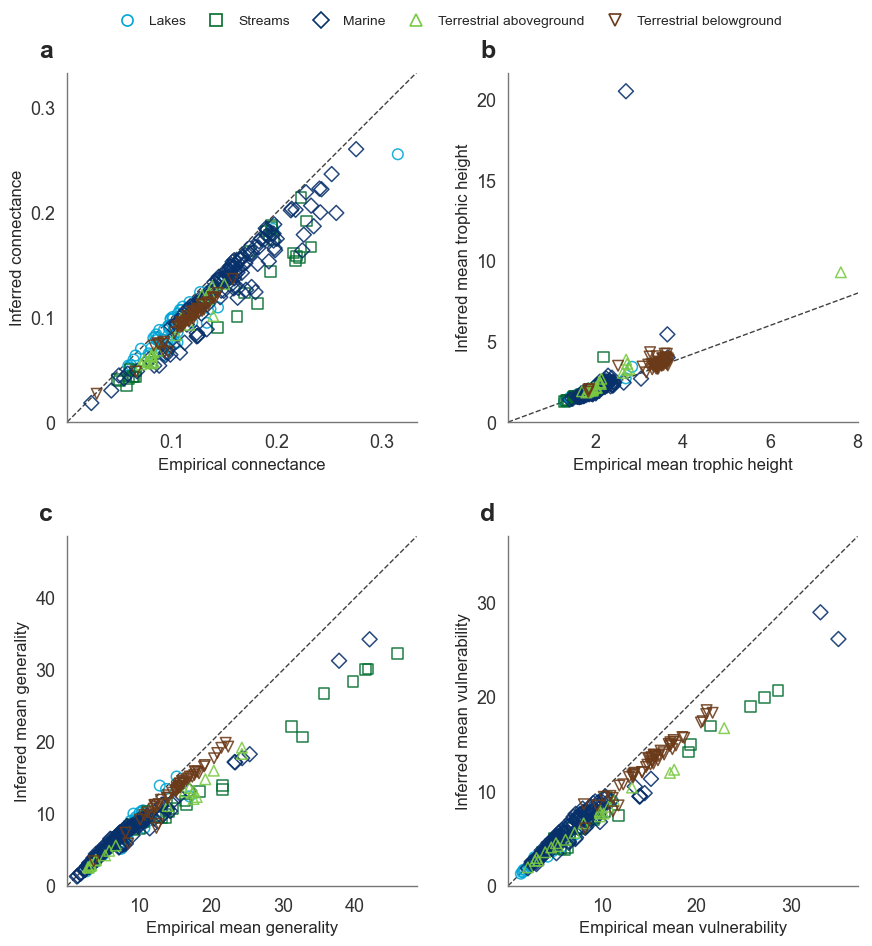

In [2]:
# Plot 1: empirical versus mean inferred value across all food webs
# Layout: 2 rows × 2 columns

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11.5, 10.0),
    constrained_layout=False,
)

axes = np.asarray(axes).reshape(-1)

for panel_index, (ax, metric) in enumerate(
    zip(axes, METRIC_ORDER)
):
    metric_data = property_pairs.loc[
        property_pairs["Metric"].eq(metric)
    ]

    limits = identity_limits(metric_data)

    # Give both axes the same range and make them start at zero.
    limits = (0.0, limits[1])

    for ecosystem in ECOSYSTEM_ORDER:
        ecosystem_data = metric_data.loc[
            metric_data["Ecosystem"].eq(ecosystem)
        ]

        ax.scatter(
            ecosystem_data["EmpiricalValue"],
            ecosystem_data["MeanPseudoAfterFiltering"],
            s=58,
            marker=ECOSYSTEM_MARKERS[ecosystem],
            facecolors="none",
            edgecolors=ECOSYSTEM_PALETTE[ecosystem],
            linewidths=1.1,
            alpha=0.88,
            zorder=2,
        )

    add_identity_line(ax, limits)

    # Ensure that x and y share the same origin and range.
    ax.set_xlim(limits)
    ax.set_ylim(limits)

    # Panel B: empirical values do not exceed 10.
    if panel_index == 1:
        ax.set_xlim(0.0, 8.0)

    # Keep every panel physically square, even when its x- and y-ranges differ.
    ax.set_aspect("auto")
    ax.set_box_aspect(1)

    # Hide the x-axis zero label so only one zero is shown
    # at the lower-left corner.
    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda value, position: (
                ""
                if np.isclose(value, 0.0)
                else f"{value:g}"
            )
        )
    )

    # Simplify the y-axis ticks in panels A, B, and D.
    if panel_index == 0:
        ax.set_yticks(
            [0.0, 0.1, 0.2, 0.3],
            labels=["0", "0.1", "0.2", "0.3"],
        )

    elif panel_index == 1:
        ax.set_yticks(
            [0, 5, 10, 15, 20],
            labels=["0", "5", "10", "15", "20"],
        )

    elif panel_index == 3:
        ax.set_yticks(
            [0, 10, 20, 30],
            labels=["0", "10", "20", "30"],
        )

    metric_axis_label = METRIC_LABELS[metric].lower()

    ax.set_xlabel(
        f"Empirical {metric_axis_label}",
        fontsize=12,
    )
    ax.set_ylabel(
        f"Inferred {metric_axis_label}",
        fontsize=12,
    )

    add_panel_label(
        ax,
        PANEL_LETTERS[panel_index],
    )

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=ECOSYSTEM_MARKERS[ecosystem],
        linestyle="none",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor=ECOSYSTEM_PALETTE[ecosystem],
        markeredgewidth=1.2,
        label=ECOSYSTEM_LABELS[ecosystem],
    )
    for ecosystem in ECOSYSTEM_ORDER
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.4, 0.95),
    columnspacing=1.2,
    handletextpad=0.6,
    fontsize=10,
)

fig.tight_layout(
    rect=(0, 0, 0.8, 0.93),
    h_pad=2.0,
    w_pad=1.8,
)

finish_figure(
    fig,
    "empirical_vs_inferred_all_foodwebs.png",
)

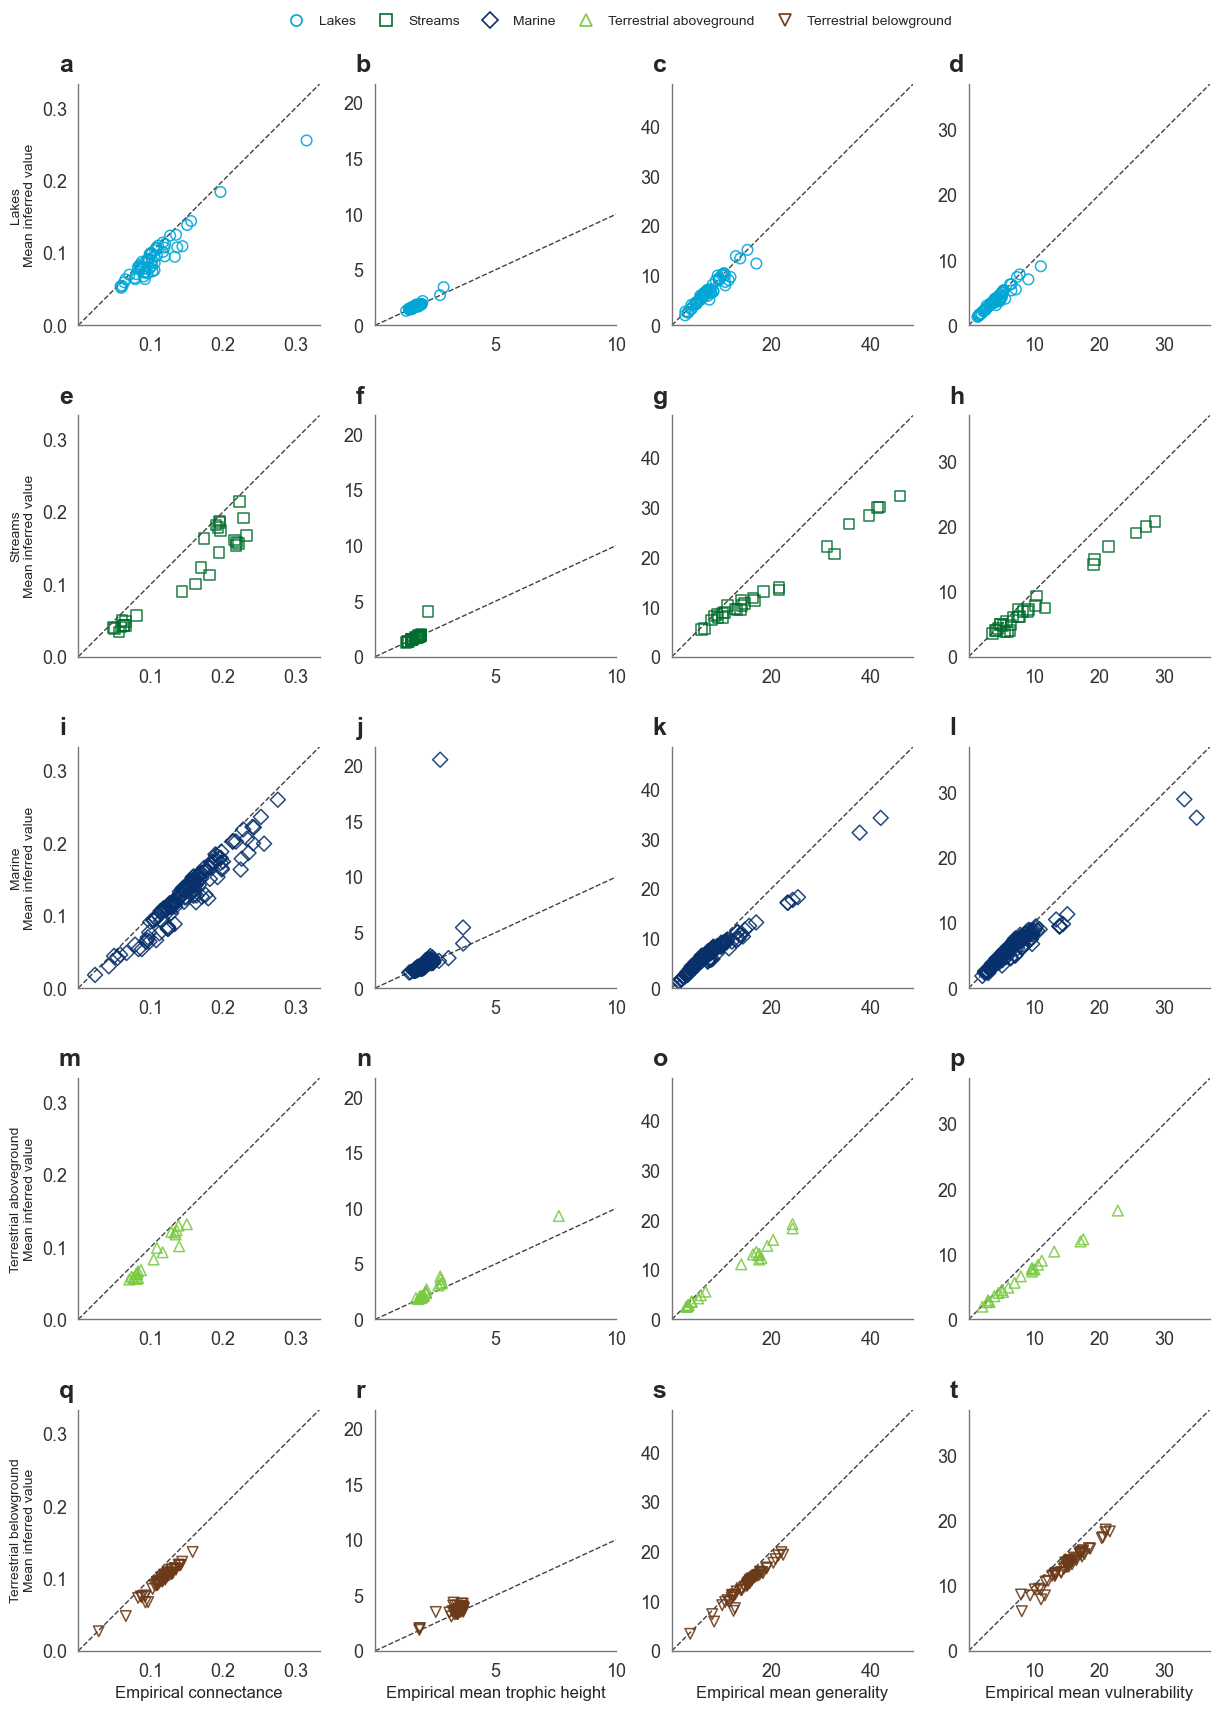

In [3]:
# Plot 2: empirical versus mean inferred value
# for each ecosystem and metric

fig, axes = plt.subplots(
    len(ECOSYSTEM_ORDER),
    len(METRIC_ORDER),
    figsize=(15.5, 17.5),
    squeeze=False,
    sharex=False,
    sharey=False
)

metric_limits = {}

for metric in METRIC_ORDER:
    metric_data = property_pairs.loc[
        property_pairs["Metric"].eq(metric)
    ]

    calculated_limits = identity_limits(metric_data)

    metric_limits[metric] = (
        0.0,
        calculated_limits[1],
    )

for row_index, ecosystem in enumerate(
    ECOSYSTEM_ORDER
):
    for column_index, metric in enumerate(
        METRIC_ORDER
    ):
        ax = axes[row_index, column_index]

        panel_data = property_pairs.loc[
            property_pairs["Ecosystem"].eq(ecosystem)
            & property_pairs["Metric"].eq(metric)
        ]

        ax.scatter(
            panel_data["EmpiricalValue"],
            panel_data["MeanPseudoAfterFiltering"],
            s=58,
            marker=ECOSYSTEM_MARKERS[ecosystem],
            facecolors="none",
            edgecolors=ECOSYSTEM_PALETTE[ecosystem],
            linewidths=1.1,
            alpha=0.88,
            zorder=2,
        )

        add_identity_line(
            ax,
            metric_limits[metric],
        )

        limits = metric_limits[metric]

        # Make both axes start at the same origin.
        ax.set_xlim(limits)
        ax.set_ylim(limits)

        # Panels B, F, J, N, and R.
        if column_index == 1:
            ax.set_xlim(0.0, 10.0)
            ax.set_xticks([0, 5, 10])

            ax.set_yticks(
                [0, 5, 10, 15, 20],
                labels=["0", "5", "10", "15", "20"],
            )

            # Preserve the physical size of the panel.
            ax.set_aspect("auto")
            ax.set_box_aspect(1)

        # Hide the x-axis zero label so that only the
        # y-axis zero appears in the lower-left corner.
        ax.xaxis.set_major_formatter(
            FuncFormatter(
                lambda value, position: (
                    ""
                    if np.isclose(value, 0.0)
                    else f"{value:g}"
                )
            )
        )

        if row_index == len(ECOSYSTEM_ORDER) - 1:
            ax.set_xlabel(
                f"Empirical {METRIC_LABELS[metric].lower()}",
                fontsize=12,
            )
        else:
            ax.set_xlabel("")

        if column_index == 0:
            ax.set_ylabel(
                f"{ECOSYSTEM_LABELS[ecosystem]}\n"
                "Mean inferred value",
                fontsize=10,
            )
        else:
            ax.set_ylabel("")

        panel_index = (
            row_index * len(METRIC_ORDER)
            + column_index
        )

        add_panel_label(
            ax,
            PANEL_LETTERS[panel_index],
        )


# ============================================================
# Global ecosystem legend
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=ECOSYSTEM_MARKERS[ecosystem],
        linestyle="none",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor=ECOSYSTEM_PALETTE[ecosystem],
        markeredgewidth=1.2,
        label=ECOSYSTEM_LABELS[ecosystem],
    )
    for ecosystem in ECOSYSTEM_ORDER
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.4, 0.98),
    ncol=5,
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.6,
    fontsize=10,
)

fig.tight_layout(
    rect=(0, 0, 0.8, 0.96),
    h_pad=2,
    w_pad=1.4,
)

finish_figure(
    fig,
    "empirical_vs_inferred_by_ecosystem.png",
)

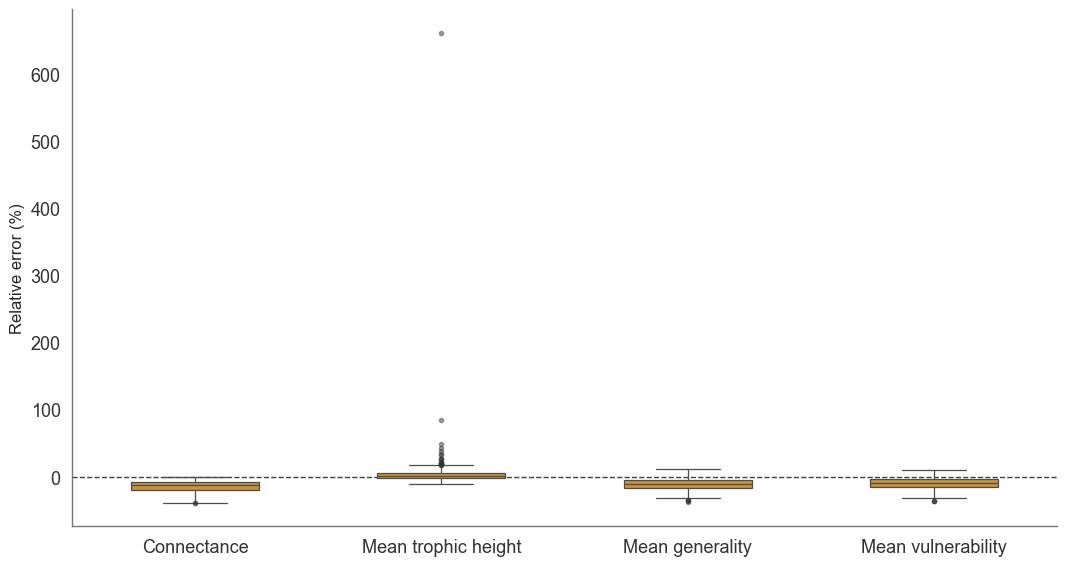

In [9]:
# Plot 3: relative-error distributions across all food webs
fig, ax = plt.subplots(figsize=(10.8, 5.8))

sns.boxplot(
    data=property_pairs,
    x="Metric",
    y="RelativeErrorPercent",
    order=METRIC_ORDER,
    color=INFERRED_COLOR,
    saturation=1.0,
    width=0.52,
    showfliers=True,
    linewidth=0.9,
    flierprops={
        "marker": "o",
        "markersize": 3.0,
        "markerfacecolor": "0.20",
        "markeredgecolor": "0.20",
        "alpha": 0.45,
    },
    ax=ax,
)

ax.axhline(0, color="0.25", linestyle="--", linewidth=1.0, zorder=0)
# ax.set_yscale("symlog", linthresh=10, linscale=1.0)
ax.set_yscale("linear")
ax.set_xlabel("")
ax.set_ylabel("Relative error (%)", fontsize=12)
ax.set_xticks(
    ax.get_xticks(),
    labels=[METRIC_LABELS[metric] for metric in METRIC_ORDER],
)
style_publication_axis(ax)
# add_panel_label(ax, "a")
# ax.text(
#     1.0, -0.18,
#     "Symmetric-log scale; linear between -10% and 10%. No food webs omitted.",
#     transform=ax.transAxes, ha="right", va="top", fontsize=9, color="0.35",
# )
fig.tight_layout()
finish_figure(fig, "relative_error_all_foodwebs.png")


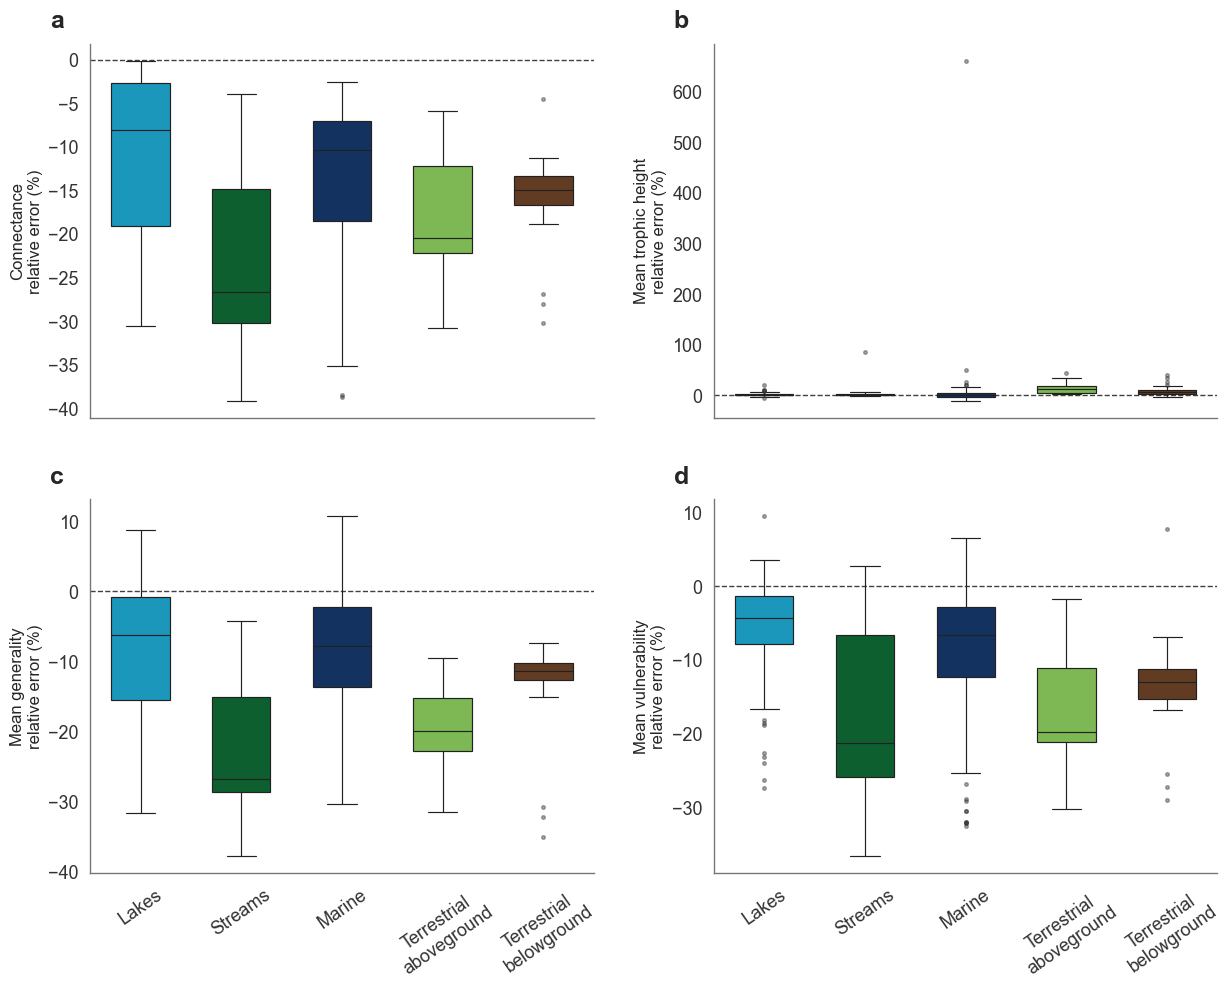

In [10]:
# Plot 4: relative errors by ecosystem,
# with one panel per property
# Layout: 2 rows × 2 columns

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12.5, 10.0),
    sharey=False,
    sharex=True,
    constrained_layout=False,
)

axes = np.asarray(axes).reshape(-1)

for panel_index, (ax, metric) in enumerate(
    zip(axes, METRIC_ORDER)
):
    metric_data = property_pairs.loc[
        property_pairs["Metric"].eq(metric)
    ]

    sns.boxplot(
        data=metric_data,
        x="Ecosystem",
        y="RelativeErrorPercent",
        hue="Ecosystem",
        order=ECOSYSTEM_ORDER,
        hue_order=ECOSYSTEM_ORDER,
        palette=ECOSYSTEM_PALETTE,
        dodge=False,
        width=0.58,
        showfliers=True,
        linewidth=0.85,
        flierprops={
            "marker": "o",
            "markersize": 2.6,
            "markerfacecolor": "0.20",
            "markeredgecolor": "0.20",
            "alpha": 0.42,
        },
        legend=False,
        ax=ax,
    )

    ax.axhline(
        0,
        color="0.25",
        linestyle="--",
        linewidth=1.0,
        zorder=0,
    )

    # ax.set_yscale(
    #     "symlog",
    #     linthresh=10,
    #     linscale=1.0,
    # )
    ax.set_yscale("linear")

    ax.set_xlabel("")

    # Show the y-axis label on the left column.
    ax.set_ylabel(
        f"{METRIC_LABELS[metric]}\nrelative error (%)",
        fontsize=12,
    )

    ax.set_xticks(
        ax.get_xticks(),
        labels=[
            "Lakes",
            "Streams",
            "Marine",
            "Terrestrial\naboveground",
            "Terrestrial\nbelowground",
        ],
        rotation=35,
        ha="center",
    )

    style_publication_axis(ax)

    add_panel_label(
        ax,
        PANEL_LETTERS[panel_index],
    )

# Optional explanatory note:
#
# fig.text(
#     0.995,
#     0.01,
#     (
#         "Symmetric-log scale; linear between -10% and 10%. "
#         "No food webs omitted."
#     ),
#     ha="right",
#     va="bottom",
#     fontsize=9,
#     color="0.35",
# )

fig.tight_layout(
    h_pad=3.0,
    w_pad=2.0,
)

finish_figure(
    fig,
    "relative_error_by_ecosystem.png",
)

In [1]:
# ============================================================
# Athen/Dave analysis: empirical vs inferred food-web properties
# Data preparation shared by the four plotting cells below
# ============================================================
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

sns.set_theme(context="paper", style="white", font_scale=1.15)


def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    candidates = [start, *start.parents]
    fallback = Path("/Users/acw792/Developer/qmul-phd-framework")
    if fallback not in candidates:
        candidates.append(fallback)

    for candidate in candidates:
        if (candidate / "src/matlab").is_dir() and (candidate / "docs").is_dir():
            return candidate

    raise RuntimeError("Could not locate the repository root.")


REPO_ROOT = find_repo_root()
RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_trophicv2_"
        "100x290_train10-90_Apocrita_20260910_011848"
    )
)
RATIO_PROTOCOL_NAME = (
    "ratio_metrics_tukey_iqr_1p5_min25runs_threshold0p50_v1"
)
PAIRS_FILE = (
    RESULT_ROOT
    / "retention_protocol"
    / RATIO_PROTOCOL_NAME
    / "figure_inputs"
    / "athen_empirical_vs_inferred_train60_after_tukey.csv"
)
FIGURE_DIR = REPO_ROOT / "docs/progress_notebooks_logs/2026/figures/week-39"
SAVE_FIGURES = False

ECOSYSTEM_ORDER = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]
ECOSYSTEM_LABELS = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial aboveground",
    "terrestrial belowground": "Terrestrial belowground",
}
EXPECTED_FOODWEBS = {
    "lakes": 55,
    "streams": 28,
    "marine": 134,
    "terrestrial aboveground": 21,
    "terrestrial belowground": 52,
}
METRIC_ORDER = [
    "Connectance",
    "MeanTrophicHeight",
    "ResourceToConsumerRatio",
    "ConsumerToResourceRatio",
]
METRIC_LABELS = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "ResourceToConsumerRatio": "Resource-to-consumer ratio",
    "ConsumerToResourceRatio": "Consumer-to-resource ratio",
}
METRIC_TICK_LABELS = {
    **METRIC_LABELS,
    "ResourceToConsumerRatio": "Resource-to-consumer ratio",
    "ConsumerToResourceRatio": "Consumer-to-resource ratio",
}
METRIC_AXIS_OVERRIDES = {
    "Connectance": {
        "yticks": [0.0, 0.1, 0.2, 0.3],
    },
    "MeanTrophicHeight": {
        "xlim": (0.0, 8.0),
        "xticks": [0, 5],
        "yticks": [0, 5, 10, 15, 20],
    },
}
ECOSYSTEM_PALETTE = {
    "lakes": "#00A6D6",
    "streams": "#006D2C",
    "marine": "#08306B",
    "terrestrial aboveground": "#7AC943",
    "terrestrial belowground": "#6B3A19",
}
ECOSYSTEM_MARKERS = {
    "lakes": "o",
    "streams": "s",
    "marine": "D",
    "terrestrial aboveground": "^",
    "terrestrial belowground": "v",
}
INFERRED_COLOR = "#C6923A"
PANEL_LETTERS = list("abcdefghijklmnopqrstuvwxyz") + ["aa", "ab", "ac", "ad"]

if not PAIRS_FILE.is_file():
    raise FileNotFoundError(PAIRS_FILE)

property_pairs = pd.read_csv(PAIRS_FILE)
required_columns = {
    "FoodWeb",
    "Ecosystem",
    "Metric",
    "EmpiricalValue",
    "MeanPseudoAfterFiltering",
    "ValidRunsAfterFiltering",
}
missing_columns = required_columns.difference(property_pairs.columns)
if missing_columns:
    raise KeyError(f"Missing required columns: {sorted(missing_columns)}")

property_pairs = property_pairs.loc[
    property_pairs["Ecosystem"].isin(ECOSYSTEM_ORDER)
    & property_pairs["Metric"].isin(METRIC_ORDER)
].copy()

numeric_columns = [
    "EmpiricalValue",
    "MeanPseudoAfterFiltering",
    "ValidRunsAfterFiltering",
]
for column in numeric_columns:
    property_pairs[column] = pd.to_numeric(property_pairs[column], errors="coerce")

if property_pairs.duplicated(["FoodWeb", "Ecosystem", "Metric"]).any():
    raise RuntimeError("Duplicated food-web/ecosystem/metric pairs were found.")

if not np.isfinite(property_pairs[numeric_columns].to_numpy(dtype=float)).all():
    raise RuntimeError("Non-finite values were found in the plotting input.")

if (property_pairs["EmpiricalValue"] <= 0).any():
    raise RuntimeError("Relative error requires strictly positive empirical values.")

if (property_pairs["ValidRunsAfterFiltering"] < 25).any():
    raise RuntimeError("At least one pair retained fewer than 25 runs.")

for metric in METRIC_ORDER:
    metric_data = property_pairs.loc[property_pairs["Metric"].eq(metric)]
    if metric_data["FoodWeb"].nunique() != 290:
        raise RuntimeError(
            f"{metric}: expected 290 food webs, found "
            f"{metric_data['FoodWeb'].nunique()}."
        )

observed_counts = (
    property_pairs.groupby(["Ecosystem", "Metric"], observed=False)
    .size()
)
for ecosystem in ECOSYSTEM_ORDER:
    for metric in METRIC_ORDER:
        observed = int(observed_counts.get((ecosystem, metric), 0))
        expected = EXPECTED_FOODWEBS[ecosystem]
        if observed != expected:
            raise RuntimeError(
                f"{ecosystem}, {metric}: expected {expected}, found {observed}."
            )

property_pairs["RelativeError"] = (
    property_pairs["MeanPseudoAfterFiltering"]
    - property_pairs["EmpiricalValue"]
) / property_pairs["EmpiricalValue"]
property_pairs["RelativeErrorPercent"] = 100 * property_pairs["RelativeError"]
property_pairs["MetricLabel"] = property_pairs["Metric"].map(METRIC_LABELS)
property_pairs["EcosystemLabel"] = property_pairs["Ecosystem"].map(ECOSYSTEM_LABELS)


def identity_limits(data, pad_fraction=0.06):
    values = np.concatenate(
        [
            data["EmpiricalValue"].to_numpy(dtype=float),
            data["MeanPseudoAfterFiltering"].to_numpy(dtype=float),
        ]
    )
    lower = float(np.nanmin(values))
    upper = float(np.nanmax(values))
    span = upper - lower
    if np.isclose(span, 0):
        span = max(abs(lower), 1.0) * 0.10
    padding = pad_fraction * span
    return lower - padding, upper + padding


def style_publication_axis(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")
    ax.tick_params(axis="both", colors="#333333", labelsize=13)


def add_panel_label(ax, letter):
    ax.text(
        -0.08, 1.03, letter,
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )


def add_identity_line(ax, limits):
    ax.plot(limits, limits, color="0.25", linestyle="--", linewidth=1.0, zorder=1)
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.set_aspect("equal", adjustable="box")
    style_publication_axis(ax)


def finish_figure(fig, filename):
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        output_path = FIGURE_DIR / filename
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"[SAVED] {output_path}")
    plt.show()


validation_summary = (
    property_pairs.groupby(["EcosystemLabel", "MetricLabel"], observed=False)
    .agg(
        FoodWebs=("FoodWeb", "nunique"),
        MinimumRetainedRuns=("ValidRunsAfterFiltering", "min"),
        MedianRelativeErrorPercent=("RelativeErrorPercent", "median"),
    )
    .reset_index()
)

print(f"[INFO] Source: {PAIRS_FILE}")
print("[INFO] Train ratio: 60%; 100 runs before Tukey filtering.")
print("[INFO] Relative error = (mean inferred - empirical) / empirical.")
expected_rows = 290 * len(METRIC_ORDER)
if len(property_pairs) != expected_rows:
    raise RuntimeError(
        f"Expected {expected_rows:,} plotting rows, found {len(property_pairs):,}."
    )
print(
    f"[INFO] Validated rows: {len(property_pairs):,} = "
    f"290 food webs x {len(METRIC_ORDER)} metrics."
)
display(validation_summary)


[INFO] Source: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_roleonly_trophicv2_100x290_train10-90_Apocrita_20260910_011848/retention_protocol/ratio_metrics_tukey_iqr_1p5_min25runs_threshold0p50_v1/figure_inputs/athen_empirical_vs_inferred_train60_after_tukey.csv
[INFO] Train ratio: 60%; 100 runs before Tukey filtering.
[INFO] Relative error = (mean inferred - empirical) / empirical.
[INFO] Validated rows: 1,160 = 290 food webs x 4 metrics.


,EcosystemLabel,MetricLabel,FoodWebs,MinimumRetainedRuns,MedianRelativeErrorPercent
0,Lakes,Connectance,55,87,-8.131952
1,Lakes,Consumer-to-resource ratio,55,80,1.463335
2,Lakes,Mean trophic height,55,56,1.032652
3,Lakes,Resource-to-consumer ratio,55,79,-0.881813
4,Marine,Connectance,134,91,-10.360458
5,Marine,Consumer-to-resource ratio,134,83,1.033900
6,Marine,Mean trophic height,134,42,0.012866
7,Marine,Resource-to-consumer ratio,134,83,-0.540274
8,Streams,Connectance,28,83,-26.665248
9,Streams,Consumer-to-resource ratio,28,91,5.654752


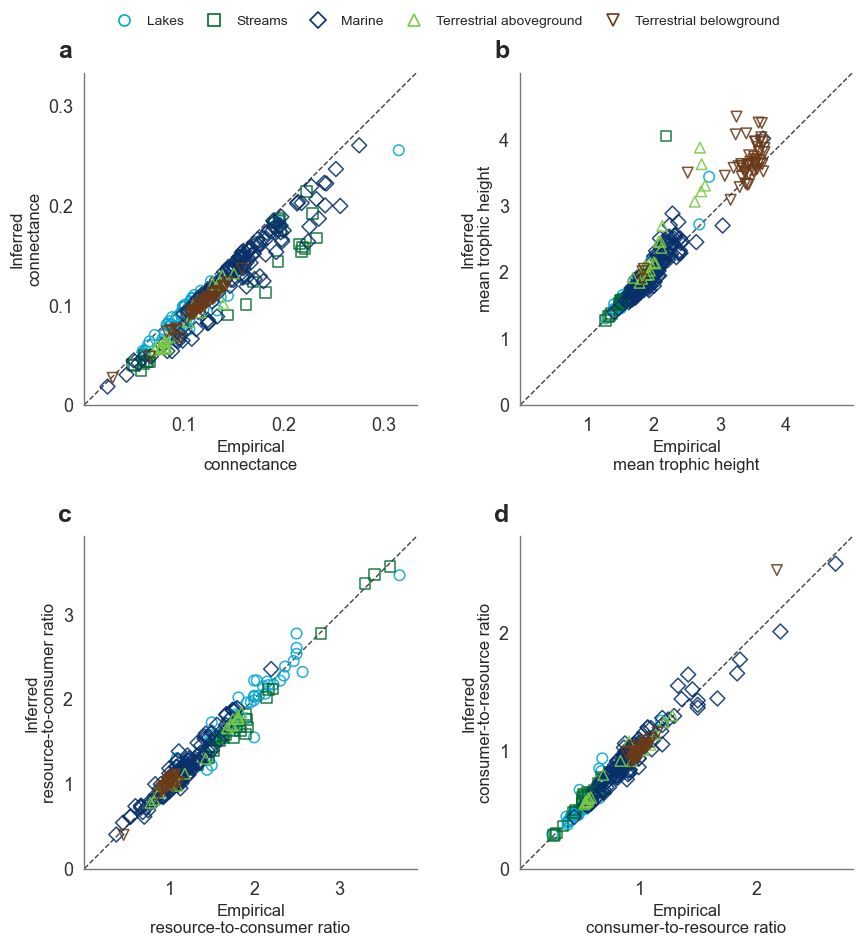

In [2]:
# Plot 1: empirical versus mean inferred value across all food webs
# Layout: 2 rows × 2 columns

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11.5, 10.0),
    constrained_layout=False,
)

axes = np.asarray(axes).reshape(-1)

for panel_index, (ax, metric) in enumerate(
    zip(axes, METRIC_ORDER)
):
    metric_data = property_pairs.loc[
        property_pairs["Metric"].eq(metric)
    ]

    limits = identity_limits(metric_data)

    # Give both axes the same range and make them start at zero.
    limits = (0.0, limits[1])

    for ecosystem in ECOSYSTEM_ORDER:
        ecosystem_data = metric_data.loc[
            metric_data["Ecosystem"].eq(ecosystem)
        ]

        ax.scatter(
            ecosystem_data["EmpiricalValue"],
            ecosystem_data["MeanPseudoAfterFiltering"],
            s=58,
            marker=ECOSYSTEM_MARKERS[ecosystem],
            facecolors="none",
            edgecolors=ECOSYSTEM_PALETTE[ecosystem],
            linewidths=1.1,
            alpha=0.88,
            zorder=2,
        )

    add_identity_line(ax, limits)

    # Ensure that x and y share the same origin and range.
    ax.set_xlim(limits)
    ax.set_ylim(limits)

    axis_config = METRIC_AXIS_OVERRIDES.get(metric, {})
    if "xlim" in axis_config:
        ax.set_xlim(axis_config["xlim"])
    if "xticks" in axis_config:
        ax.set_xticks(axis_config["xticks"])
    if "yticks" in axis_config:
        ax.set_yticks(axis_config["yticks"])

    # Panel b: use evenly spaced empirical trophic-height ticks.
    if panel_index == 1:
        ax.set_xticks([1, 2, 3, 4])
        ax.set_yticks([0, 1, 2, 3, 4])

    # Panels c and d: show integer ticks only on both axes.
    if panel_index in (2, 3):
        x_upper = np.floor(ax.get_xlim()[1])
        y_upper = np.floor(ax.get_ylim()[1])
        ax.set_xticks(np.arange(0.0, x_upper + 1.0, 1.0))
        ax.set_yticks(np.arange(0.0, y_upper + 1.0, 1.0))

    # Keep every panel physically square, even when its x- and y-ranges differ.
    ax.set_aspect("auto")
    ax.set_box_aspect(1)

    # Hide the x-axis zero label so only one zero is shown
    # at the lower-left corner.
    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda value, position: (
                ""
                if np.isclose(value, 0.0)
                else f"{value:g}"
            )
        )
    )

    # Show the single lower-left zero as an integer on the y-axis.
    ax.yaxis.set_major_formatter(
        FuncFormatter(
            lambda value, position: (
                "0"
                if np.isclose(value, 0.0)
                else f"{value:g}"
            )
        )
    )

    metric_axis_label = METRIC_TICK_LABELS[metric].lower()

    ax.set_xlabel(
        f"Empirical\n{metric_axis_label}",
        fontsize=12,
    )
    ax.set_ylabel(
        f"Inferred\n{metric_axis_label}",
        fontsize=12,
    )

    add_panel_label(
        ax,
        PANEL_LETTERS[panel_index],
    )

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=ECOSYSTEM_MARKERS[ecosystem],
        linestyle="none",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor=ECOSYSTEM_PALETTE[ecosystem],
        markeredgewidth=1.2,
        label=ECOSYSTEM_LABELS[ecosystem],
    )
    for ecosystem in ECOSYSTEM_ORDER
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.4, 0.95),
    columnspacing=1.2,
    handletextpad=0.6,
    fontsize=10,
)

# Zoom panel b while preserving all underlying observations.
axes[1].set_xlim(0, 5)
axes[1].set_ylim(0, 5)

fig.tight_layout(
    rect=(0, 0, 0.8, 0.93),
    h_pad=2.0,
    w_pad=1.8,
)

finish_figure(
    fig,
    "empirical_vs_inferred_all_foodwebs_four_metrics_ratios.png",
)

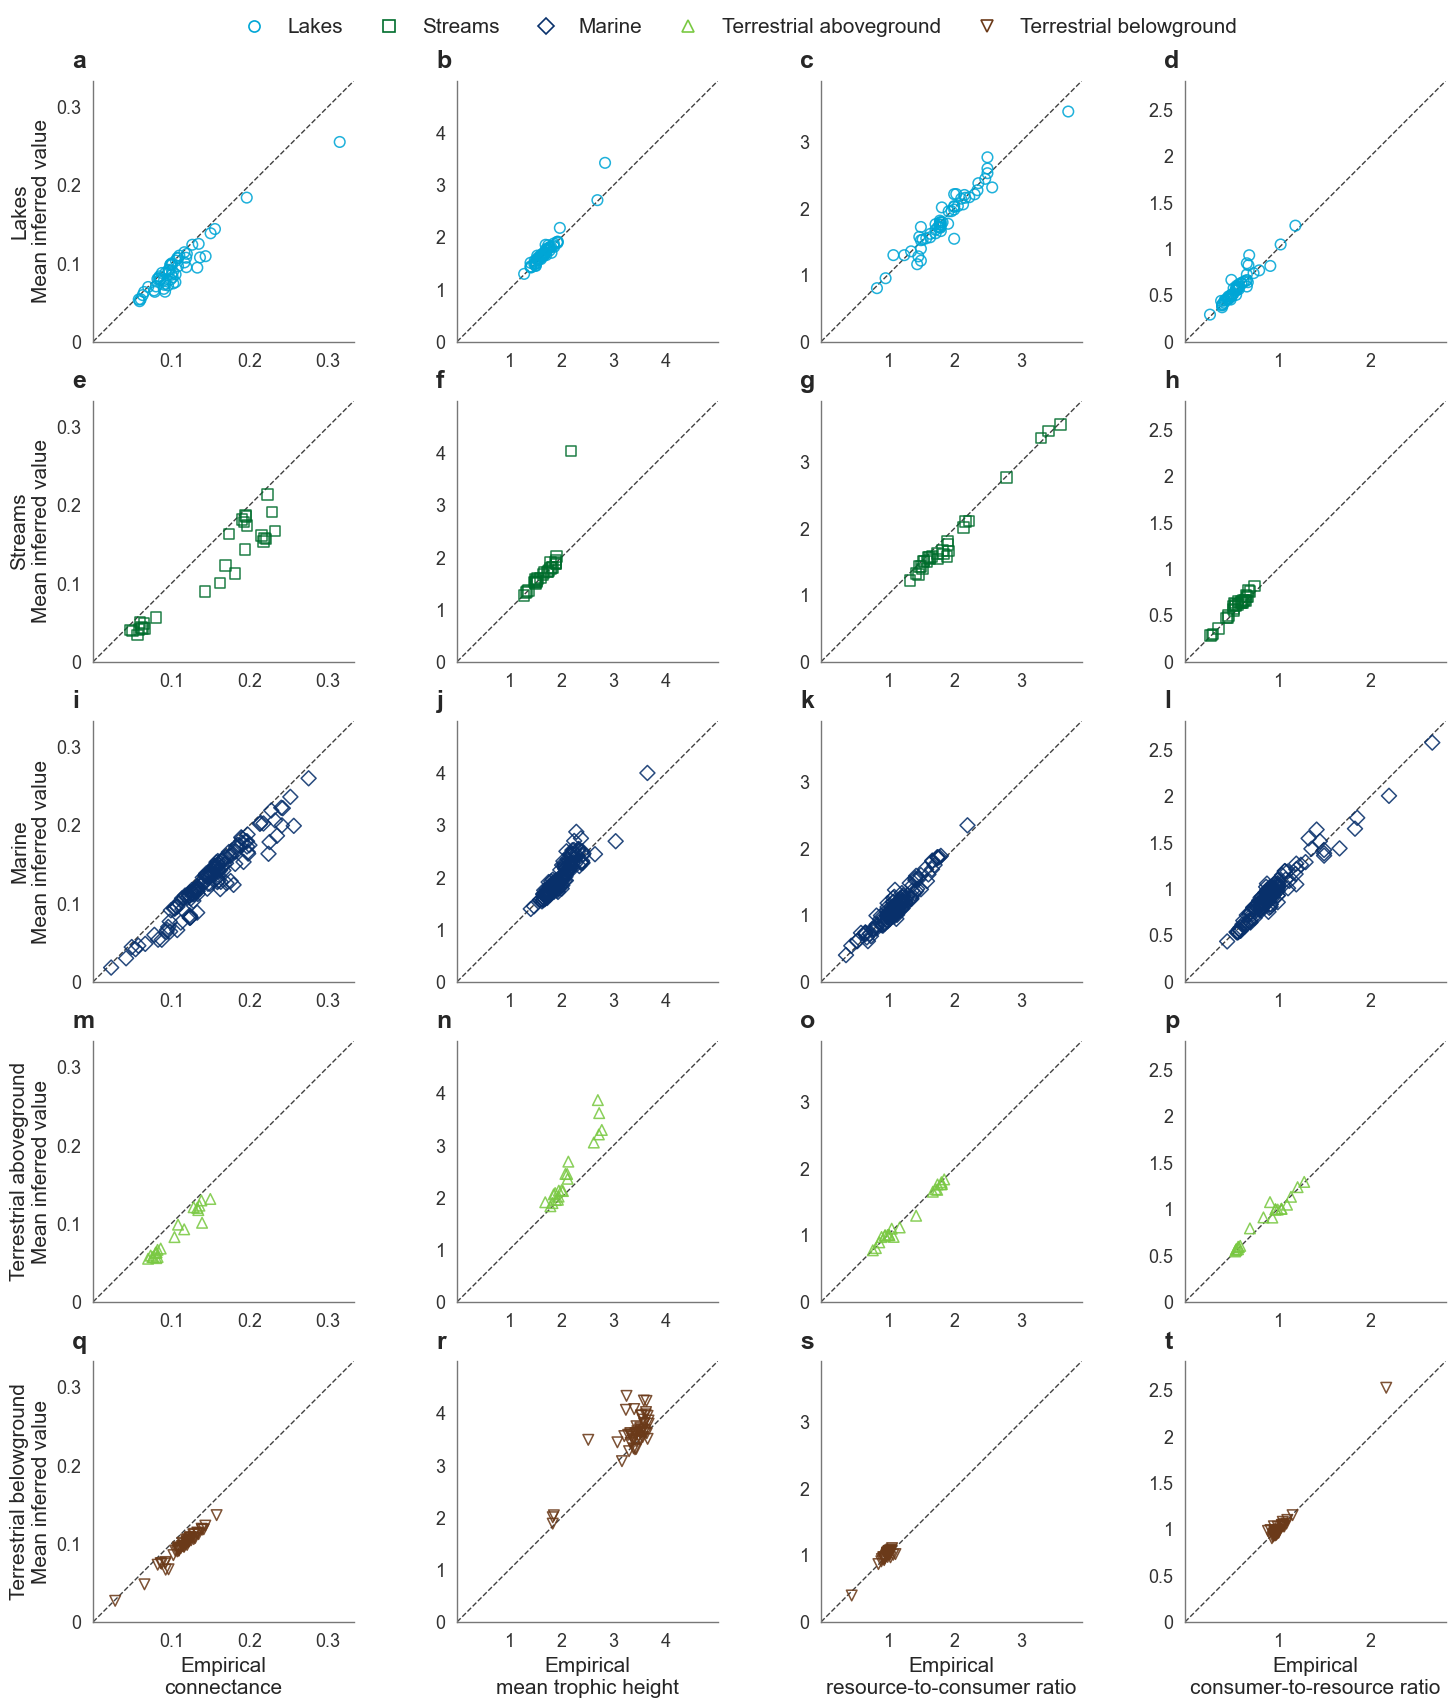

In [3]:
# Plot 2: empirical versus mean inferred value
# for each ecosystem and metric

fig, axes = plt.subplots(
    len(ECOSYSTEM_ORDER),
    len(METRIC_ORDER),
    figsize=(15.5, 17.5),
    squeeze=False,
    sharex=False,
    sharey=False
)

metric_limits = {}

for metric in METRIC_ORDER:
    metric_data = property_pairs.loc[
        property_pairs["Metric"].eq(metric)
    ]

    calculated_limits = identity_limits(metric_data)

    metric_limits[metric] = (
        0.0,
        calculated_limits[1],
    )

for row_index, ecosystem in enumerate(
    ECOSYSTEM_ORDER
):
    for column_index, metric in enumerate(
        METRIC_ORDER
    ):
        ax = axes[row_index, column_index]

        panel_data = property_pairs.loc[
            property_pairs["Ecosystem"].eq(ecosystem)
            & property_pairs["Metric"].eq(metric)
        ]

        ax.scatter(
            panel_data["EmpiricalValue"],
            panel_data["MeanPseudoAfterFiltering"],
            s=58,
            marker=ECOSYSTEM_MARKERS[ecosystem],
            facecolors="none",
            edgecolors=ECOSYSTEM_PALETTE[ecosystem],
            linewidths=1.1,
            alpha=0.88,
            zorder=2,
        )

        add_identity_line(
            ax,
            metric_limits[metric],
        )

        limits = metric_limits[metric]

        # Make both axes start at the same origin.
        ax.set_xlim(limits)
        ax.set_ylim(limits)

        axis_config = METRIC_AXIS_OVERRIDES.get(metric, {})
        if "xlim" in axis_config:
            ax.set_xlim(axis_config["xlim"])
        if "xticks" in axis_config:
            ax.set_xticks(axis_config["xticks"])
        if "yticks" in axis_config:
            ax.set_yticks(axis_config["yticks"])

        # Trophic-height column (panels b, f, j, n, r).
        if metric == "MeanTrophicHeight":
            ax.set_xlim(0, 5)
            ax.set_ylim(0, 5)
            ax.set_xticks([1, 2, 3, 4])
            ax.set_yticks([0, 1, 2, 3, 4])

        # Format the single visible origin label as 0, not 0.0.
        ax.yaxis.set_major_formatter(
            FuncFormatter(
                lambda value, position: (
                    "0"
                    if np.isclose(value, 0.0)
                    else f"{value:g}"
                )
            )
        )

        # Preserve the physical size of every panel.
        ax.set_aspect("auto")
        ax.set_box_aspect(1)

        # Hide the x-axis zero label so that only the
        # y-axis zero appears in the lower-left corner.
        ax.xaxis.set_major_formatter(
            FuncFormatter(
                lambda value, position: (
                    ""
                    if np.isclose(value, 0.0)
                    else f"{value:g}"
                )
            )
        )

        if row_index == len(ECOSYSTEM_ORDER) - 1:
            ax.set_xlabel(
                f"Empirical\n{METRIC_TICK_LABELS[metric].lower()}",
                fontsize=15,
            )
        else:
            ax.set_xlabel("")

        if column_index == 0:
            ax.set_ylabel(
                f"{ECOSYSTEM_LABELS[ecosystem]}\n"
                "Mean inferred value",
                fontsize=15,
            )
        else:
            ax.set_ylabel("")

        panel_index = (
            row_index * len(METRIC_ORDER)
            + column_index
        )

        add_panel_label(
            ax,
            PANEL_LETTERS[panel_index],
        )


# ============================================================
# Global ecosystem legend
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=ECOSYSTEM_MARKERS[ecosystem],
        linestyle="none",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor=ECOSYSTEM_PALETTE[ecosystem],
        markeredgewidth=1.2,
        label=ECOSYSTEM_LABELS[ecosystem],
    )
    for ecosystem in ECOSYSTEM_ORDER
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=5,
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.6,
    fontsize=15,
)

fig.tight_layout(
    rect=(0, 0, 1, 0.96),
    h_pad=0,
    w_pad=0,
)

finish_figure(
    fig,
    "empirical_vs_inferred_by_ecosystem_four_metrics_ratios.png",
)

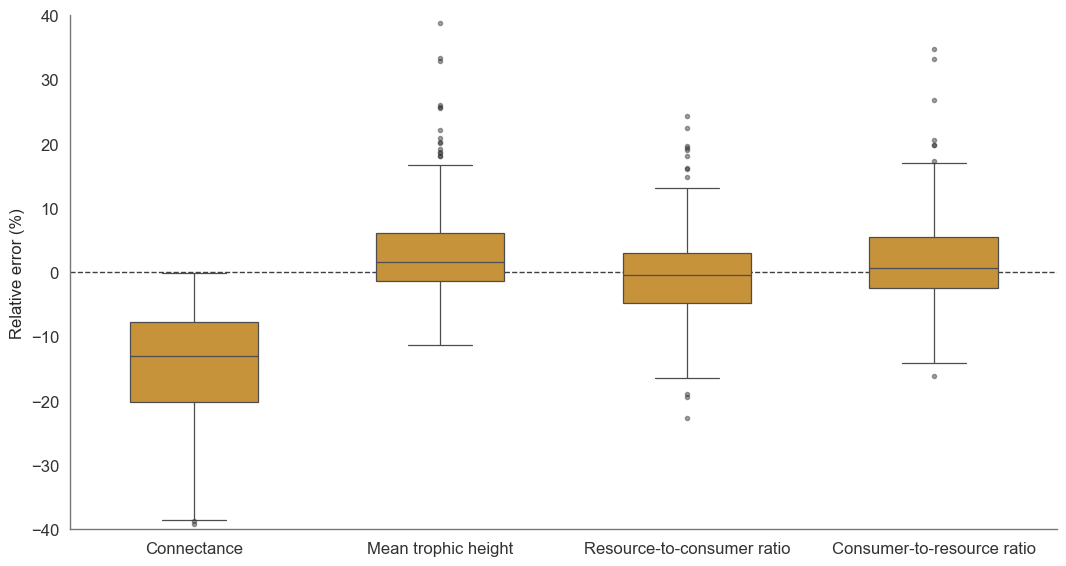

In [7]:
# Plot 3: relative-error distributions across all food webs
fig, ax = plt.subplots(figsize=(10.8, 5.8))

sns.boxplot(
    data=property_pairs,
    x="Metric",
    y="RelativeErrorPercent",
    order=METRIC_ORDER,
    color=INFERRED_COLOR,
    saturation=1.0,
    width=0.52,
    showfliers=True,
    linewidth=0.9,
    flierprops={
        "marker": "o",
        "markersize": 3.0,
        "markerfacecolor": "0.20",
        "markeredgecolor": "0.20",
        "alpha": 0.45,
    },
    ax=ax,
)

ax.axhline(0, color="0.25", linestyle="--", linewidth=1.0, zorder=0)
# ax.set_yscale("symlog", linthresh=10, linscale=1.0)
ax.set_yscale("linear")
ax.set_xlabel("")
ax.set_ylabel("Relative error (%)", fontsize=12)
ax.set_xticks(
    ax.get_xticks(),
    labels=[METRIC_TICK_LABELS[metric] for metric in METRIC_ORDER],
)
style_publication_axis(ax)
# add_panel_label(ax, "a")
# ax.text(
#     1.0, -0.18,
#     "Symmetric-log scale; linear between -10% and 10%. No food webs omitted.",
#     transform=ax.transAxes, ha="right", va="top", fontsize=9, color="0.35",
# )
# Zoom in without altering the data used to calculate the boxplots.
# Only the single 661.24% outlier falls outside the visible range.
ax.set_ylim(-40, 40)
ax.tick_params(axis="both", labelsize=12)
fig.tight_layout()
finish_figure(fig, "relative_error_all_foodwebs_four_metrics_ratios.png")


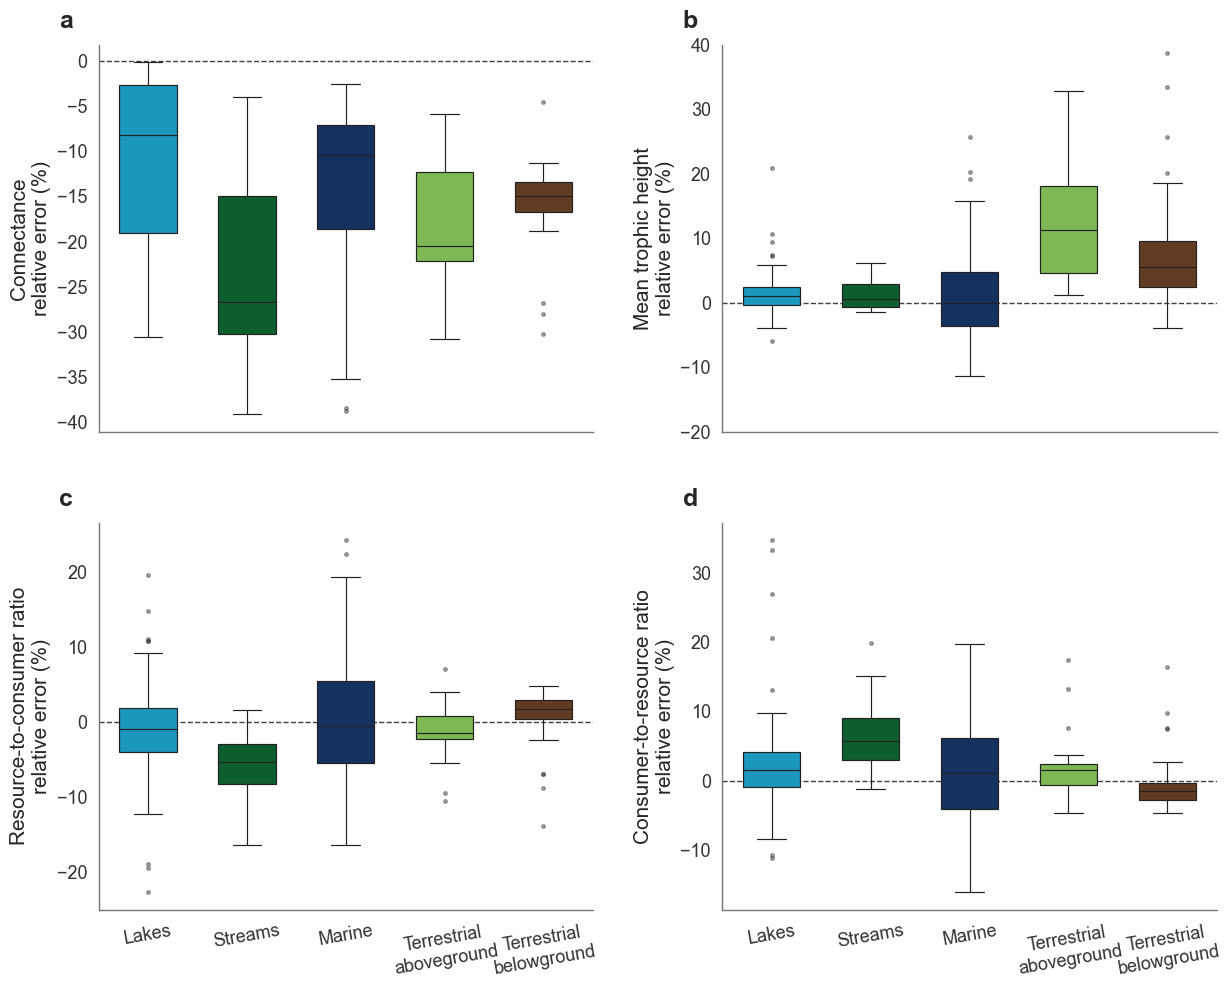

In [10]:
# Plot 4: relative errors by ecosystem,
# with one panel per property
# Layout: 2 rows × 2 columns

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12.5, 10.0),
    sharey=False,
    sharex=True,
    constrained_layout=False,
)

axes = np.asarray(axes).reshape(-1)

for panel_index, (ax, metric) in enumerate(
    zip(axes, METRIC_ORDER)
):
    metric_data = property_pairs.loc[
        property_pairs["Metric"].eq(metric)
    ]

    sns.boxplot(
        data=metric_data,
        x="Ecosystem",
        y="RelativeErrorPercent",
        hue="Ecosystem",
        order=ECOSYSTEM_ORDER,
        hue_order=ECOSYSTEM_ORDER,
        palette=ECOSYSTEM_PALETTE,
        dodge=False,
        width=0.58,
        showfliers=True,
        linewidth=0.85,
        flierprops={
            "marker": "o",
            "markersize": 2.6,
            "markerfacecolor": "0.20",
            "markeredgecolor": "0.20",
            "alpha": 0.42,
        },
        legend=False,
        ax=ax,
    )

    ax.axhline(
        0,
        color="0.25",
        linestyle="--",
        linewidth=1.0,
        zorder=0,
    )

    # ax.set_yscale(
    #     "symlog",
    #     linthresh=10,
    #     linscale=1.0,
    # )
    ax.set_yscale("linear")

    ax.set_xlabel("")

    # Show the y-axis label on the left column.
    ax.set_ylabel(
        f"{METRIC_LABELS[metric]}\nrelative error (%)",
        fontsize=15,
    )

    ax.set_xticks(
        ax.get_xticks(),
        labels=[
            "Lakes",
            "Streams",
            "Marine",
            "Terrestrial\naboveground",
            "Terrestrial\nbelowground",
        ],
        rotation=10,
        ha="center",
    )

    style_publication_axis(ax)

    add_panel_label(
        ax,
        PANEL_LETTERS[panel_index],
    )

# Optional explanatory note:
#
# fig.text(
#     0.995,
#     0.01,
#     (
#         "Symmetric-log scale; linear between -10% and 10%. "
#         "No food webs omitted."
#     ),
#     ha="right",
#     va="bottom",
#     fontsize=9,
#     color="0.35",
# )

# Zoom panel b while preserving all underlying observations.
axes[1].set_ylim(-20, 40)

fig.tight_layout(
    h_pad=3.0,
    w_pad=2.0,
)

finish_figure(
    fig,
    "relative_error_by_ecosystem_four_metrics_ratios.png",
)